In [1]:
#imports
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append(r'..\..\..\spikeparam')

from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup

from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.spatial as sp_spatial
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import os

from fooof import FOOOF

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})

import IProgress

import openpyxl
import glob

import pickle

C:\Users\david\AppData\Local\Temp\ipykernel_17228\2209292807.py:45: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


### Defining useful functions

In [3]:
# Function to visualize sweep patch data
# no metadata, just the time series data
def extract_data(file_path, plot_data = False):
    """
    Extracts data from an HDF5 file and optionally plots the data.

    This function opens an HDF5 file, extracts data from each sweep in the 'acquisition' group, 
    and stores the data in a list of NumPy arrays. If the plot_data flag is set to True, the 
    function also plots the data. It handles both 1D and 2D data, but prints a message if the 
    data has more than 2 dimensions.

    Parameters:
    - file_path (str): The path to the HDF5 file.
    - plot_data (bool): A flag indicating whether to plot the extracted data. Default is False.

    Returns:
    - list: A list of NumPy arrays containing the extracted data for each sweep.
    """
    # Open the HDF5 file
    with h5py.File(file_path, 'r') as f:
        # Initialize an empty list to store data arrays
        data = []

        # Iterate through keys in the 'acquisition' group
        for sweep_key in f['acquisition'].keys():
            dataset = f['acquisition'][sweep_key]['data'] 
            # Convert the dataset data into a NumPy array and append to the list
            data.append(np.array(dataset))

        # Plot the data
        if(plot_data):
            if all(d.ndim == 1 for d in data):
                for d in data:
                    plt.plot(d)
                plt.xlabel('time (ms)')
                plt.ylabel('mV')
                plt.title('1D Dataset Visualization')
                plt.show()
            elif all(d.ndim == 2 for d in data):
                for d in data:
                    plt.imshow(d, cmap='viridis')
                    plt.colorbar()
                    plt.xlabel('X-axis')
                    plt.ylabel('Y-axis')
                    plt.title('2D Dataset Visualization')
                    plt.show()
            else:
                print("Cannot visualize data with more than 2 dimensions.")



        return data

In [4]:
#collecting file paths

def get_file_paths(folder_path):
    """
    Function to loop through a folder and save file paths.
    
    Args:
    - folder_path (str): Path to the folder to loop through.
    
    Returns:
    - file_paths (list): List of file paths found in the folder.
    """
    file_paths = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths 


In [5]:
# Functions to save a datrame to a pickle file and another to extract the data from the pickle file

def save_dataframe_to_pickle(dataframe, file_path):
    """
    Function to save a DataFrame as a pickle file.
    
    Args:
    - dataframe (pd.DataFrame): DataFrame to be saved.
    - file_path (str): Path to save the pickle file.
    """
    dataframe.to_pickle(file_path)

def load_dataframe_from_pickle(file_path):
    """
    Function to extract a DataFrame from a pickle file.
    
    Args:
    - file_path (str): Path to the pickle file.
    
    Returns:
    - dataframe (pd.DataFrame): Loaded DataFrame.
    """
    dataframe = pd.read_pickle(file_path)
    return dataframe

def save_dict_to_pickle(dictionary, filepath):
    """
    Save a dictionary to a pickle file.

    Parameters:
        dictionary (dict): The dictionary to save.
        filepath (str): The path to the pickle file.
    """
    with open(filepath, 'wb') as f:
        pickle.dump(dictionary, f)
    print(f"Dictionary saved to {filepath}")


def load_dict_from_pickle(filepath):
    """
    Load a dictionary from a pickle file.

    Parameters:
        filepath (str): The path to the pickle file.

    Returns:
        dict: The loaded dictionary.
    """
    with open(filepath, 'rb') as f:
        dictionary = pickle.load(f)
    print(f"Dictionary loaded from {filepath}")
    return dictionary

In [6]:
allMonkey_df_filt = allMonkey_df_filt.dropna()
save_dataframe_to_pickle(allMonkey_df_filt, r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\allMonkey_df_filt.pkl")

NameError: name 'allMonkey_df_filt' is not defined

### ANOVAS and Posthoc tests

In [7]:

allMonkey_df_filt = load_dataframe_from_pickle(r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\allMonkey_df_filt.pkl")
allMonkey_df_filt.tail()


,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,...,Sweep_#,file_name,dendriticType,SomaLayerLoc,brainOrigin,Weight,Sex,Age,Species,Monkey ID
63855,1.846199,1.35,-42.471191,45.846680,2.45,0.442505,0.359868,-78.247398,121.70,0.923707,...,Sweep_9,M21_SA_A1_C07,S,3,V1,8.7,M,7.65,Macaca fascicularis,M21
63856,2.099518,1.45,-39.785645,42.367676,2.55,0.381470,0.299768,-84.266822,0.00,0.944645,...,Sweep_9,M21_SA_A1_C07,S,3,V1,8.7,M,7.65,Macaca fascicularis,M21
63857,2.099518,1.45,-39.785645,42.367676,2.55,0.381470,0.299768,-84.266822,255.00,0.944645,...,Sweep_9,M21_SA_A1_C07,S,3,V1,8.7,M,7.65,Macaca fascicularis,M21
63858,2.276198,1.55,-37.100098,40.139893,2.65,0.335693,0.304954,-81.487302,359.55,0.930923,...,Sweep_9,M21_SA_A1_C07,S,3,V1,8.7,M,7.65,Macaca fascicularis,M21
63859,2.398728,1.60,-36.886475,38.888672,2.75,0.350952,0.279030,-85.988248,0.00,0.954351,...,Sweep_9,M21_SA_A1_C07,S,3,V1,8.7,M,7.65,Macaca fascicularis,M21


In [43]:
# Assuming you have a dataframe `df`
# Load your dataframe here
df = allMonkey_df_filt
# Define the spike features and conditions
spike_features = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 
                       'peak_sharpness', 'exp_lambda', 'exp_const', 'isi', 'r_squared_ramp']
conditions = ['dendriticType',	'SomaLayerLoc','brainOrigin',	'Weight',	'Sex',	'Age',	'Species',	'Monkey ID']
# Initialize a dictionary to store ANOVA results
anova_results = {feature: {} for feature in spike_features}
# Perform ANOVA for each spike feature against each condition
for feature in spike_features:
    for condition in conditions:
        groups = [df[feature][df[condition] == cond] for cond in df[condition].unique()]
        anova_results[feature][condition] = scipy.stats.f_oneway(*groups)
# Print the ANOVA results
for feature, results in anova_results.items():
    print(f"ANOVA results for {feature}:")
    for condition, result in results.items():
        if result:
            f_value, p_value = result
            print(f"  Condition: {condition}, F-value: {f_value}, p-value: {p_value:.10e}")


ANOVA results for ramp_amp:
  Condition: dendriticType, F-value: 1169.873584039016, p-value: 0.0000000000e+00
  Condition: SomaLayerLoc, F-value: 196.98270320747727, p-value: 2.9959648111e-207
  Condition: brainOrigin, F-value: 2039.820400342448, p-value: 0.0000000000e+00
  Condition: Weight, F-value: 610.6879934754667, p-value: 0.0000000000e+00
  Condition: Sex, F-value: 1241.4811031495533, p-value: 1.7135665509e-266
  Condition: Age, F-value: 575.8880281752758, p-value: 0.0000000000e+00
  Condition: Species, F-value: 3651.394949671516, p-value: 0.0000000000e+00
  Condition: Monkey ID, F-value: 575.8880281752758, p-value: 0.0000000000e+00
ANOVA results for inflection_time:
  Condition: dendriticType, F-value: 3238.647932616205, p-value: 0.0000000000e+00
  Condition: SomaLayerLoc, F-value: 655.8686655997186, p-value: 0.0000000000e+00
  Condition: brainOrigin, F-value: 1034.1045574948337, p-value: 0.0000000000e+00
  Condition: Weight, F-value: 888.1915538215246, p-value: 0.0000000000e+0

In [39]:
# Assuming df is defined and the relevant libraries are imported
df = allMonkey_df_filt

# Define the spike features and conditions
spike_features = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 
                  'peak_sharpness', 'exp_lambda', 'exp_const', 'isi', 'r_squared_ramp']
conditions = ['dendriticType', 'SomaLayerLoc', 'brainOrigin', 'Weight', 'Sex', 'Age', 'Species', 'Monkey ID']

# Initialize a dictionary to store ANOVA results
anova_results = {feature: {} for feature in spike_features}

# Perform ANOVA for each spike feature against each condition
for feature in spike_features:
    for condition in conditions:
        groups = [df[feature][df[condition] == cond] for cond in df[condition].unique()]
        print(groups)
        anova_results[feature][condition] = scipy.stats.f_oneway(*groups)

# Extract and print the ANOVA results for 'ramp_amp' under the condition 'brainOrigin'
feature = 'ramp_amp'
condition = 'brainOrigin'
result = anova_results[feature][condition]
print(f'ANOVA results for {feature} under the condition of {condition}:')
print(f'  F-value: {result.statistic}, p-value: {result.pvalue}')

[4        1.832248
5        2.422453
6        1.725643
7        2.304789
14       2.058032
           ...   
62724    3.280754
62725    3.631362
62726    2.998524
62727    2.960893
62728    3.204575
Name: ramp_amp, Length: 13210, dtype: float64, 231      2.739515
1382     2.659297
1383     2.781368
1384     2.742085
1386     2.600373
           ...   
61092    3.103615
61181    1.871439
61182    2.707575
61183    2.707575
61185    1.970564
Name: ramp_amp, Length: 10198, dtype: float64, 2124     3.120778
2125     2.434064
2126     1.516425
2127     2.350175
2128     1.925866
           ...   
63855    1.846199
63856    2.099518
63857    2.099518
63858    2.276198
63859    2.398728
Name: ramp_amp, Length: 6448, dtype: float64]
[4        1.832248
5        2.422453
6        1.725643
7        2.304789
14       2.058032
           ...   
63855    1.846199
63856    2.099518
63857    2.099518
63858    2.276198
63859    2.398728
Name: ramp_amp, Length: 10398, dtype: float64, 231      2.739515
1

In [48]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the dependent variables
dependent_vars = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 
                  'peak_sharpness', 'exp_lambda', 'exp_const', 'isi', 'r_squared_ramp']

# Define the condition
condition = 'brainOrigin'

# Initialize a dictionary to store ANOVA results
results = {}

# Perform ANOVA for each dependent variable against the specified condition
for dep_var in dependent_vars:
    model_formula = f'{dep_var} ~ C({condition})'
    model = smf.ols(model_formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    results[dep_var] = anova_table

# Print results for each dependent variable
for dep_var, result in results.items():
    print(f'ANOVA results for {dep_var}:\n{result}\n')


ANOVA results for ramp_amp:
                      sum_sq       df          F  PR(>F)
C(brainOrigin)   6145.970515      2.0  2039.8204     0.0
Residual        44973.483388  29853.0        NaN     NaN

ANOVA results for inflection_time:
                     sum_sq       df            F  PR(>F)
C(brainOrigin)   365.422671      2.0  1034.104557     0.0
Residual        5274.593813  29853.0          NaN     NaN

ANOVA results for inflection_amp:
                      sum_sq       df            F  PR(>F)
C(brainOrigin)  1.393627e+05      2.0  1661.603603     0.0
Residual        1.251922e+06  29853.0          NaN     NaN

ANOVA results for peak_amp:
                      sum_sq       df            F  PR(>F)
C(brainOrigin)  3.430099e+05      2.0  1352.967392     0.0
Residual        3.784229e+06  29853.0          NaN     NaN

ANOVA results for peak_width:
                      sum_sq       df           F         PR(>F)
C(brainOrigin)    334.184926      2.0  458.705476  6.115723e-197
Residual    

In [23]:
#%pip install pingouin
import pingouin as pg

pg.anova(dv='peak_width', 
         between='brainOrigin', 
         data=allMonkey_df_filt,
         detailed=True)

  Obtaining dependency information for pingouin from https://files.pythonhosted.org/packages/35/2e/8ca90e7edc93bc3d3bdf6daa6d5fc5ae4882994171c3db765365227e1d58/pingouin-0.5.4-py2.py3-none-any.whl.metadata
  Using cached pingouin-0.5.4-py2.py3-none-any.whl.metadata (1.1 kB)
  Obtaining dependency information for pandas-flavor from https://files.pythonhosted.org/packages/67/1a/bfb5574b215f530c7ac5be684f33d60b299abbebd763c203aa31755f2fb2/pandas_flavor-0.6.0-py3-none-any.whl.metadata
  Using cached pandas_flavor-0.6.0-py3-none-any.whl.metadata (6.3 kB)
  Obtaining dependency information for xarray from https://files.pythonhosted.org/packages/ce/78/7a78d5197e409371c4fd9734ad9ab41ed6f9147b3ac23256c4e6c81295f2/xarray-2024.6.0-py3-none-any.whl.metadata
  Using cached xarray-2024.6.0-py3-none-any.whl.metadata (11 kB)
Using cached pingouin-0.5.4-py2.py3-none-any.whl (198 kB)
Using cached pandas_flavor-0.6.0-py3-none-any.whl (7.2 kB)
Using cached xarray-2024.6.0-py3-none-any.whl (1.2 MB)
Note: yo

,Source,SS,DF,MS,F,p-unc,np2
0,brainOrigin,353.703146,2,176.851573,496.895265,1.949373e-213,0.028354
1,Within,12120.623289,34055,0.355913,NaN,NaN,NaN


In [61]:
# perform Tukey's test
tukey = pairwise_tukeyhsd(endog=df['isi'],
                          groups=df['Sex'],
                          alpha=0.05)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     F      M    3.639 0.2028 -1.9607 9.2388  False
---------------------------------------------------


In [10]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Assuming df is defined and contains the relevant data
df = allMonkey_df_filt

# Define the spike features and conditions
spike_features = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 
                  'peak_sharpness', 'exp_lambda', 'exp_const', 'isi', 'r_squared_ramp']
conditions = ['dendriticType', 'SomaLayerLoc', 'brainOrigin', 'Weight', 'Sex', 'Age', 'Species']

# Initialize a dictionary to store Tukey's test results
tukey_results = {feature: {} for feature in spike_features}

# Perform ANOVA and Tukey's test for each spike feature against each condition
for feature in spike_features:
    for condition in conditions:
        model_formula = f'{feature} ~ C({condition})'
        model = smf.ols(model_formula, data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        
        # If ANOVA shows significant results, perform Tukey's test
        if anova_table["PR(>F)"].iloc[0] < 0.05:
            try:
                tukey = pairwise_tukeyhsd(endog=df[feature].astype(float),
                                          groups=df[condition].astype(str),
                                          alpha=0.05)
                tukey_results[feature][condition] = tukey
            except Exception as e:
                print(f'Error performing Tukey\'s test for {feature} under {condition}: {e}')

# Print the Tukey's test results for each combination of feature and condition
for feature, results in tukey_results.items():
    print(f'Tukey\'s test results for {feature}:')
    for condition, result in results.items():
        print(f'\nCondition: {condition}')
        print(result)
        print('\n')


C:\Python312\Lib\site-packages\scipy\integrate\_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
C:\Python312\Lib\site-packages\scipy\integrate\_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


Tukey's test results for ramp_amp:

Condition: dendriticType
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A     NA  -0.3619   0.0 -0.4008  -0.323   True
     A      S  -0.9231   0.0 -0.9679 -0.8782   True
    NA      S  -0.5612   0.0 -0.6081 -0.5142   True
---------------------------------------------------



Condition: SomaLayerLoc
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     2    2_3  -0.0175 0.9995 -0.1699  0.1348  False
     2      3   0.2621    0.0  0.1649  0.3592   True
     2      4  -0.9106    0.0  -1.052 -0.7692   True
     2    5_6   0.3213    0.0  0.2182  0.4244   True
     2     NA   0.1279 0.0025  0.0307  0.2251   True
   2_3      3   0.2796    0.0  0.1517  0.4075   True
   2_3      4  -0.8931    0.0 -1.0571  -0.729   True
   2_3    5_6   0.

In [22]:
combined_dict_filt = load_dict_from_pickle(r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\combined_dict_filt.pkl")

Dictionary loaded from C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\combined_dict_filt.pkl


### Data plots

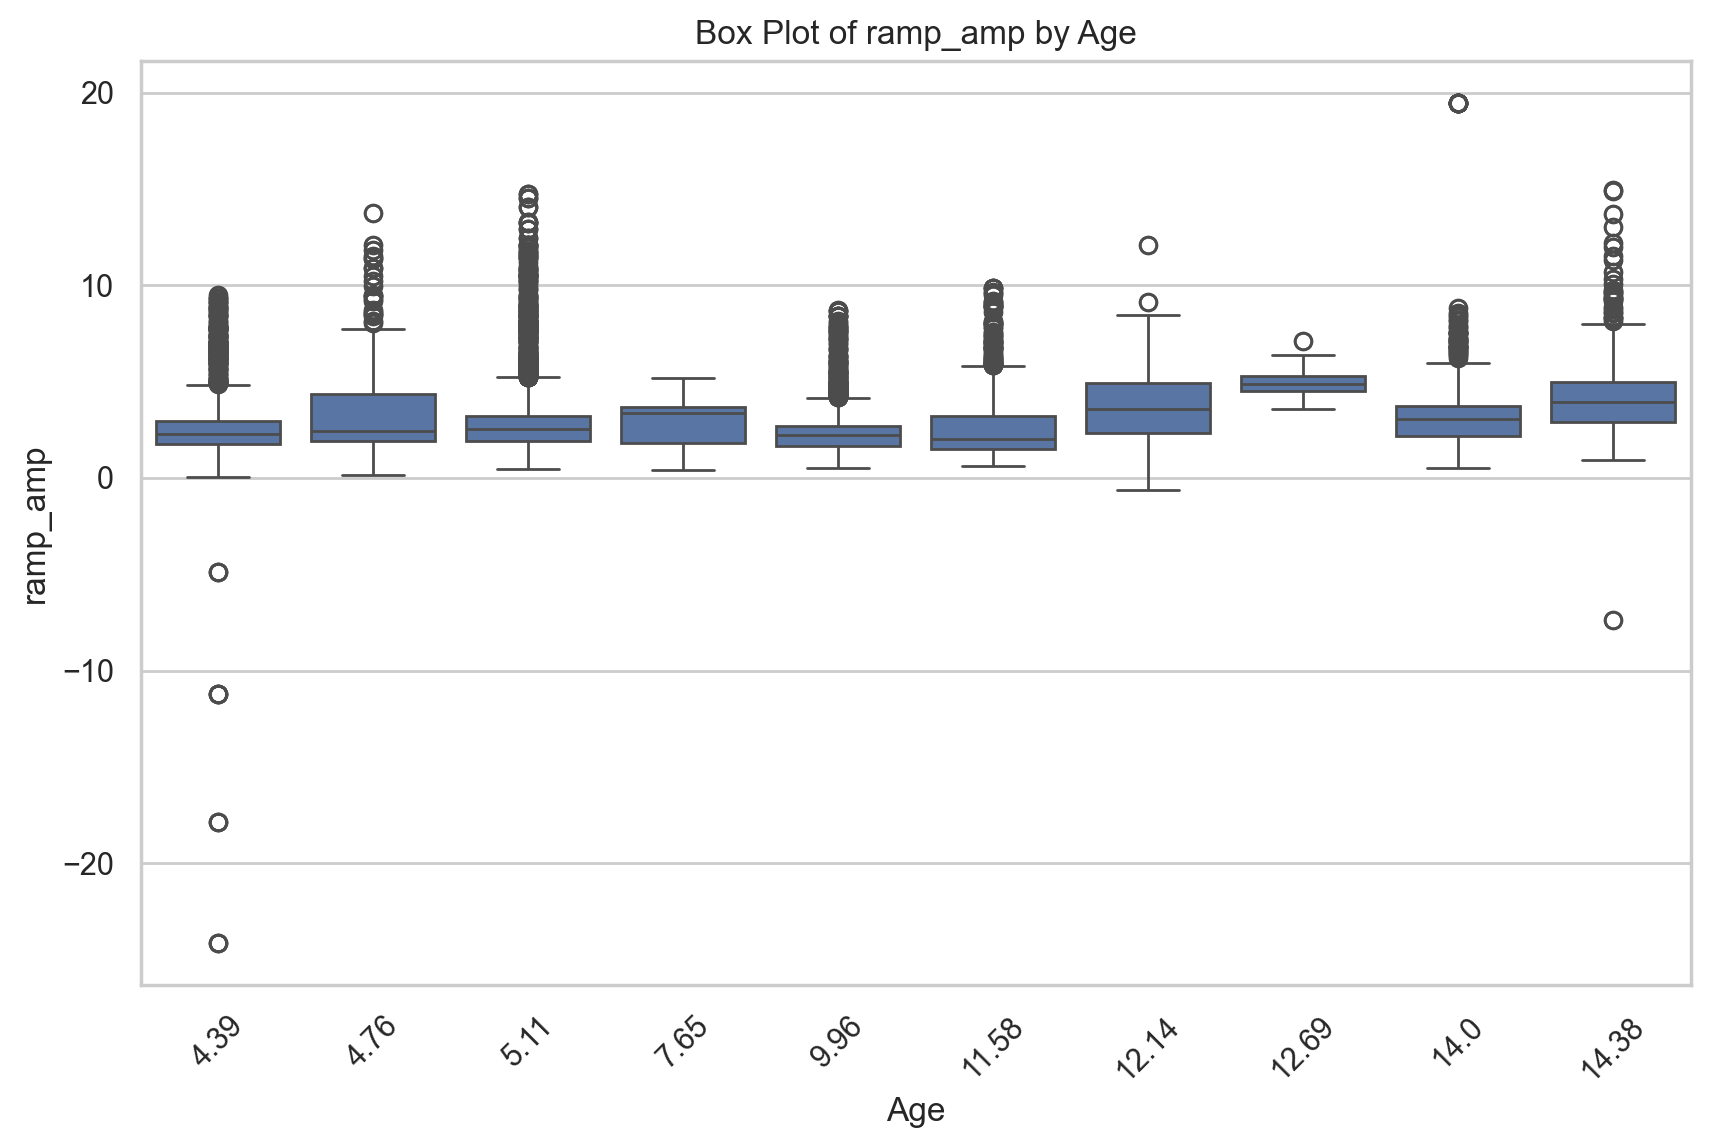

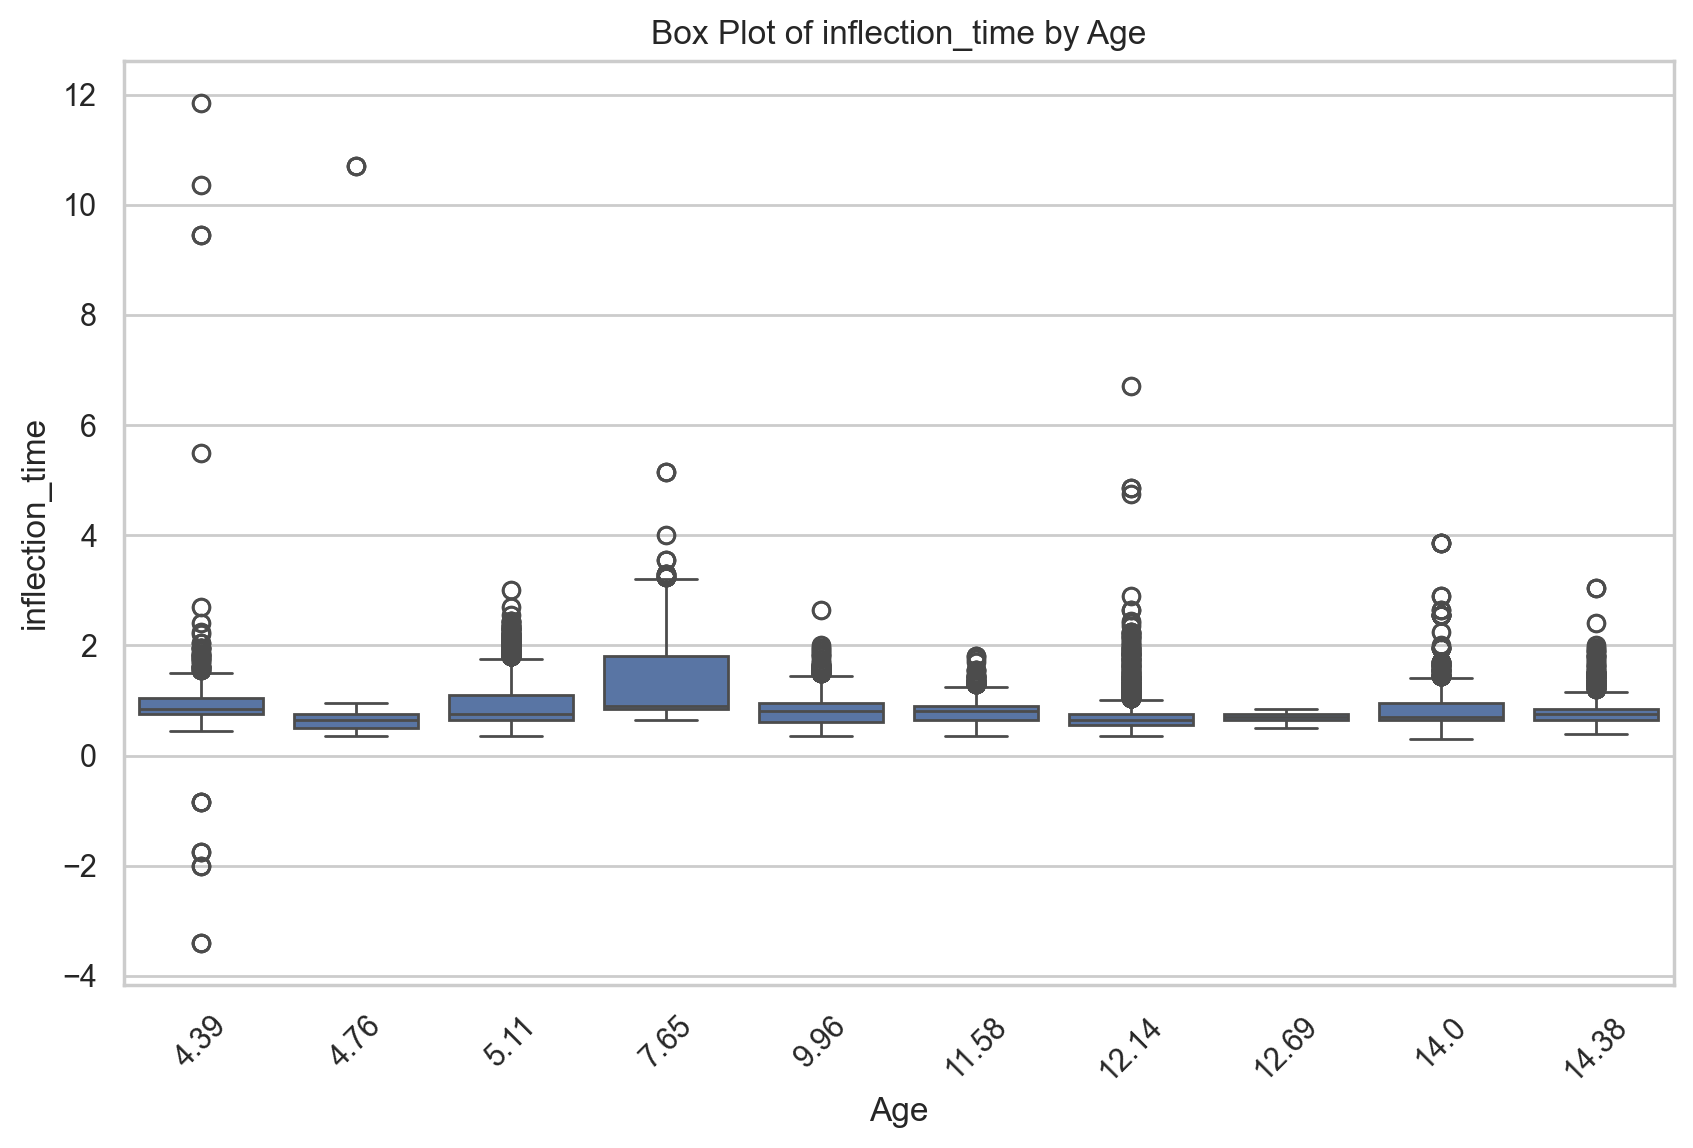

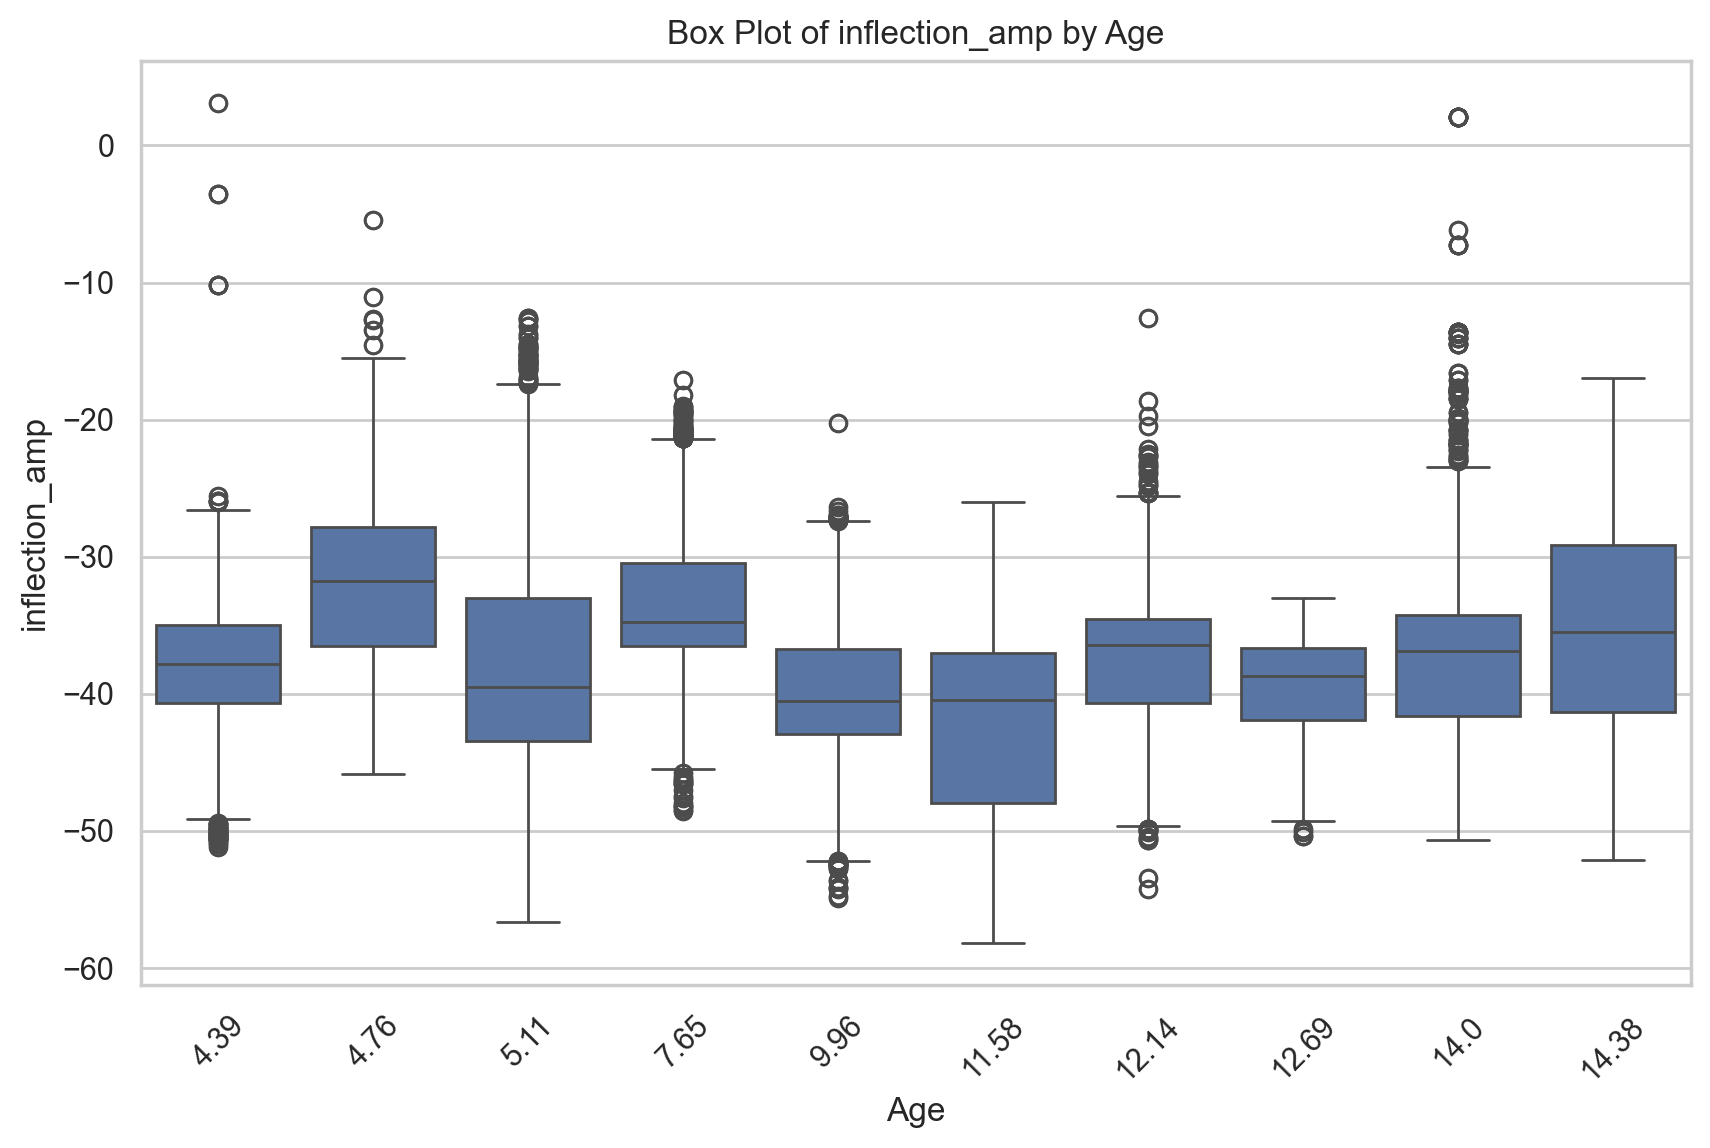

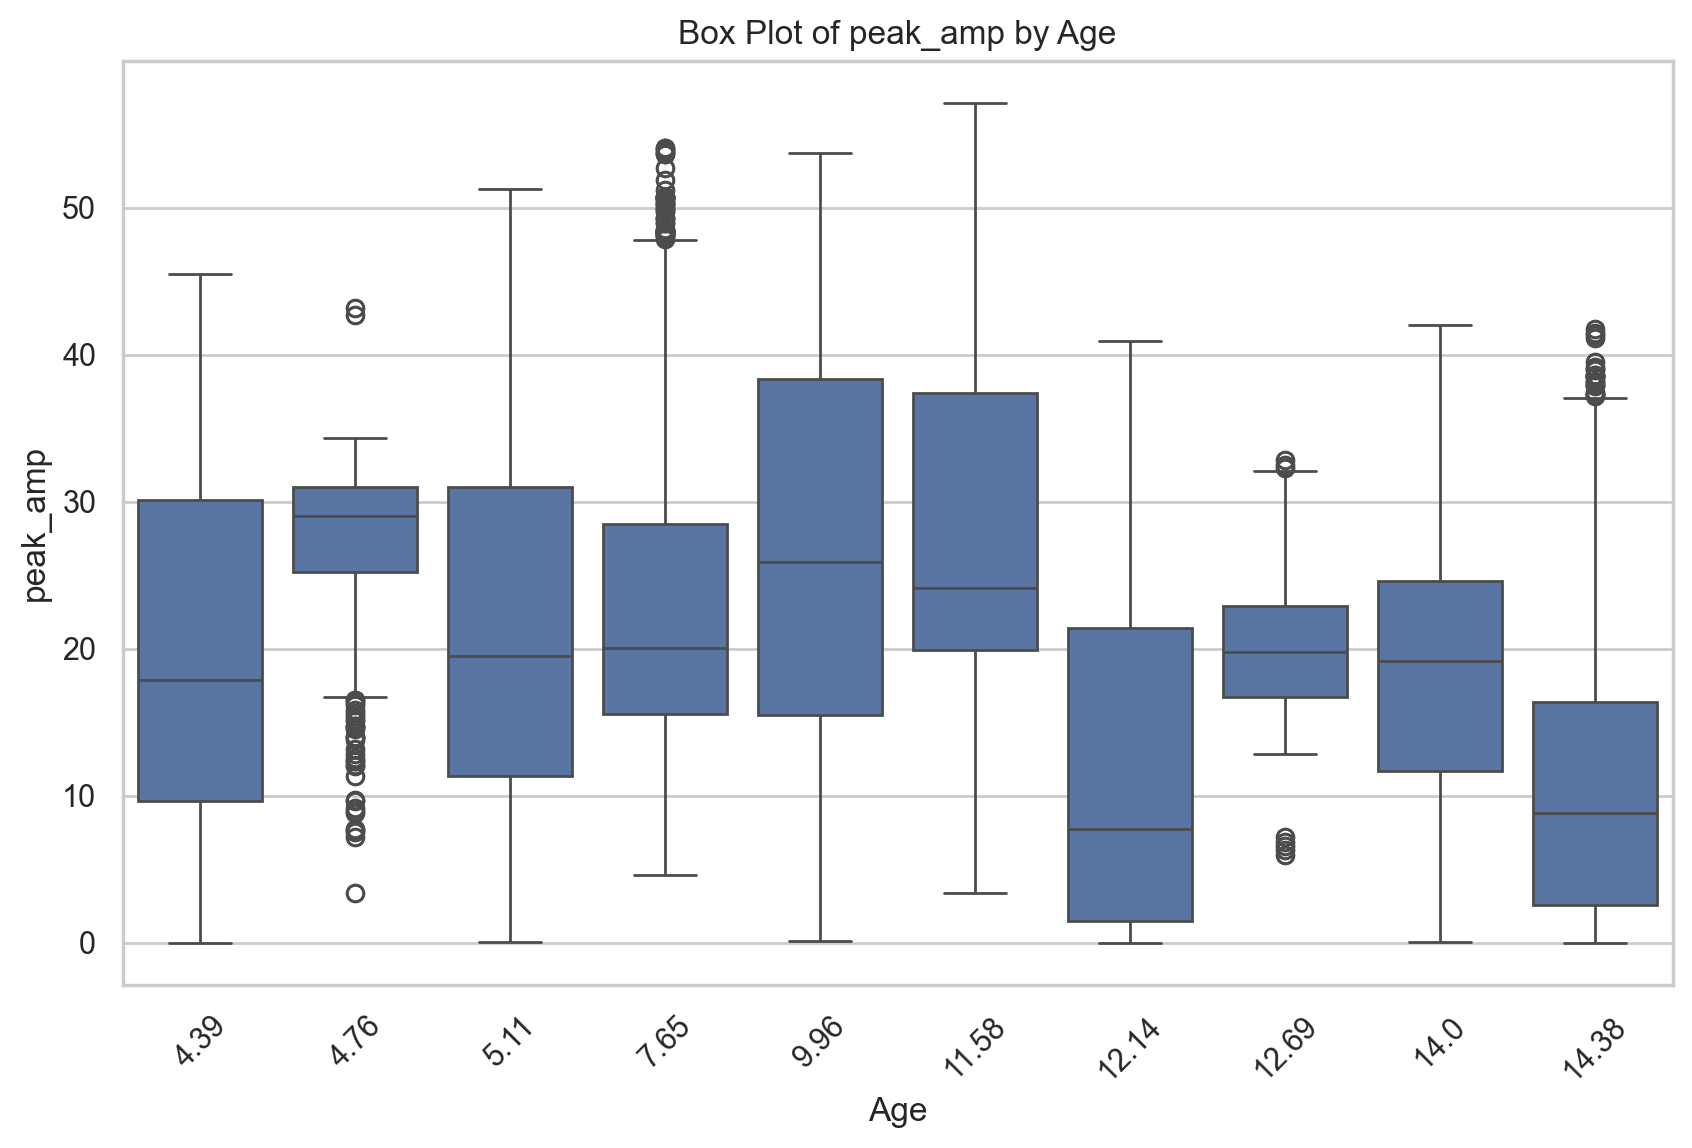

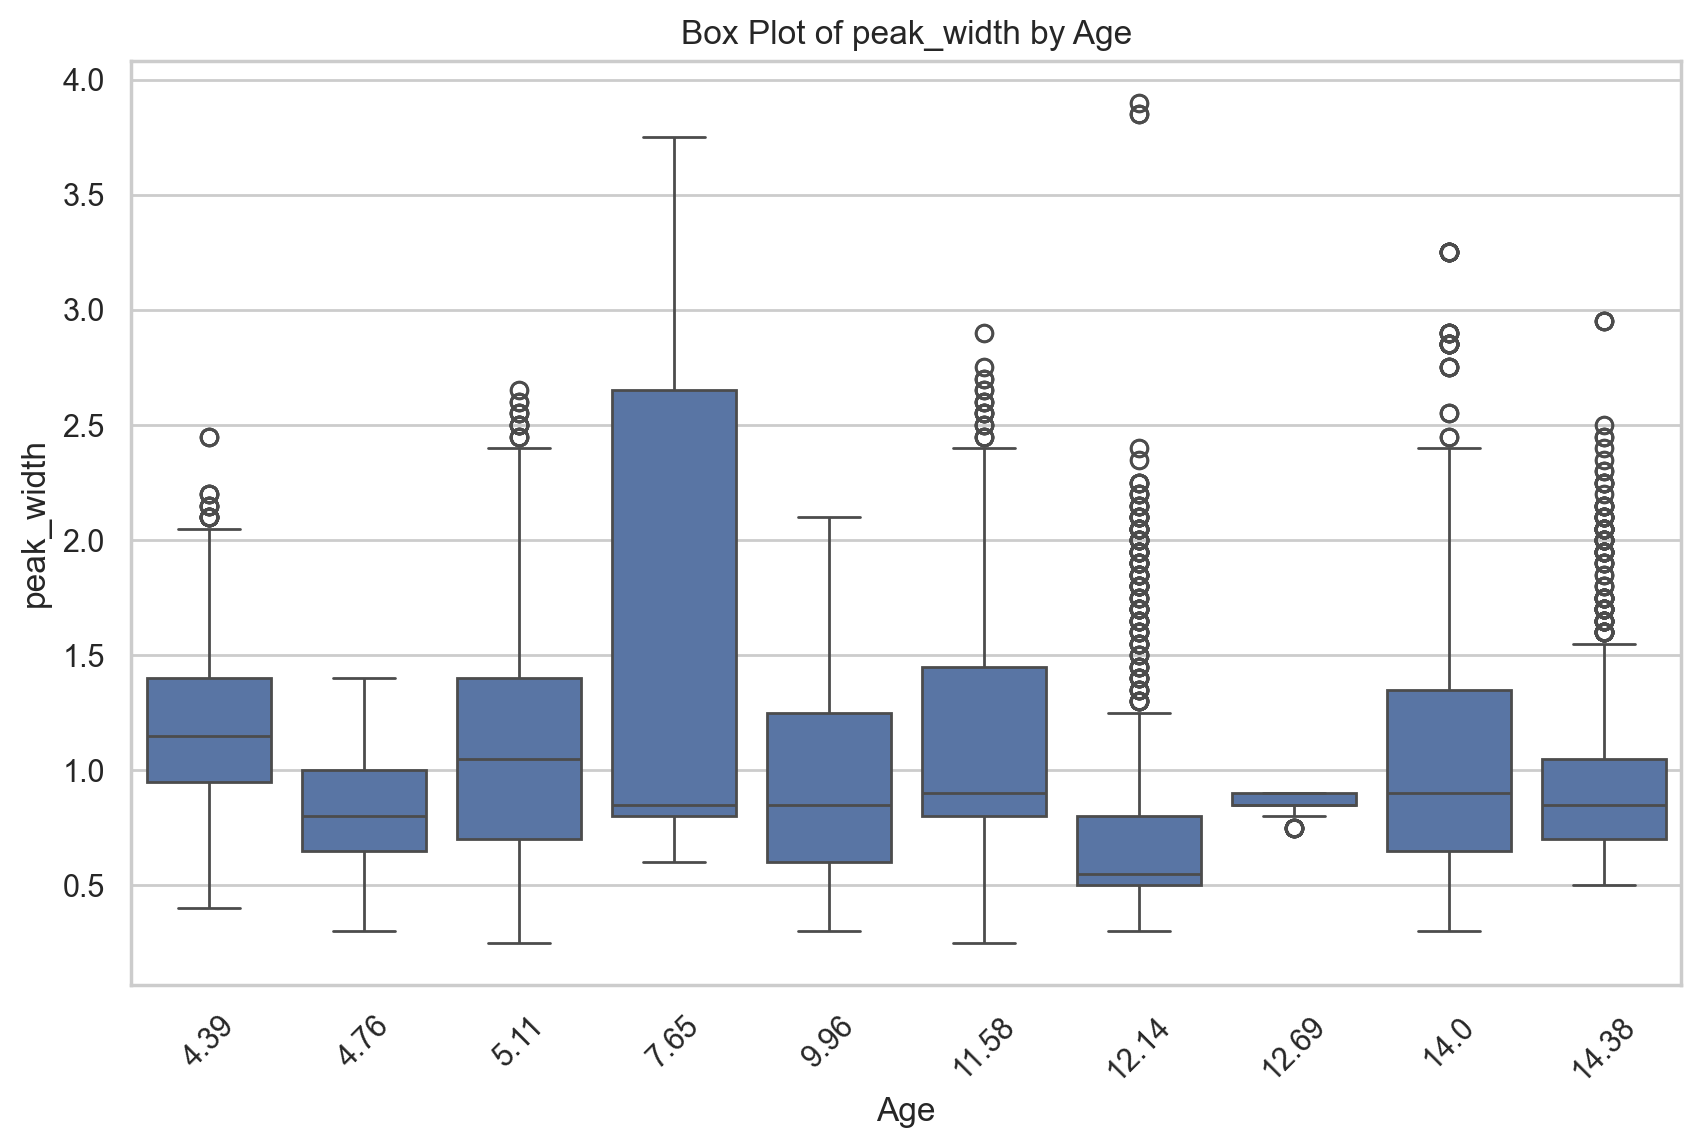

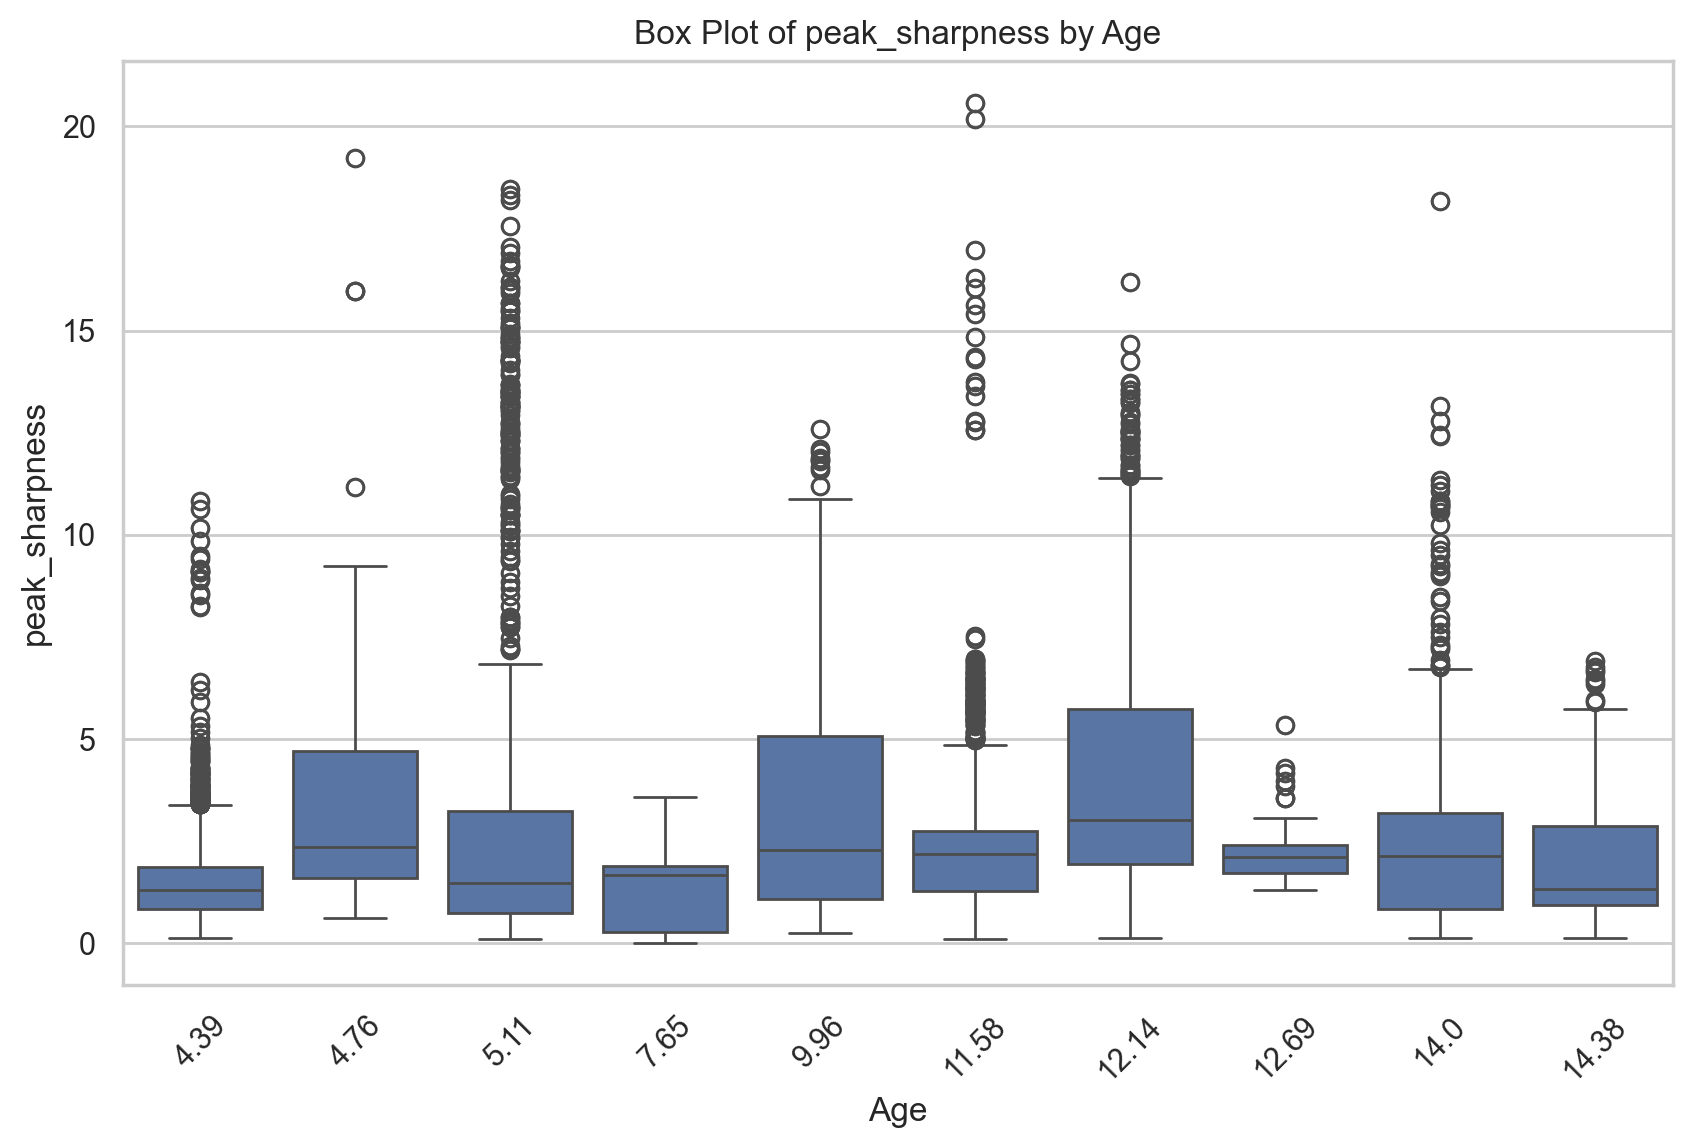

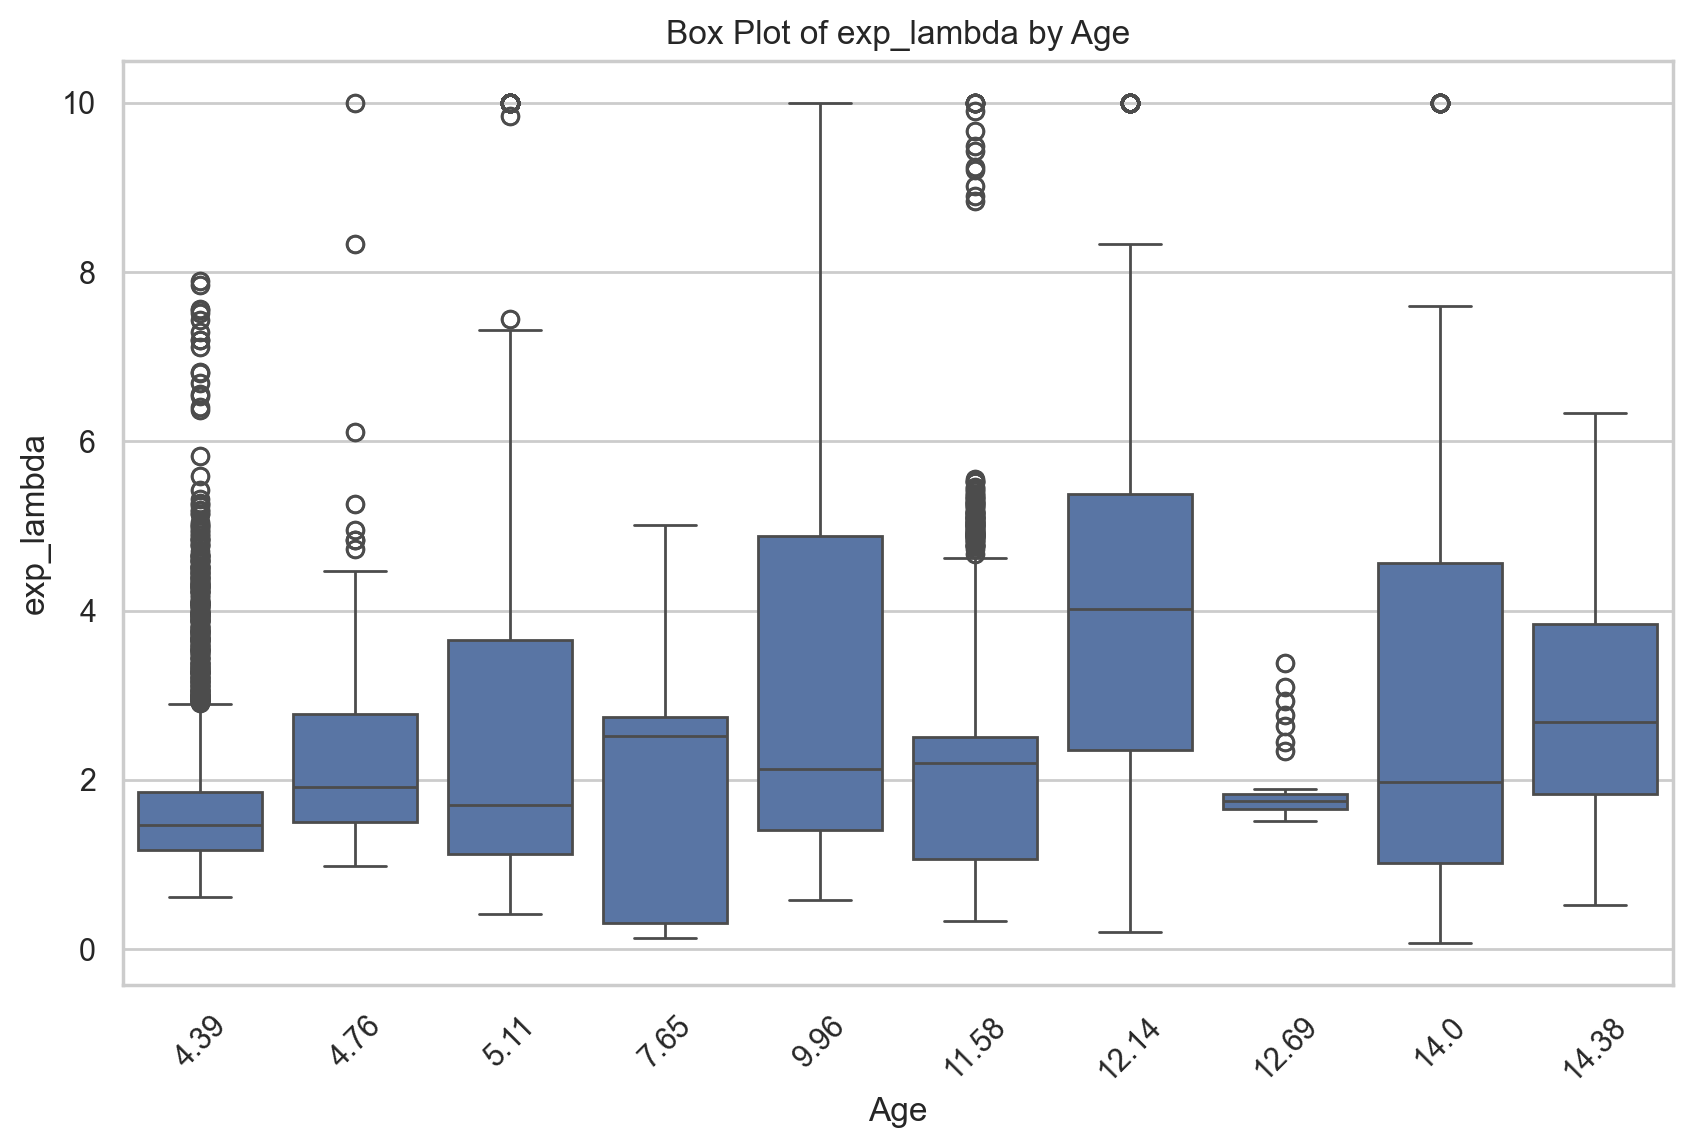

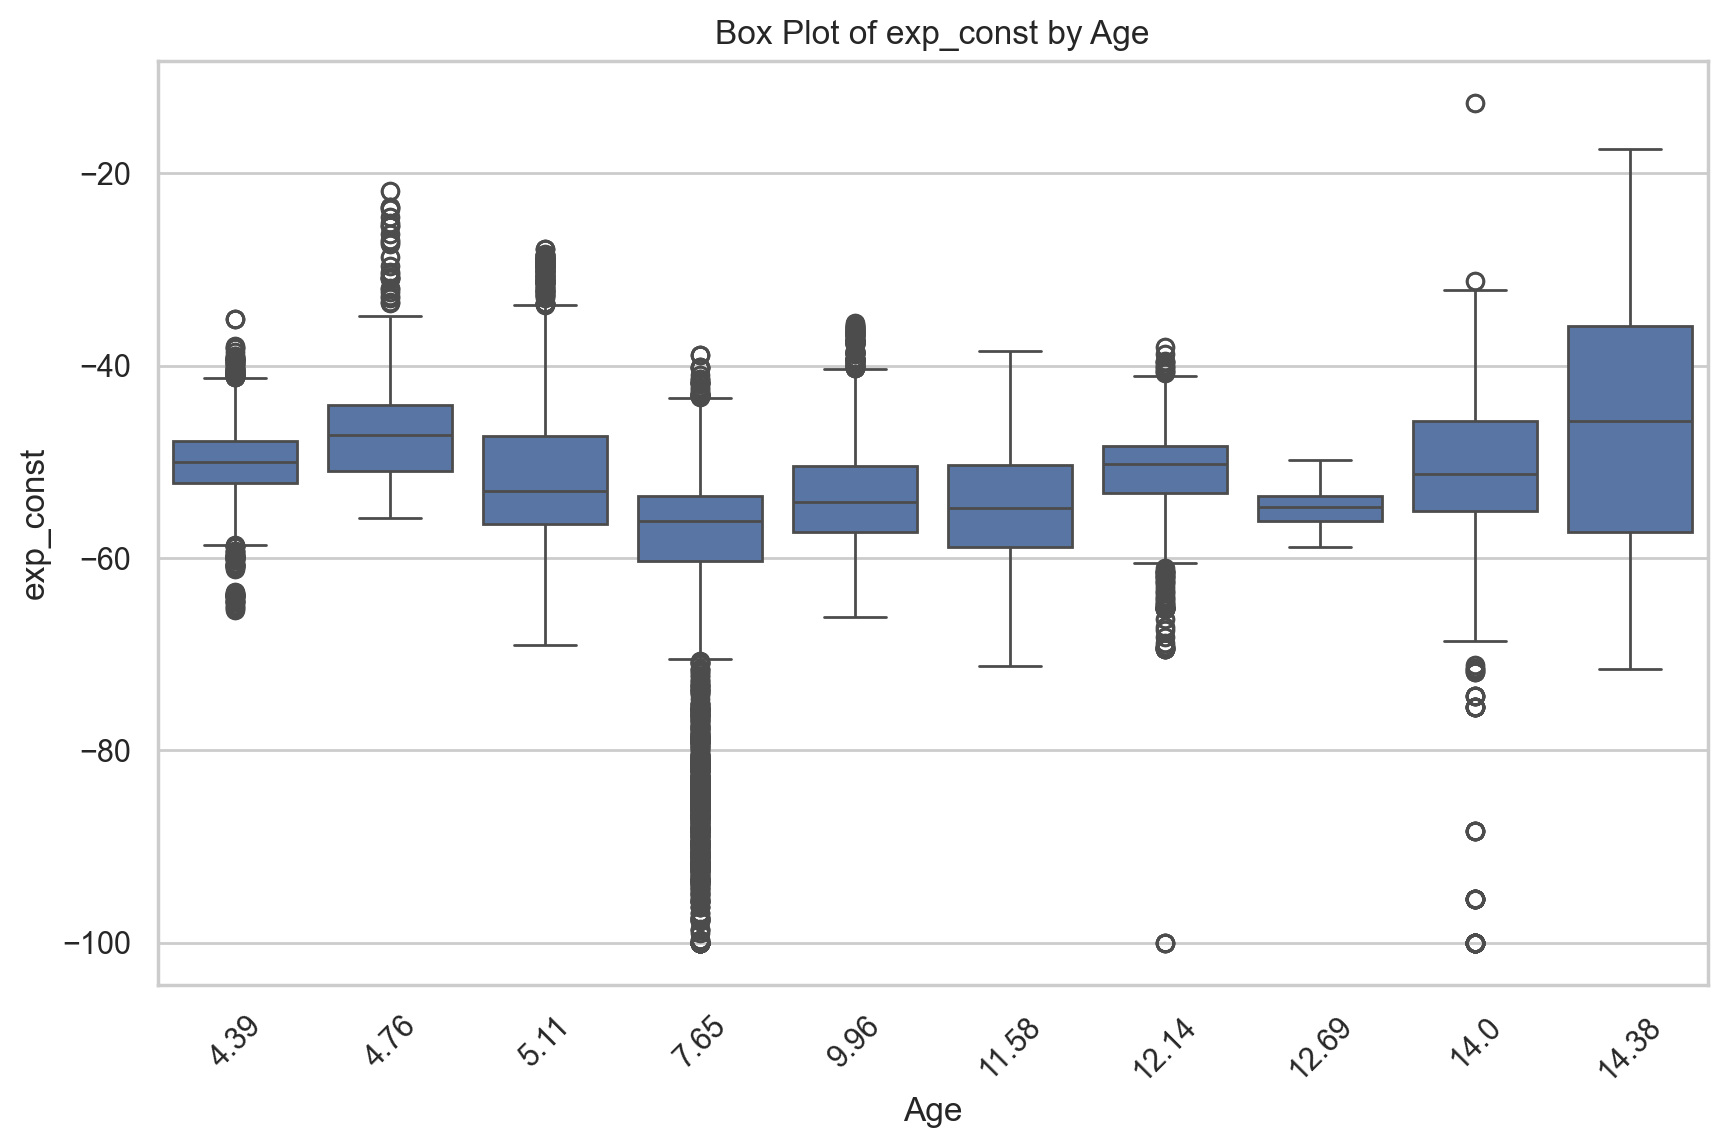

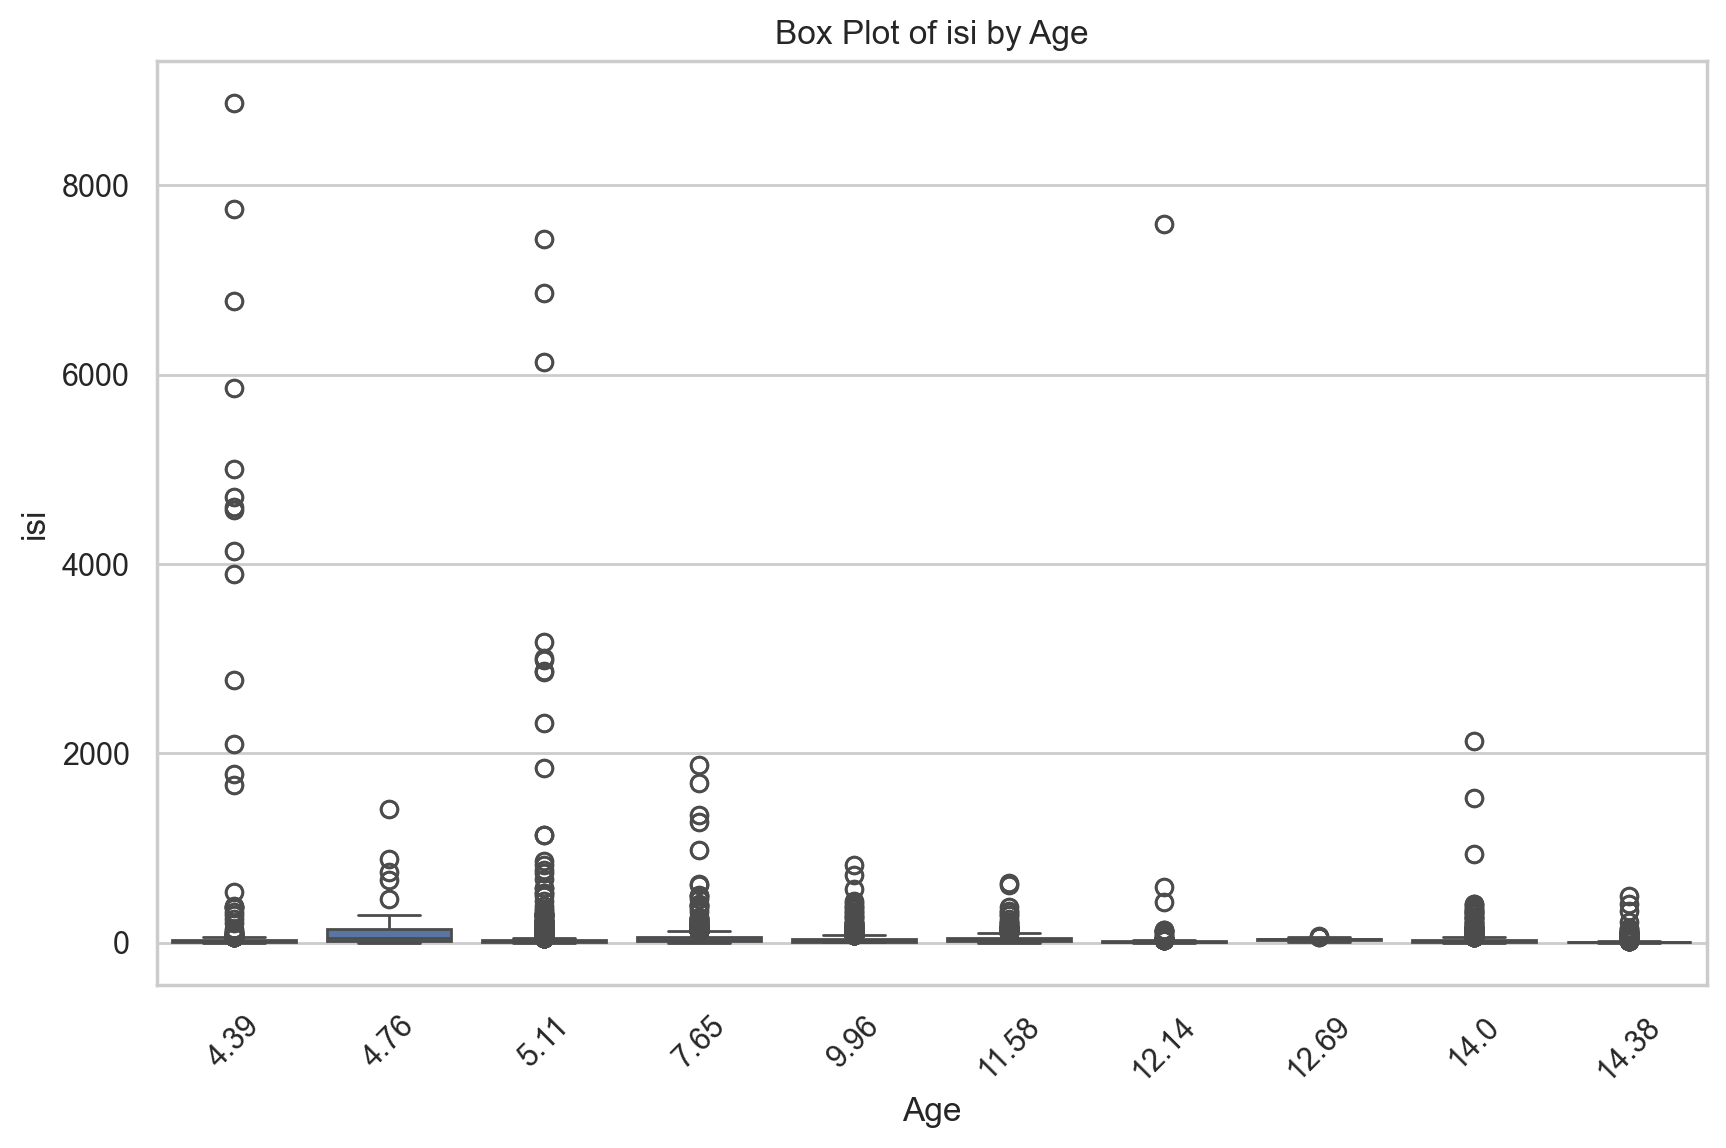

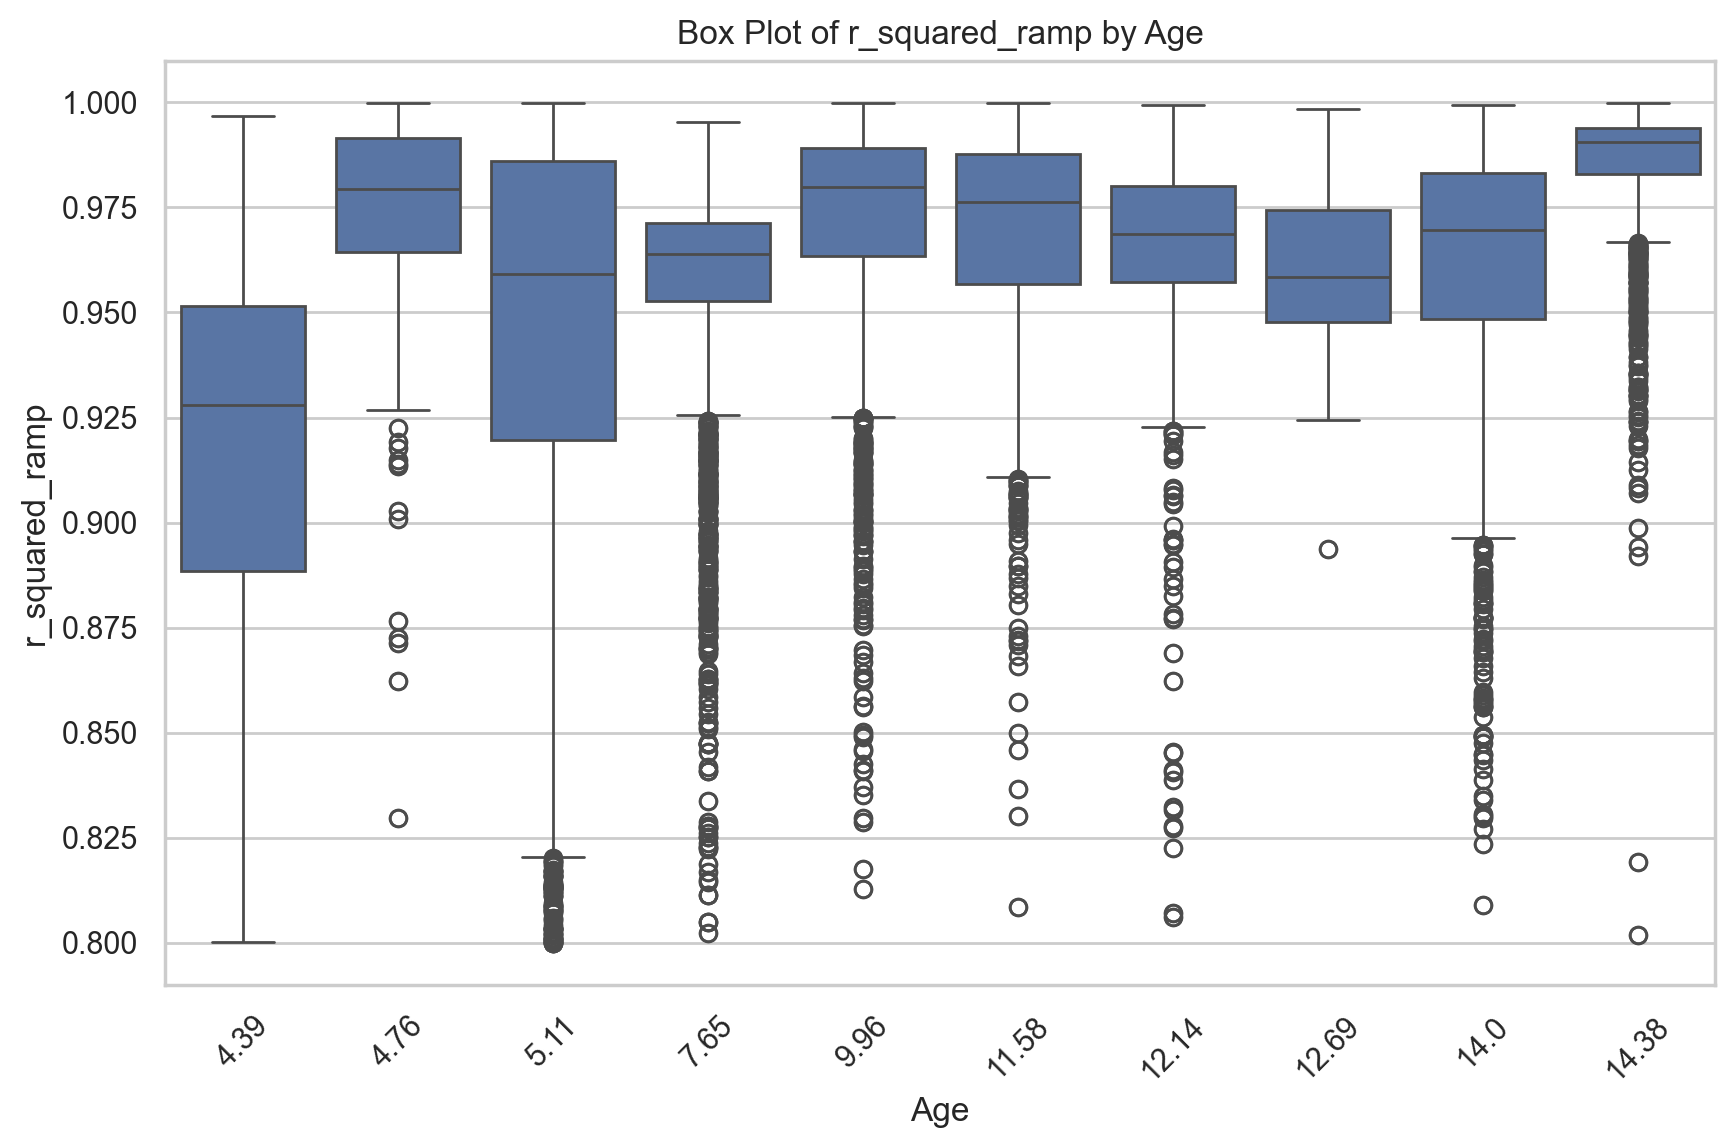

In [104]:
def boxplots_by_Param(param):
    """
    Generates box plots for specific columns in a DataFrame, grouped by a specified parameter.

    This function creates box plots for a predefined list of columns, with the data grouped by the values of the specified parameter. 
    The box plots provide a visual summary of the distribution of the data for each group, highlighting the median, quartiles, and potential outliers.

    Parameters:
    - param (str): The column name in the DataFrame by which to group the data.
        Each unique value in this column will form a separate group in the box plots.

    Returns:
    None: The function displays the box plots.
    """
    # Set the style of the plots
    sns.set(style="whitegrid")
    
    # Define the list of columns to plot
    columns_to_plot = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 
                       'peak_sharpness', 'exp_lambda', 'exp_const', 'isi', 'r_squared_ramp']
    
    # Create box plots for each column controlling for 'brainOrigin'
    for column in columns_to_plot:
        plt.figure(figsize=(10, 6))
        
        sns.boxplot(x=param, y=column, data=allMonkey_df_filt)
        plt.title(f'Box Plot of {column} by {param}')
        plt.xlabel(param)
        plt.ylabel(column)
        plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
        plt.show()

boxplots_by_Param('Age')

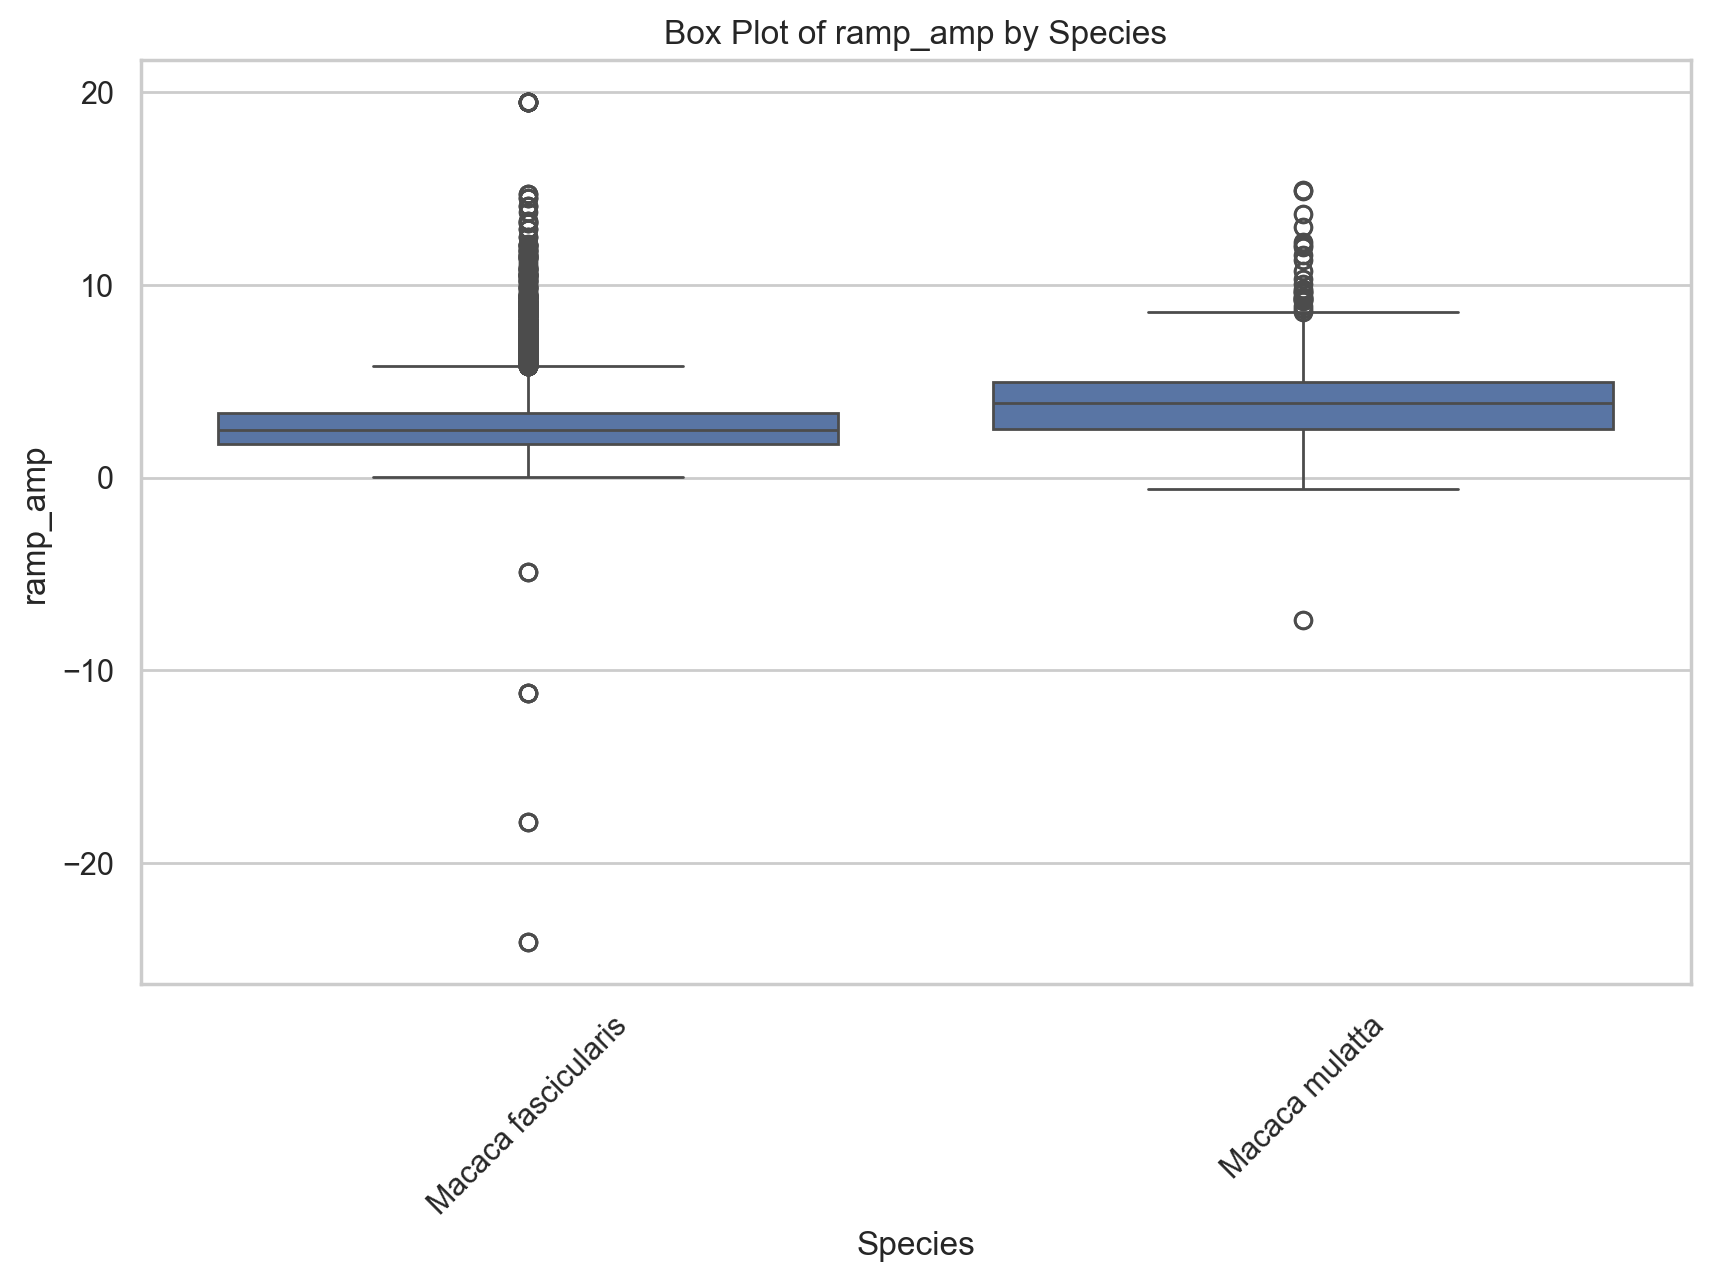

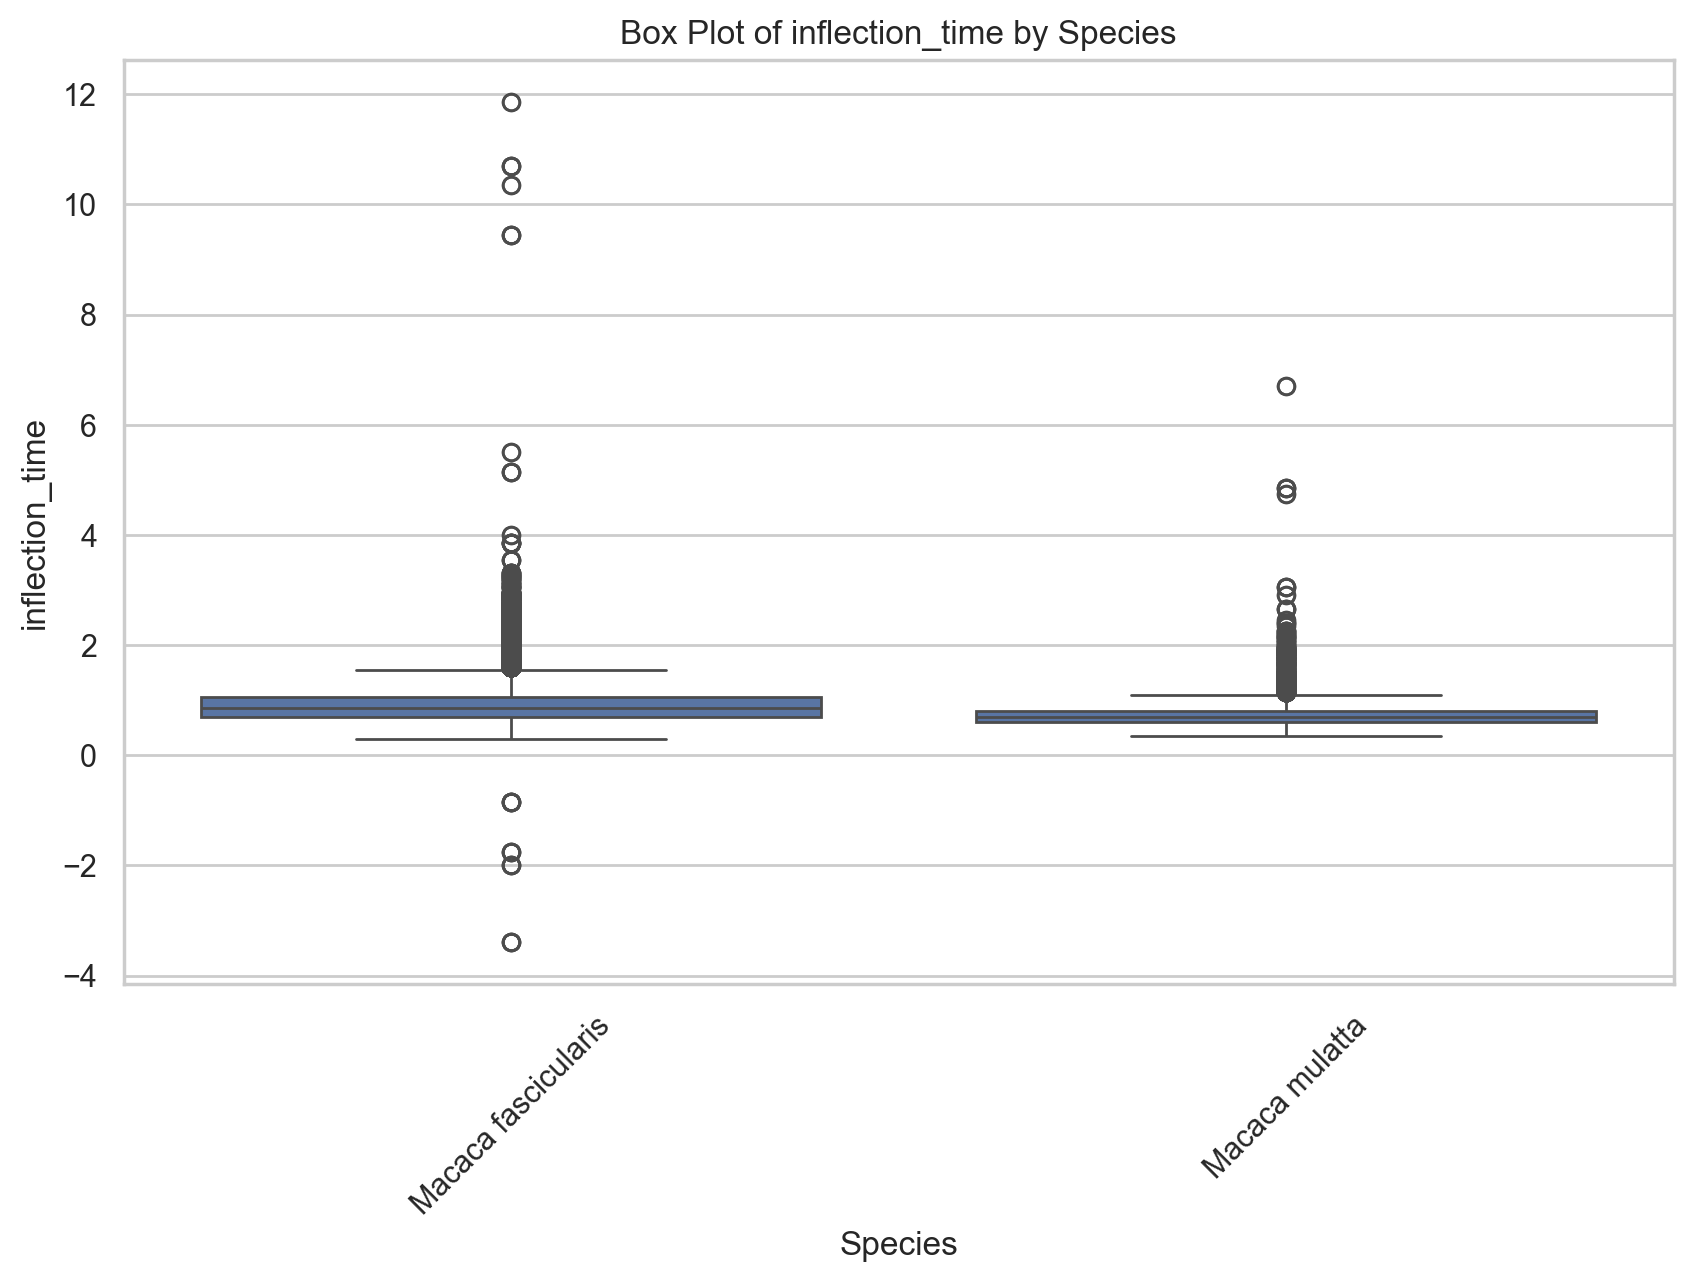

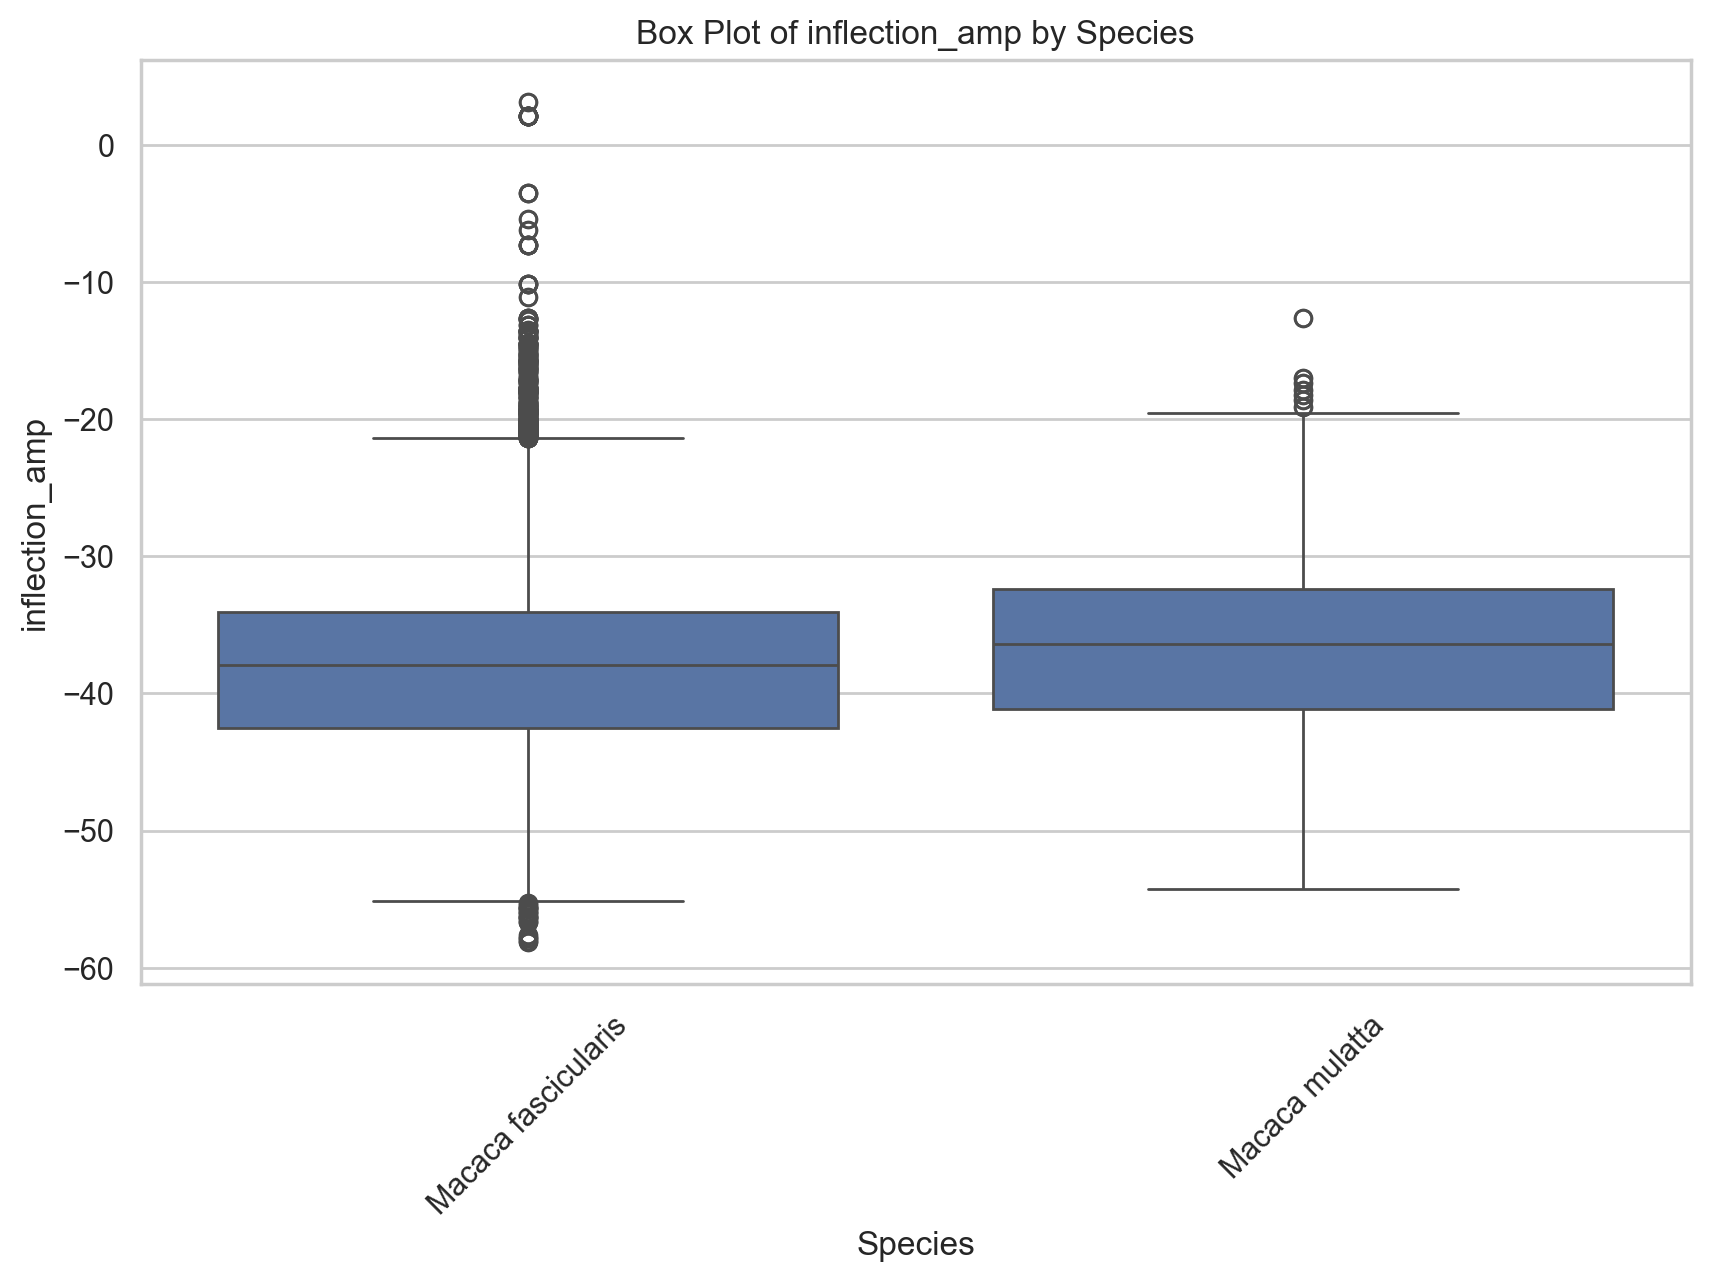

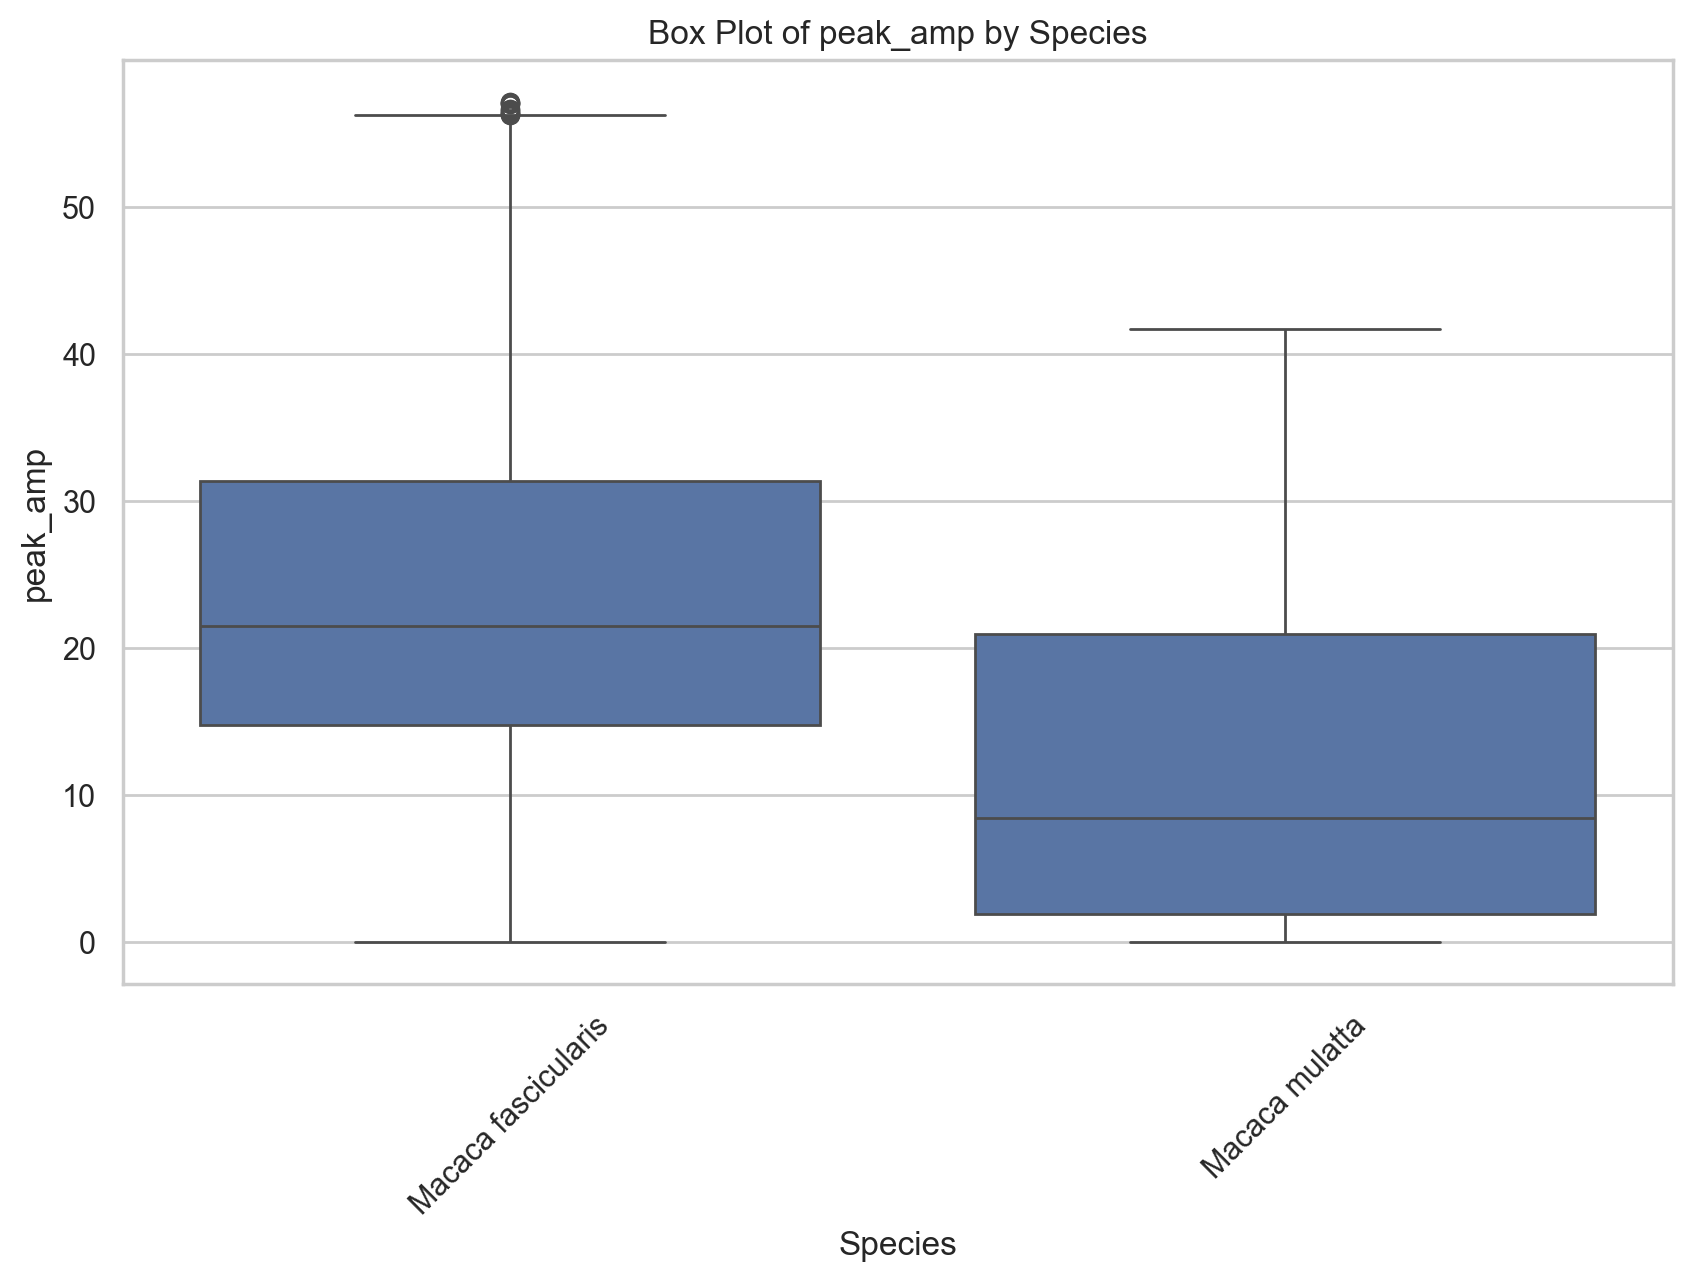

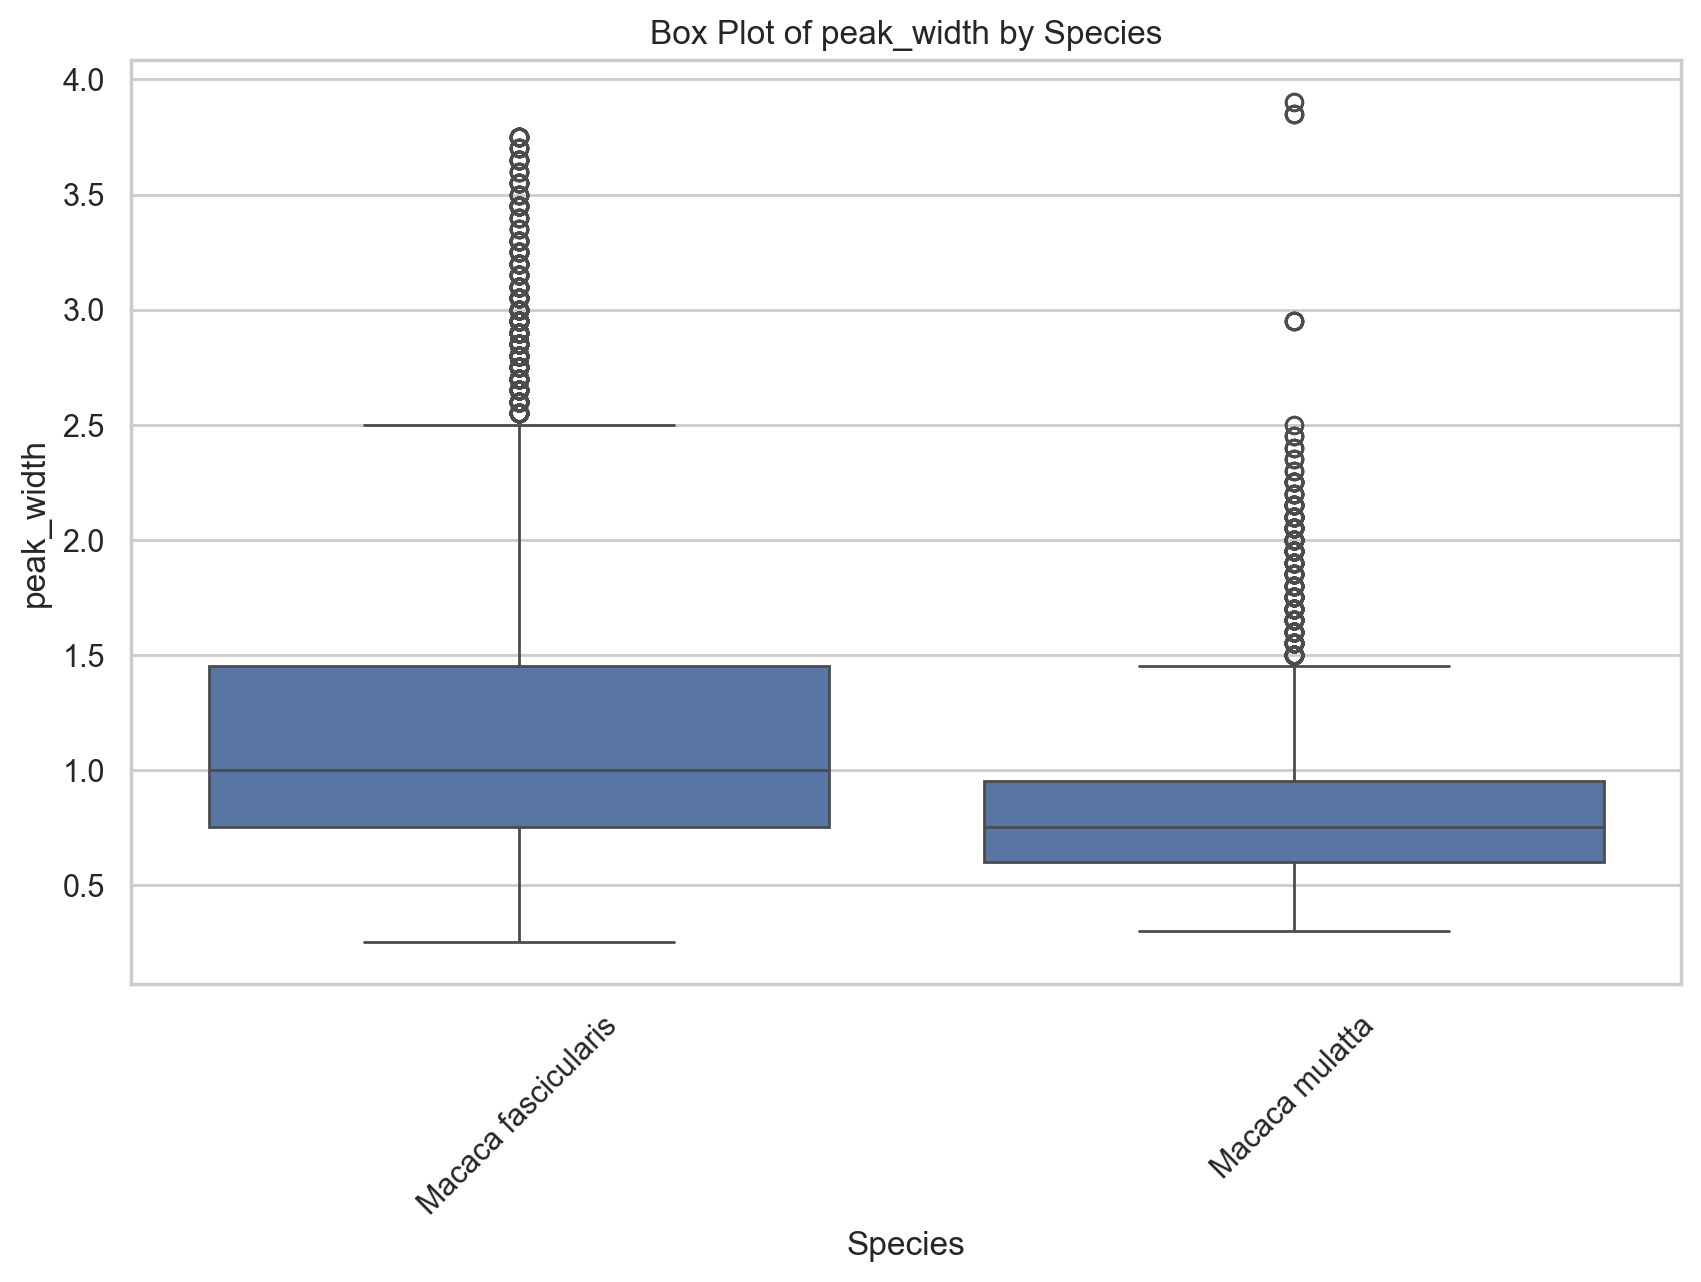

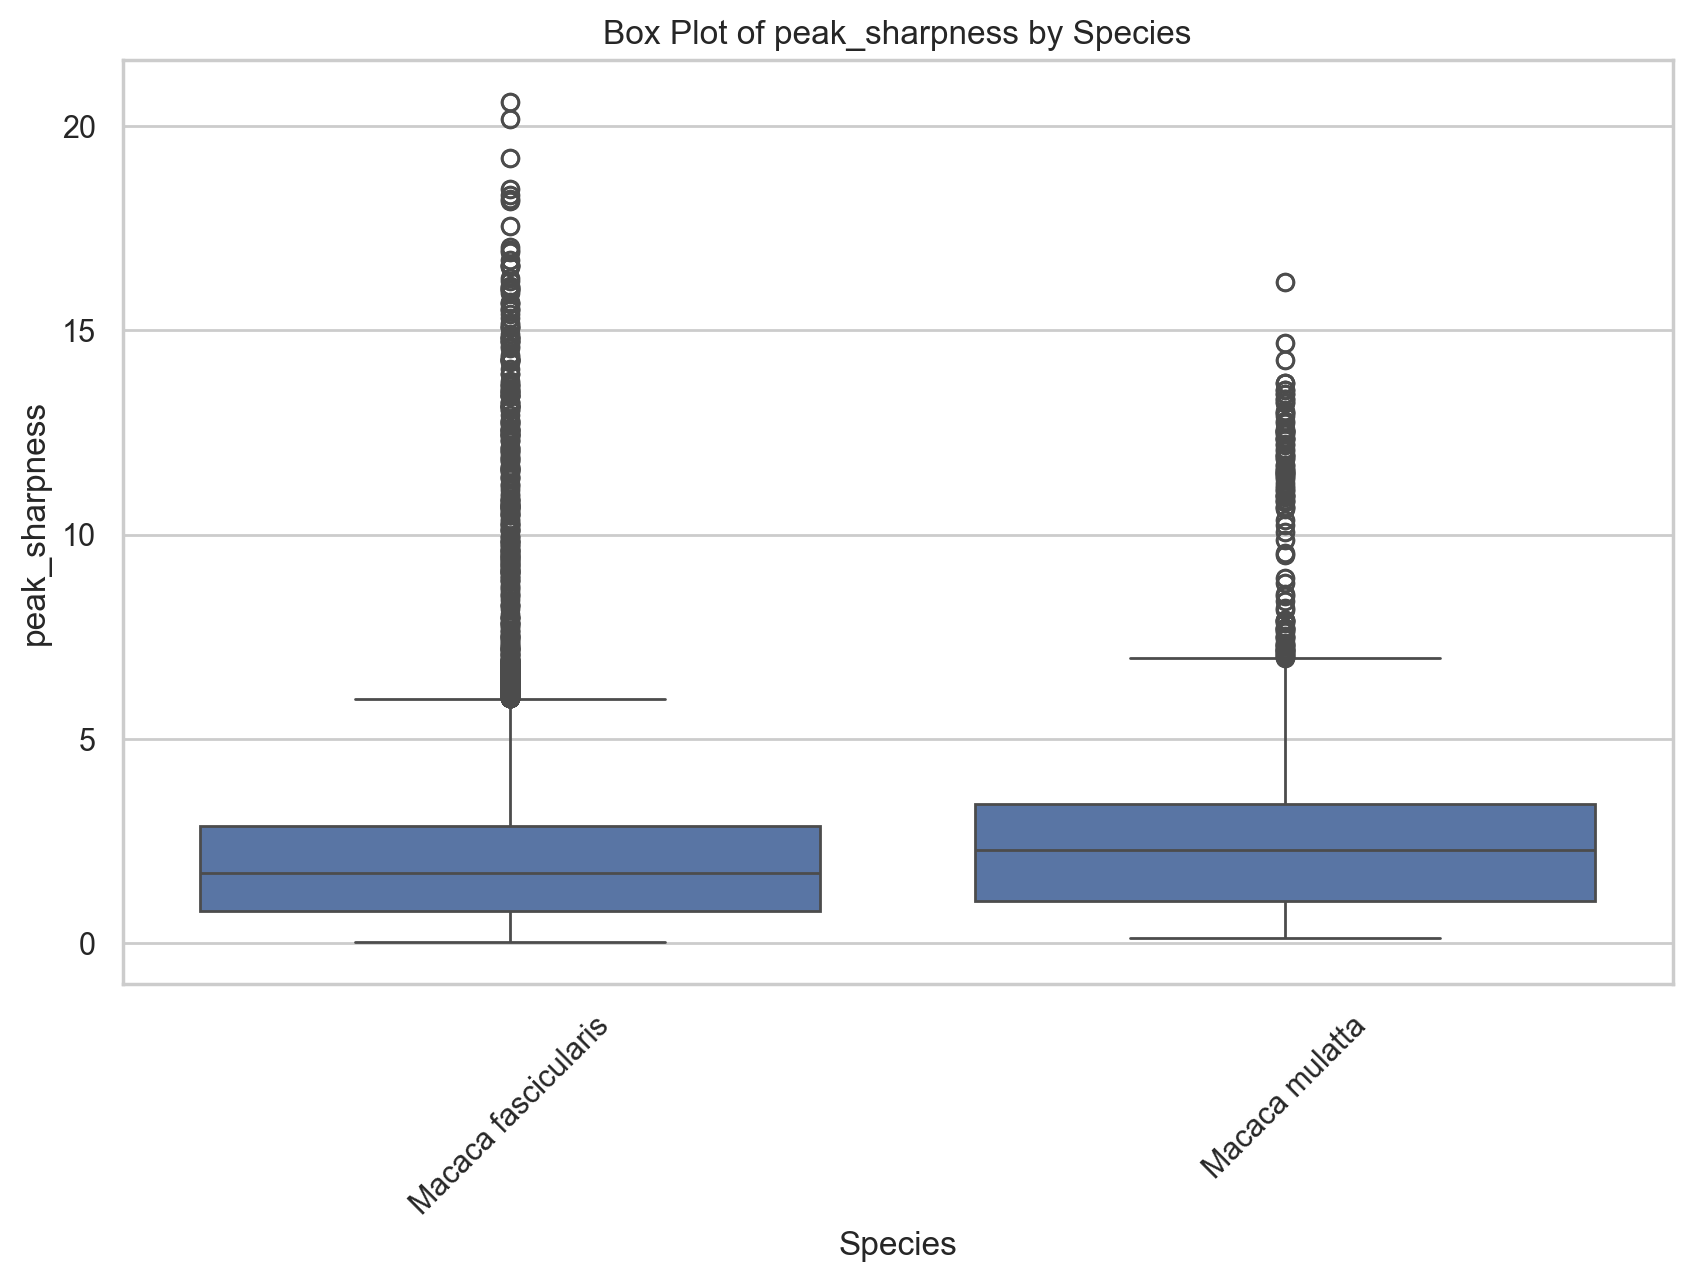

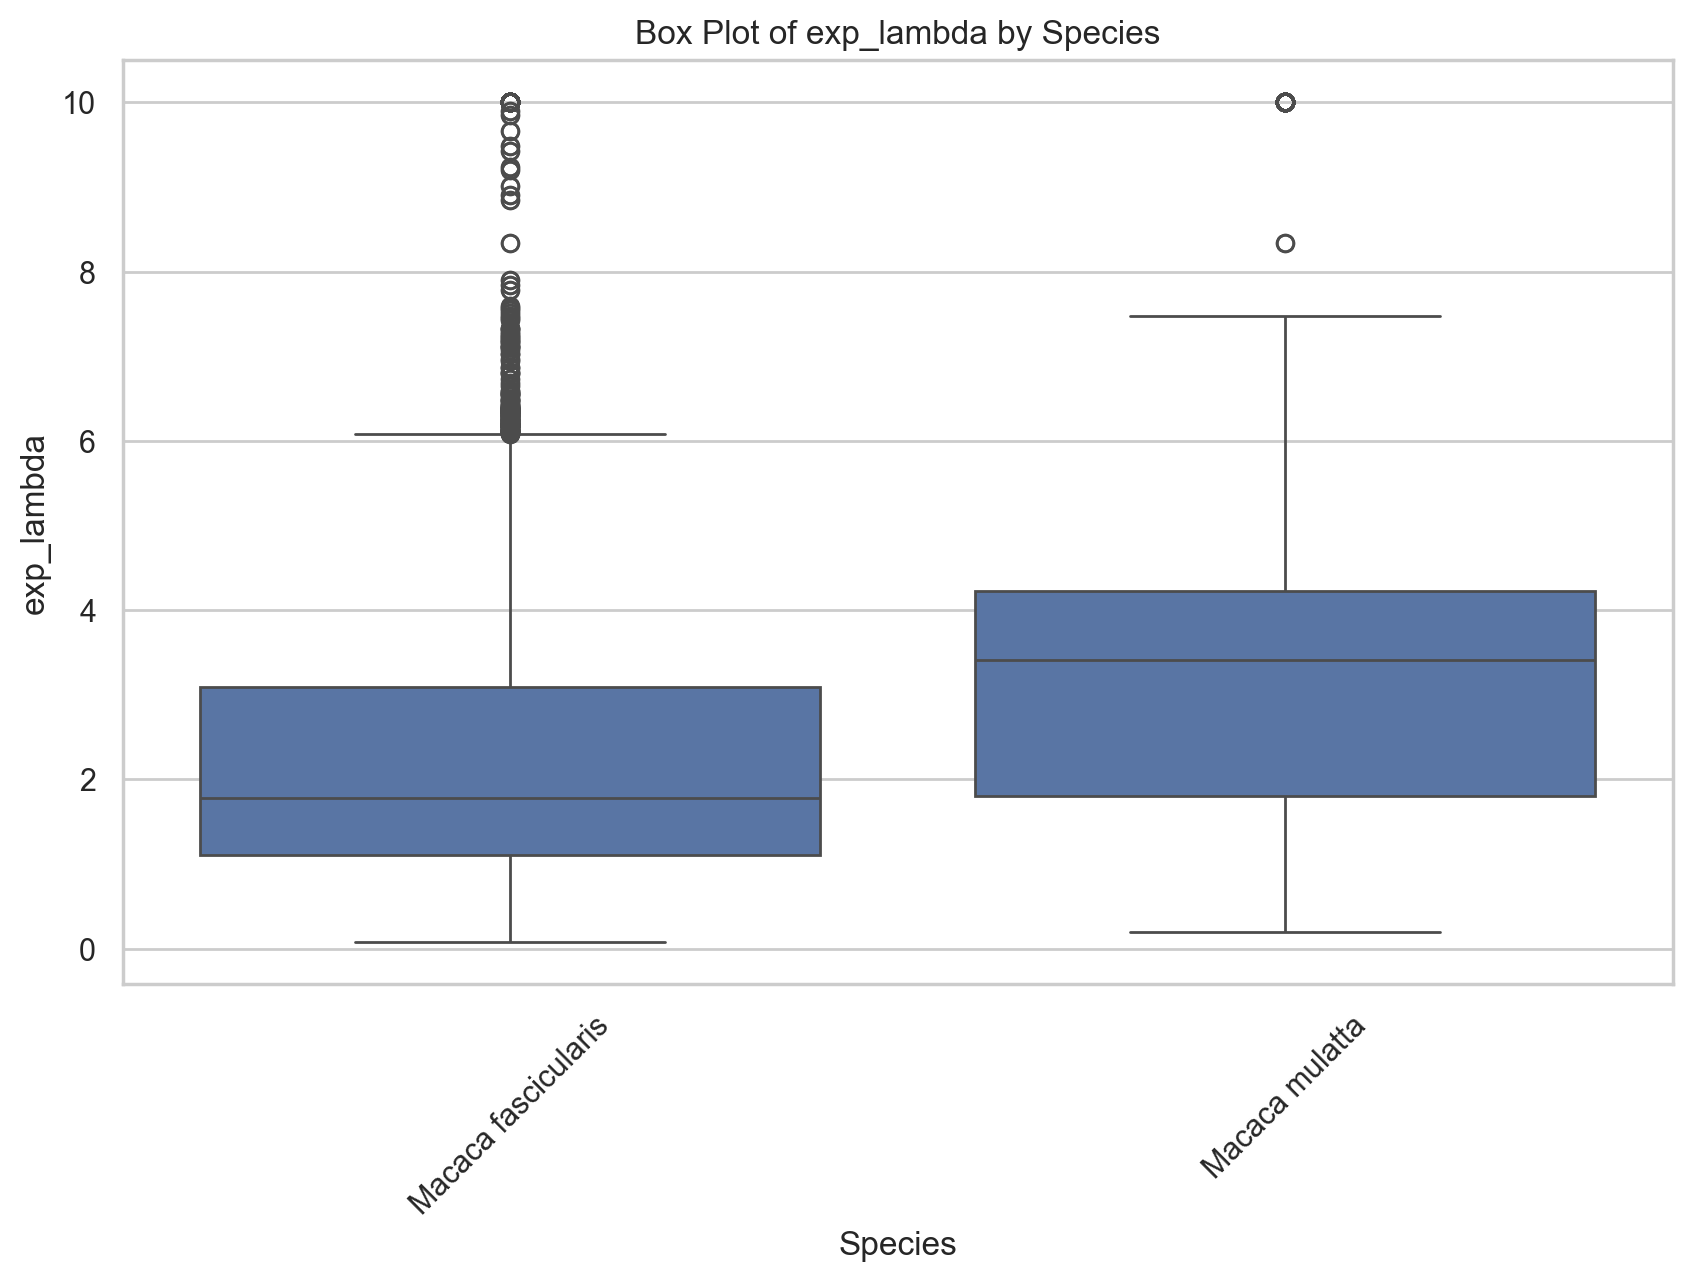

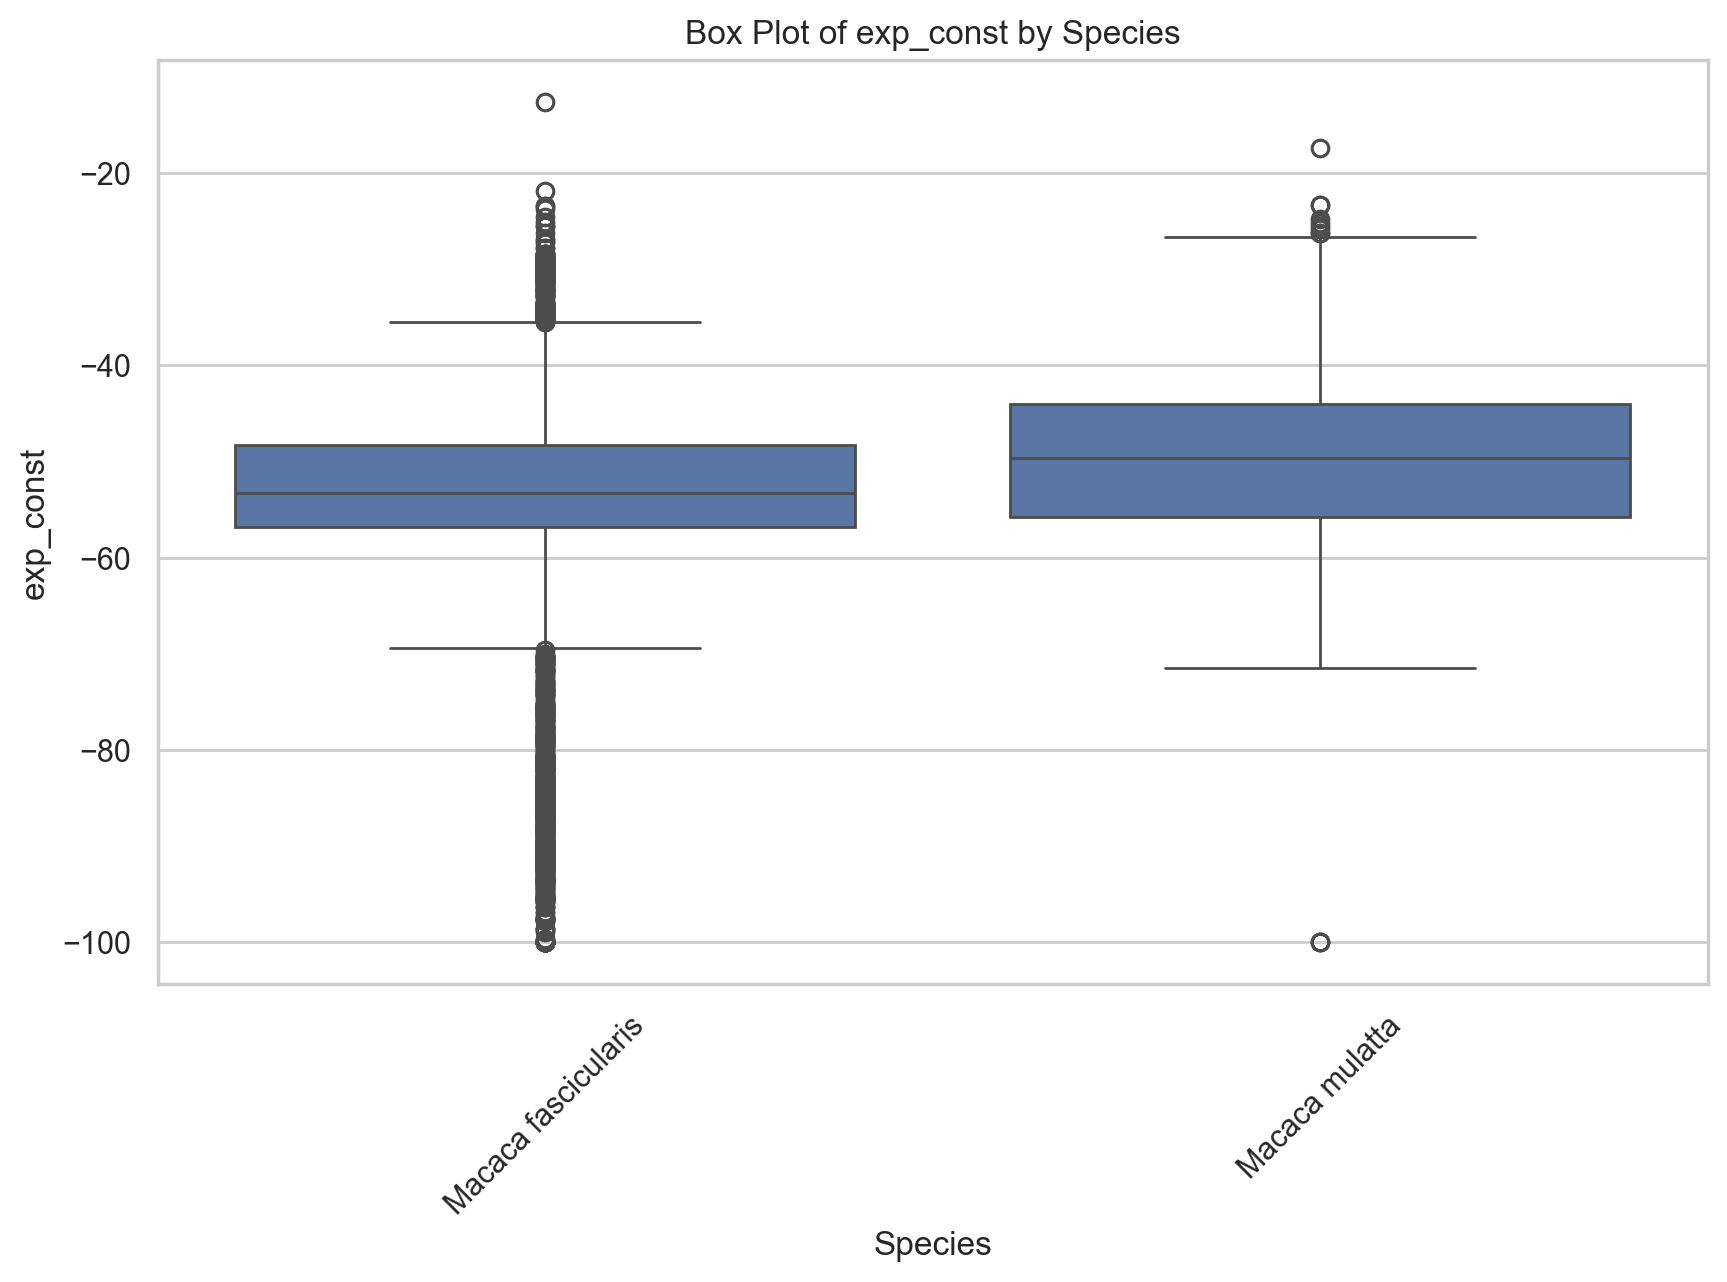

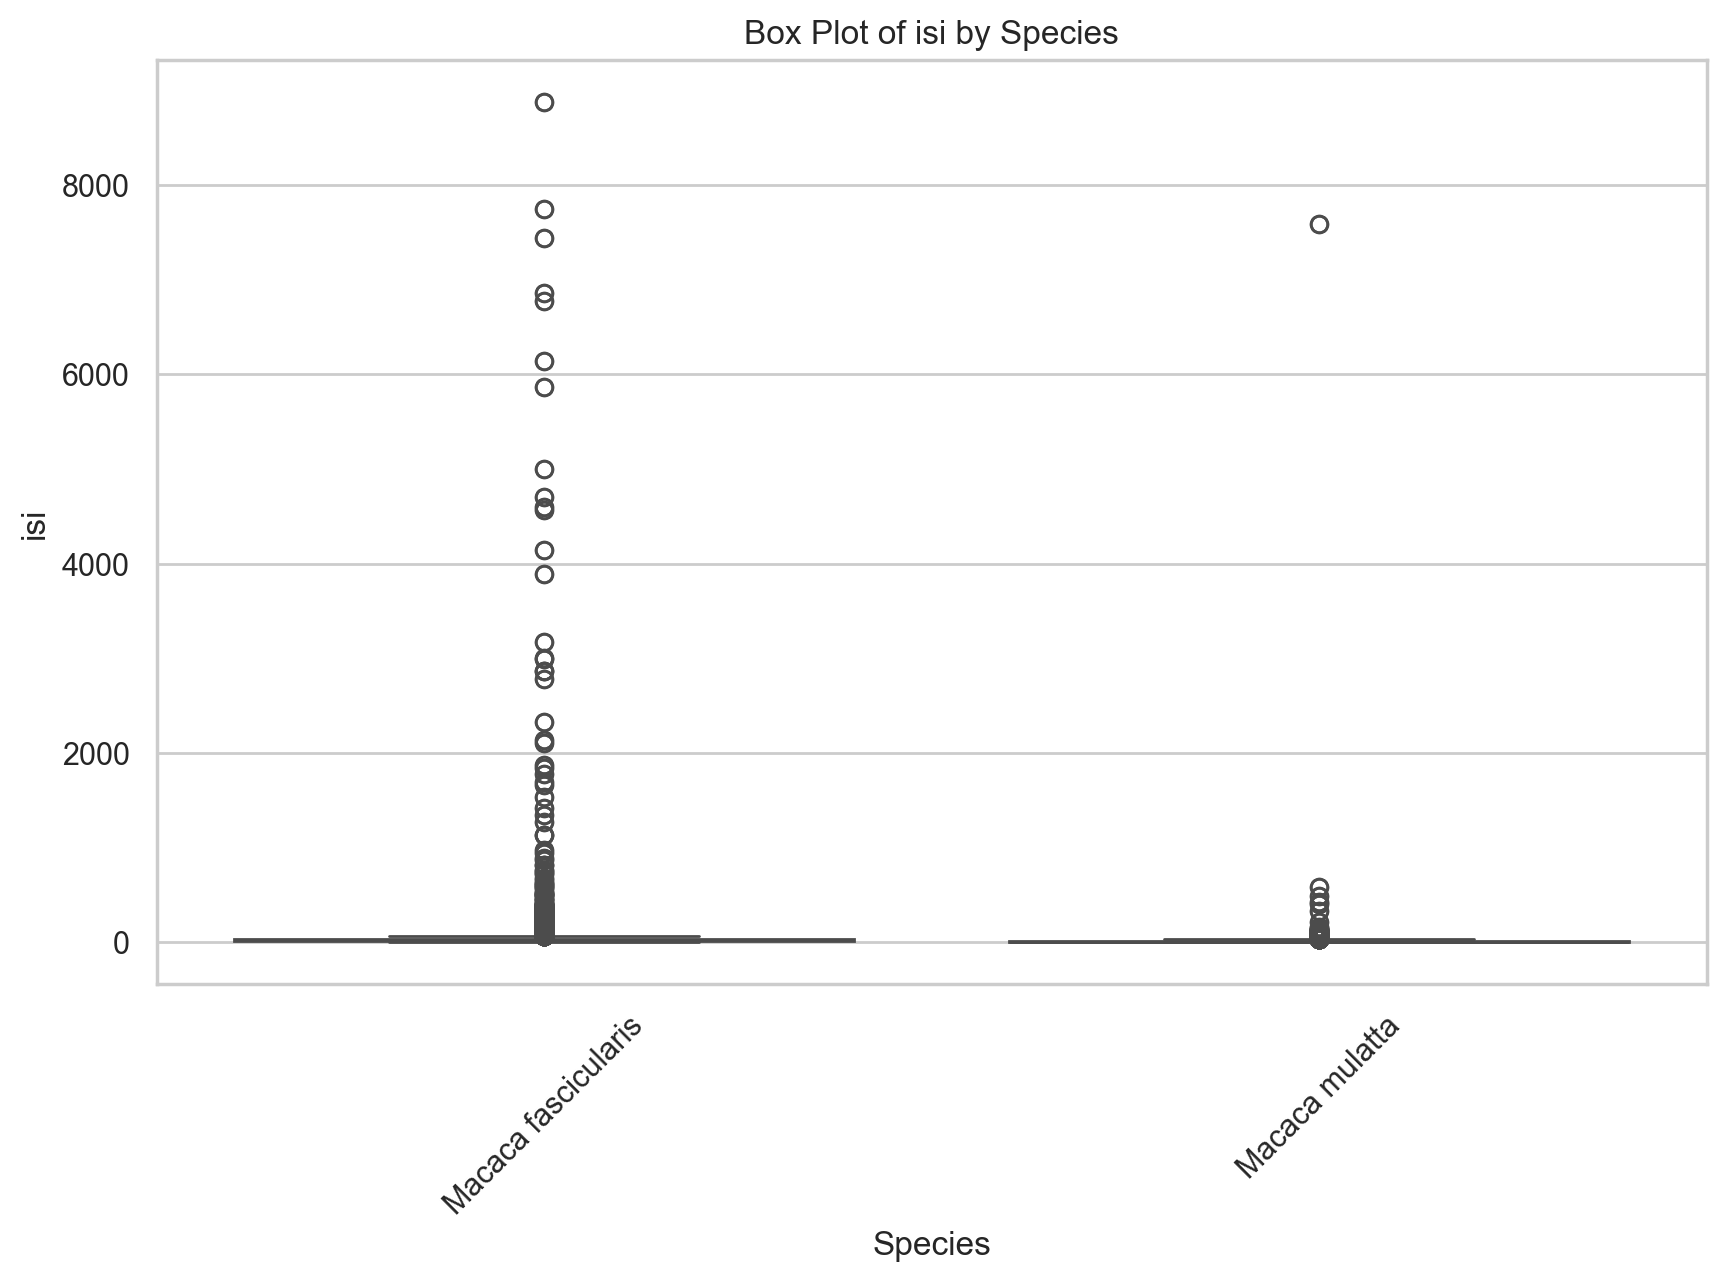

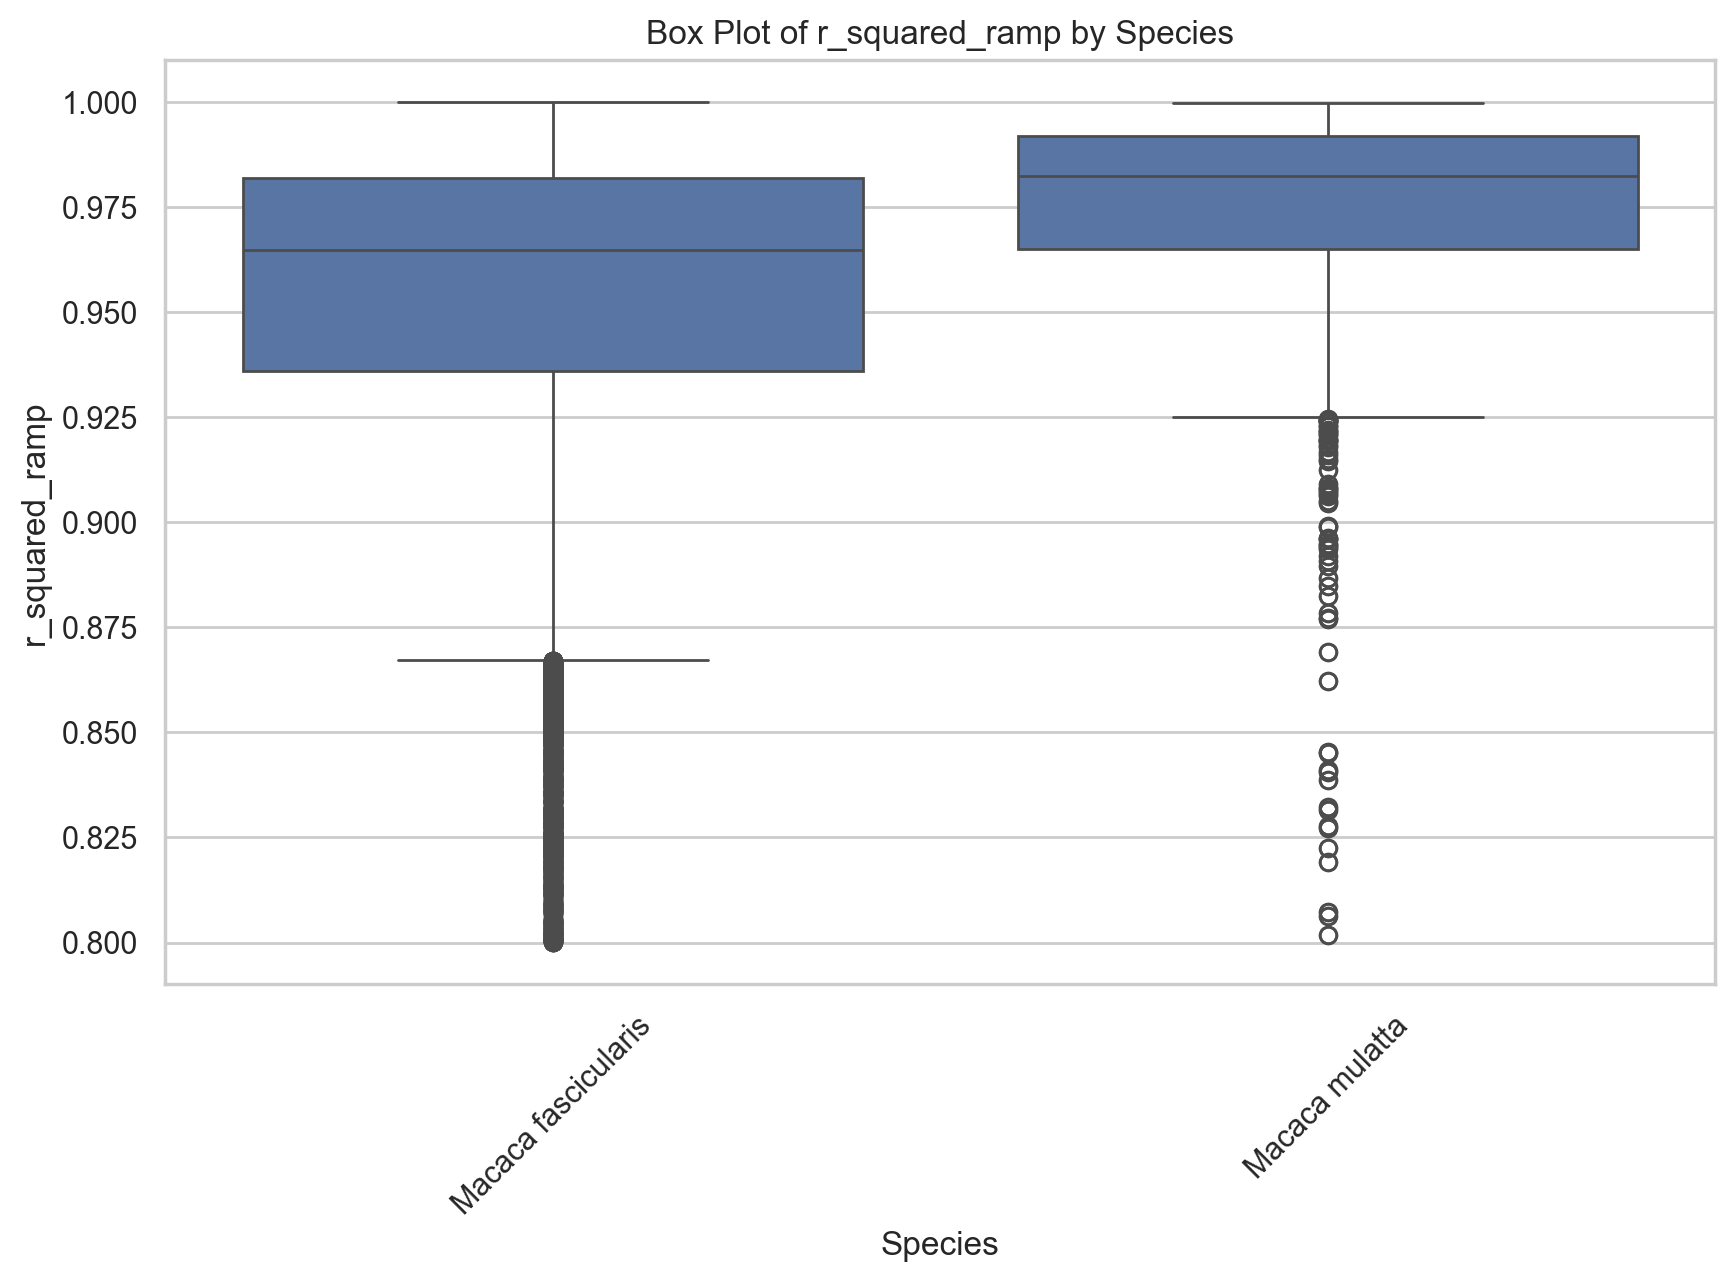

In [47]:
boxplots_by_Param('Species')

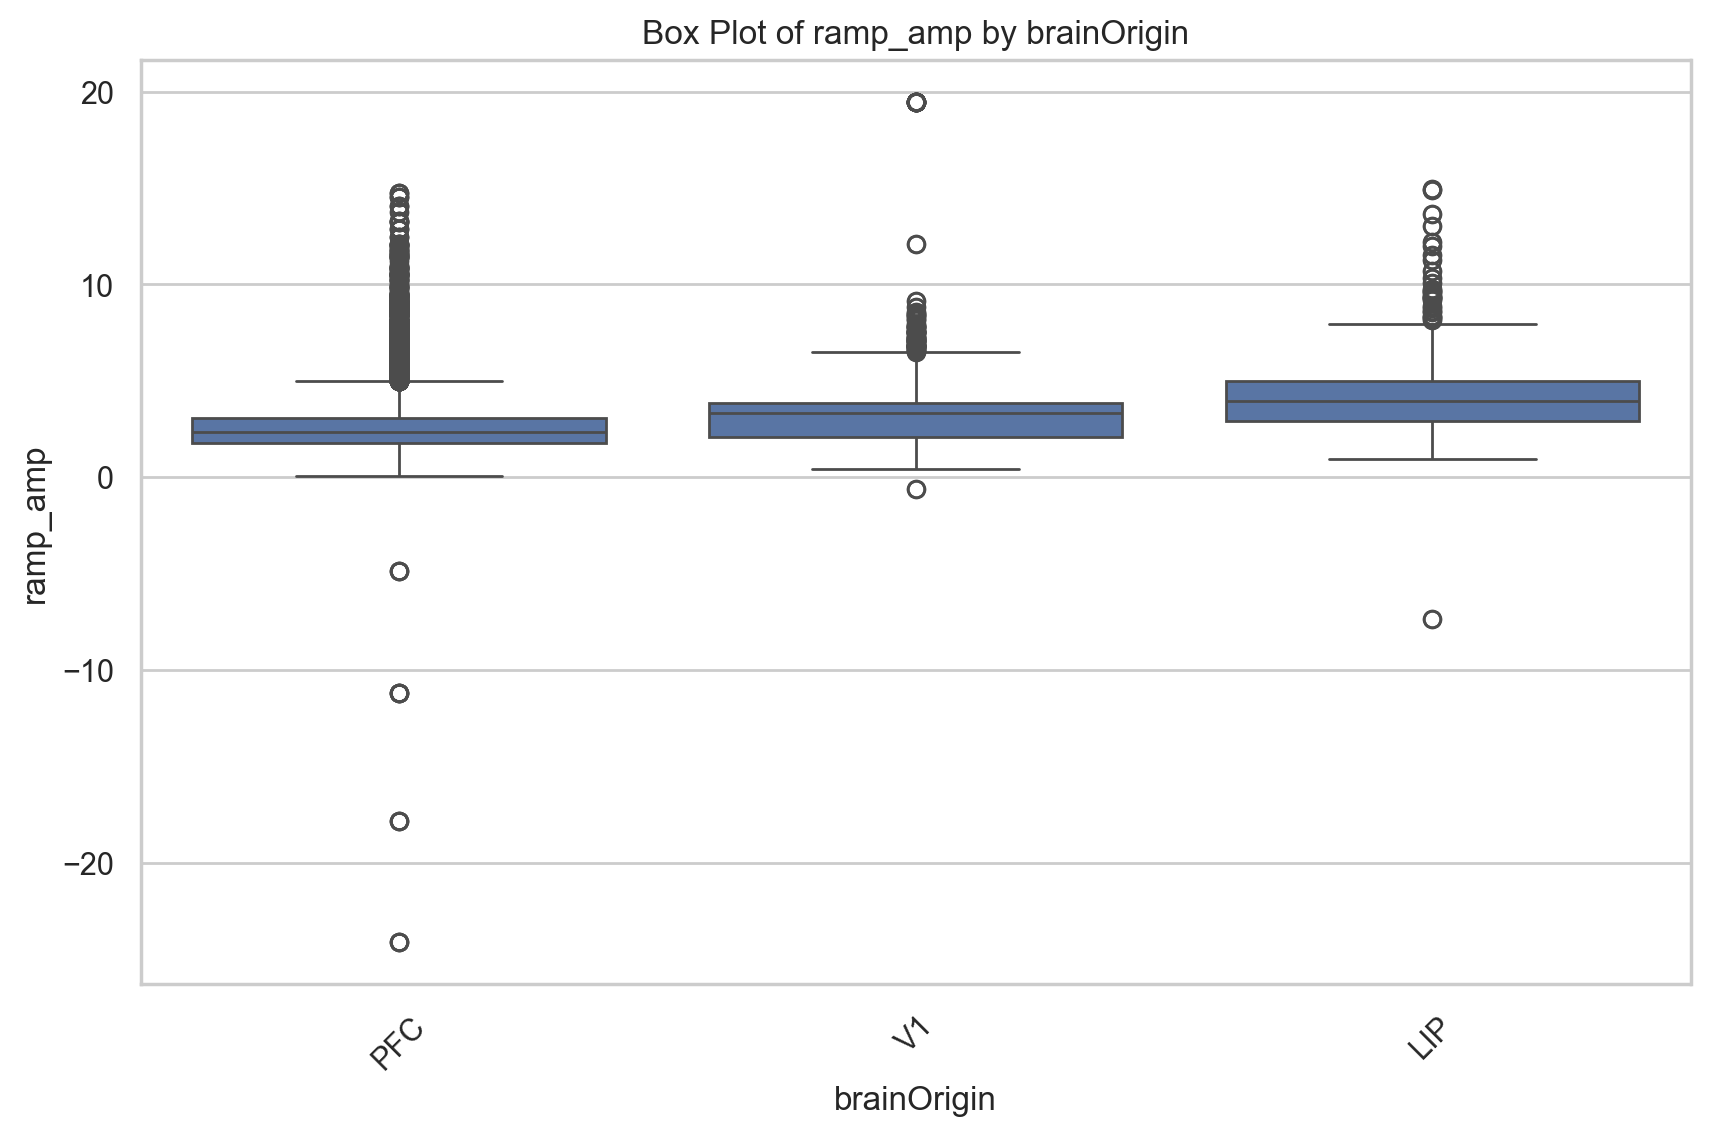

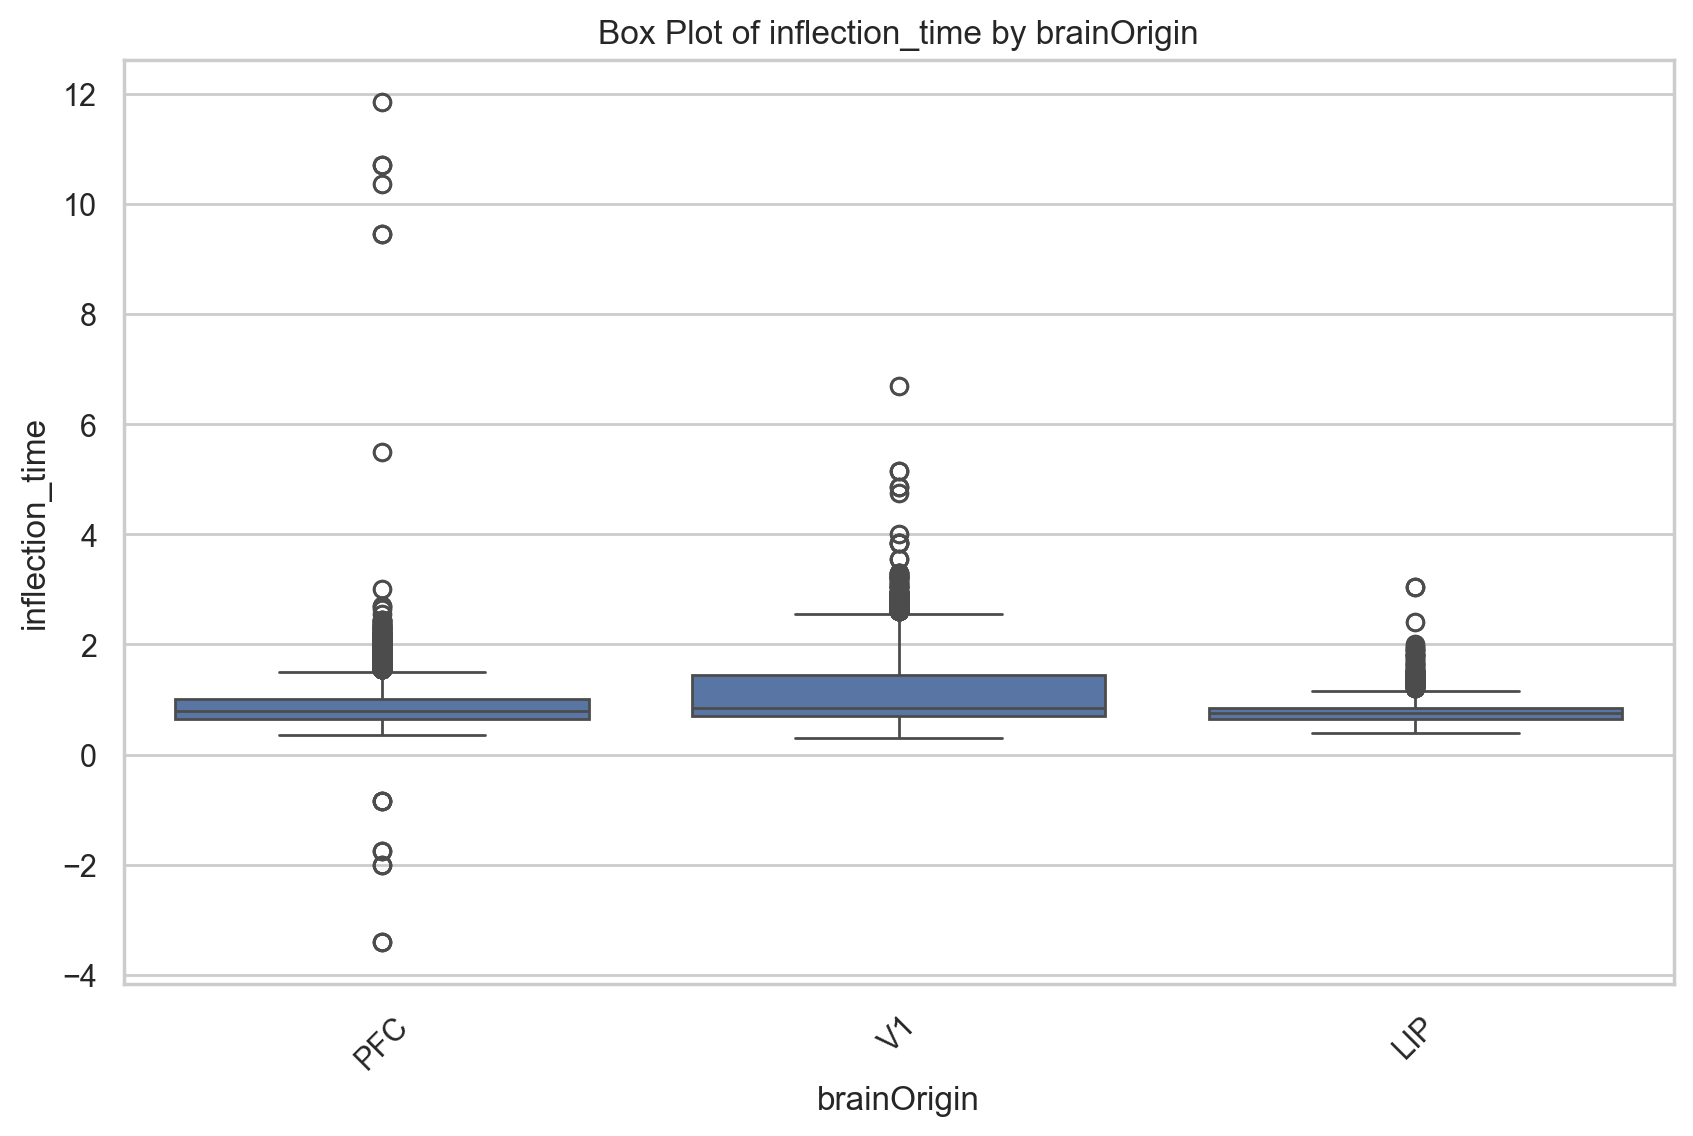

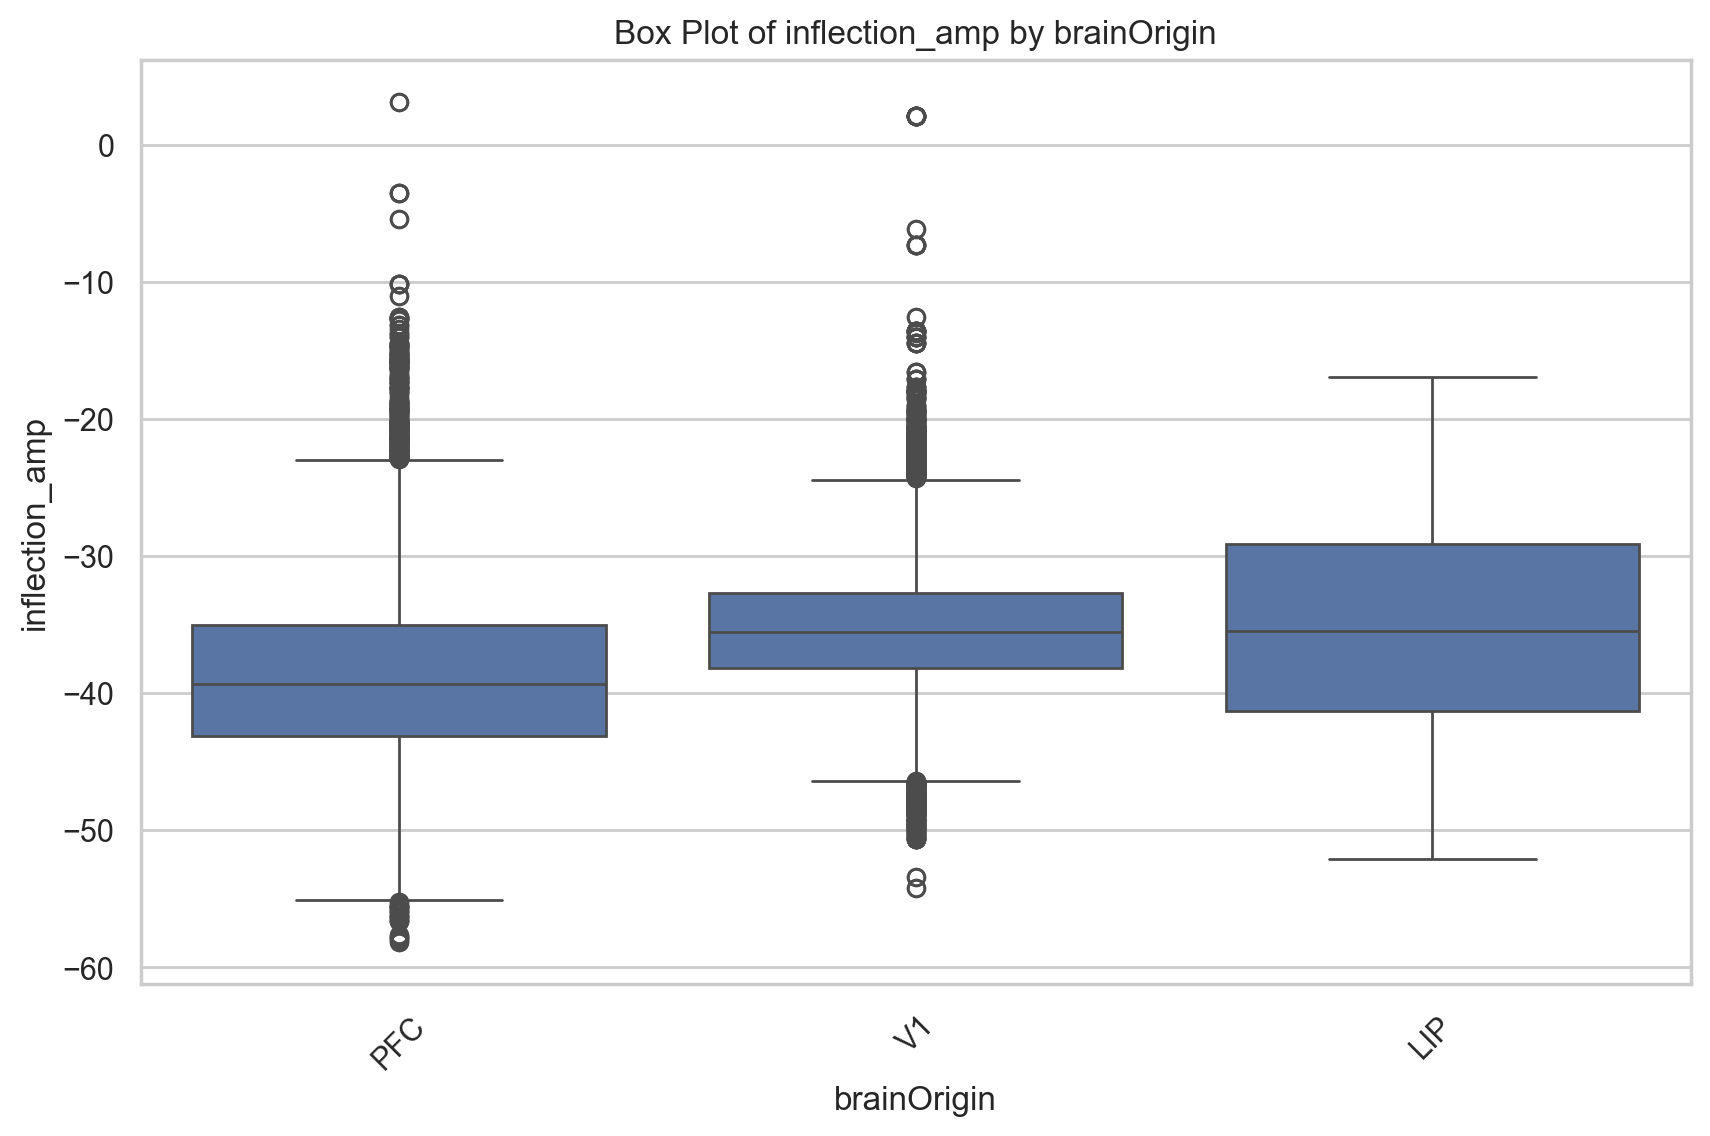

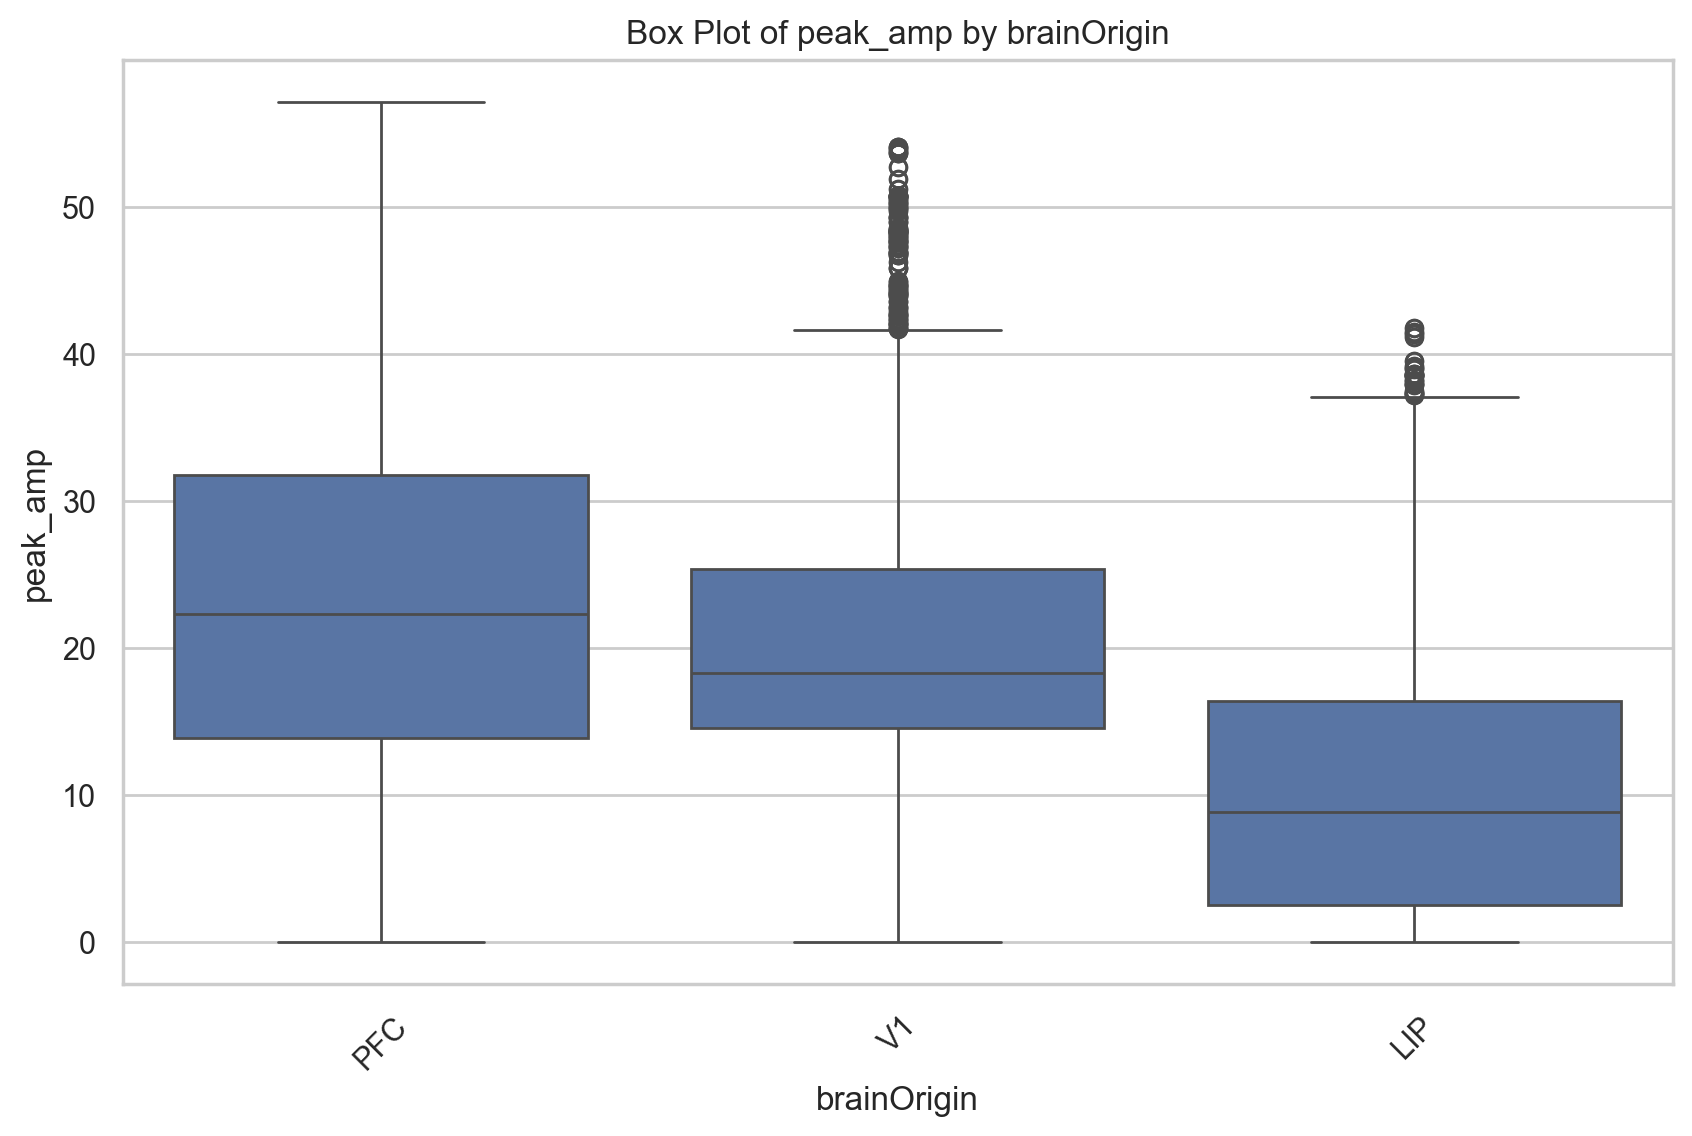

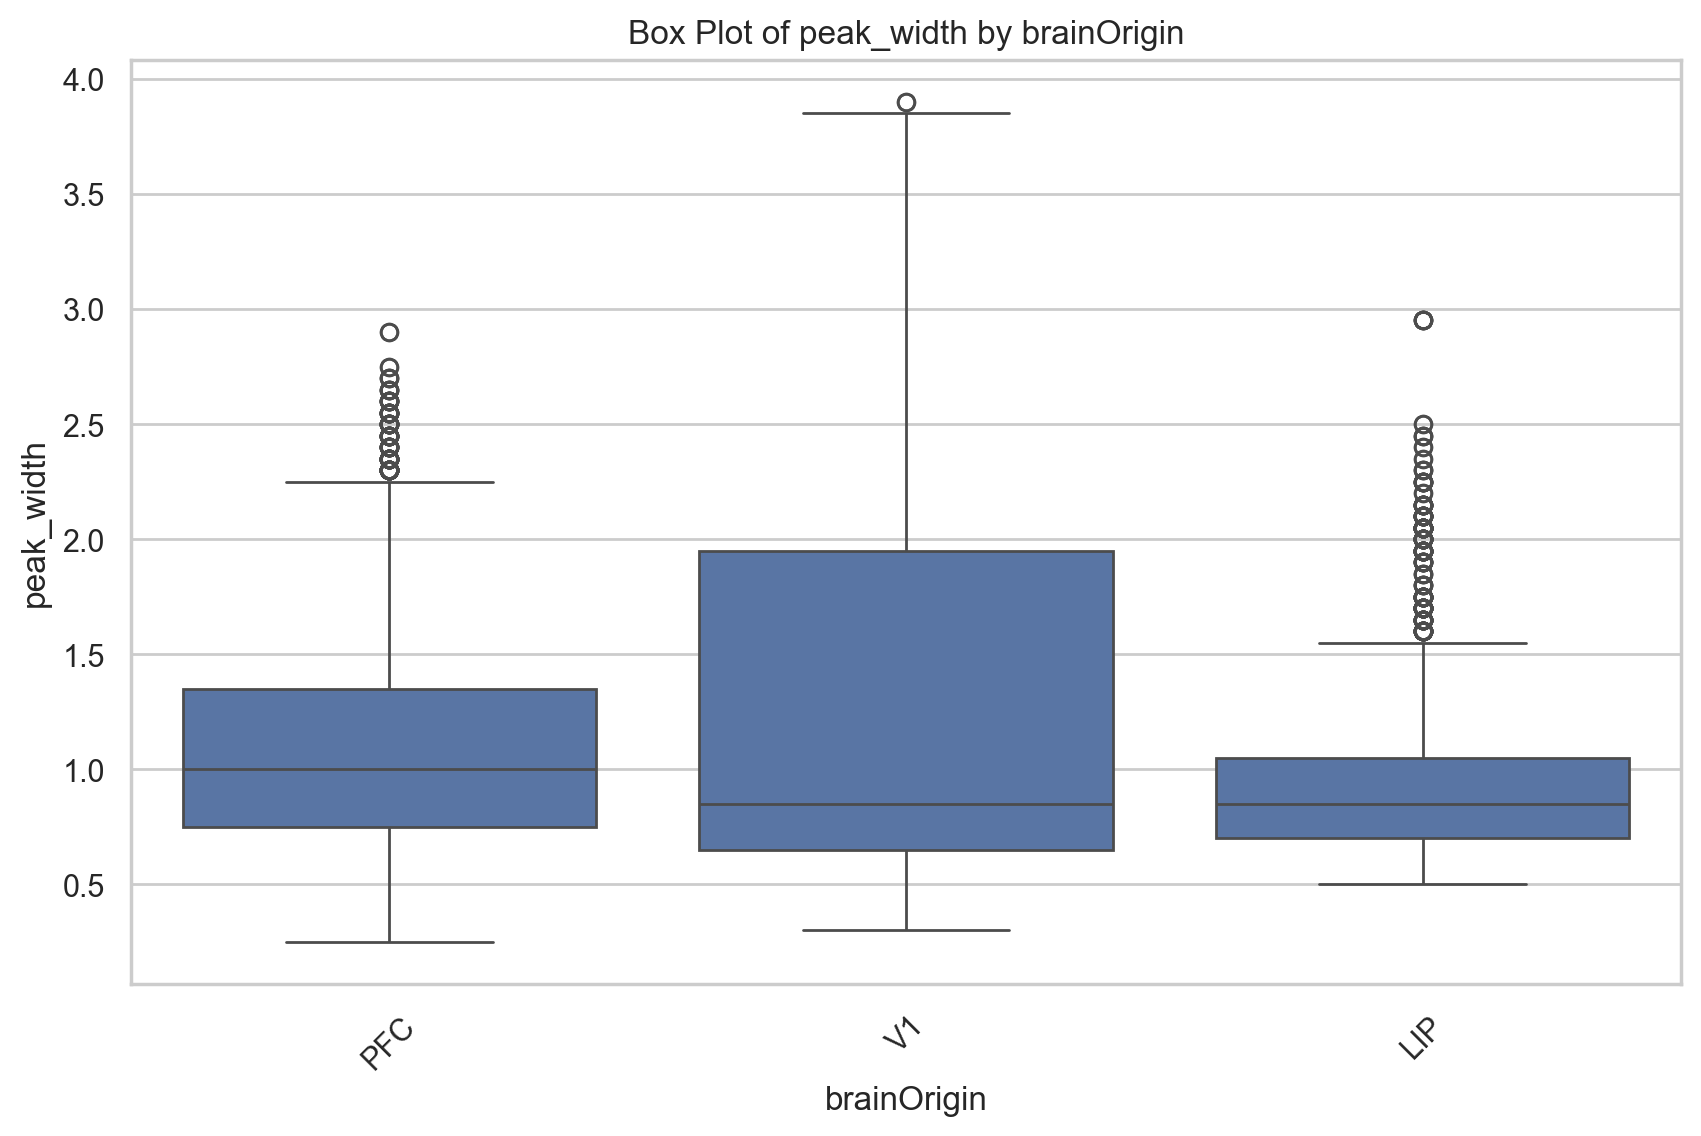

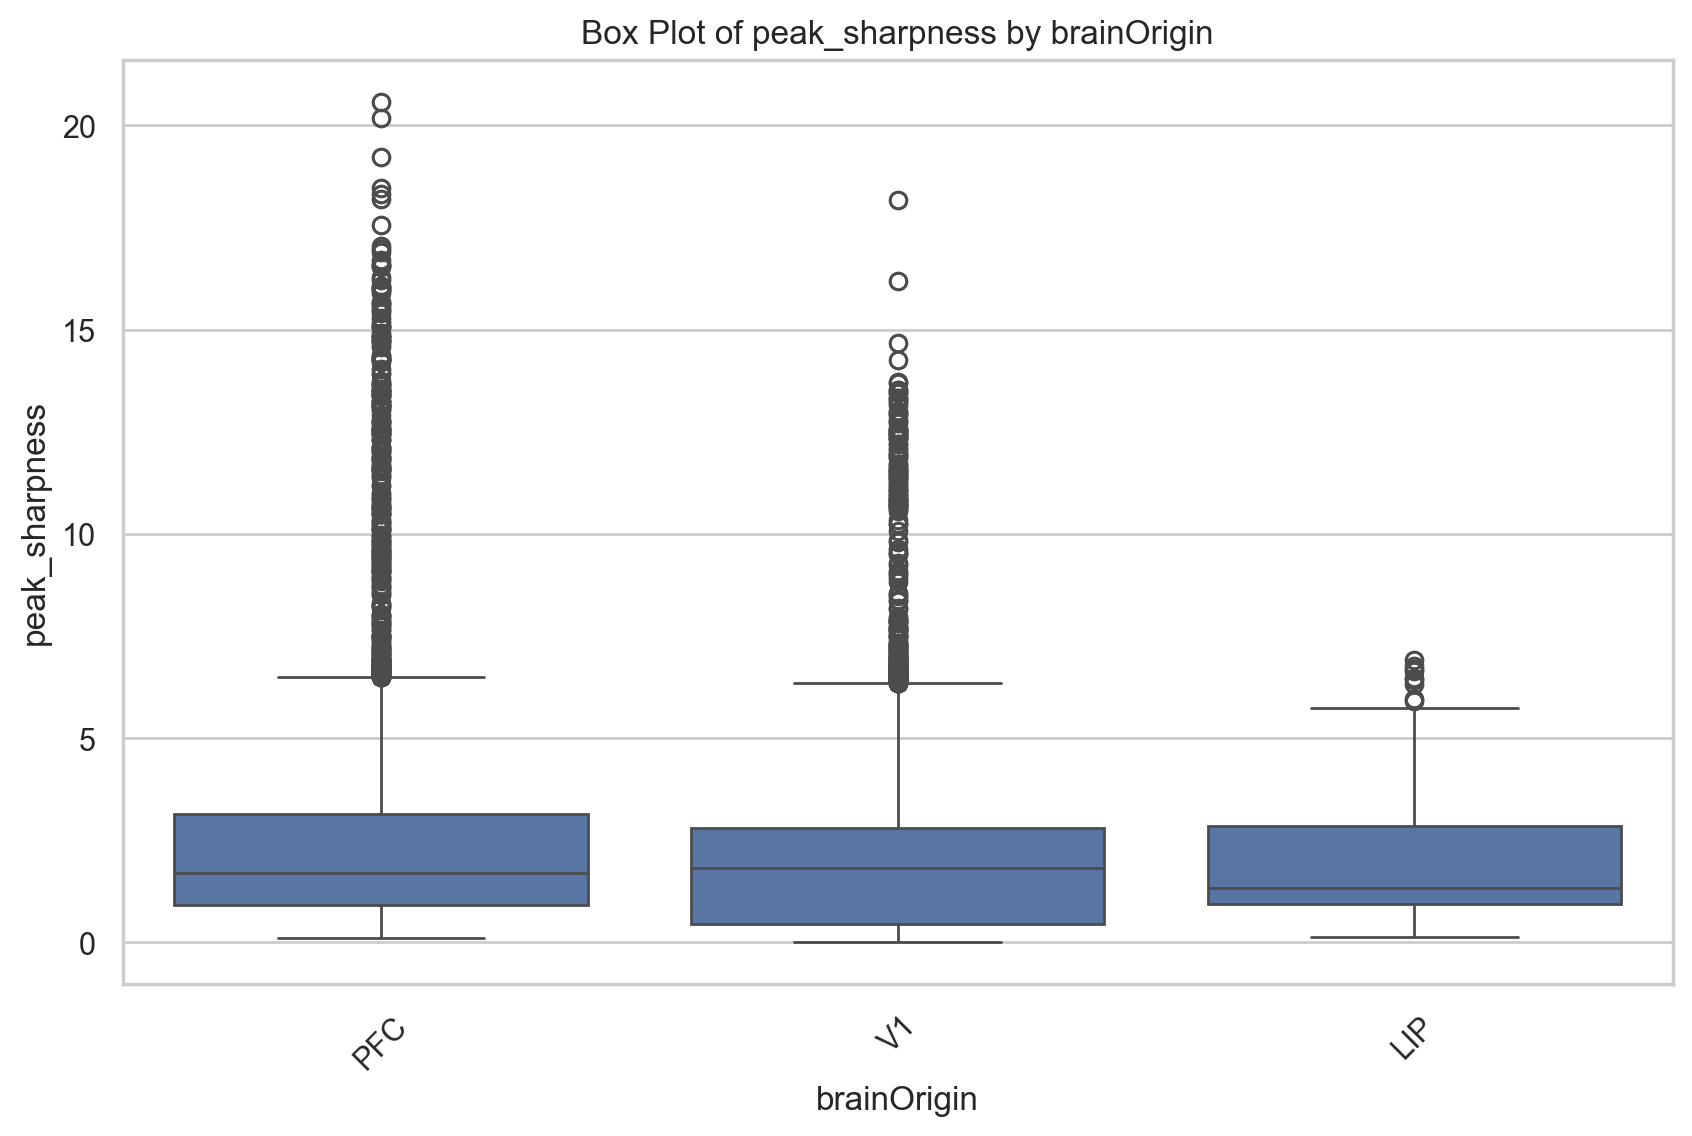

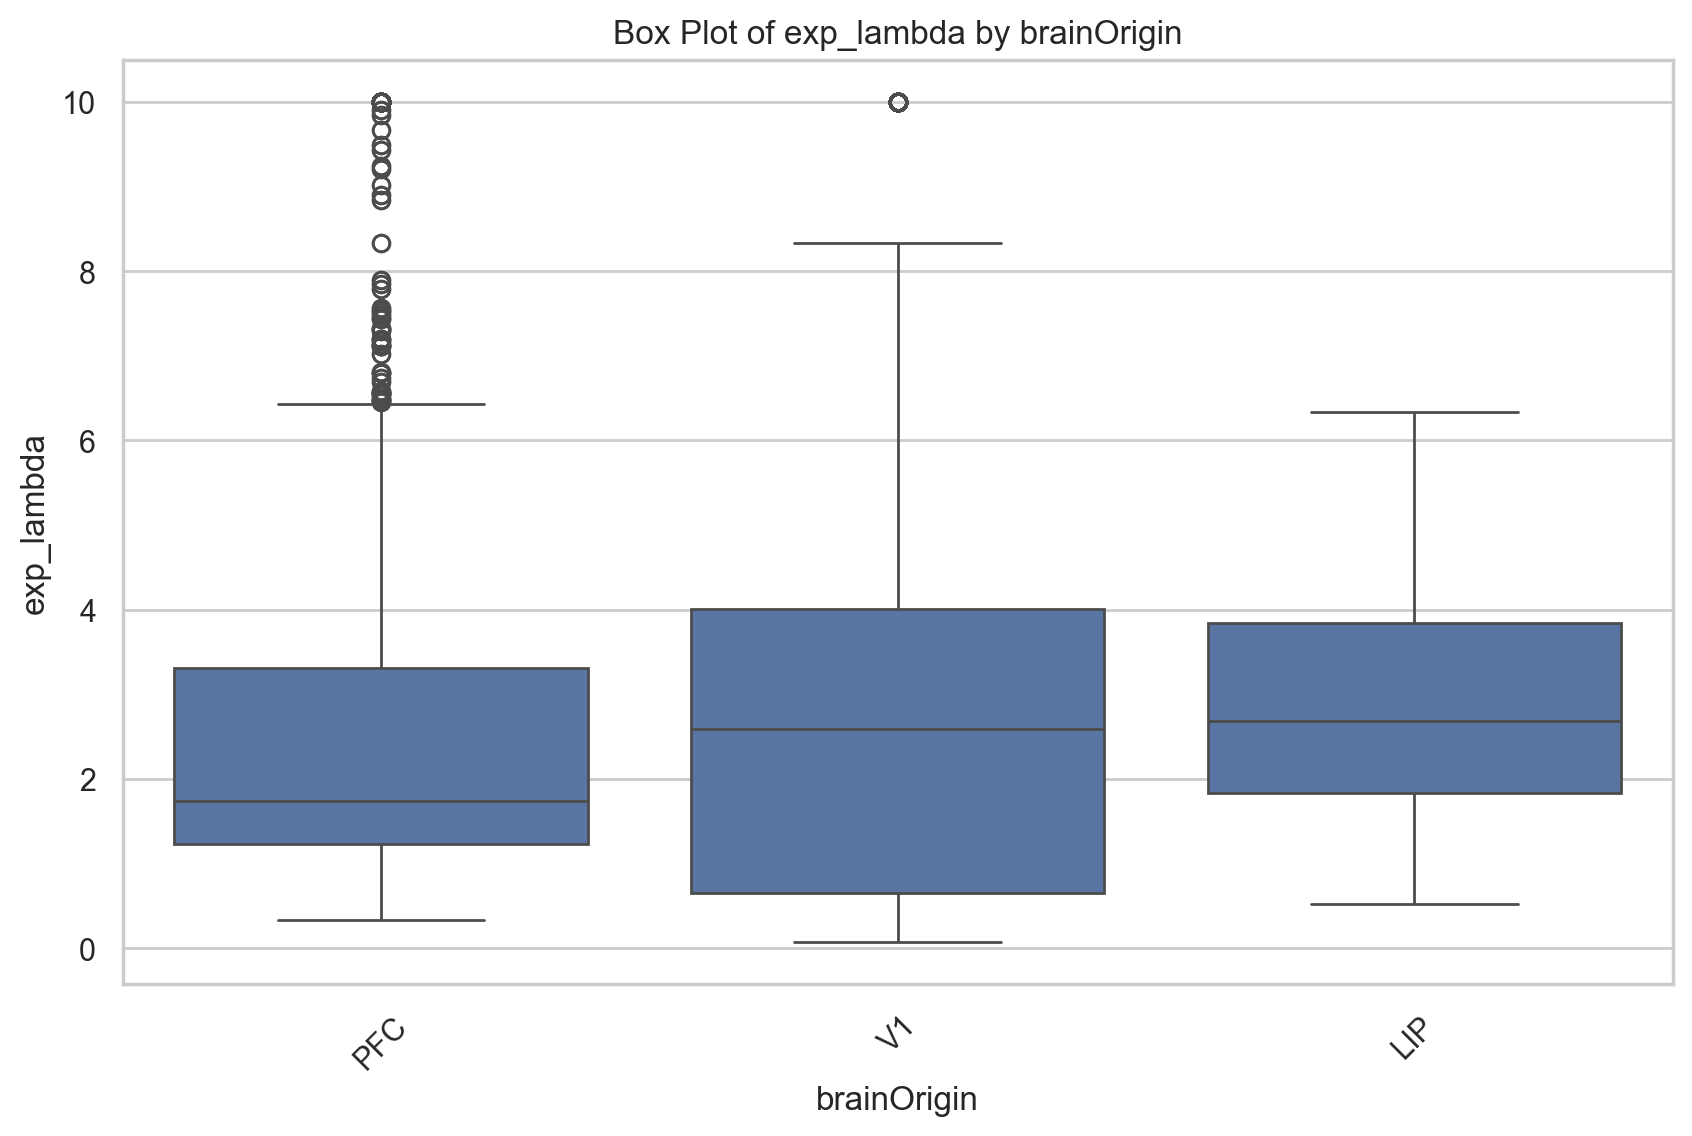

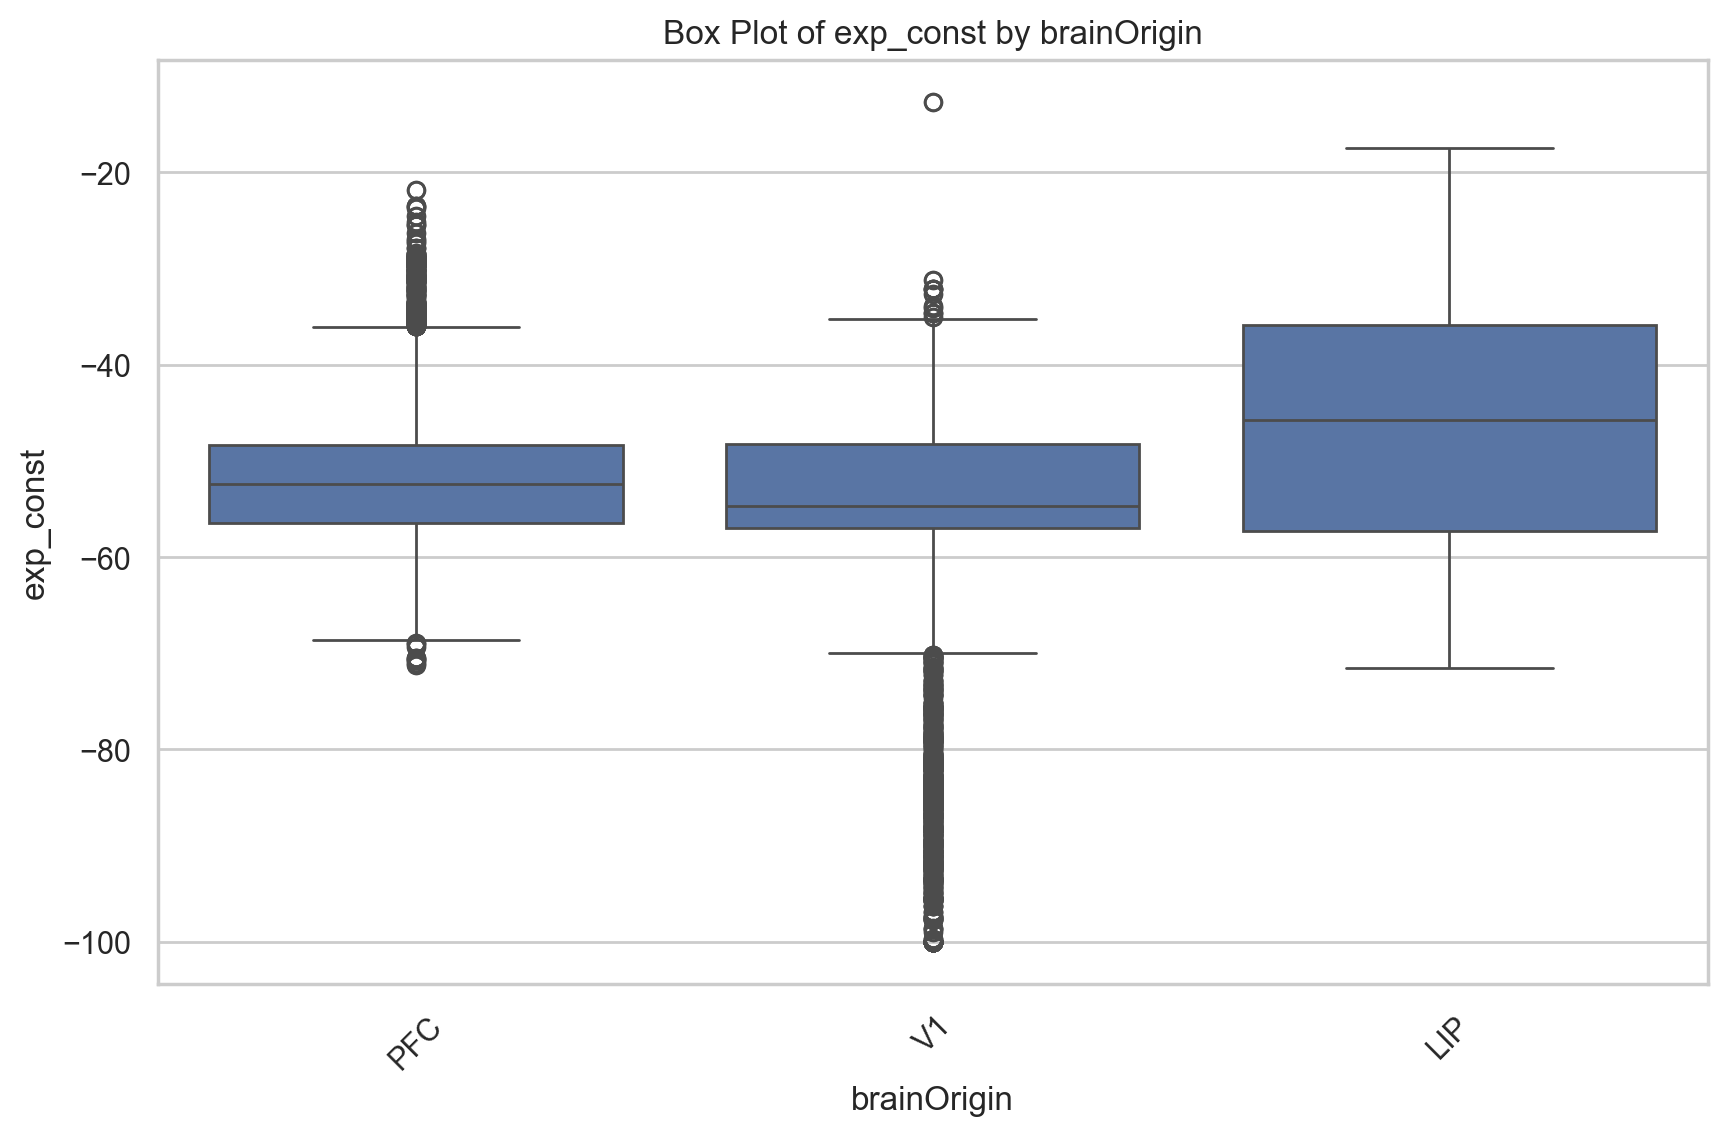

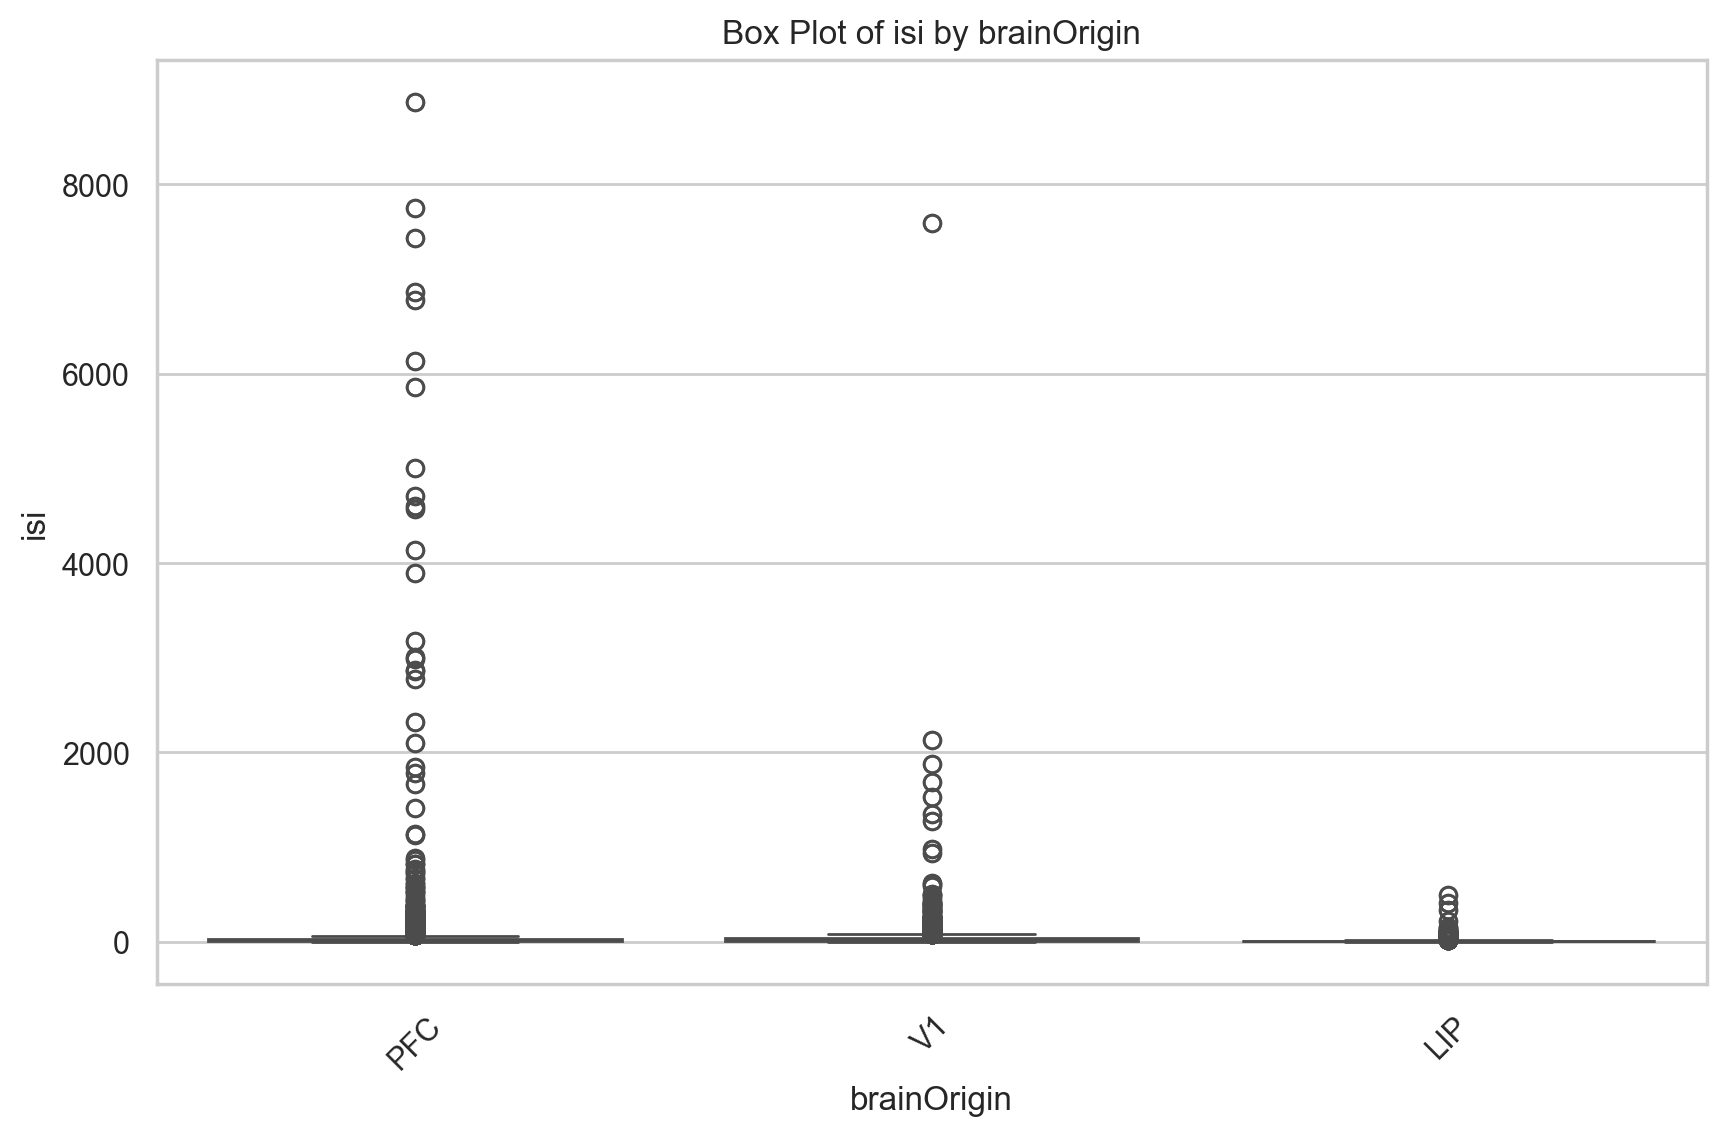

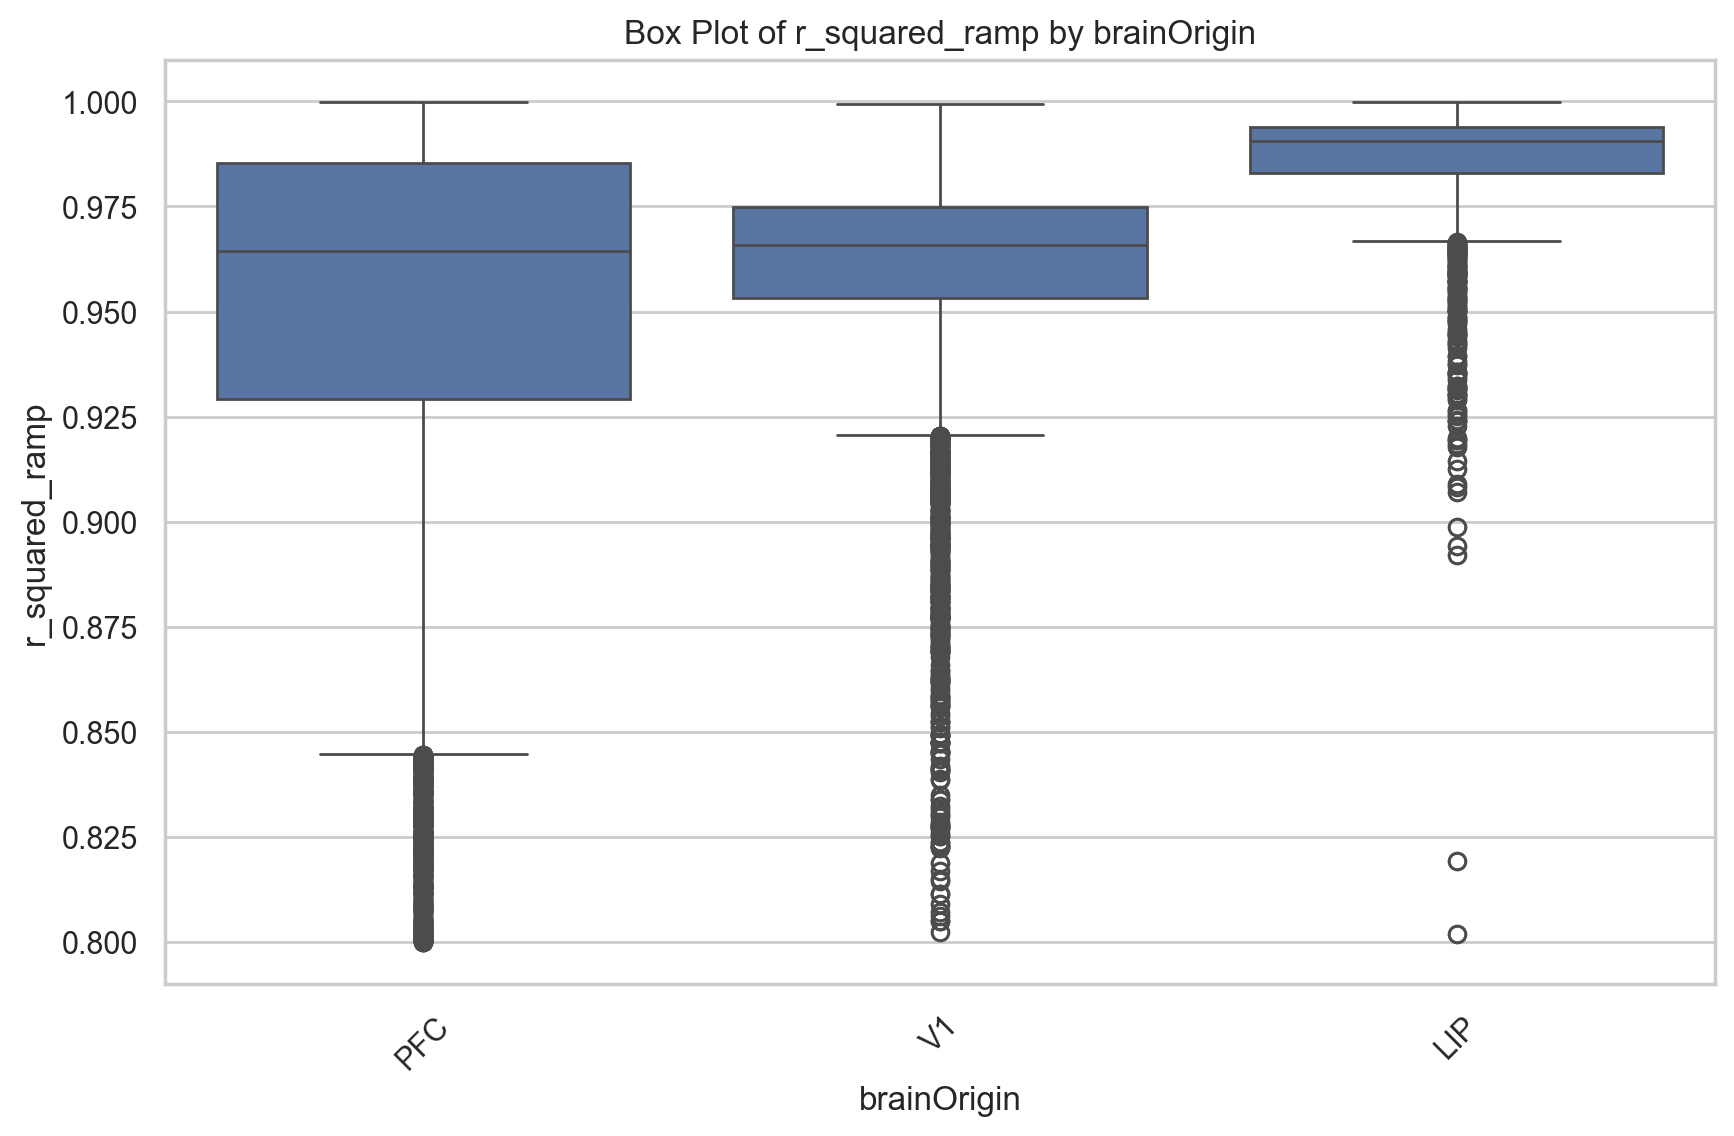

In [85]:
boxplots_by_Param('brainOrigin')

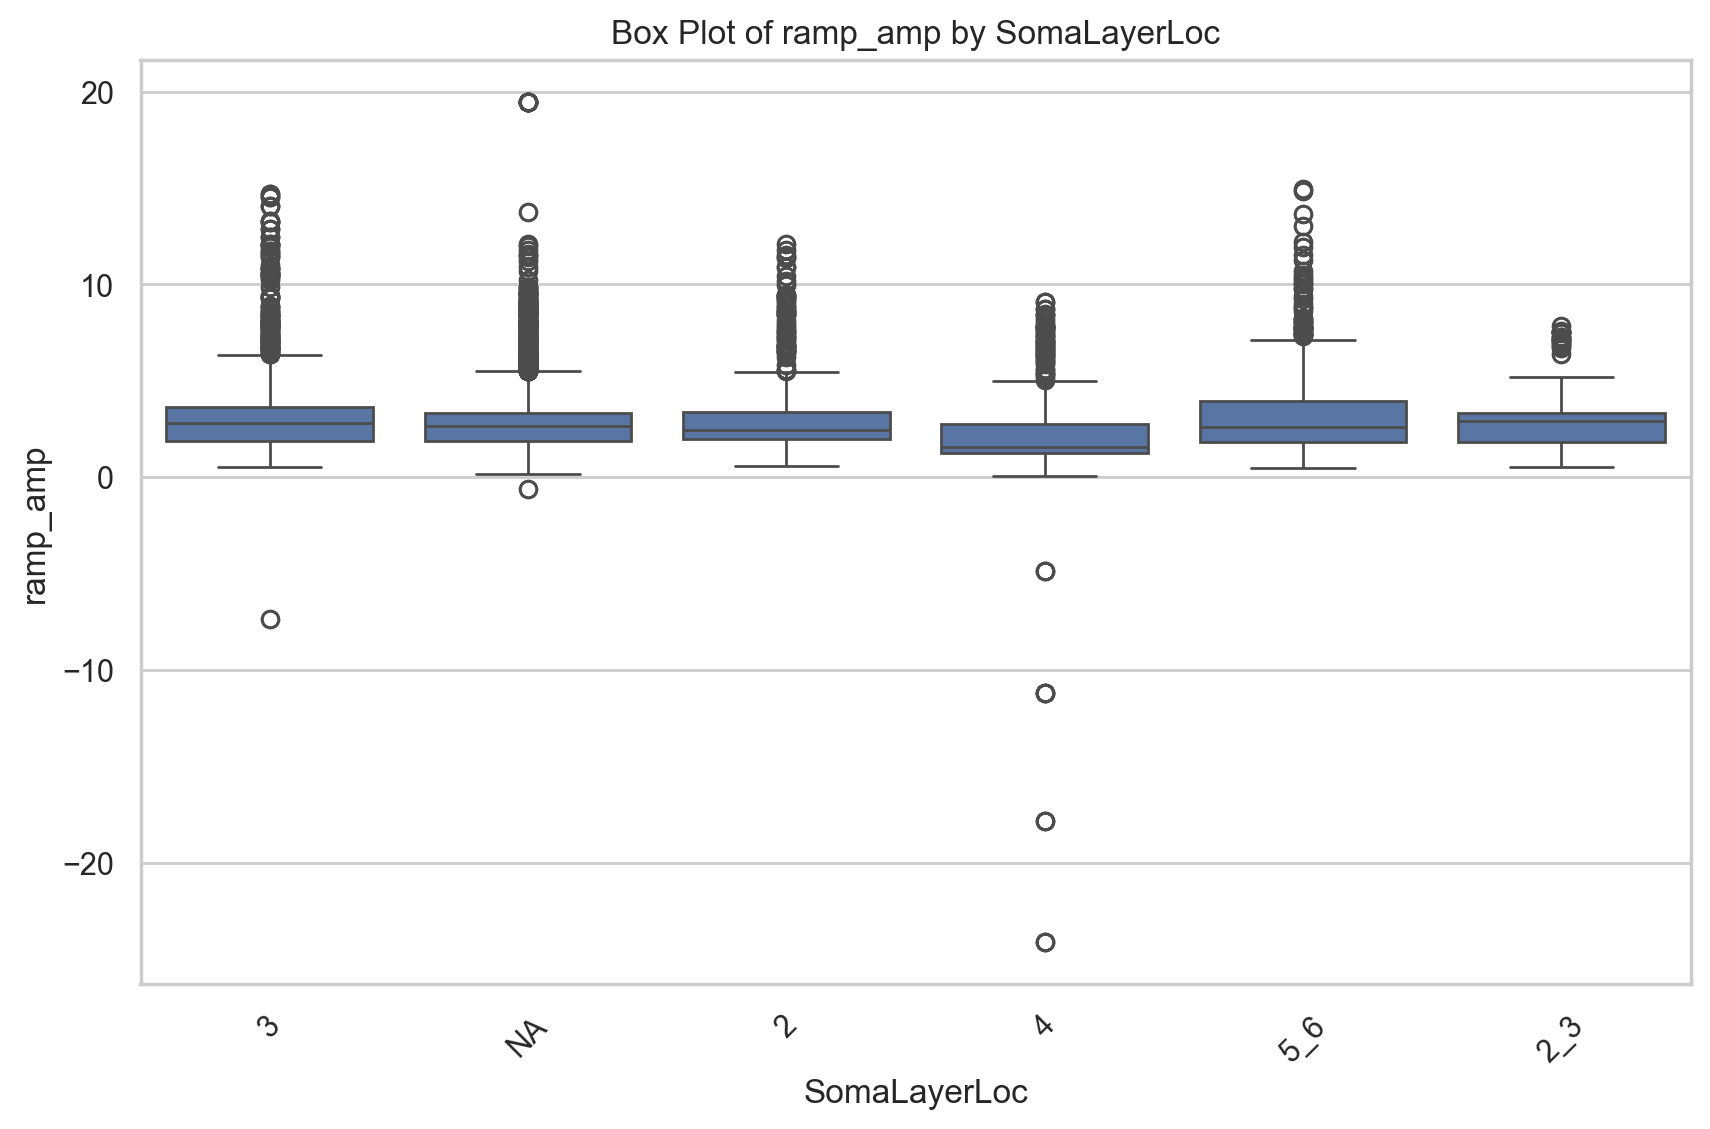

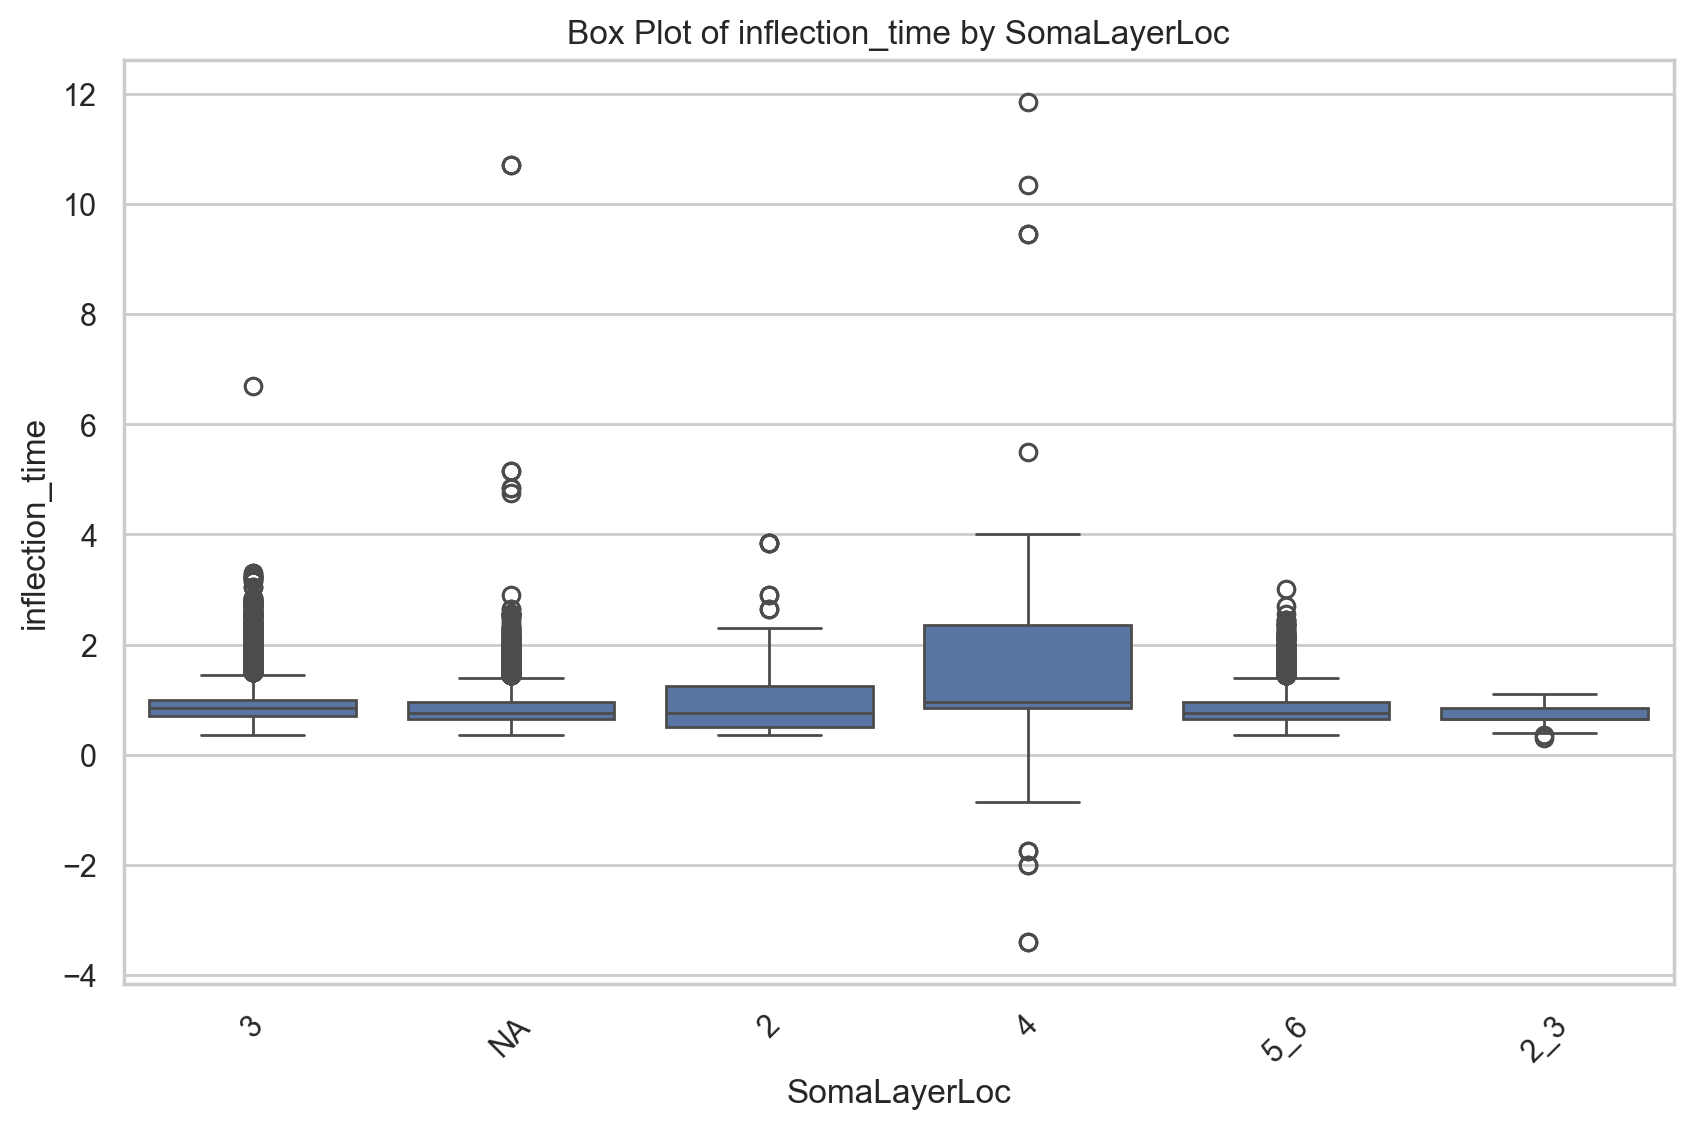

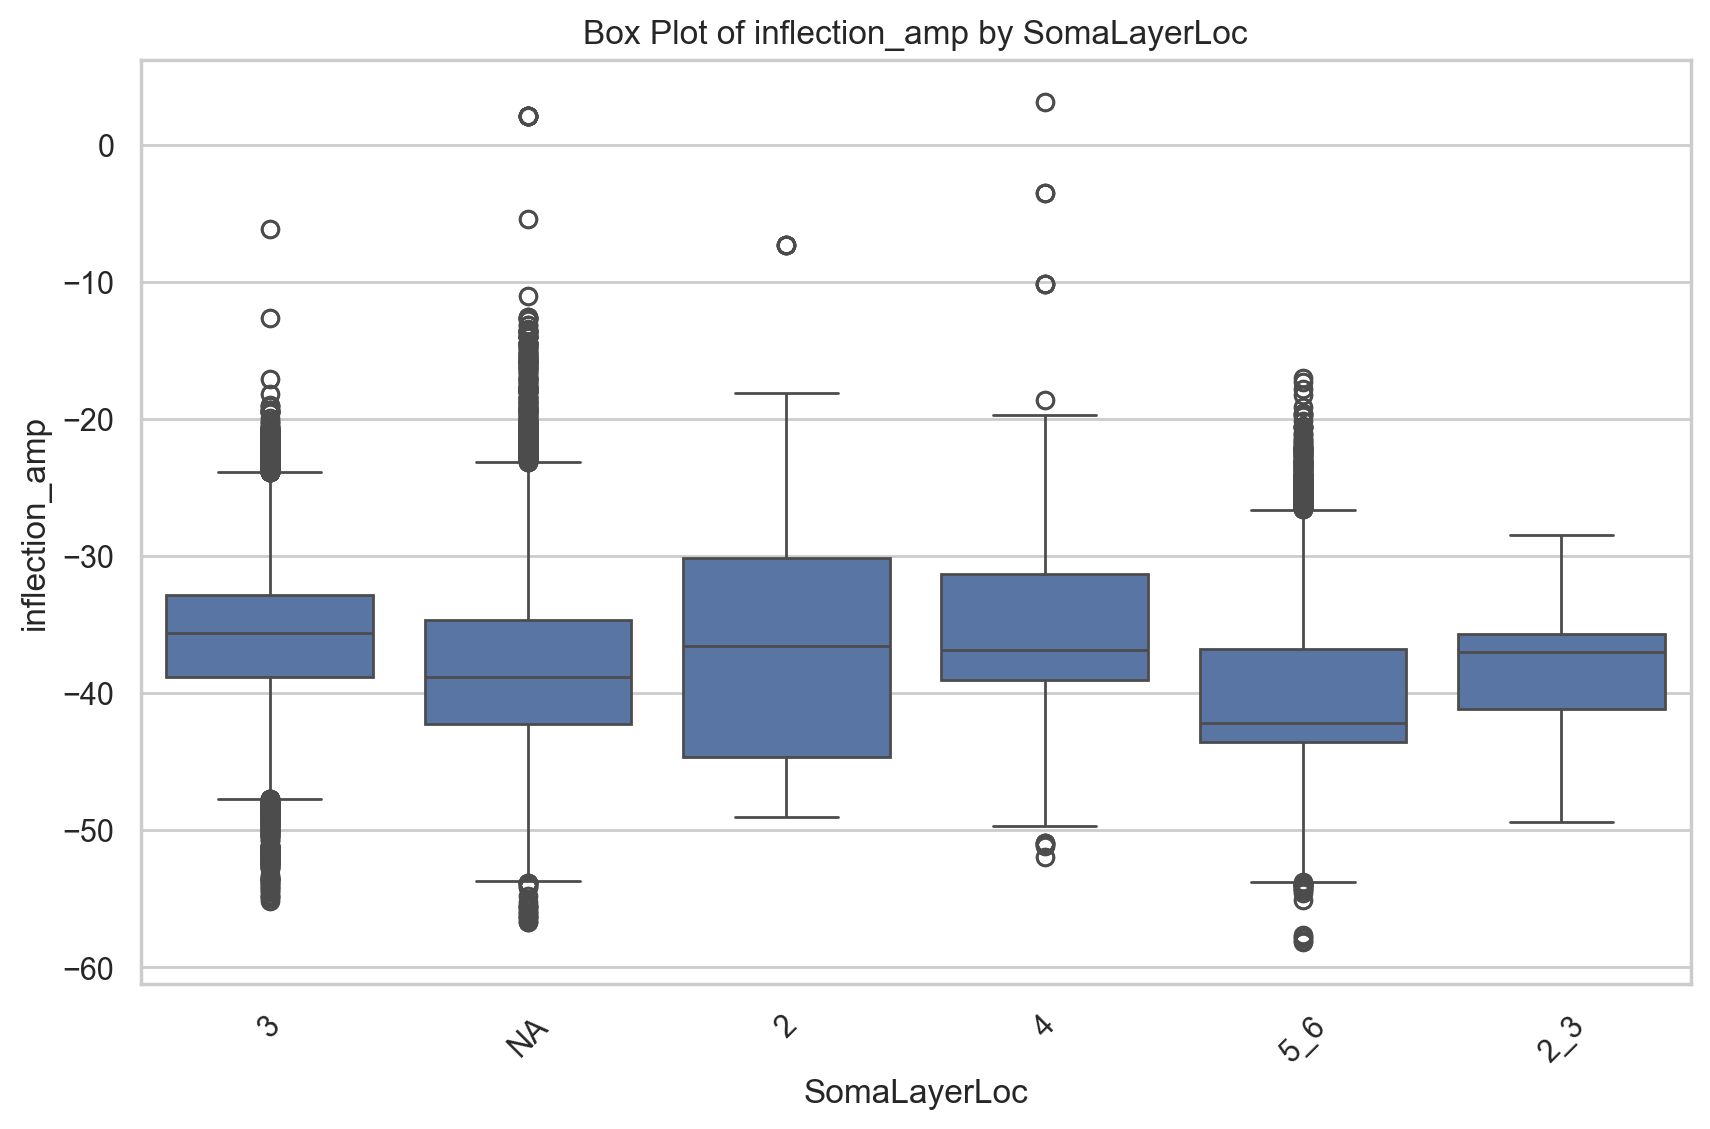

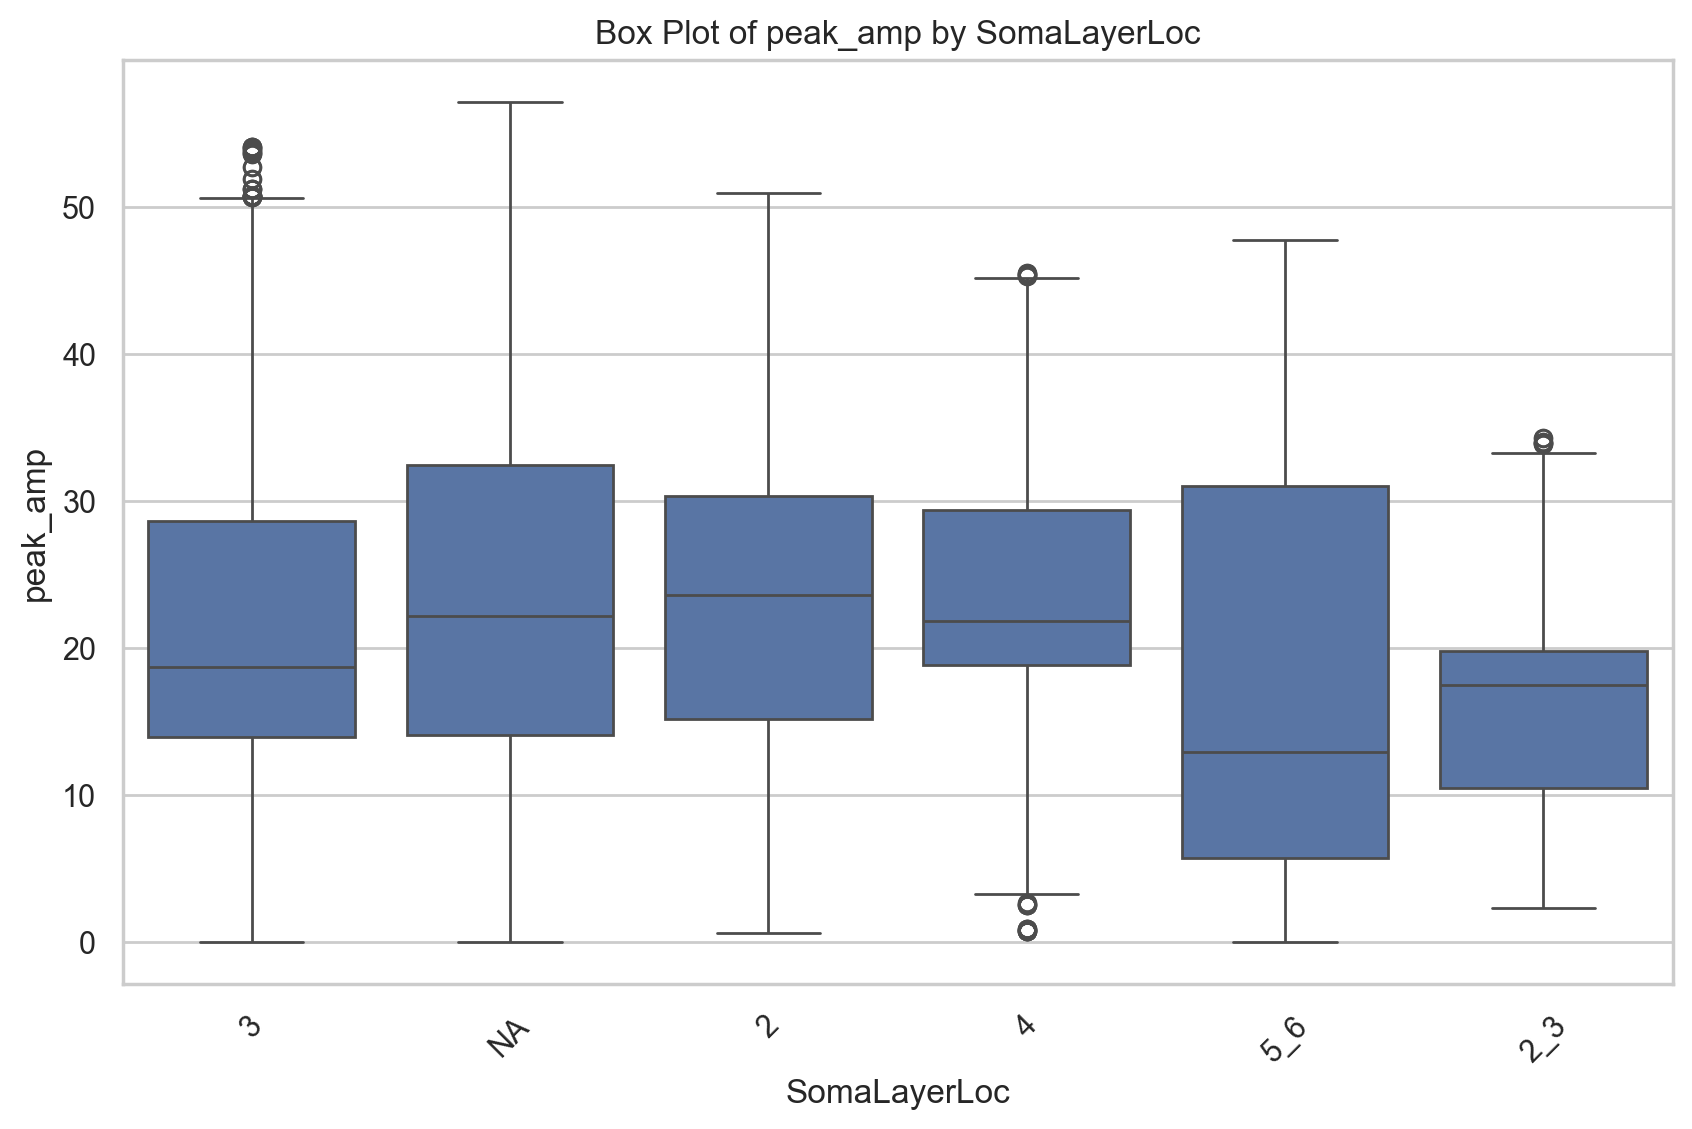

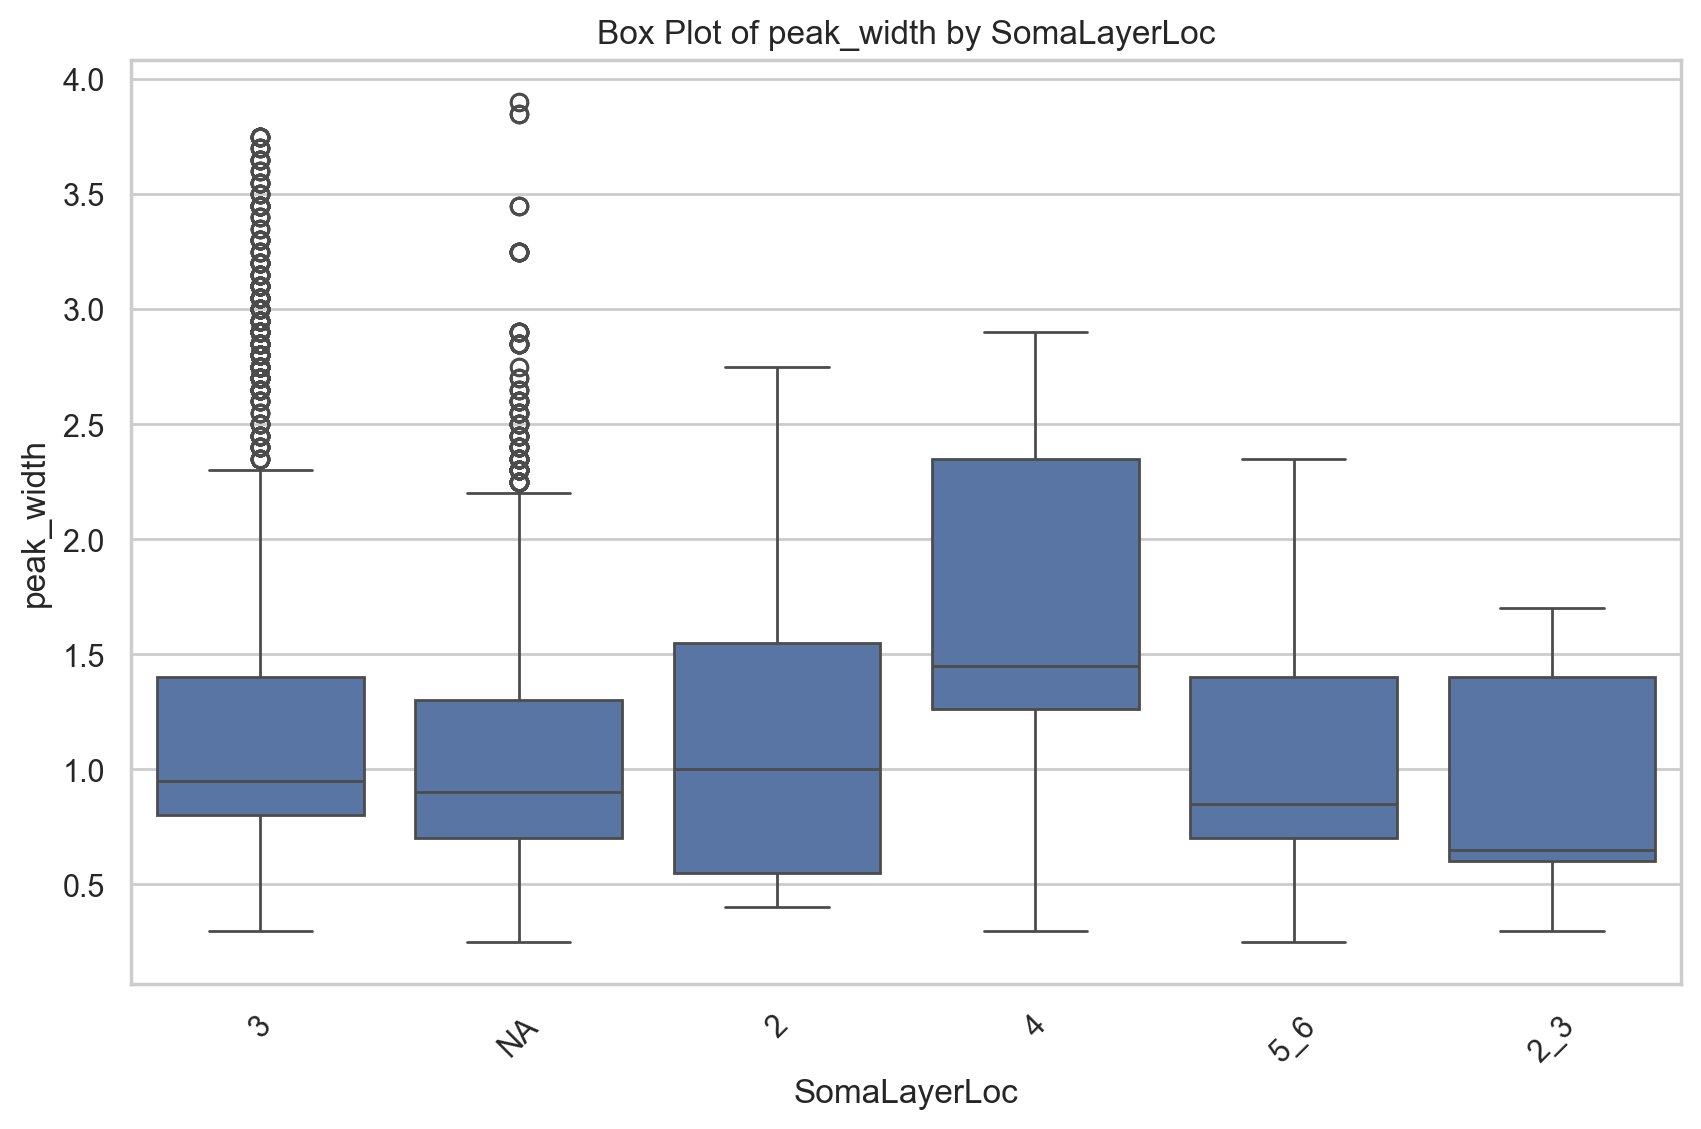

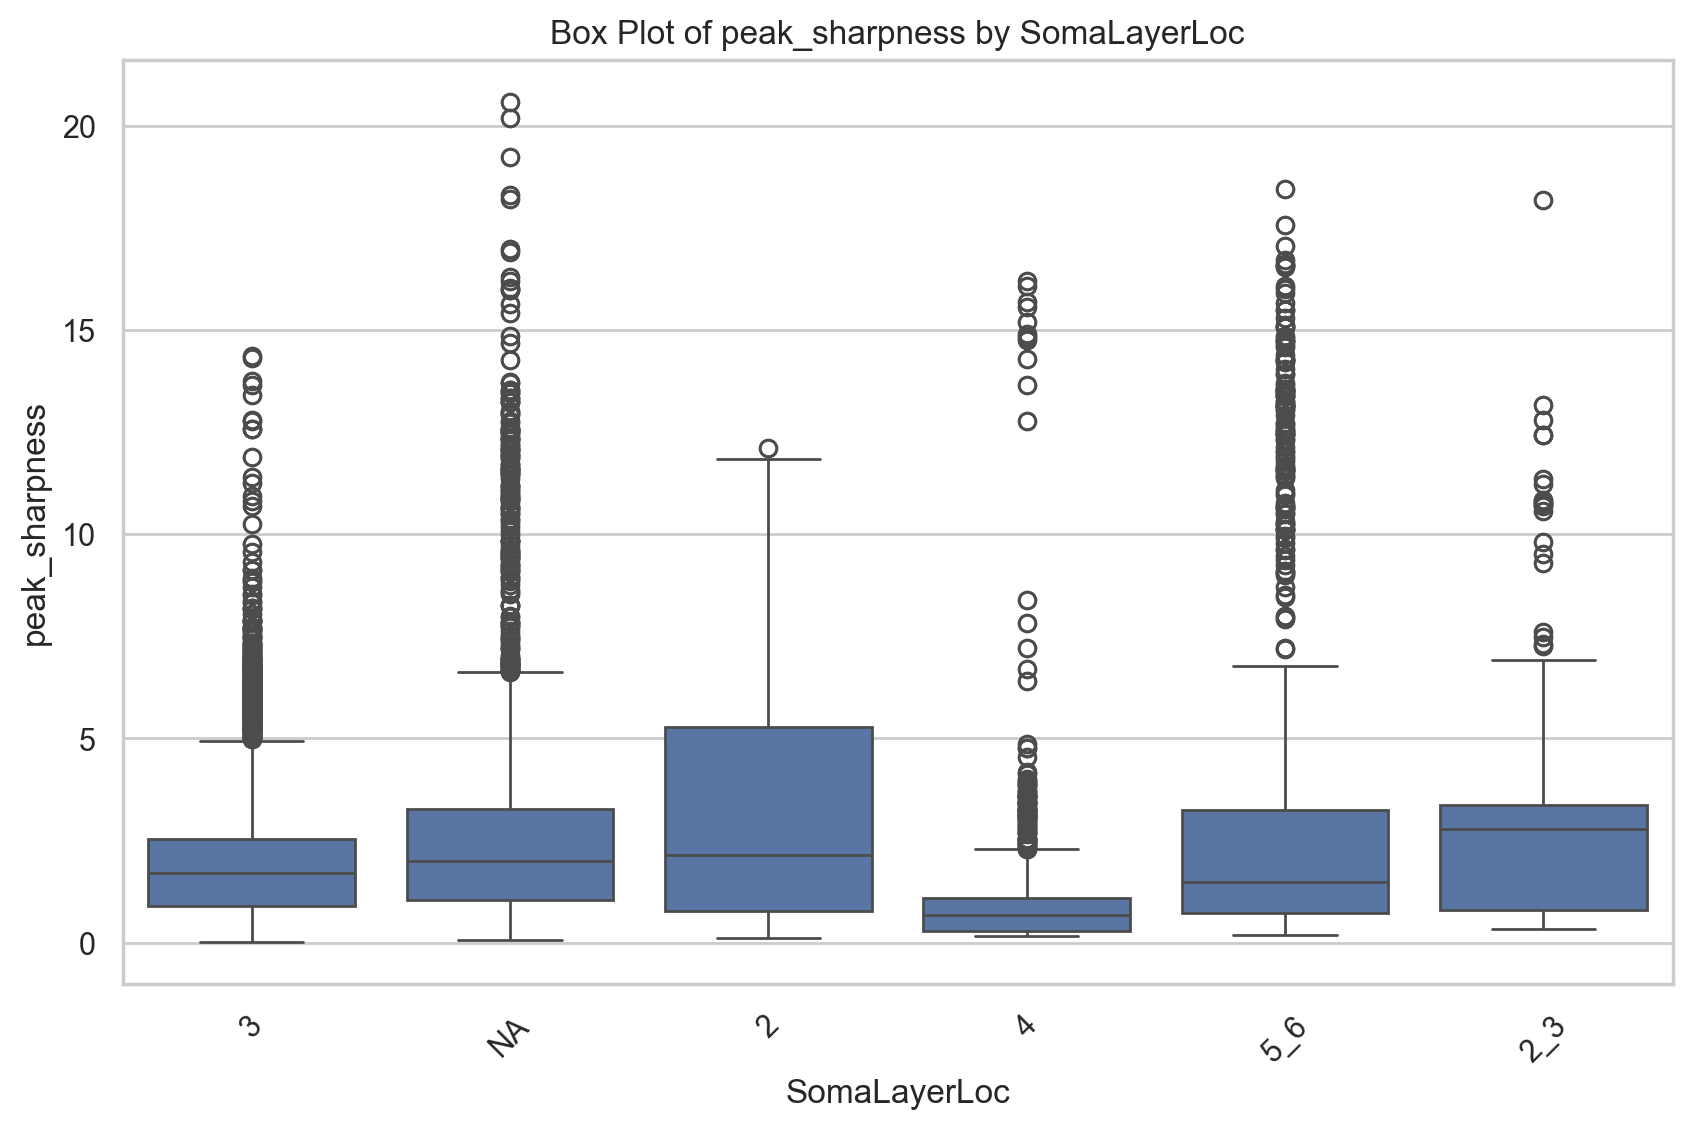

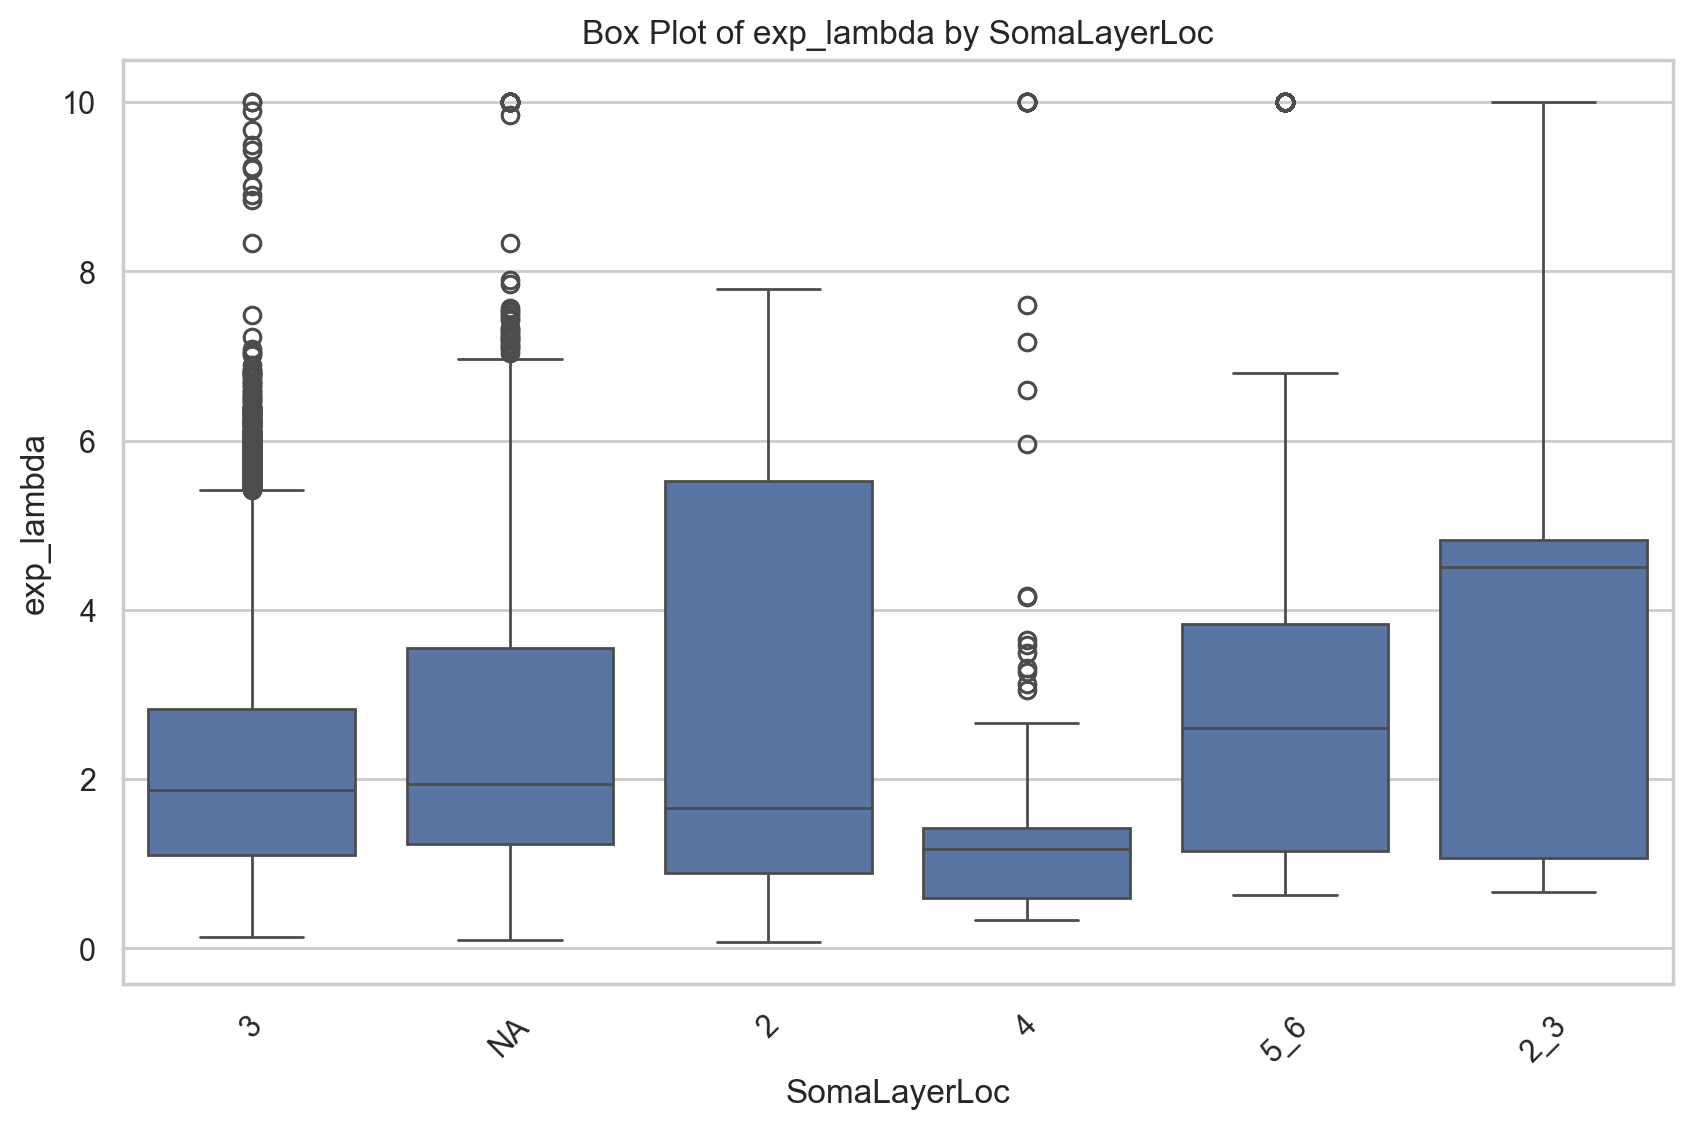

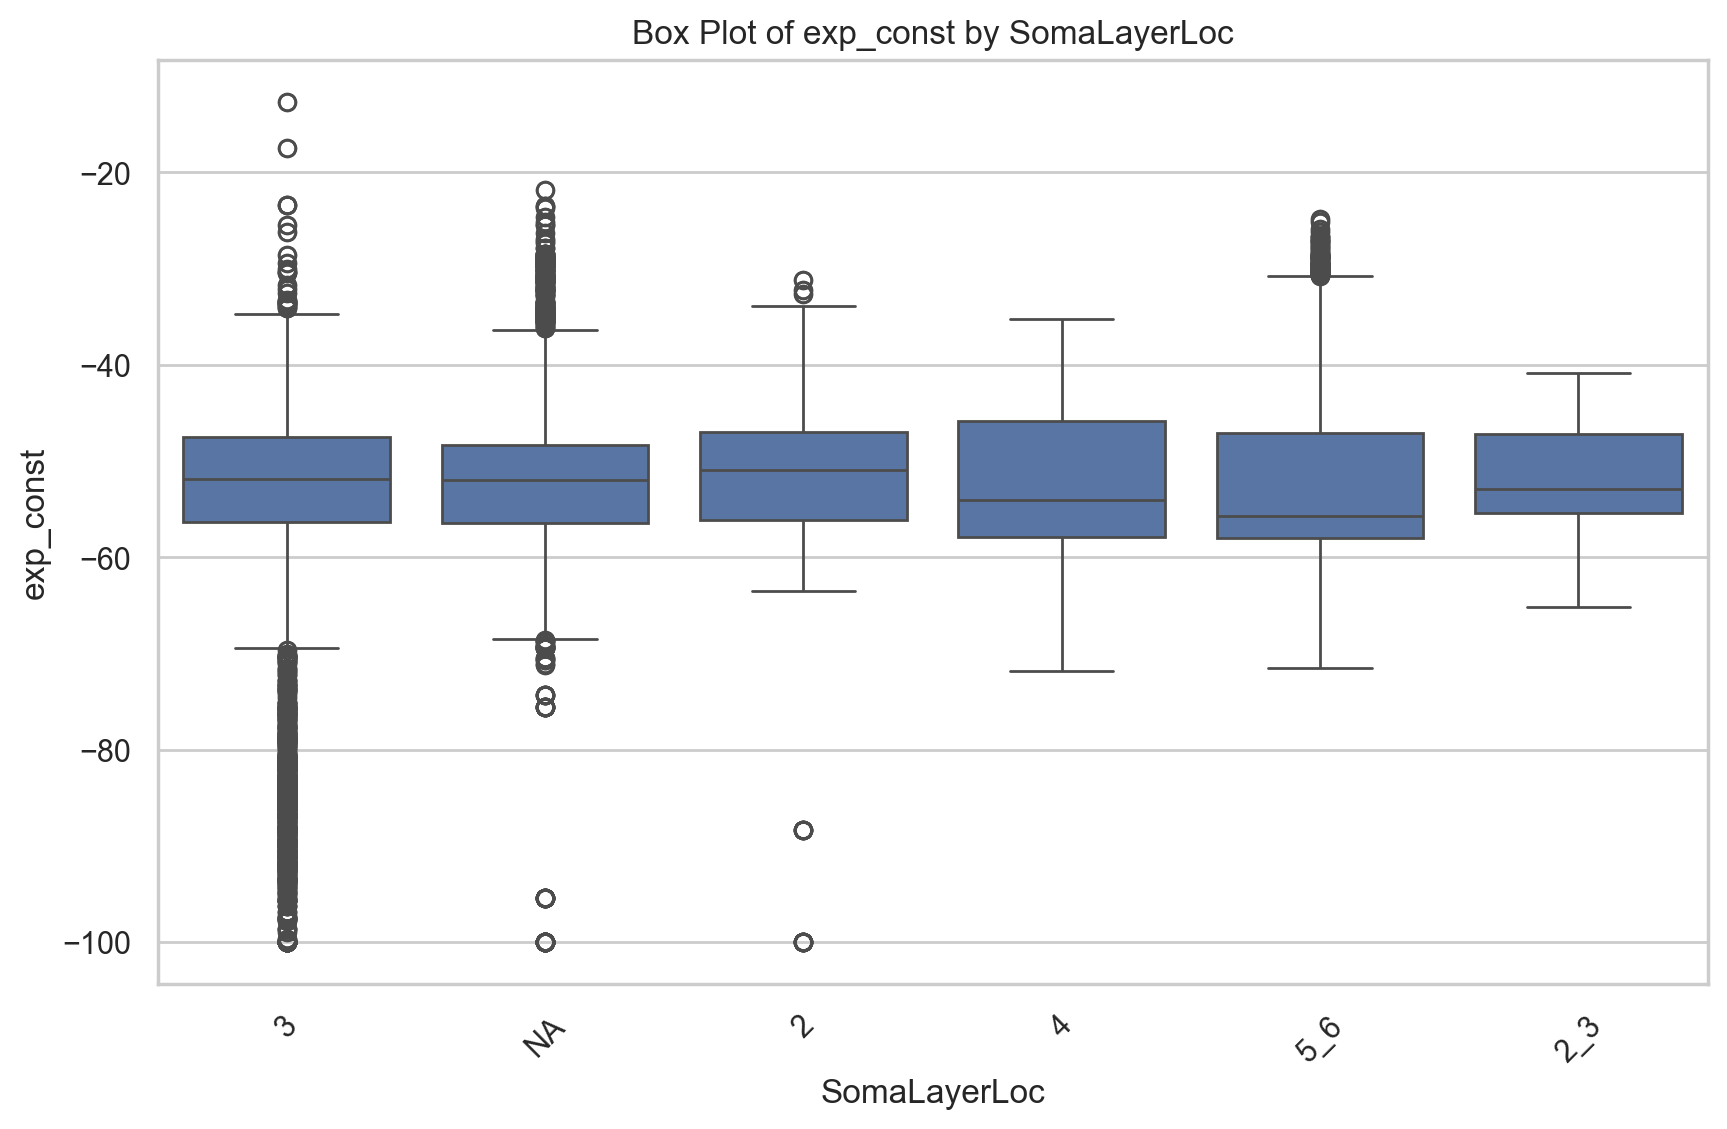

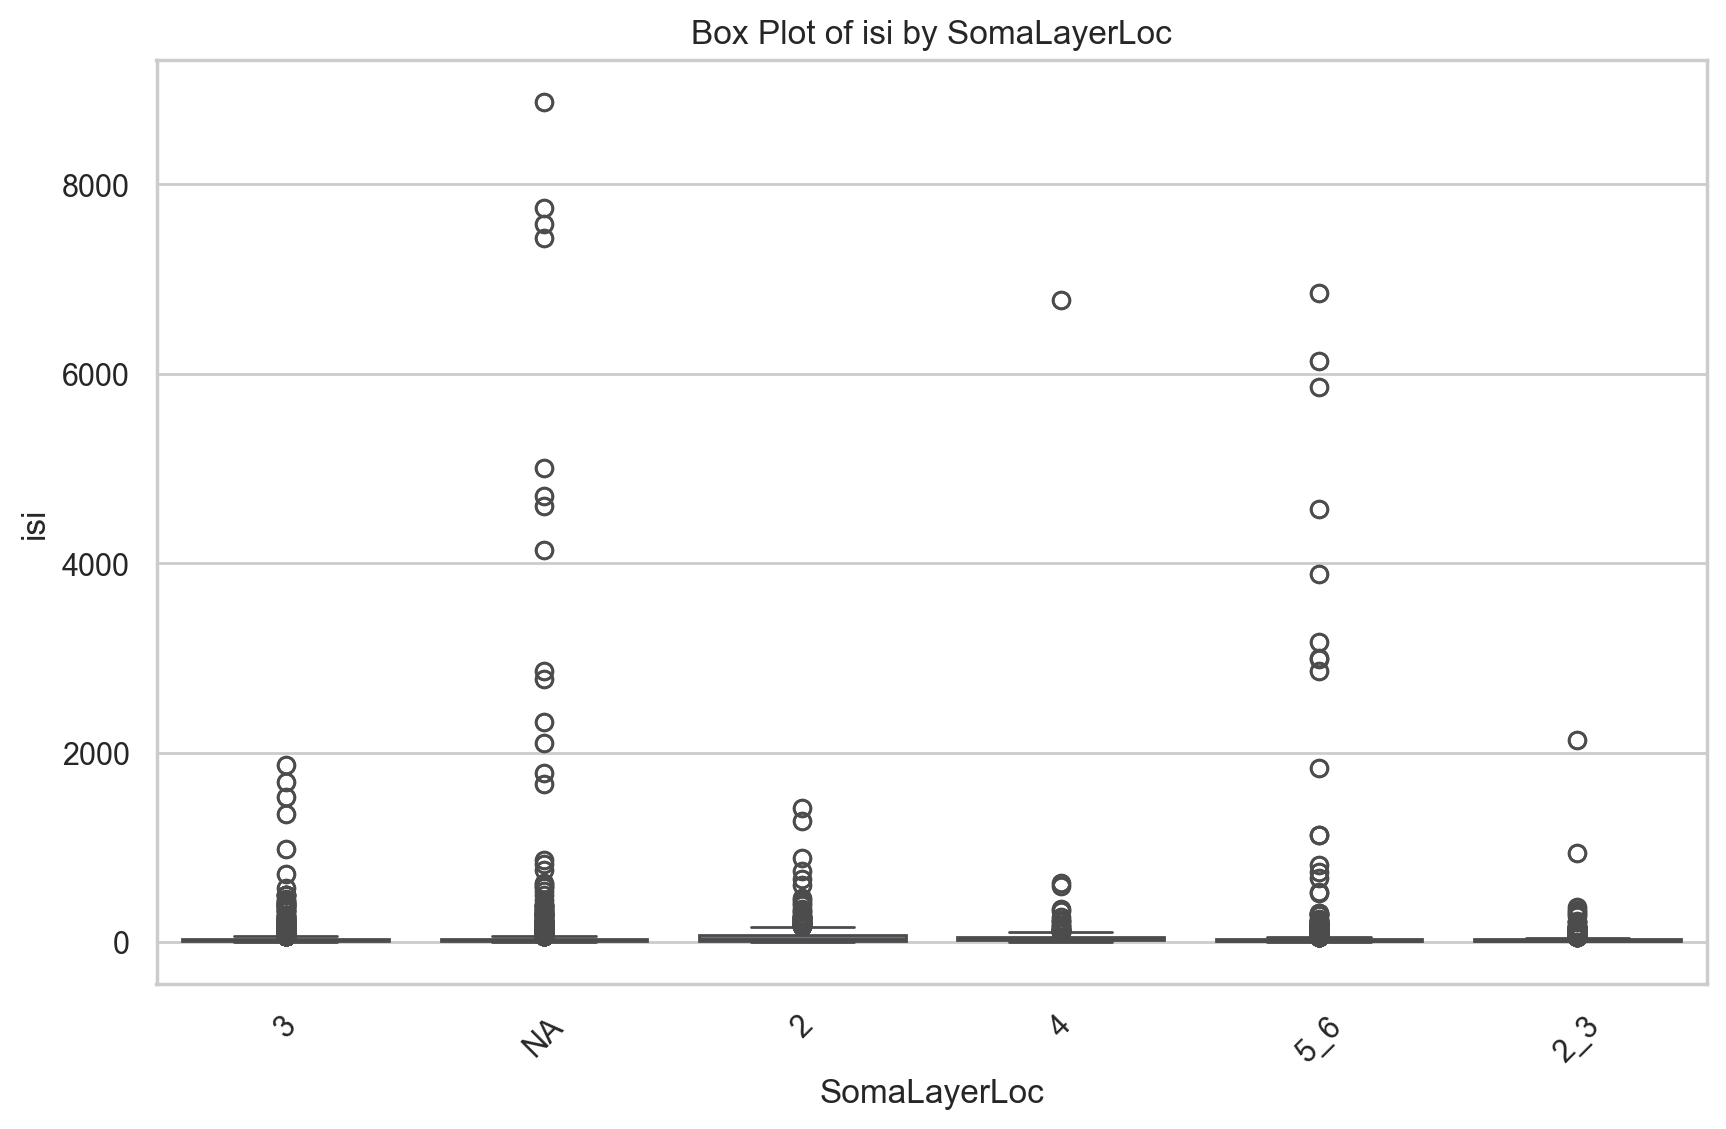

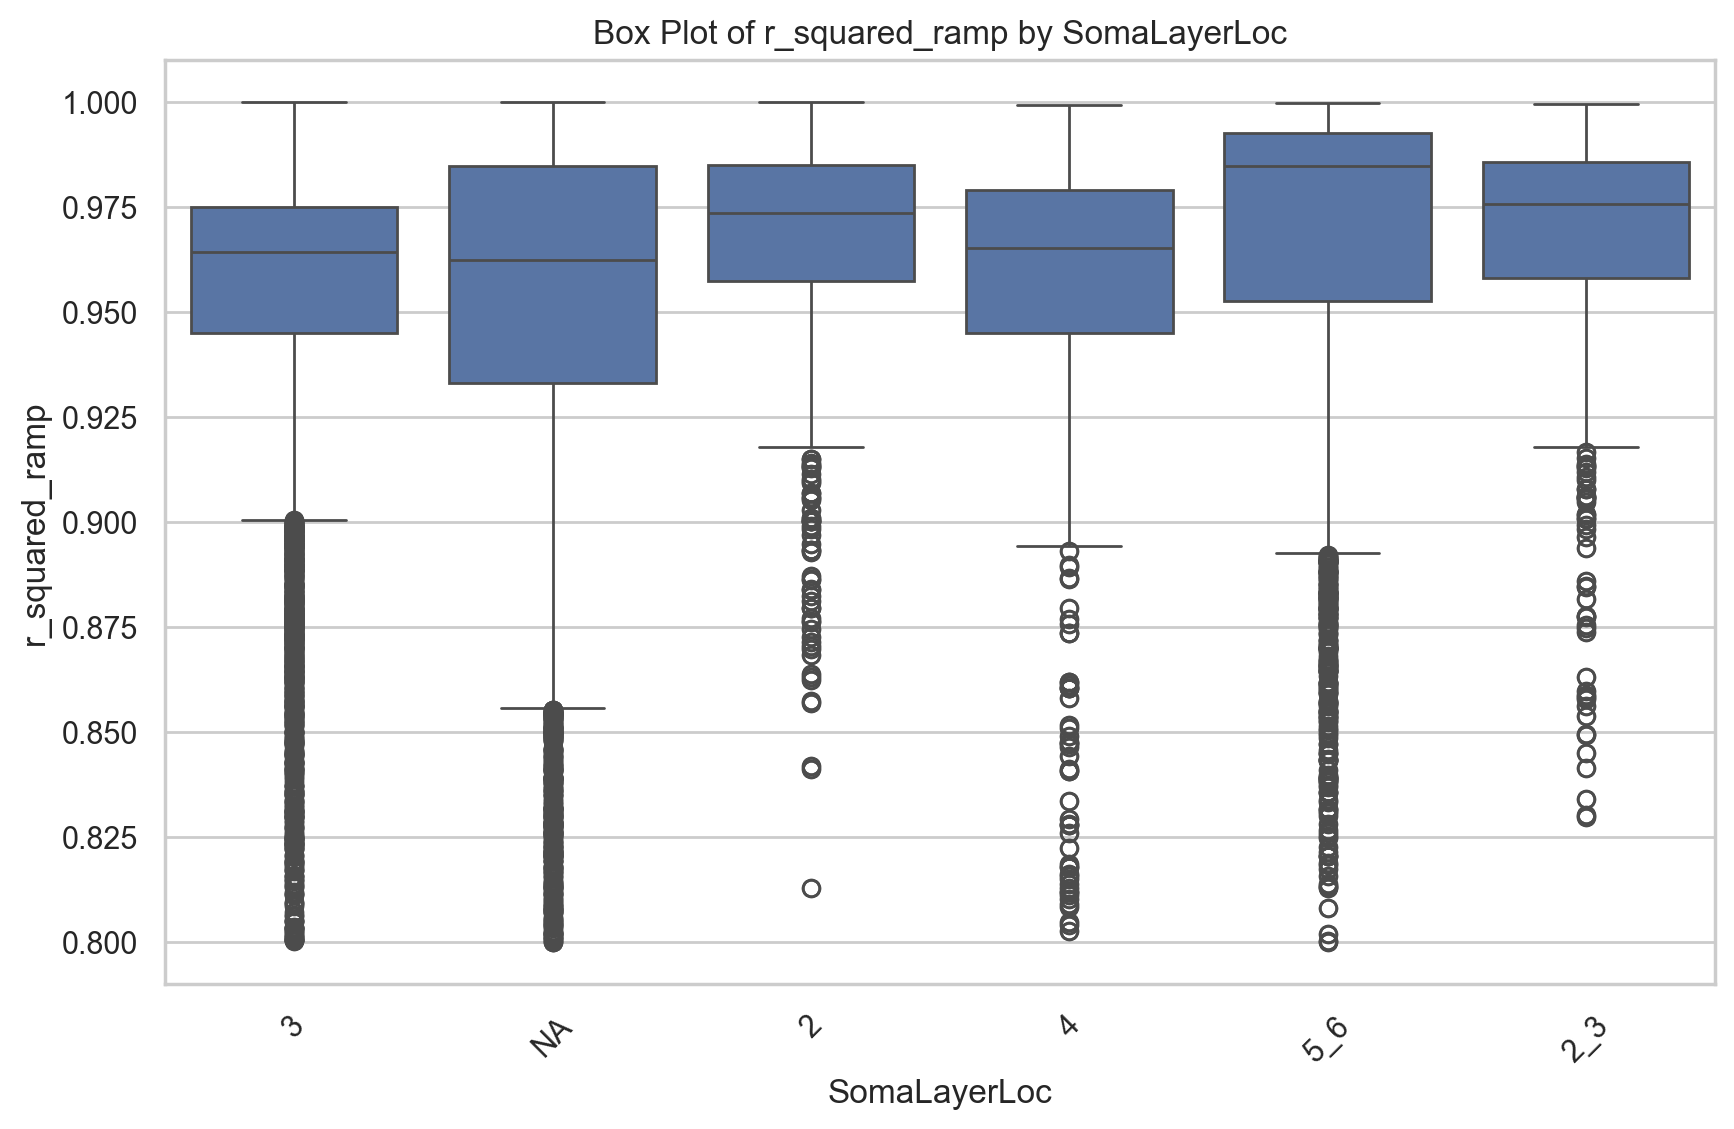

In [86]:
boxplots_by_Param('SomaLayerLoc')

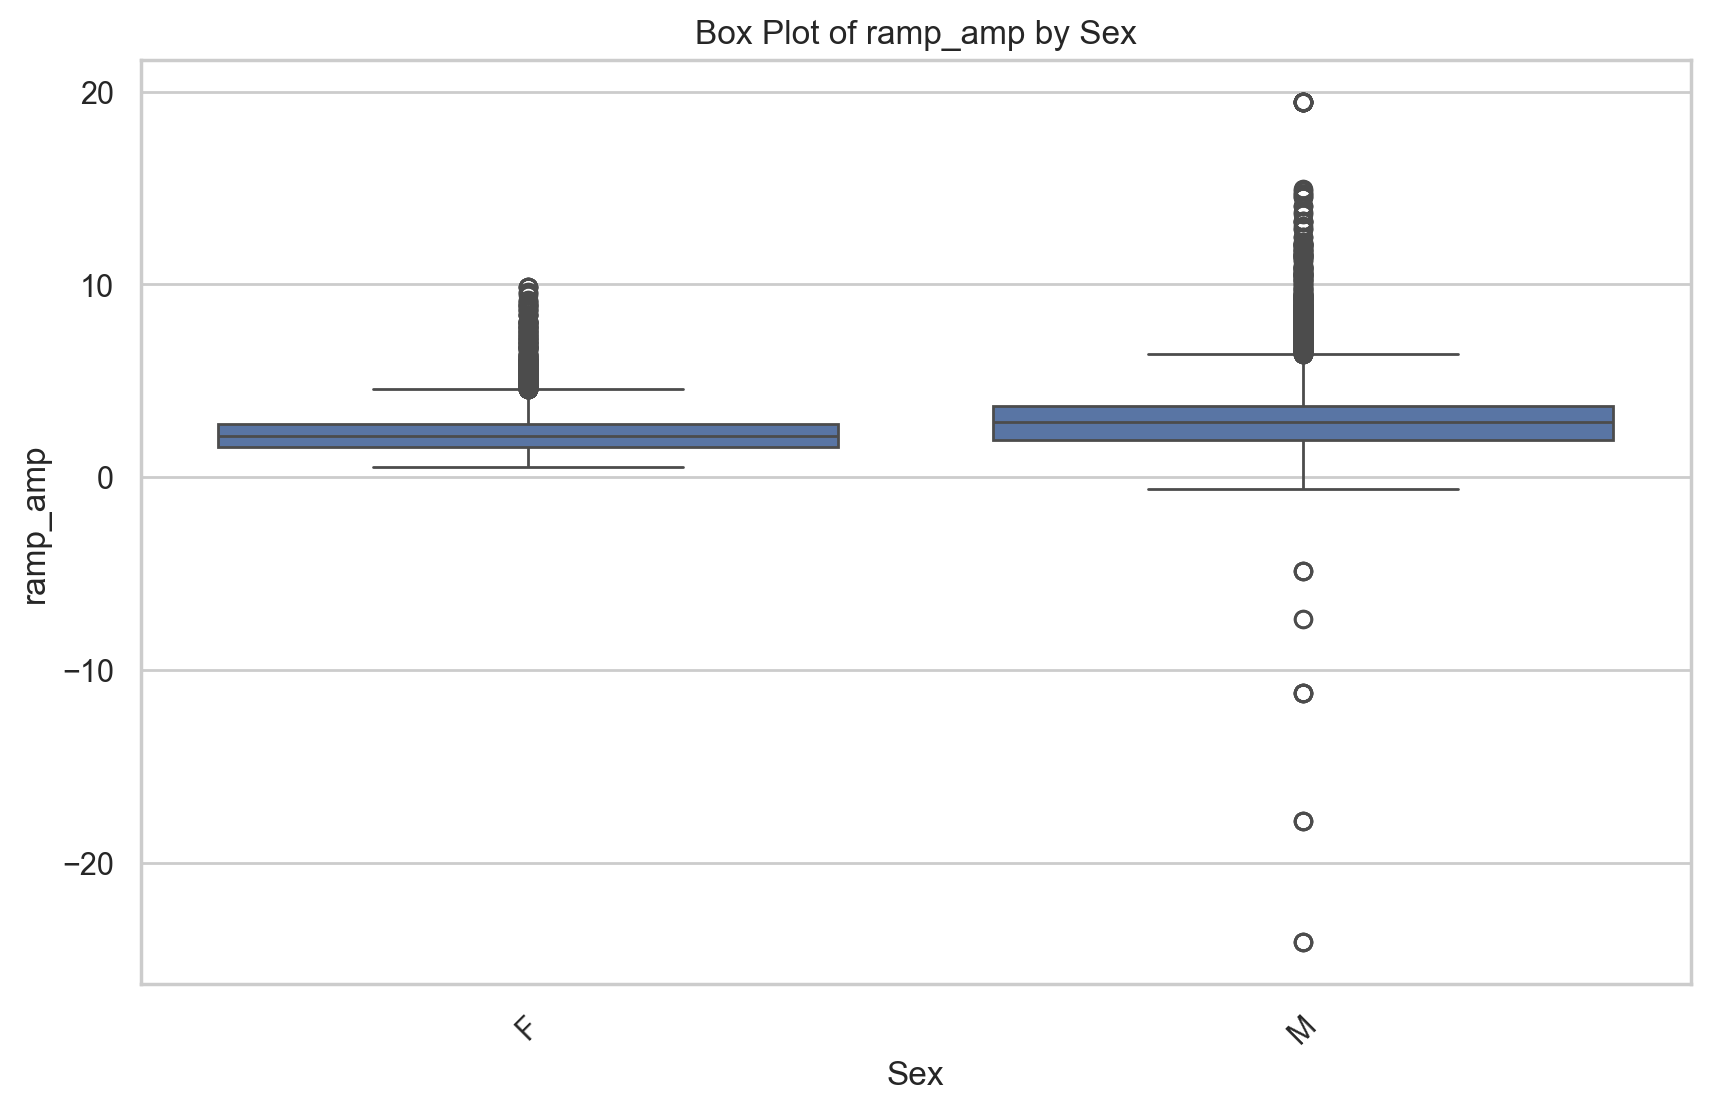

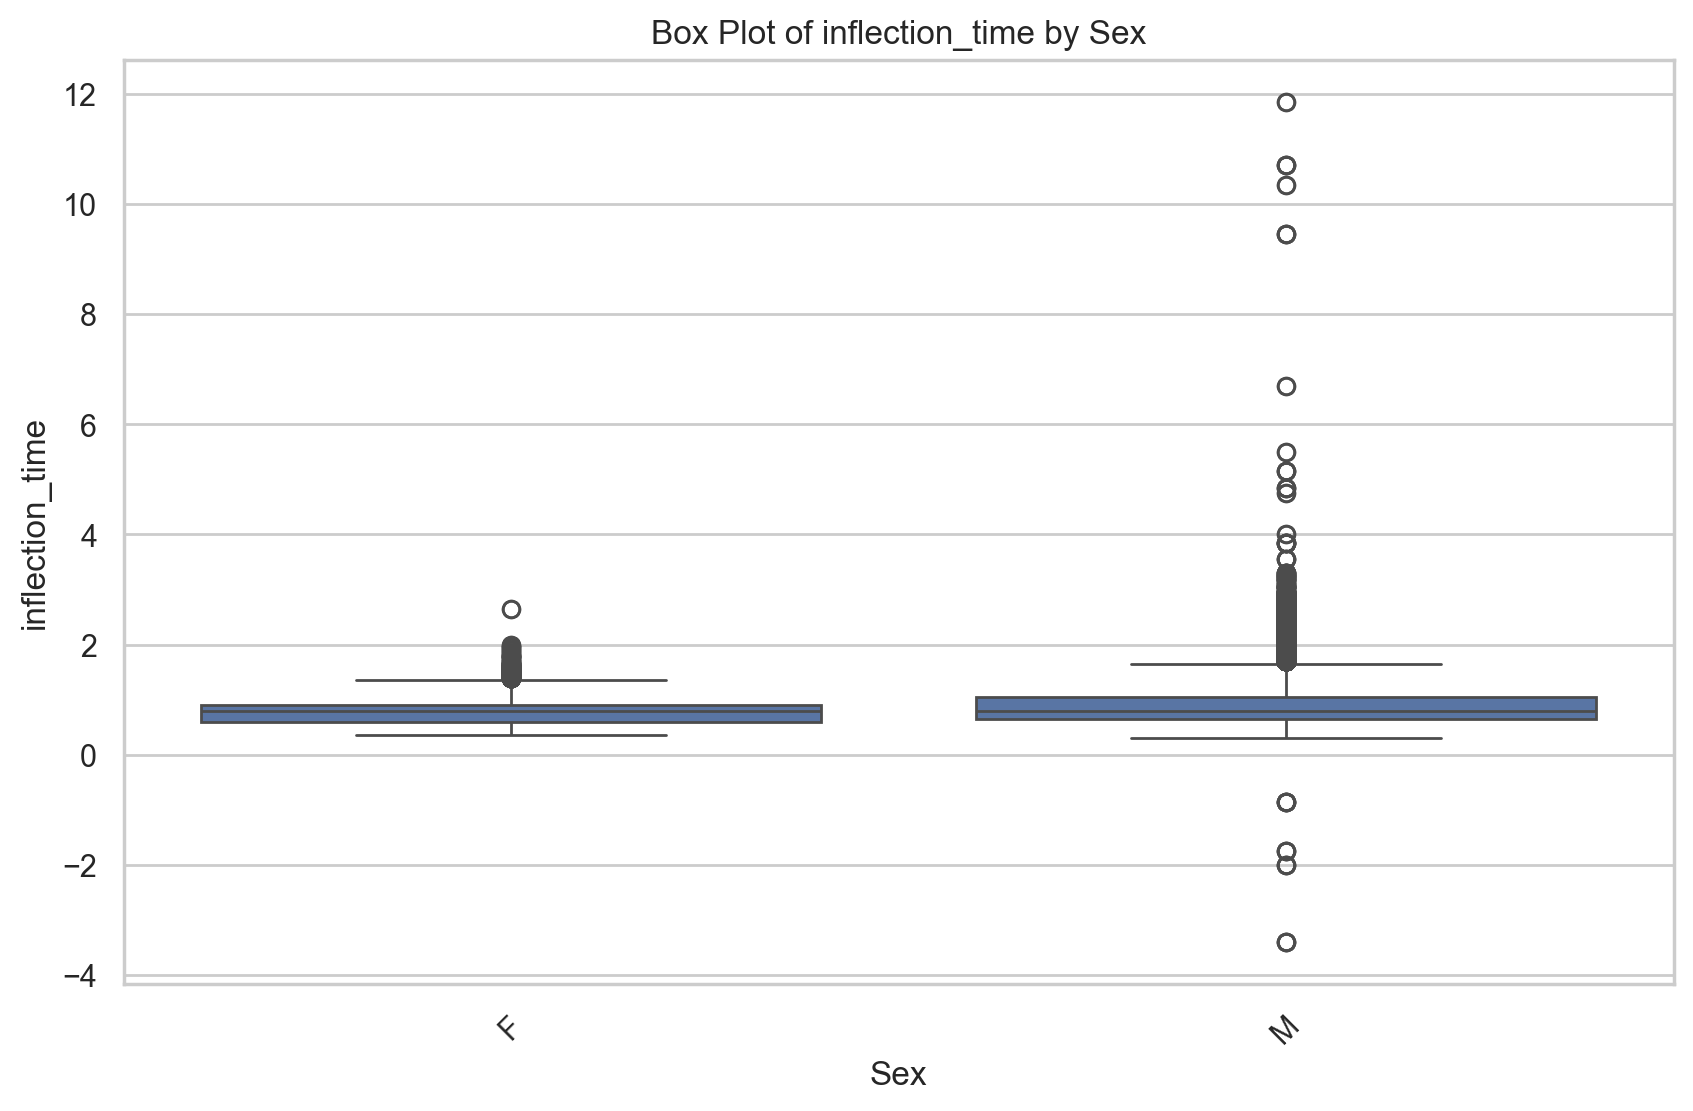

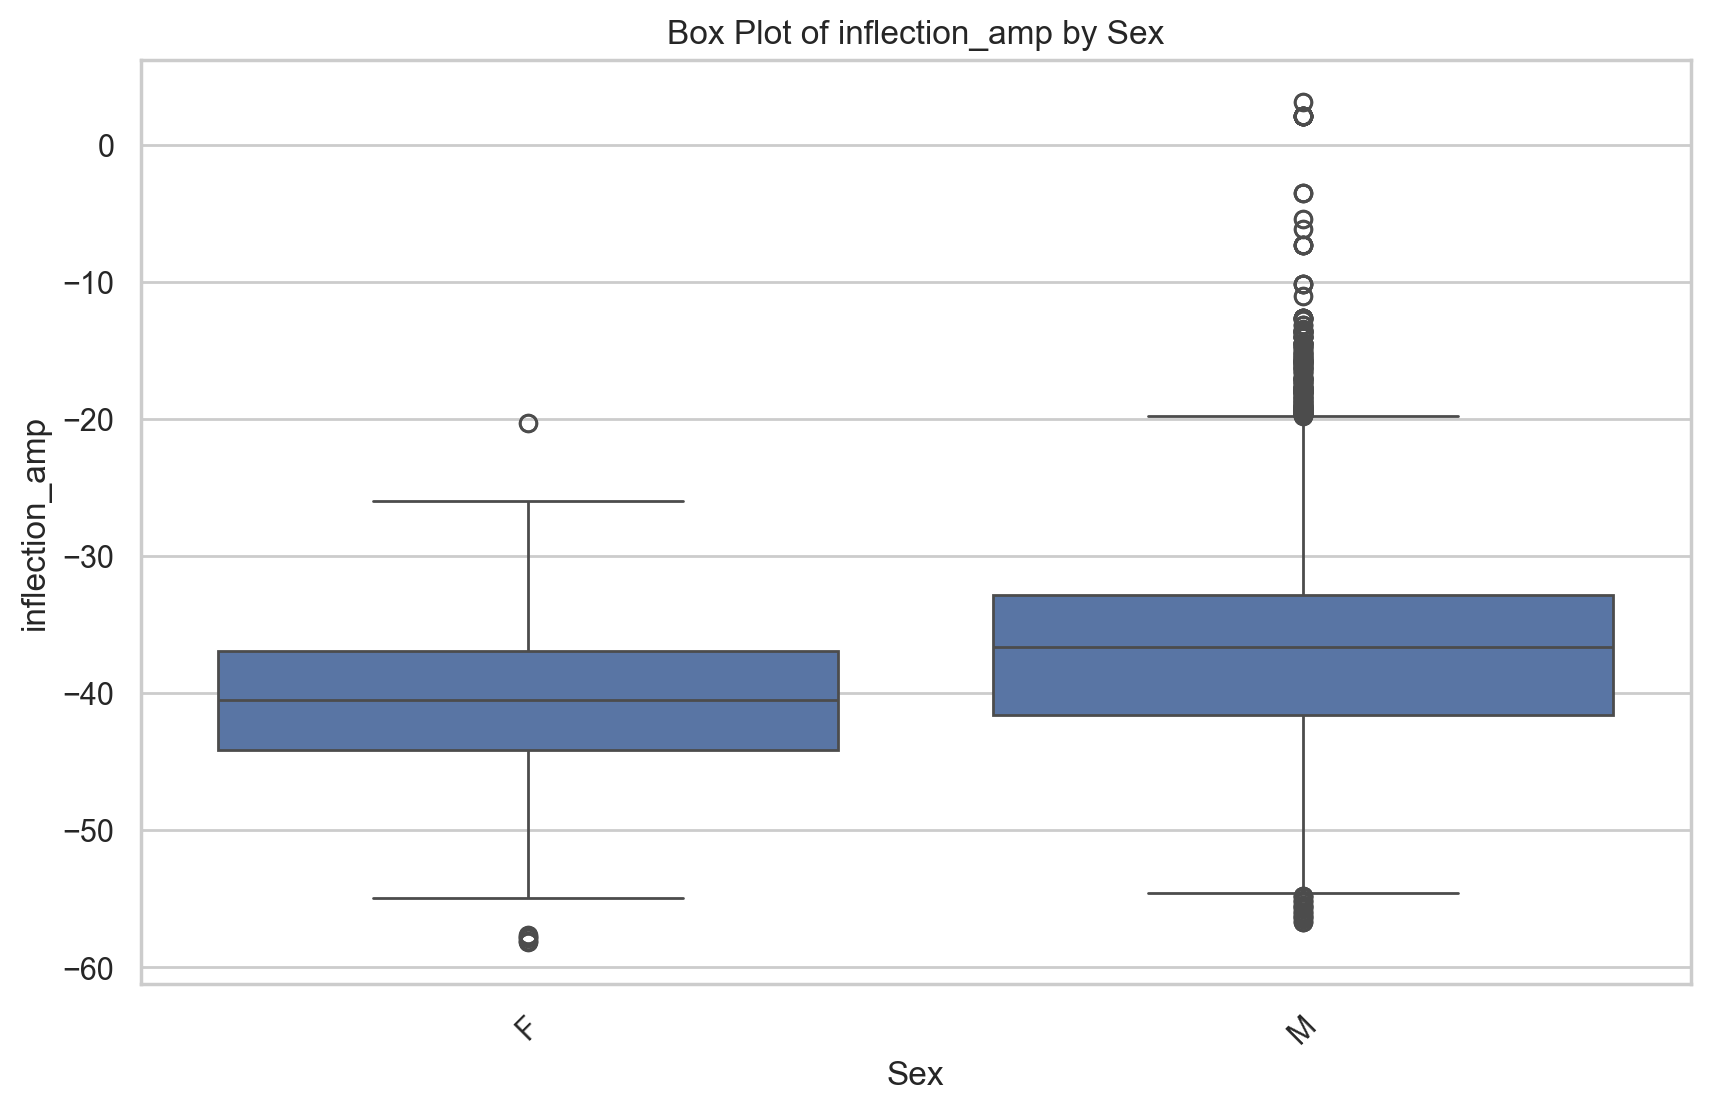

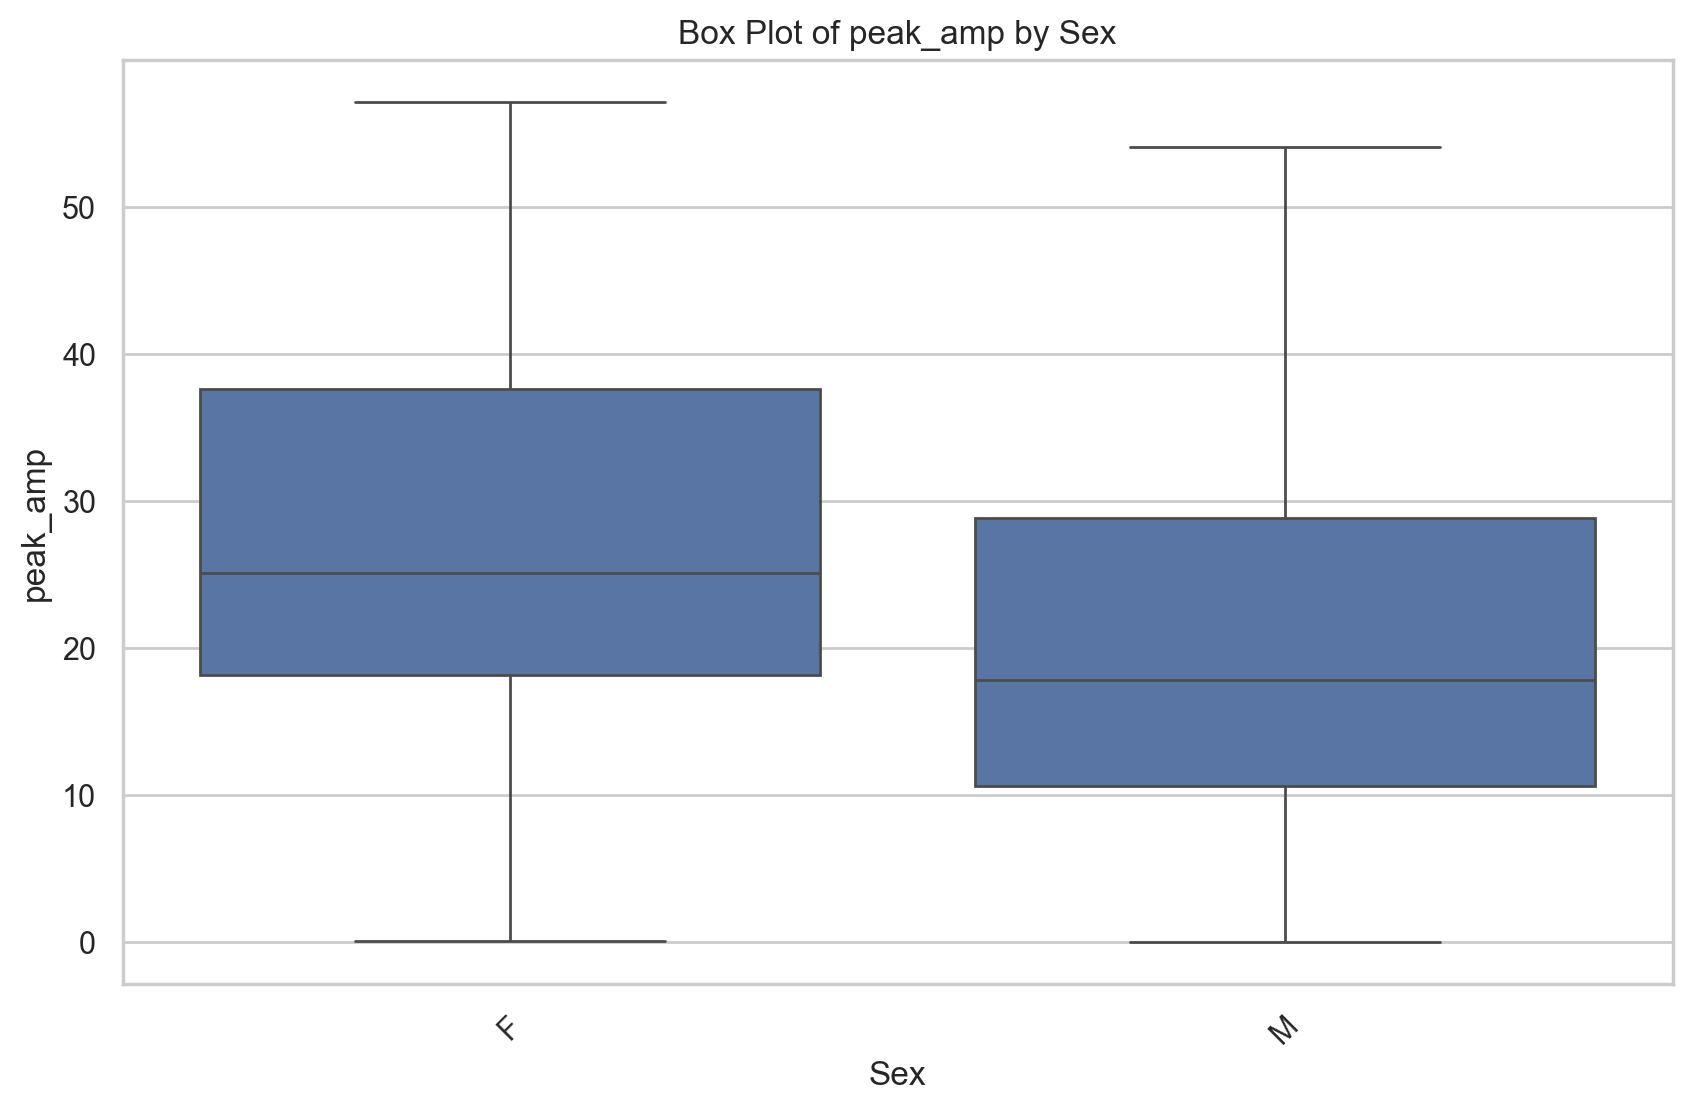

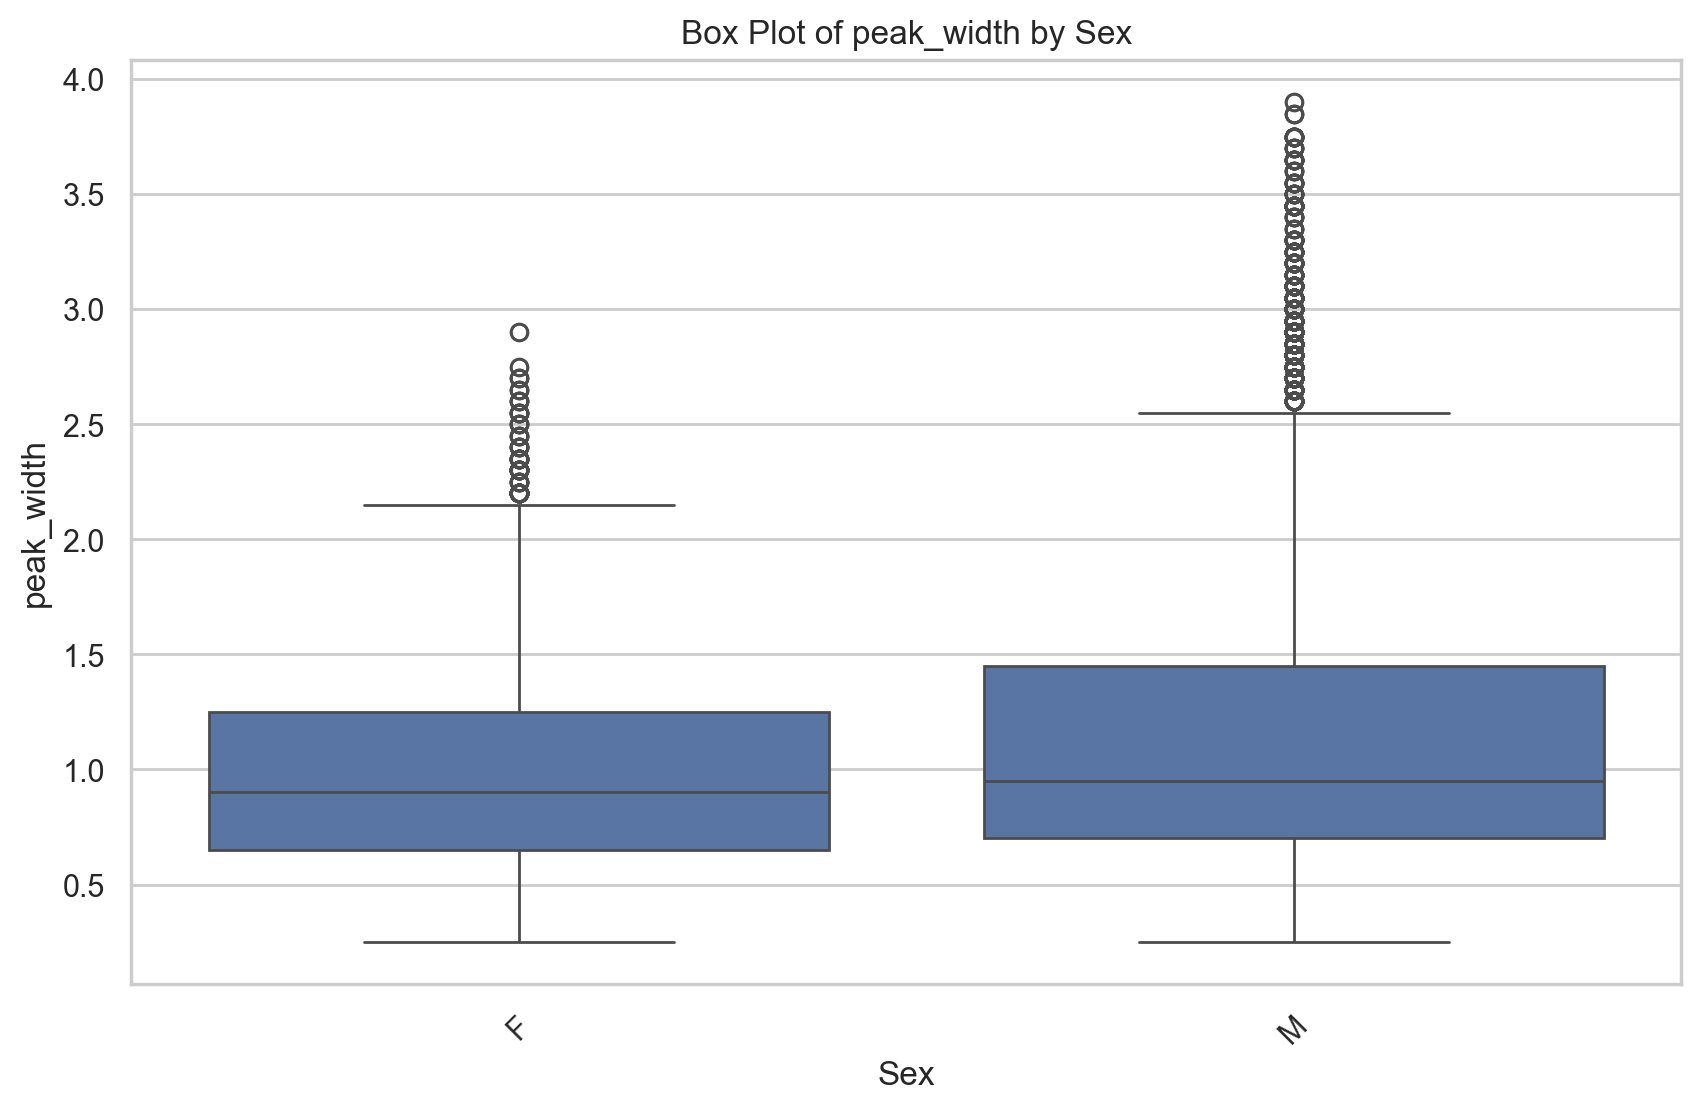

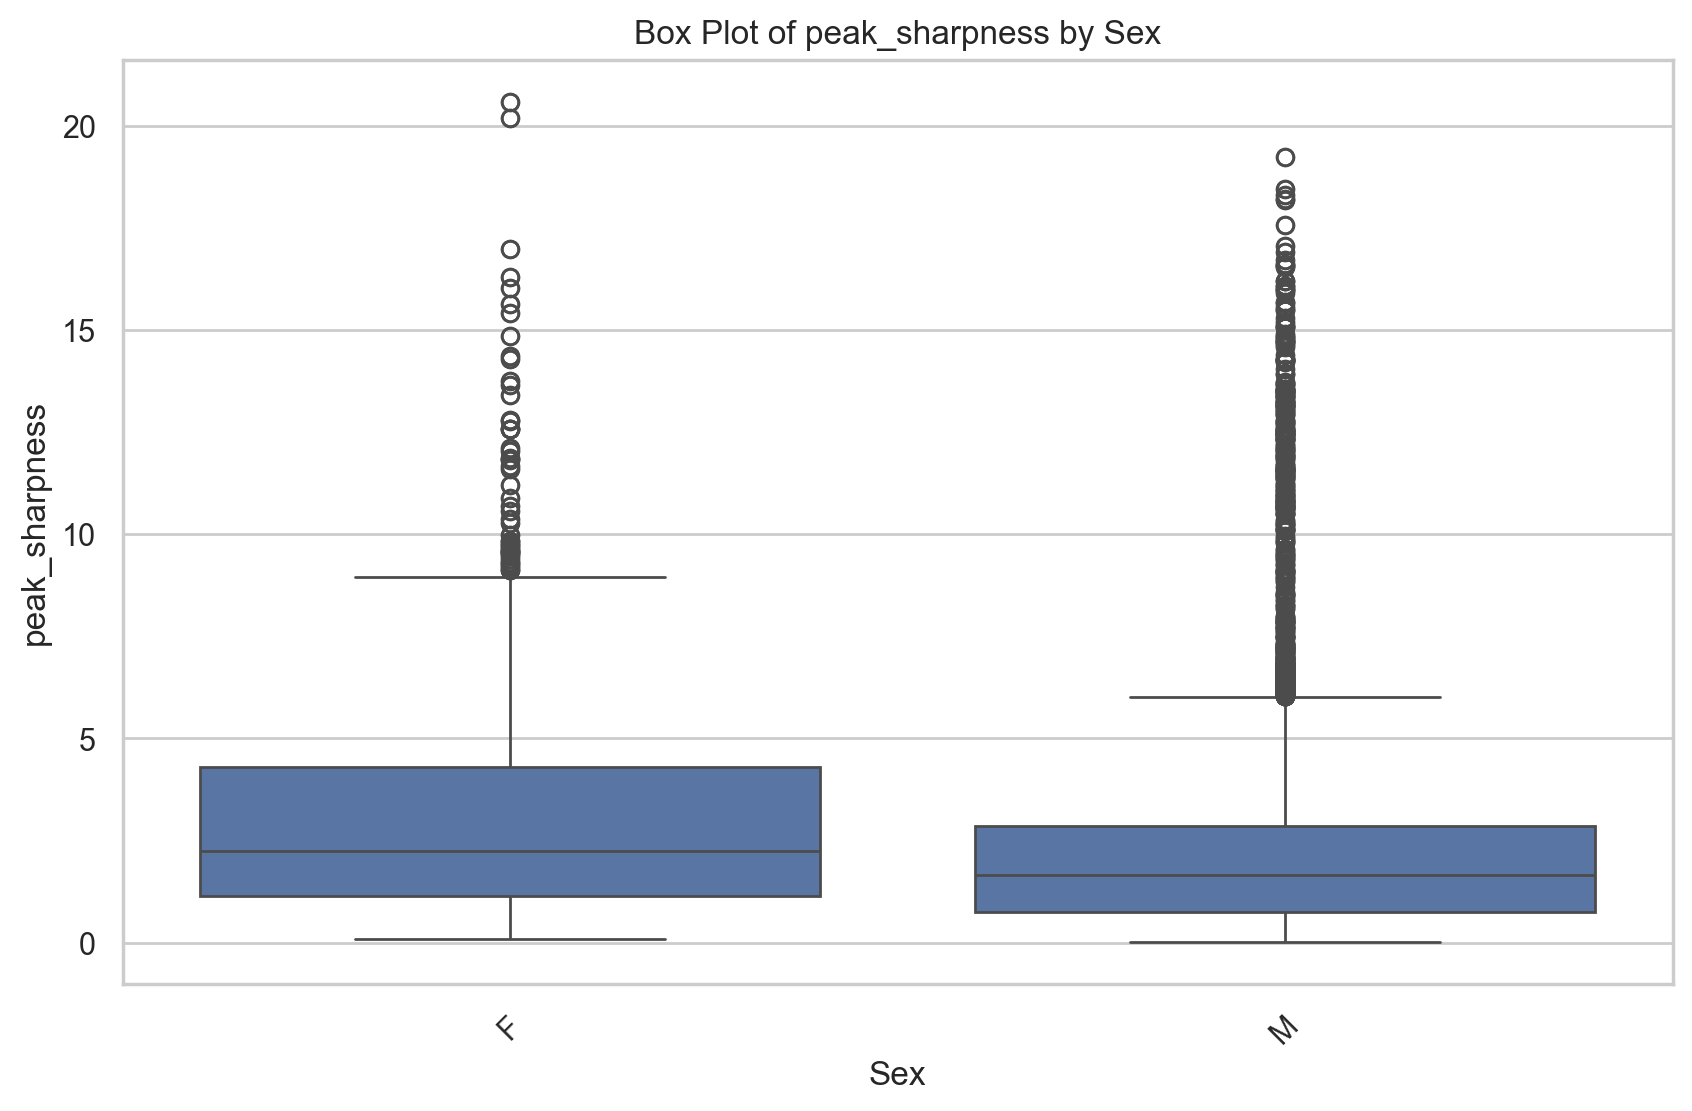

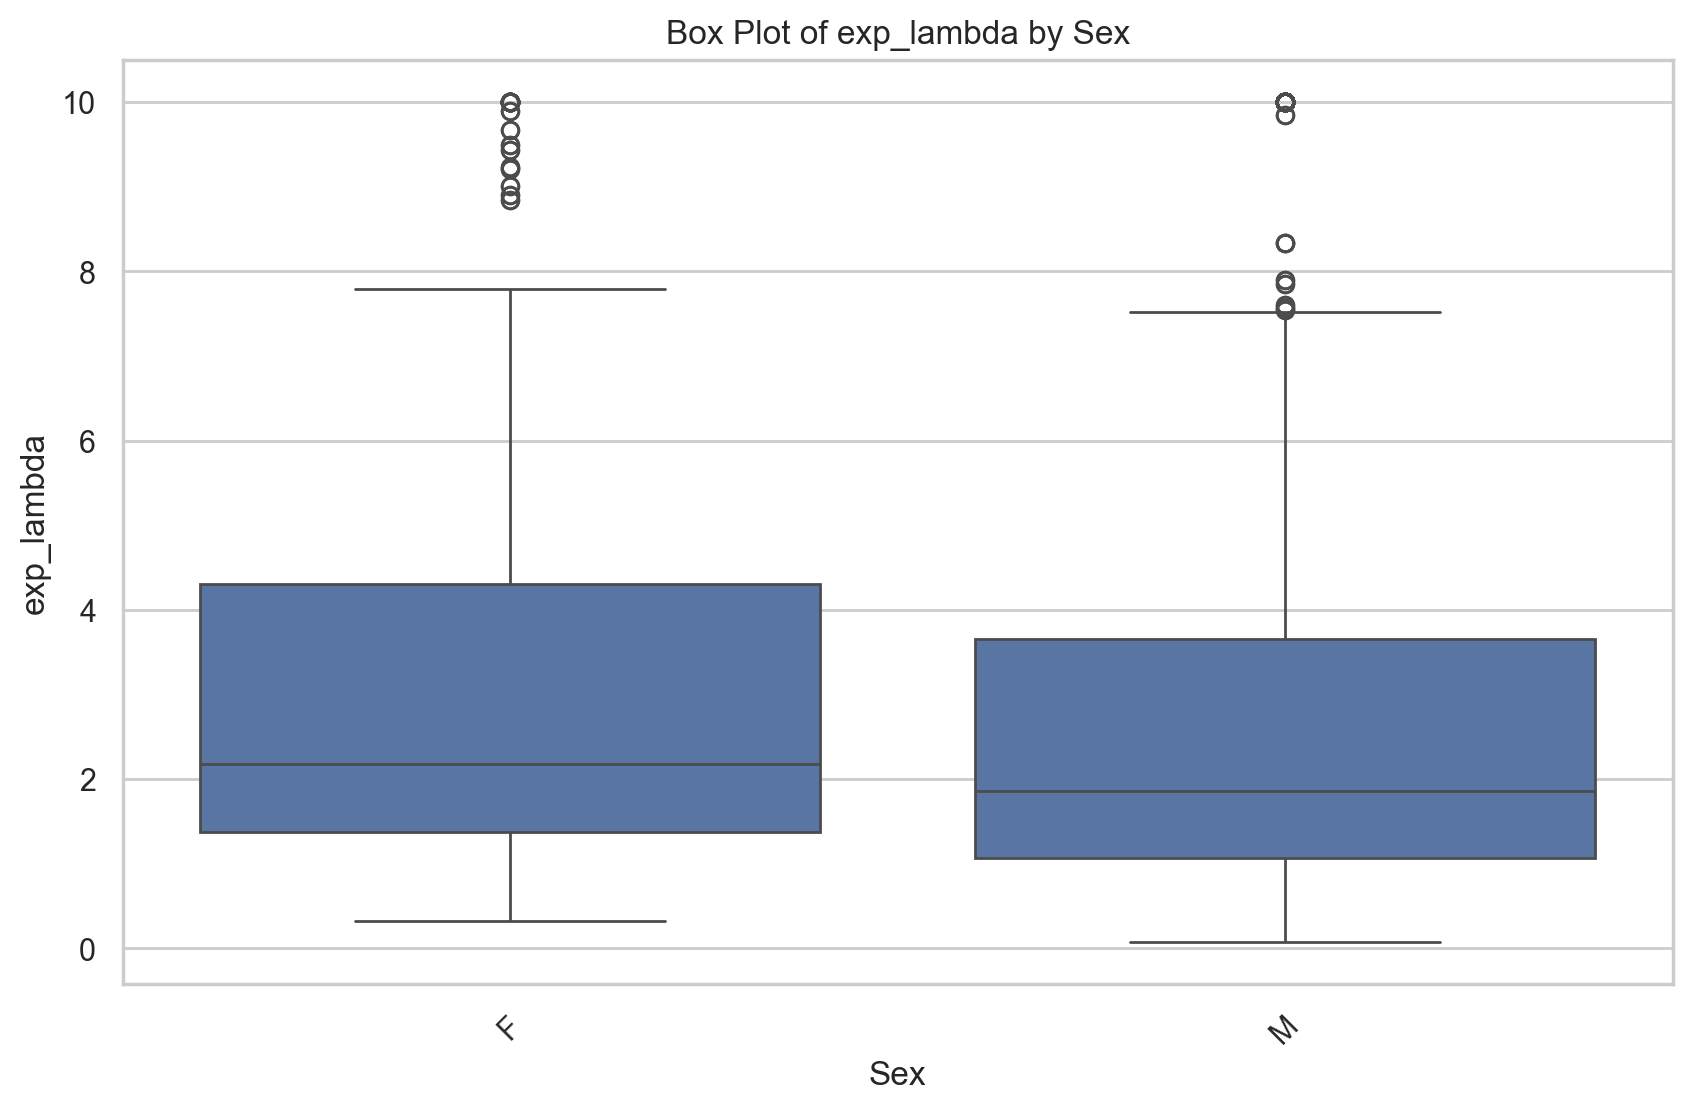

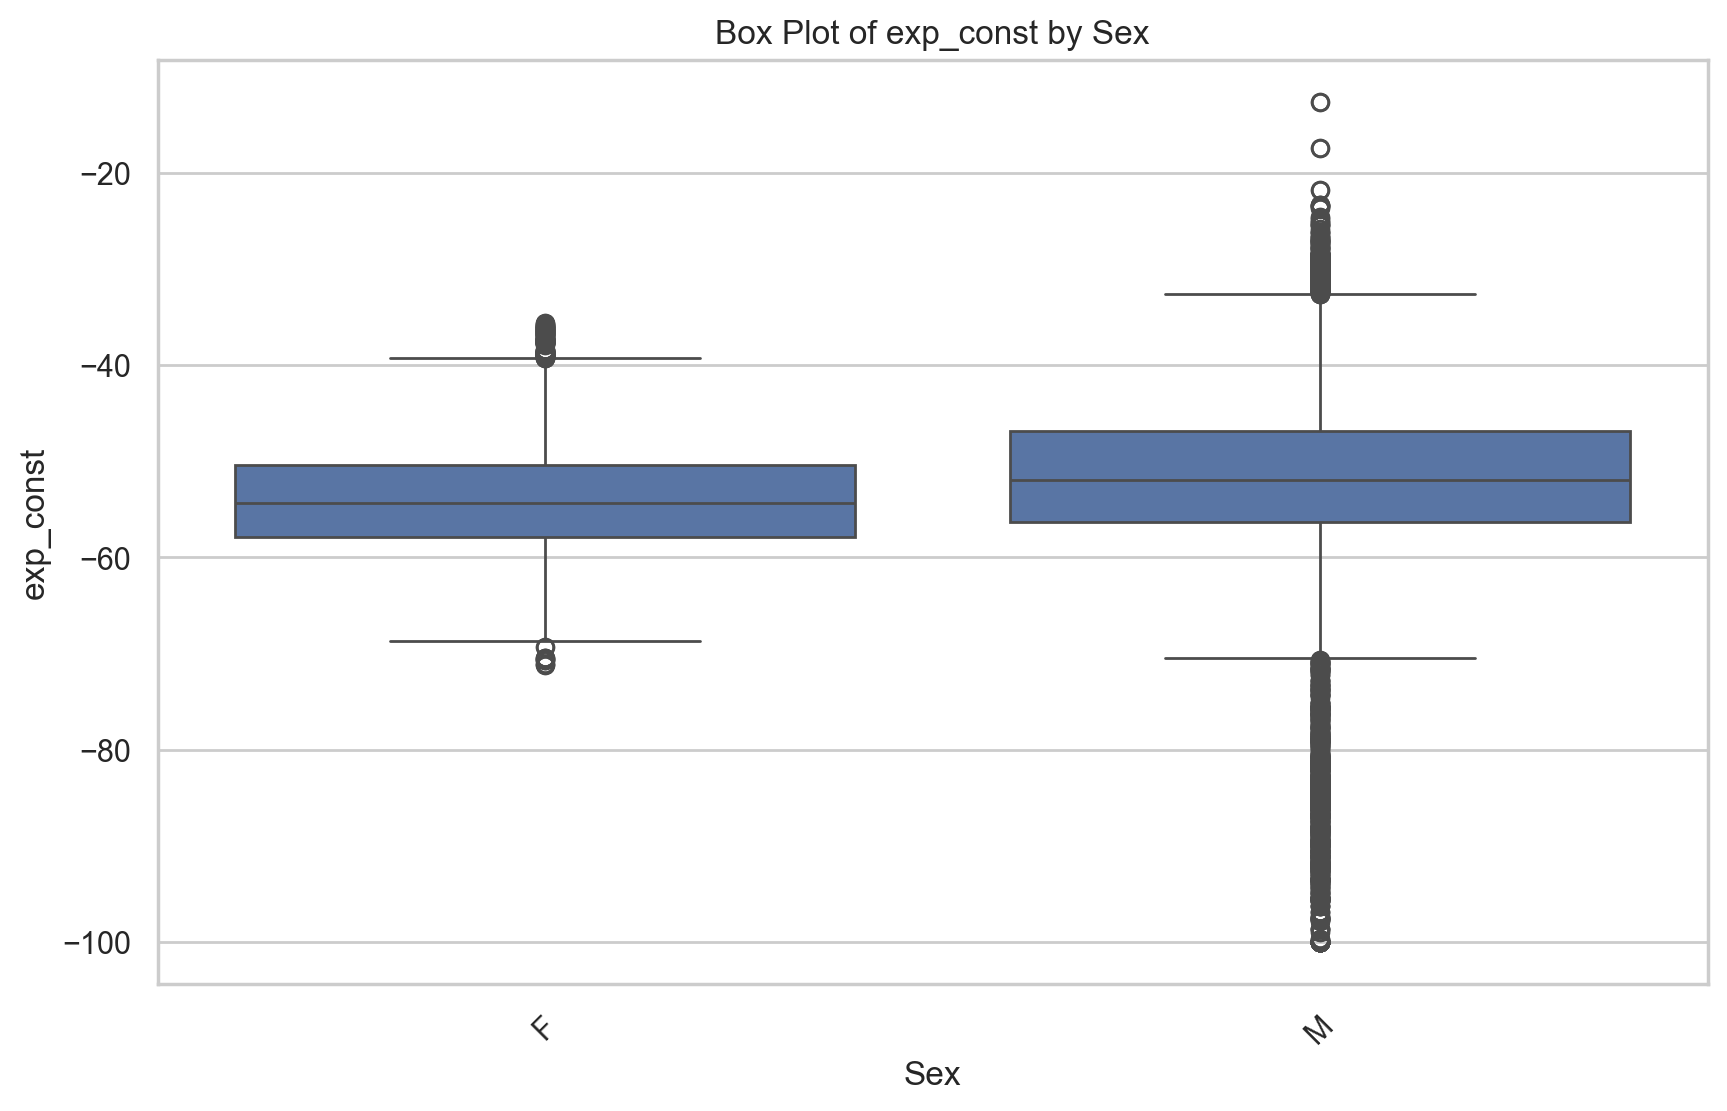

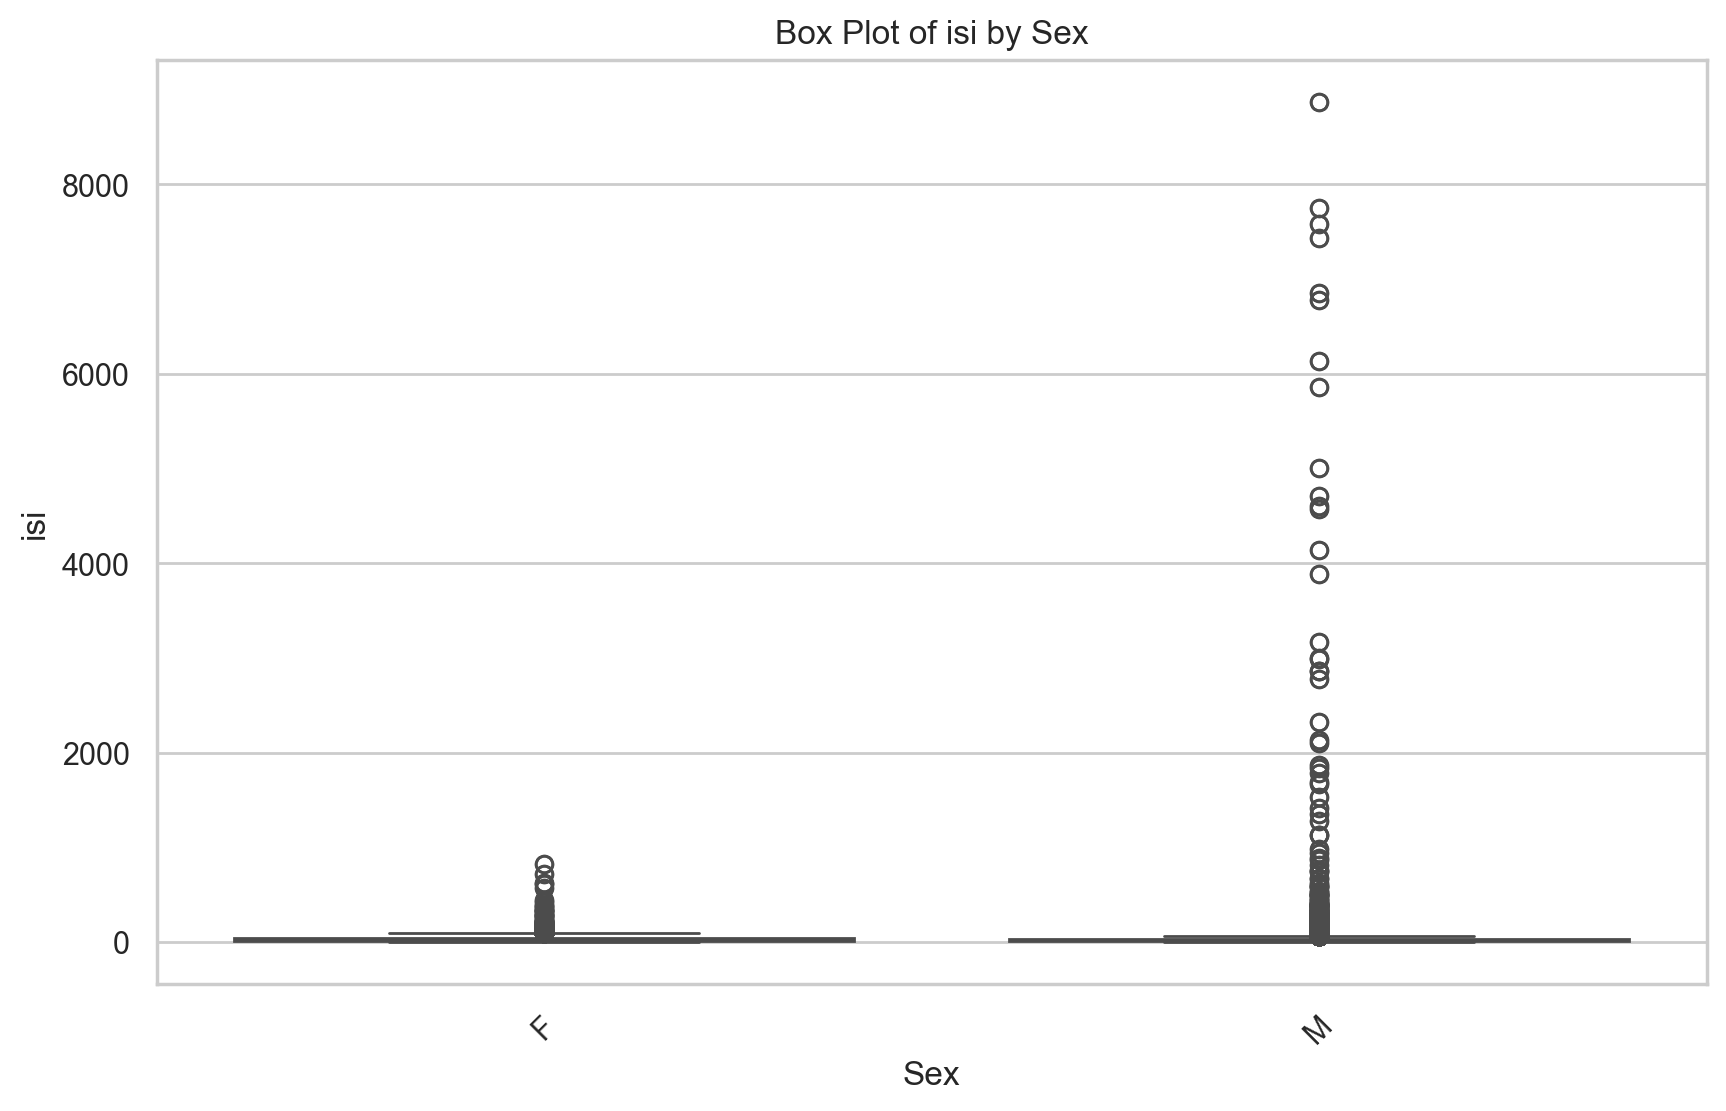

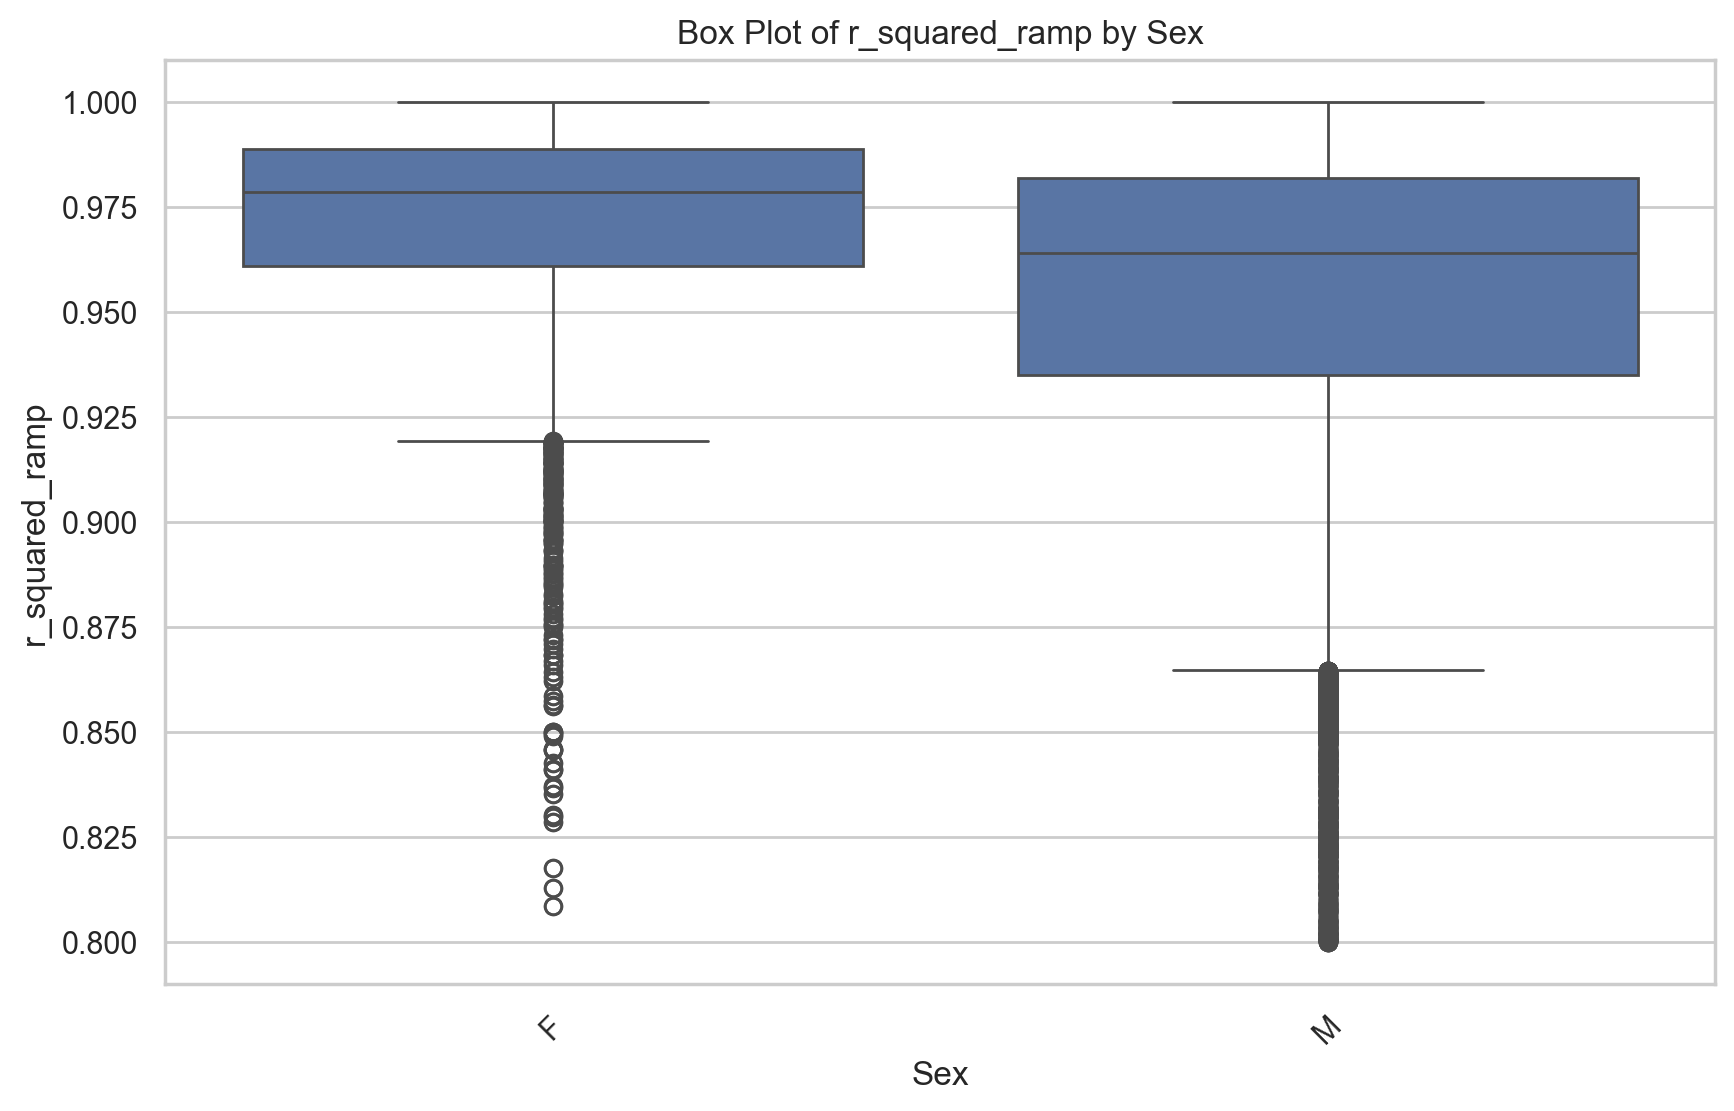

In [88]:
boxplots_by_Param('Sex')

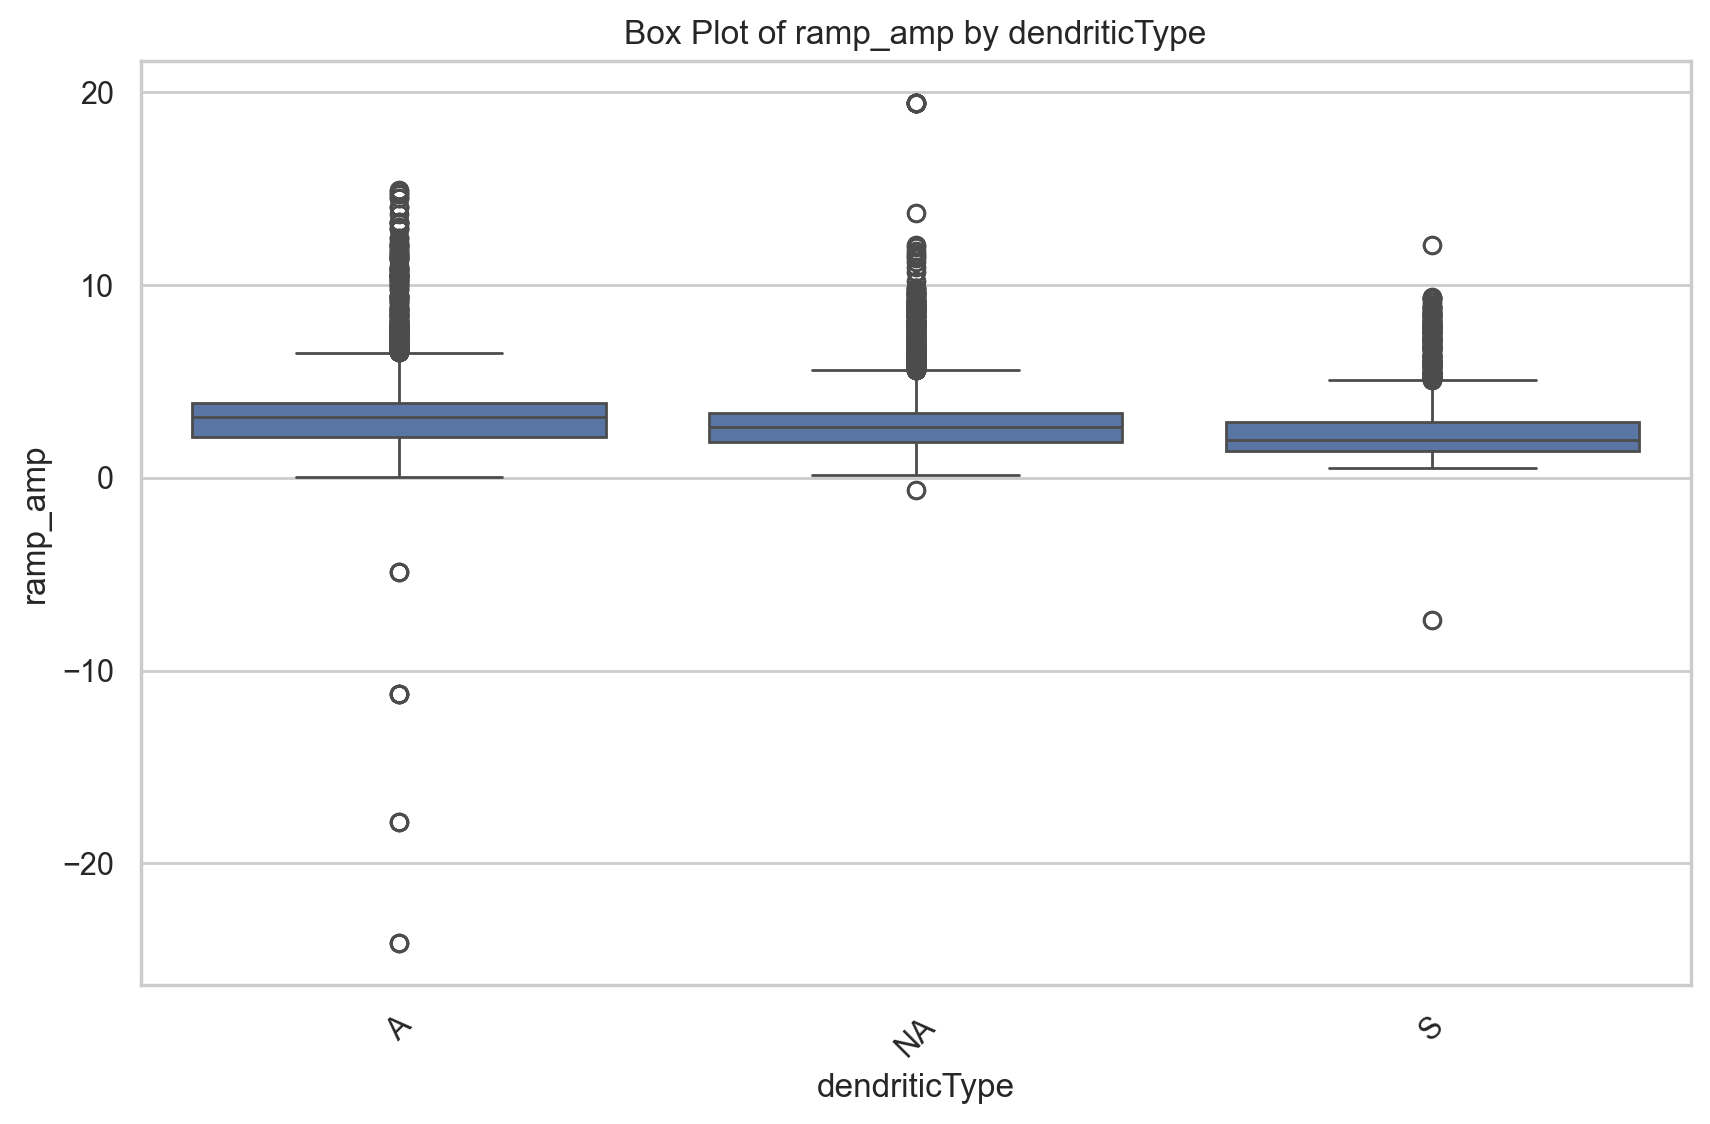

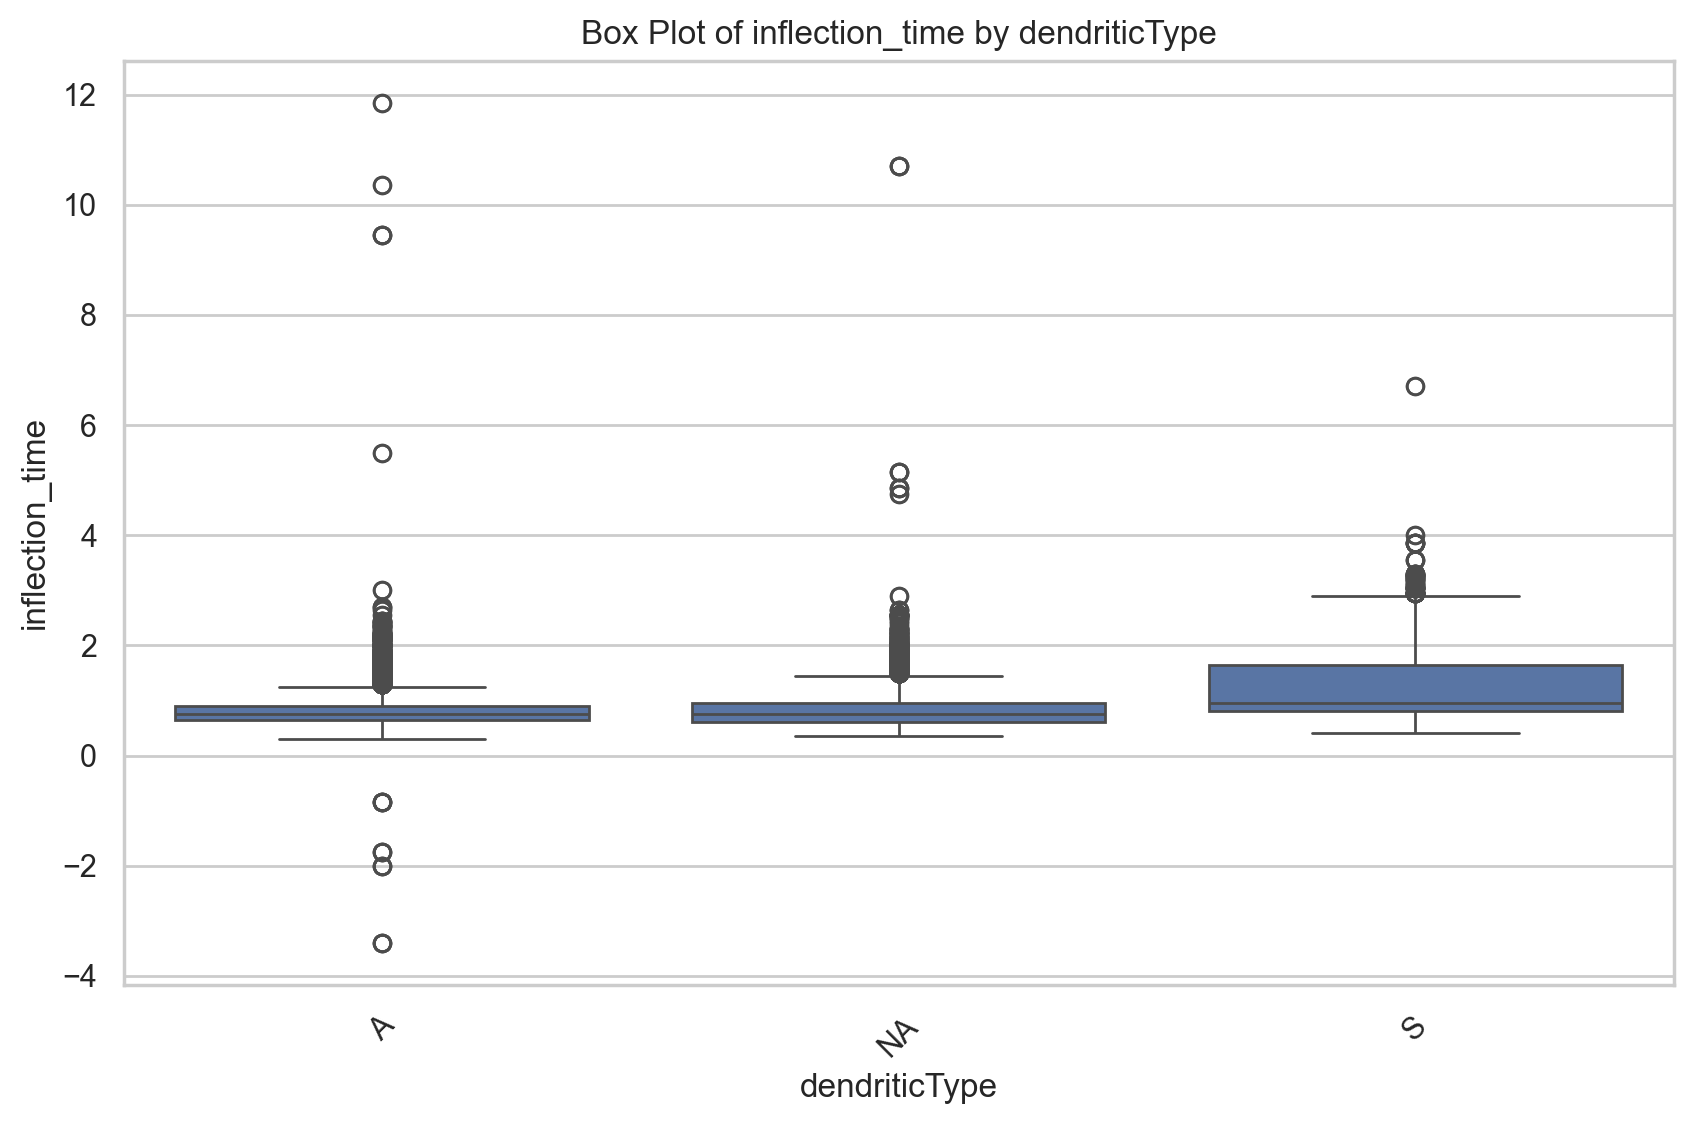

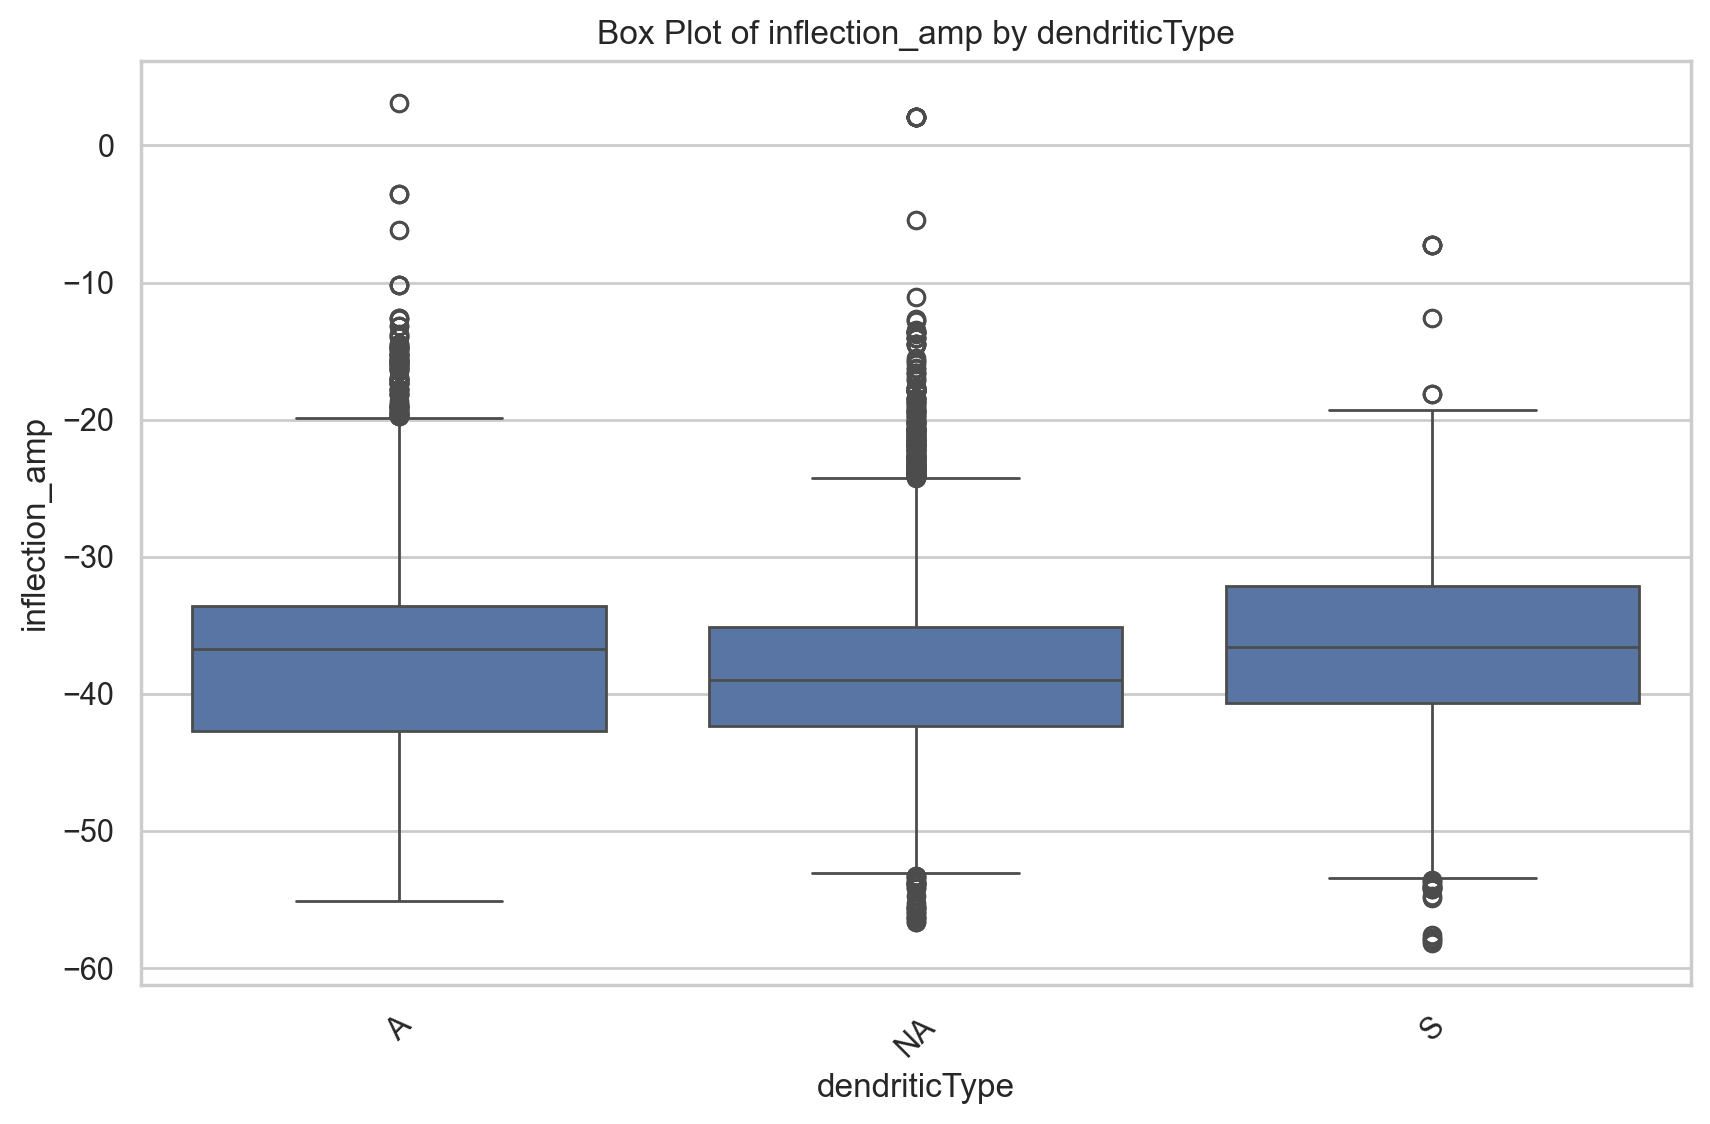

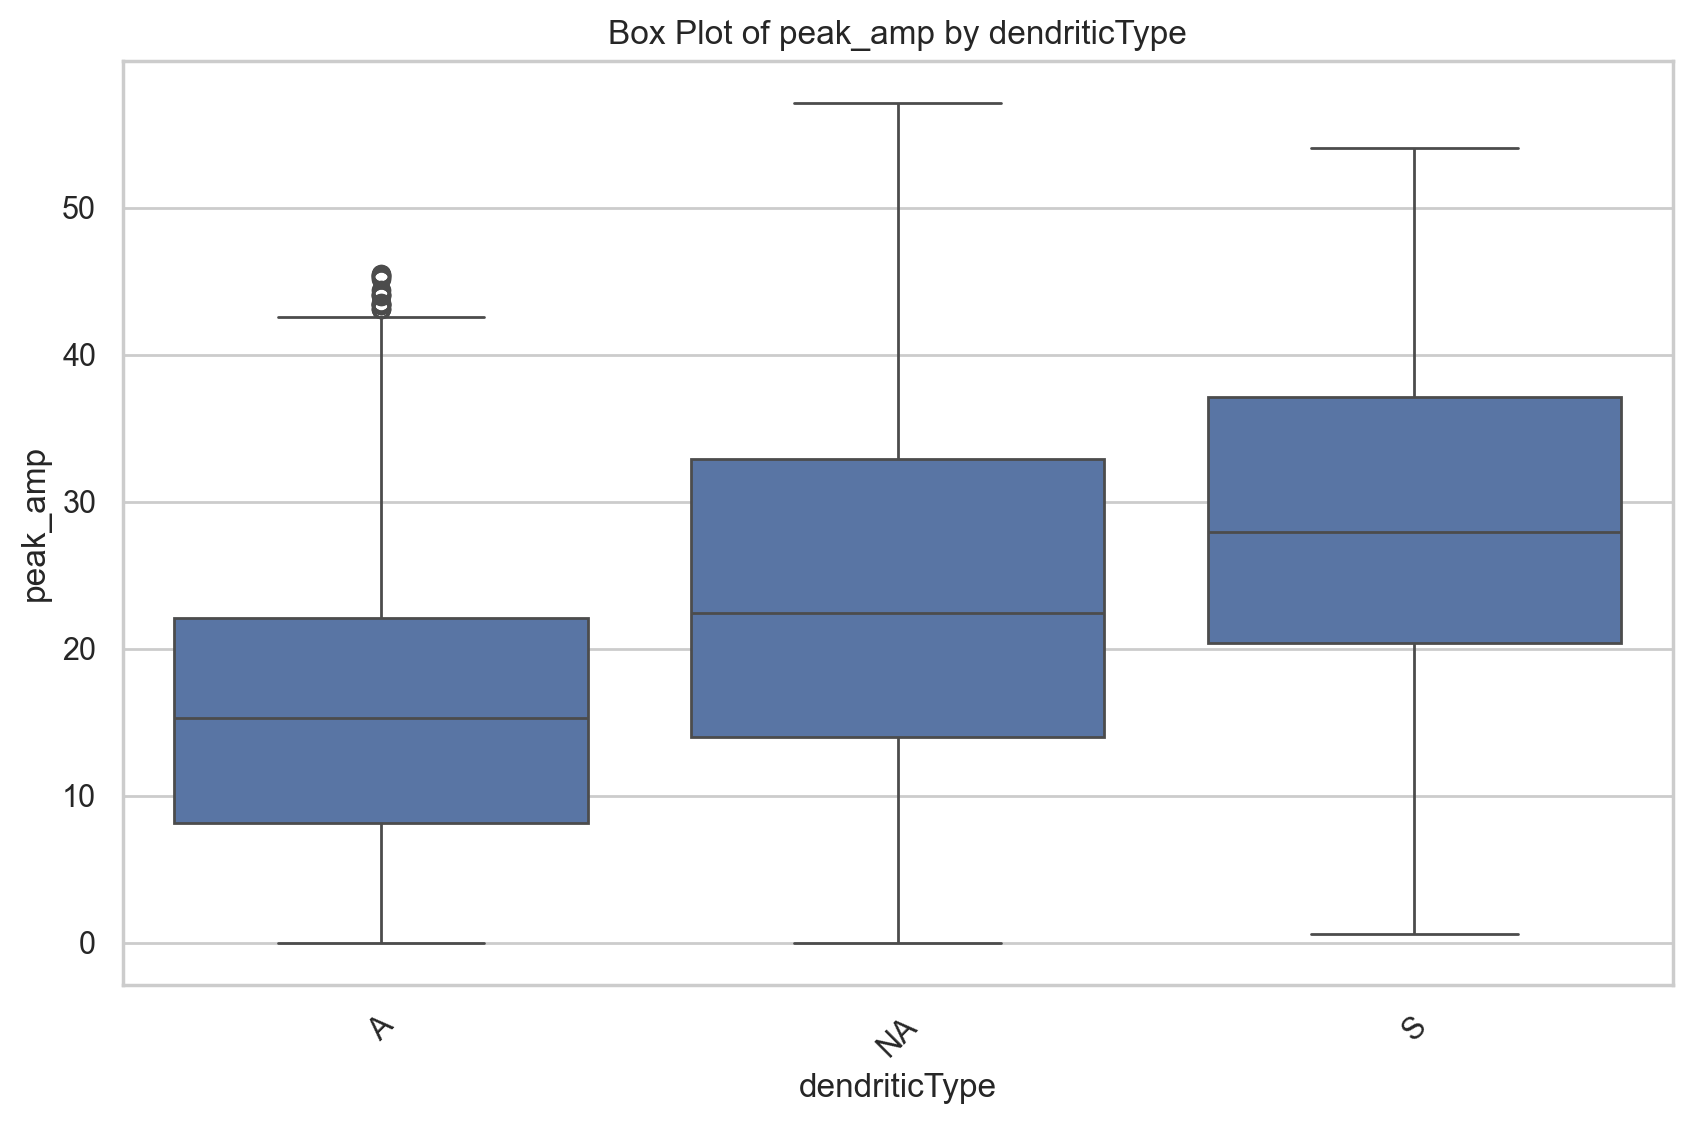

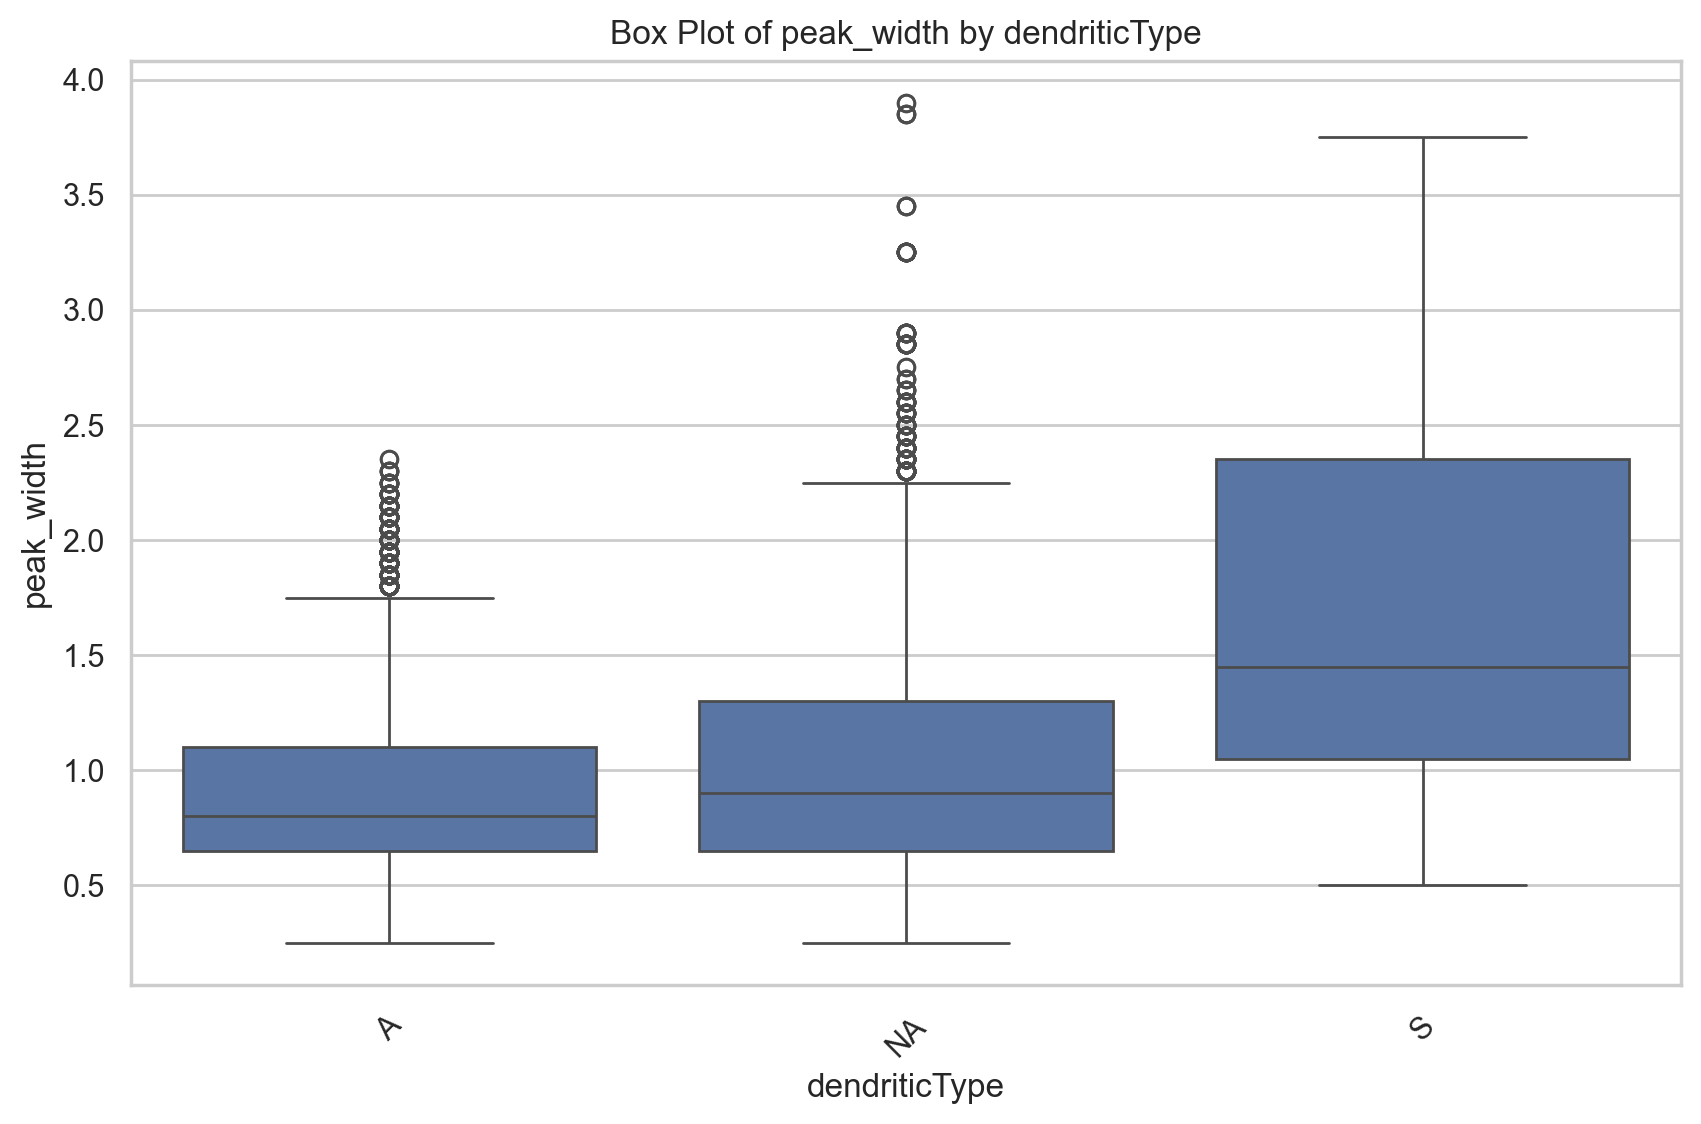

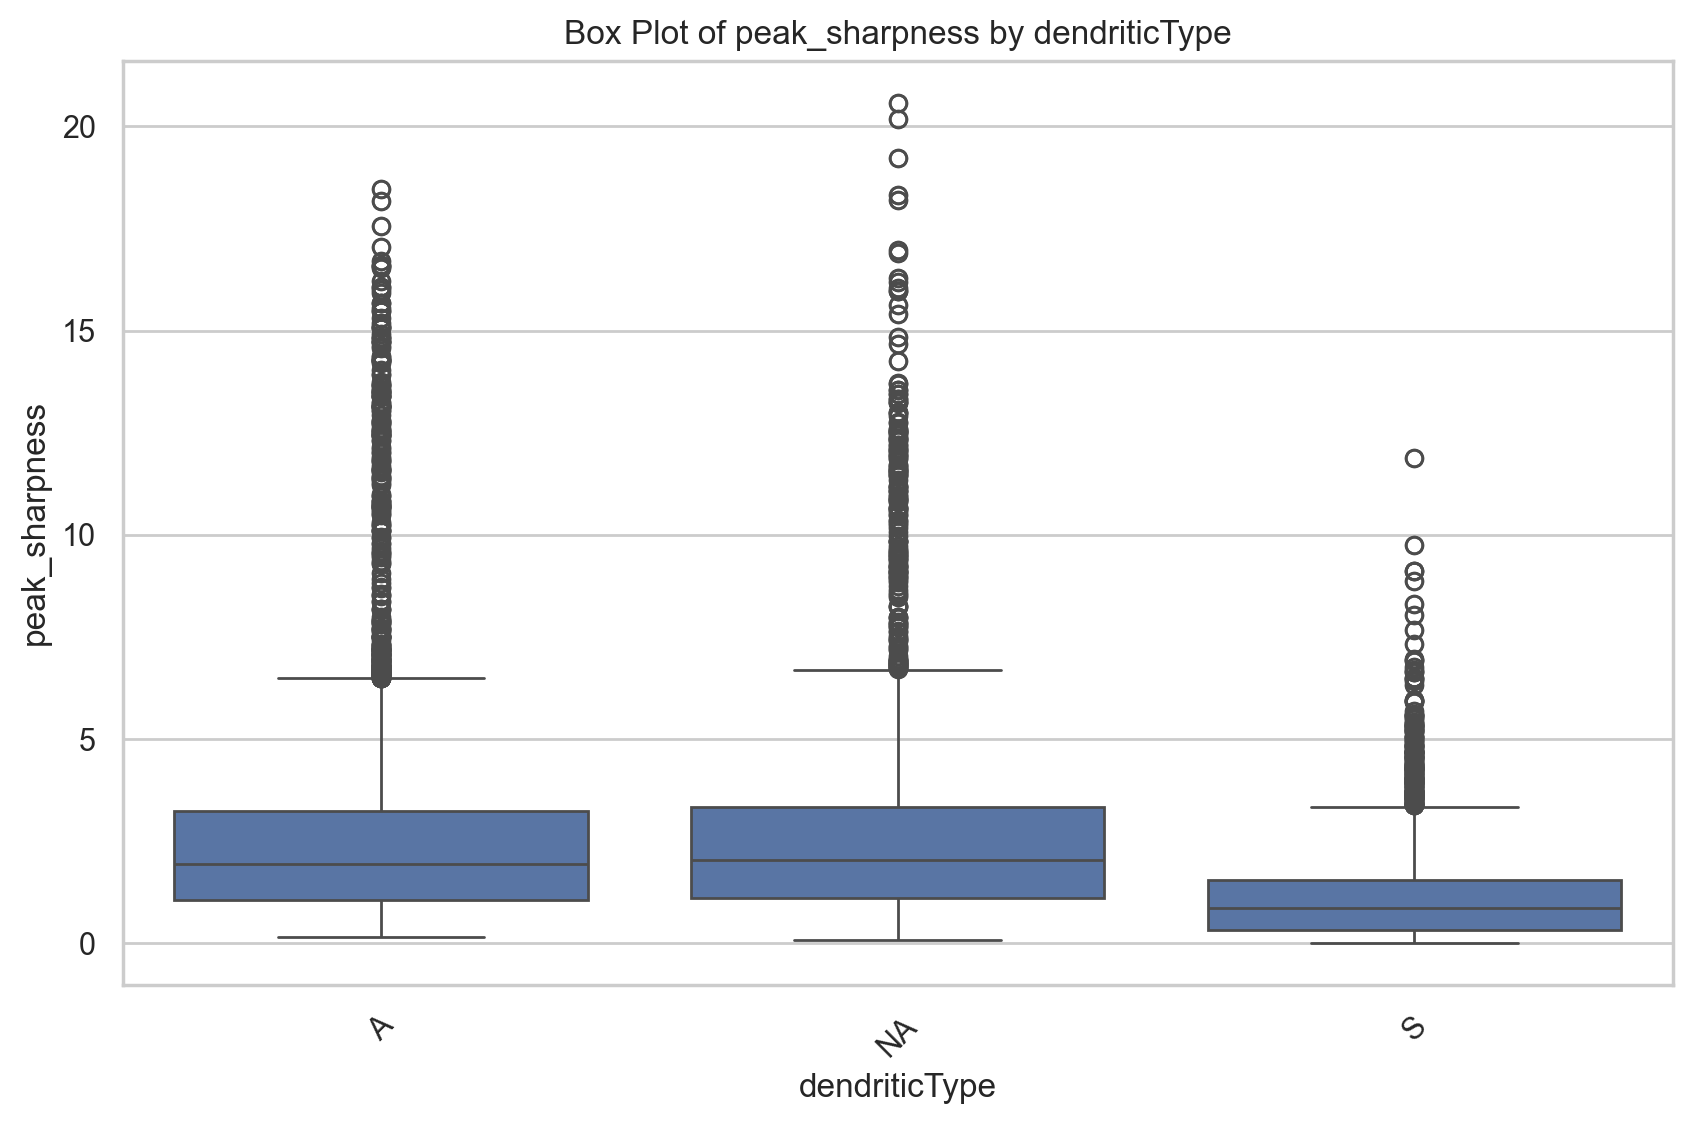

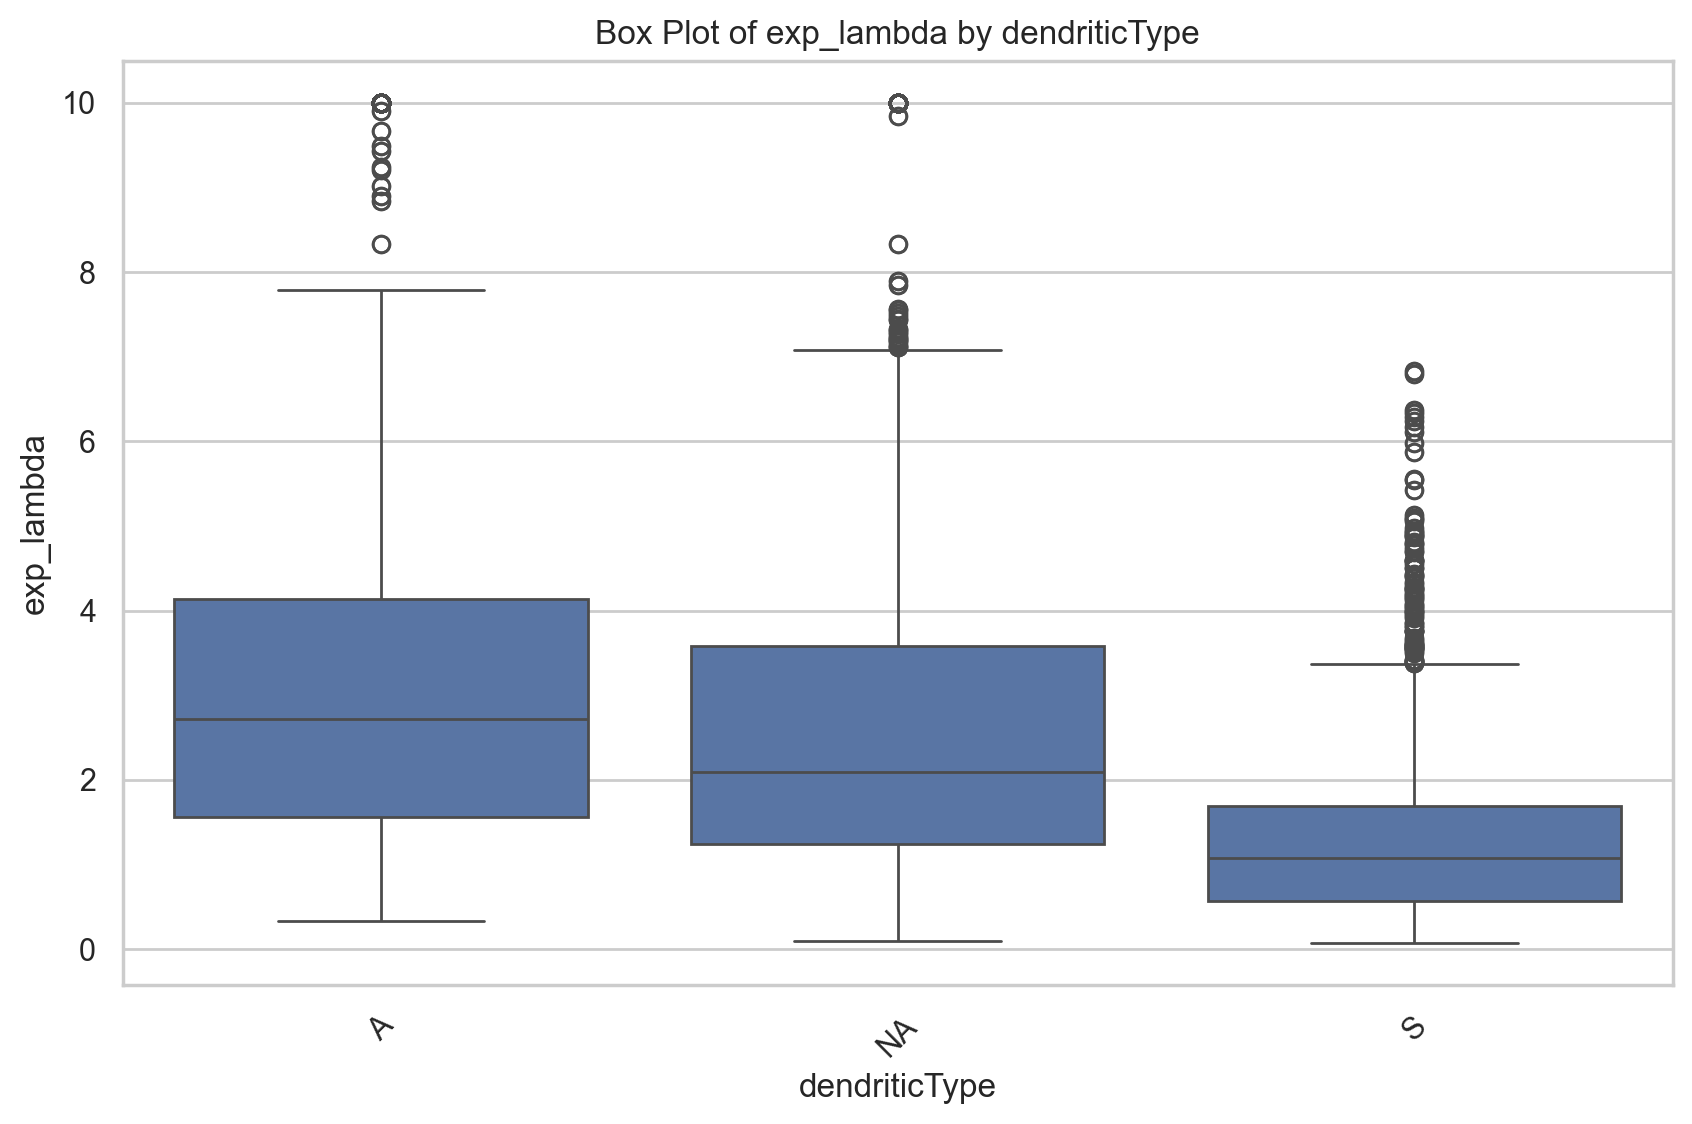

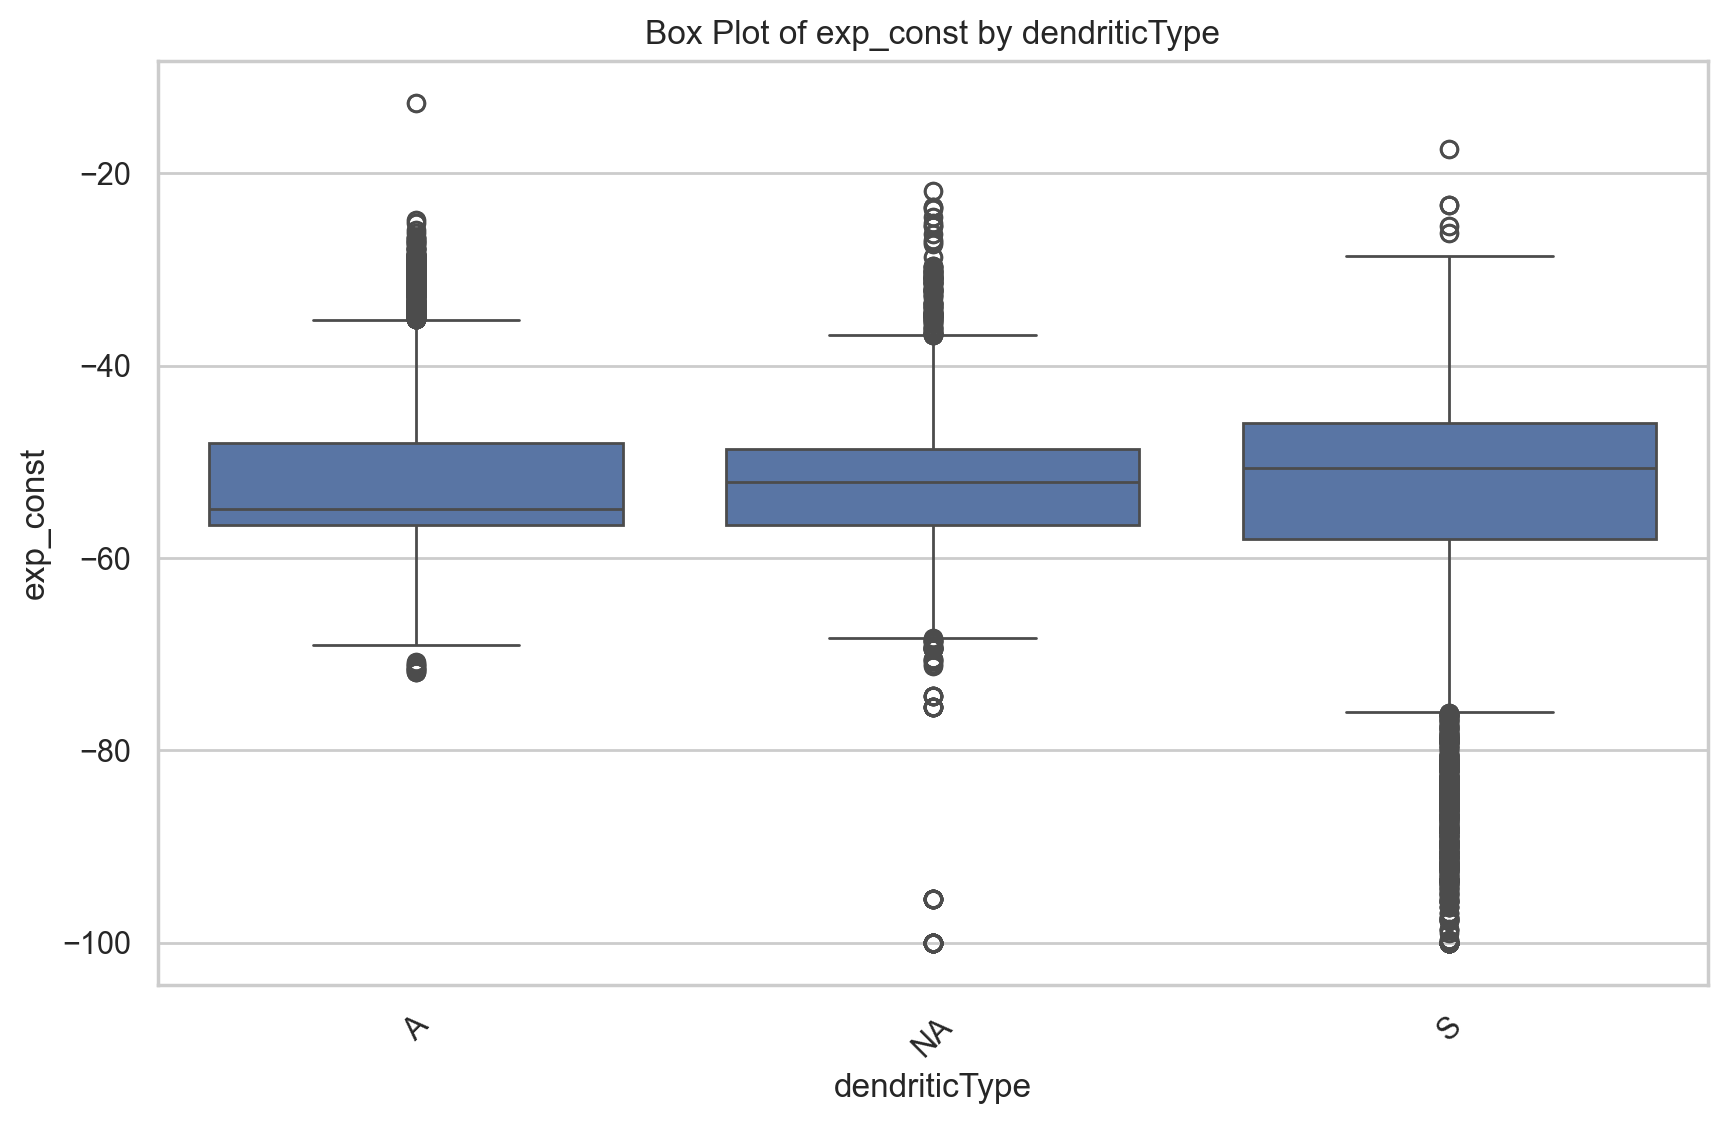

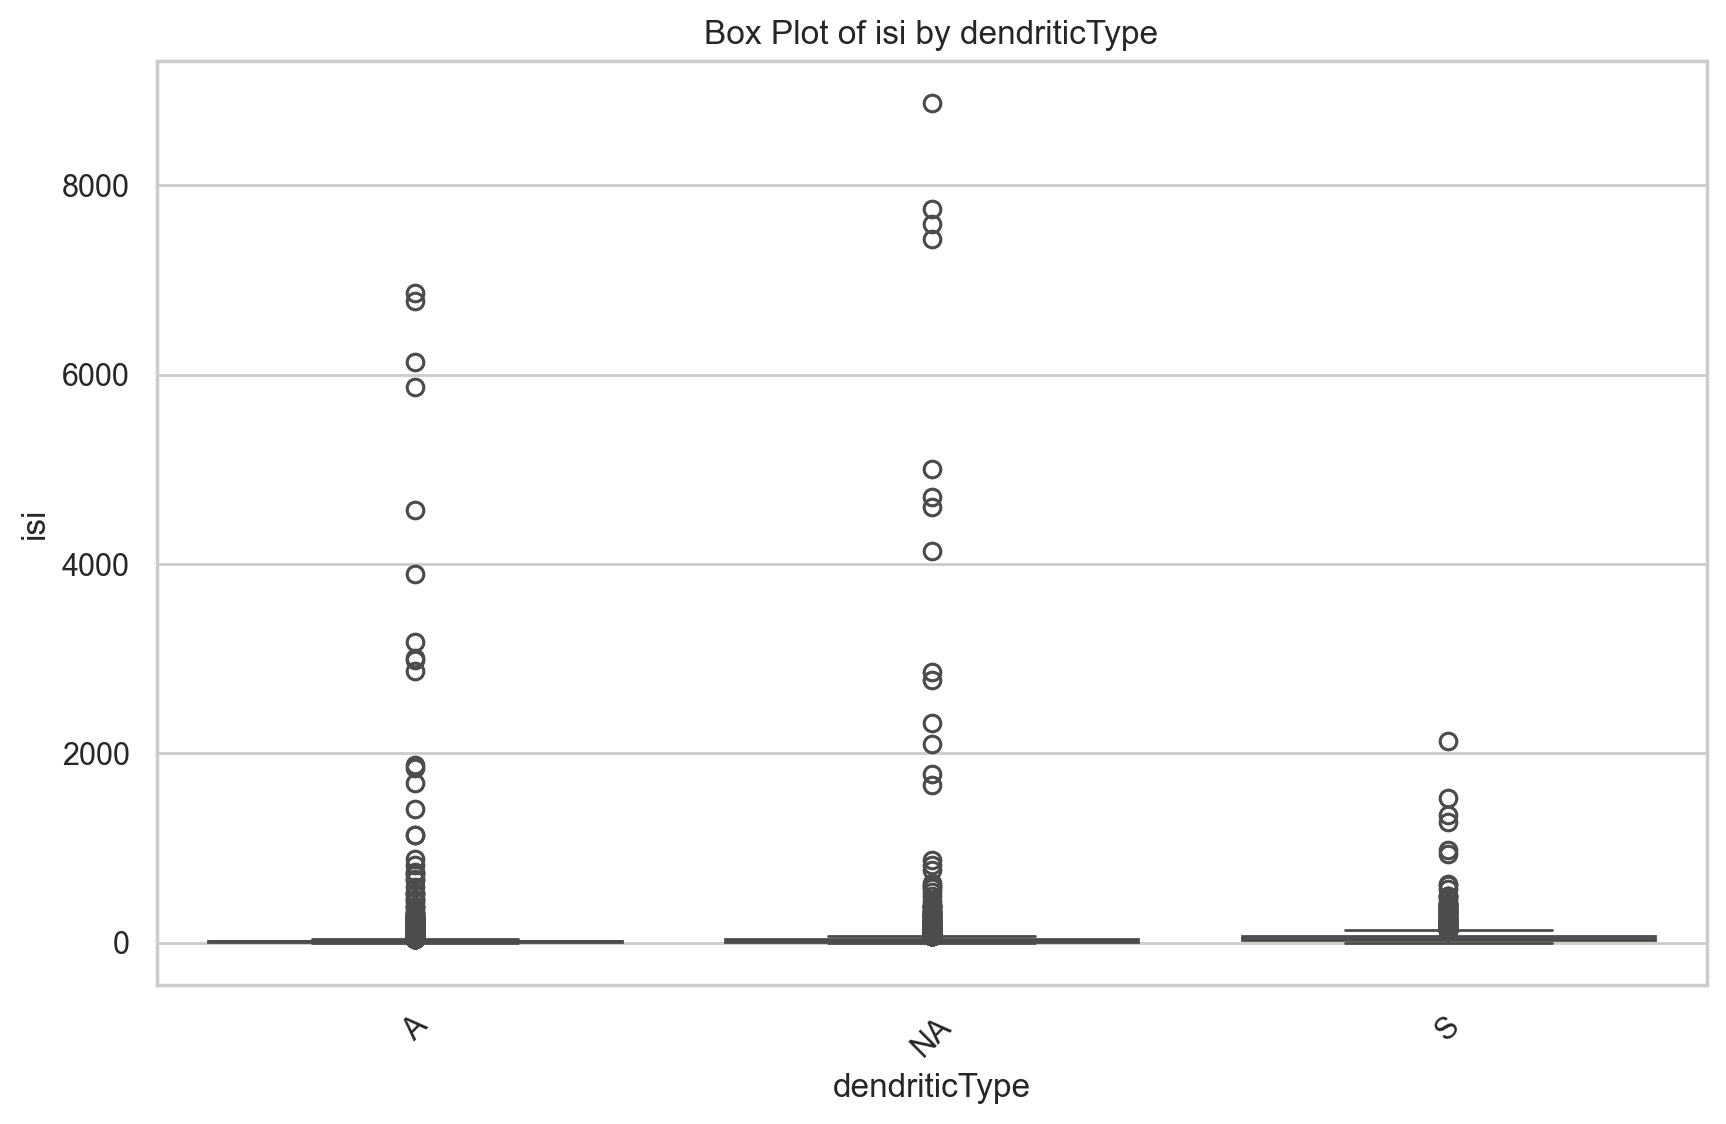

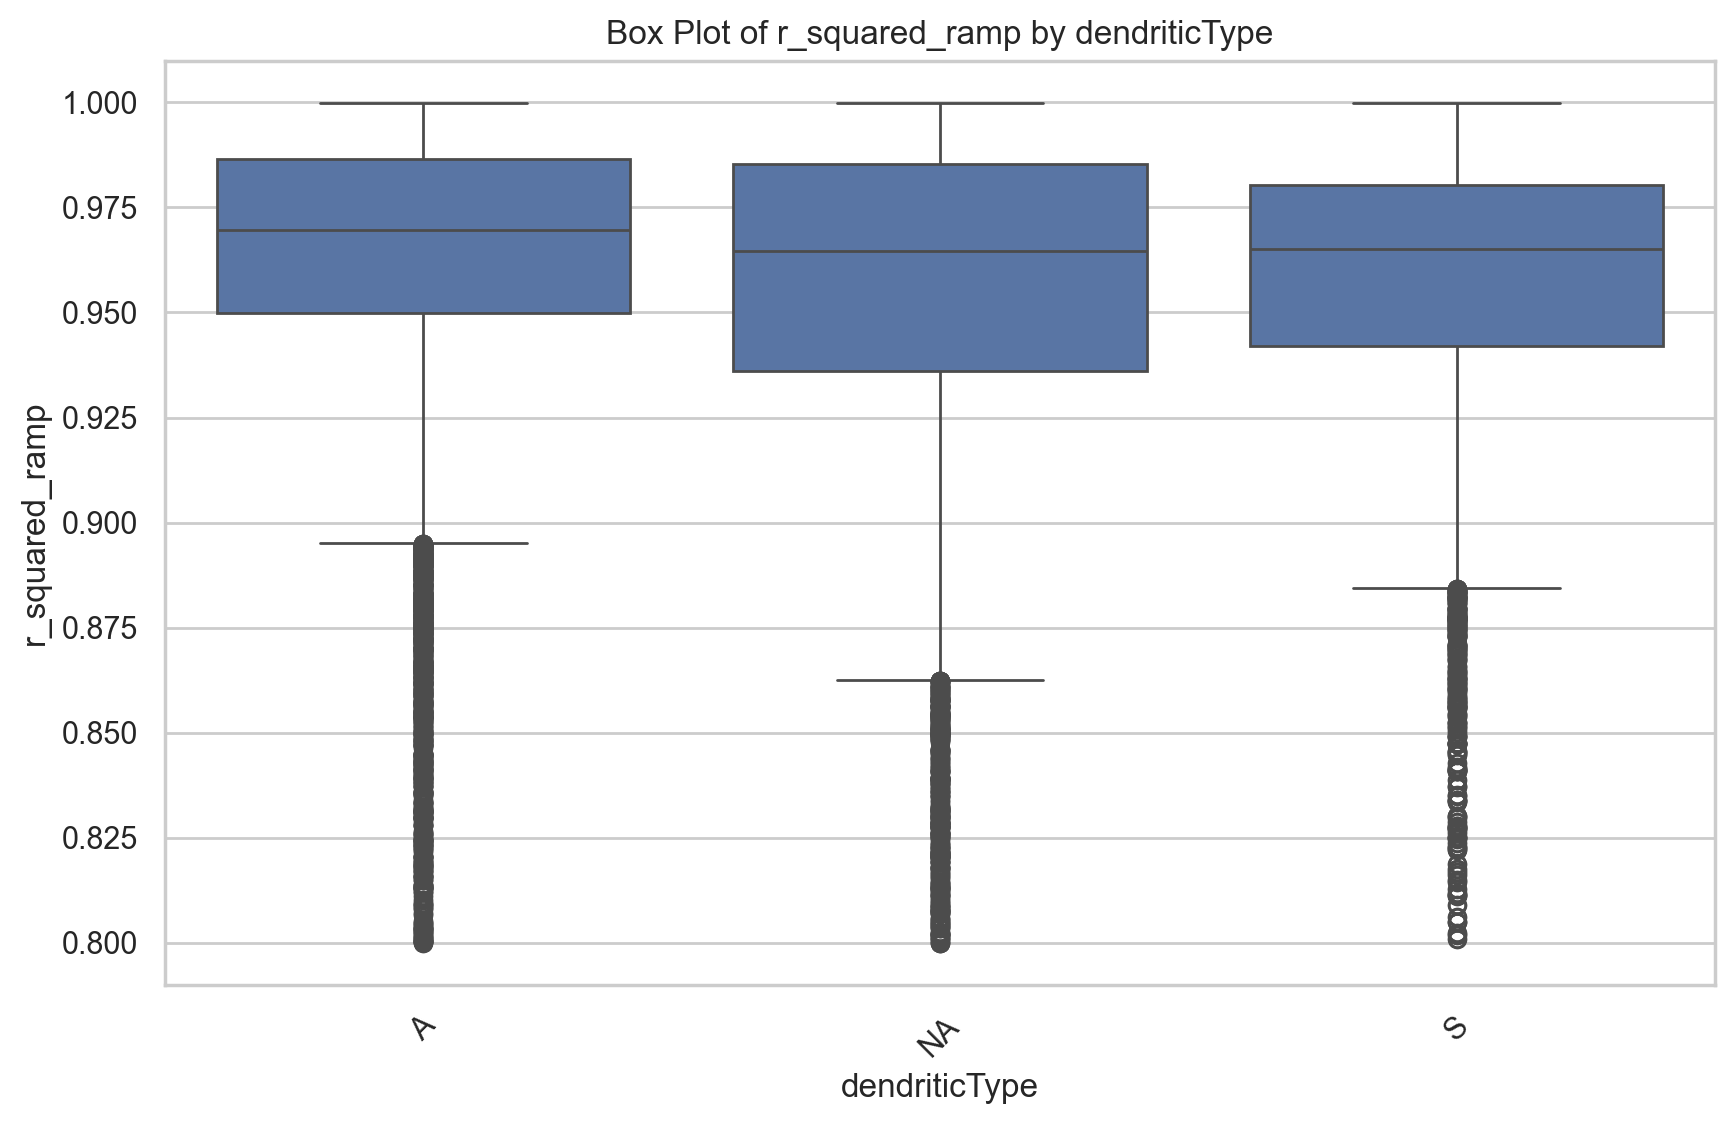

In [89]:
boxplots_by_Param('dendriticType')

In [103]:
def plot_waveform(df, combined_dict_filt, metadata_param = None, median = False, Overlapped = False):
    """
    Plots the average spike waveforms with standard deviation shading.

    This function generates plots of average spike waveforms from a dictionary of spike data. The function can filter
    the data based on a specified metadata parameter and plot the results either separately or overlapped.

    Parameters:
    - df (pd.DataFrame): The DataFrame containing metadata about the spike data.
    - combined_dict_filt (dict): A dictionary where keys are formatted as "{file_name} {Sweep_#}" and values are arrays of spike data.
    - metadata_param (str, optional): The column name in the DataFrame to filter the data by. Each unique value in this column will have its own plot.
    - median (bool, optional): If True, calculates the median spike waveform instead of the mean.
    - Overlapped (bool, optional): If True, plots the average waveforms for all unique values of the metadata parameter on a single plot.
        If False, creates separate plots for each unique value.

    Returns:
    None: The function displays the plots.
    """
    if metadata_param is not None:
        parameters = df[metadata_param].unique()

        if Overlapped: # Create the plot
            plt.figure(figsize=(10, 6))
             # Set the labels and title
            plt.xlabel('Time')
            plt.ylabel('mVs')
            plt.ylim(-80, 55)
            plt.title('Overall Average Spike with Standard Deviation for ' + str(metadata_param))
        for value in parameters:
            # Filter the DataFrame for the current unique value
            param_data = df[df[metadata_param] == value]
            all_spikes = []

            used_keys = set()
            for index, row in param_data.iterrows():
                monkey_id = row['file_name']
                sweep_num = row['Sweep_#']
                key = f"{monkey_id} {sweep_num}"
                key2 = f"{monkey_id}.nwb {sweep_num}"
                             
                if key in combined_dict_filt and key not in used_keys:
                    for spk in combined_dict_filt[key]:
                        all_spikes.extend(combined_dict_filt[key])
                    used_keys.add(key)
    
                if key2 in combined_dict_filt and key2 not in used_keys:
                    for spk in combined_dict_filt[key2]:
                        all_spikes.extend(combined_dict_filt[key2])
                    used_keys.add(key2)
                    
            # Convert the list of all spikes to a numpy array for easier manipulation
            all_spikes_array = np.array(all_spikes)

            if not Overlapped:
                # Create the plot
                plt.figure(figsize=(10, 6))
                # Set the labels and title
                plt.xlabel('Time')
                plt.ylabel('mVs')
                plt.ylim(-75, 55)
                plt.title('Overall Average Spike with Standard Deviation for ' + str(value))
            # Calculate the average and standard deviation across all spike arrays
            if median:    
                mean_spike = np.median(all_spikes_array, axis=0)
            else:
                mean_spike = np.mean(all_spikes_array, axis=0)
            std_spike = np.std(all_spikes_array, axis=0)
                    
            plt.plot(mean_spike, label=f'Average Spike {metadata_param}:{value}')
            plt.fill_between(range(len(mean_spike)), mean_spike - std_spike, mean_spike + std_spike,
                             alpha=0.2, label='±1 Standard Deviation')
        
            if not Overlapped:    #plots individual graphs
                plt.legend()
                plt.show()

        if Overlapped:           #plots overlapped graphs
            plt.legend()
            plt.show()

    else:                       #creates an average spike graph of all spikes
        all_spikes = []

        # Aggregate all spike arrays from all keys
        for key, spike_data in combined_dict_filt.items():
            all_spikes.extend(spike_data)
        
        # Convert the list of all spikes to a numpy array for easier manipulation
        all_spikes_array = np.array(all_spikes)
    
        # Calculate the average and standard deviation across all spike arrays
        mean_spike = np.mean(all_spikes_array, axis=0)
        std_spike = np.std(all_spikes_array, axis=0)
    
        # Create the plot
        plt.figure(figsize=(10, 6))
        plt.plot(mean_spike, label='Average Spike', color='b')
        plt.fill_between(range(len(mean_spike)), mean_spike - std_spike, mean_spike + std_spike, 
                         color='b', alpha=0.2, label='±1 Standard Deviation')
        
        # Set the labels and title
        plt.xlabel('Time')
        plt.ylabel('mVs')
        plt.title('Overall Average Spike with Standard Deviation')
        plt.legend()
    
        # Show the plot
        plt.show()


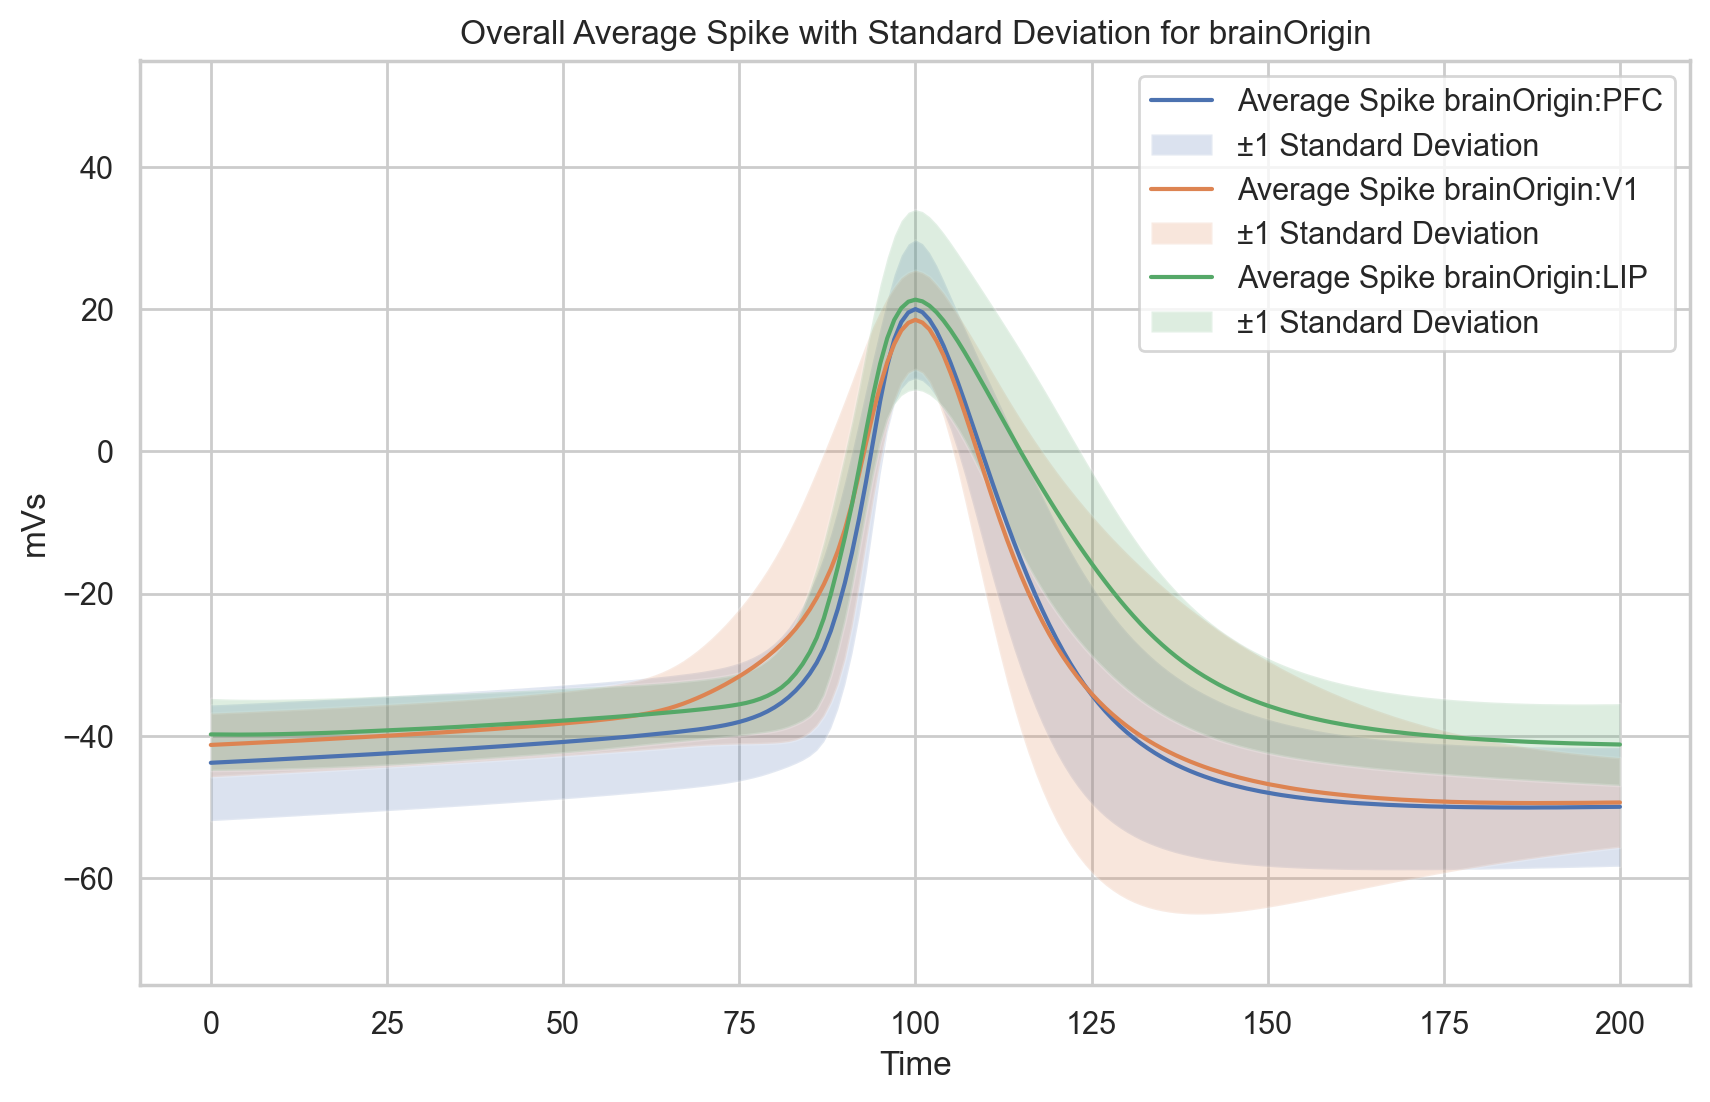

In [81]:
plot_waveform(allMonkey_df_filt, 'brainOrigin', Overlapped=True)

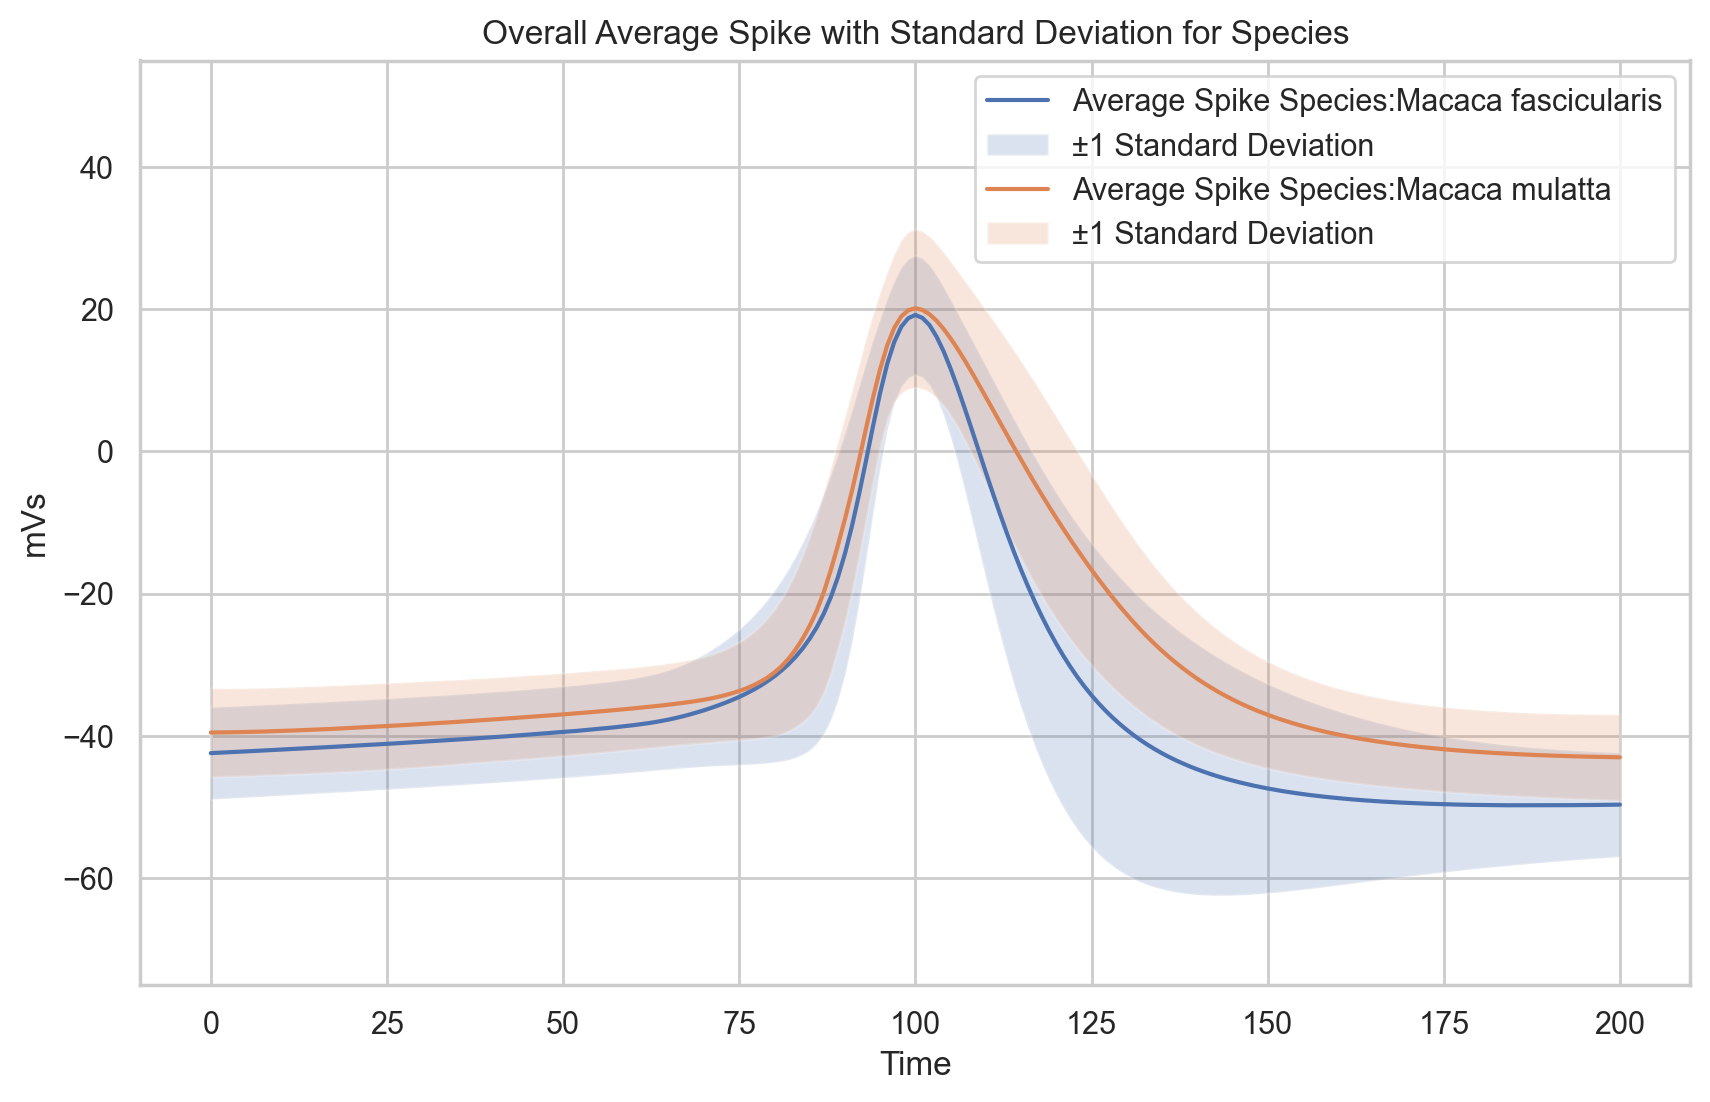

In [82]:
plot_waveform(allMonkey_df_filt, 'Species', Overlapped=True)

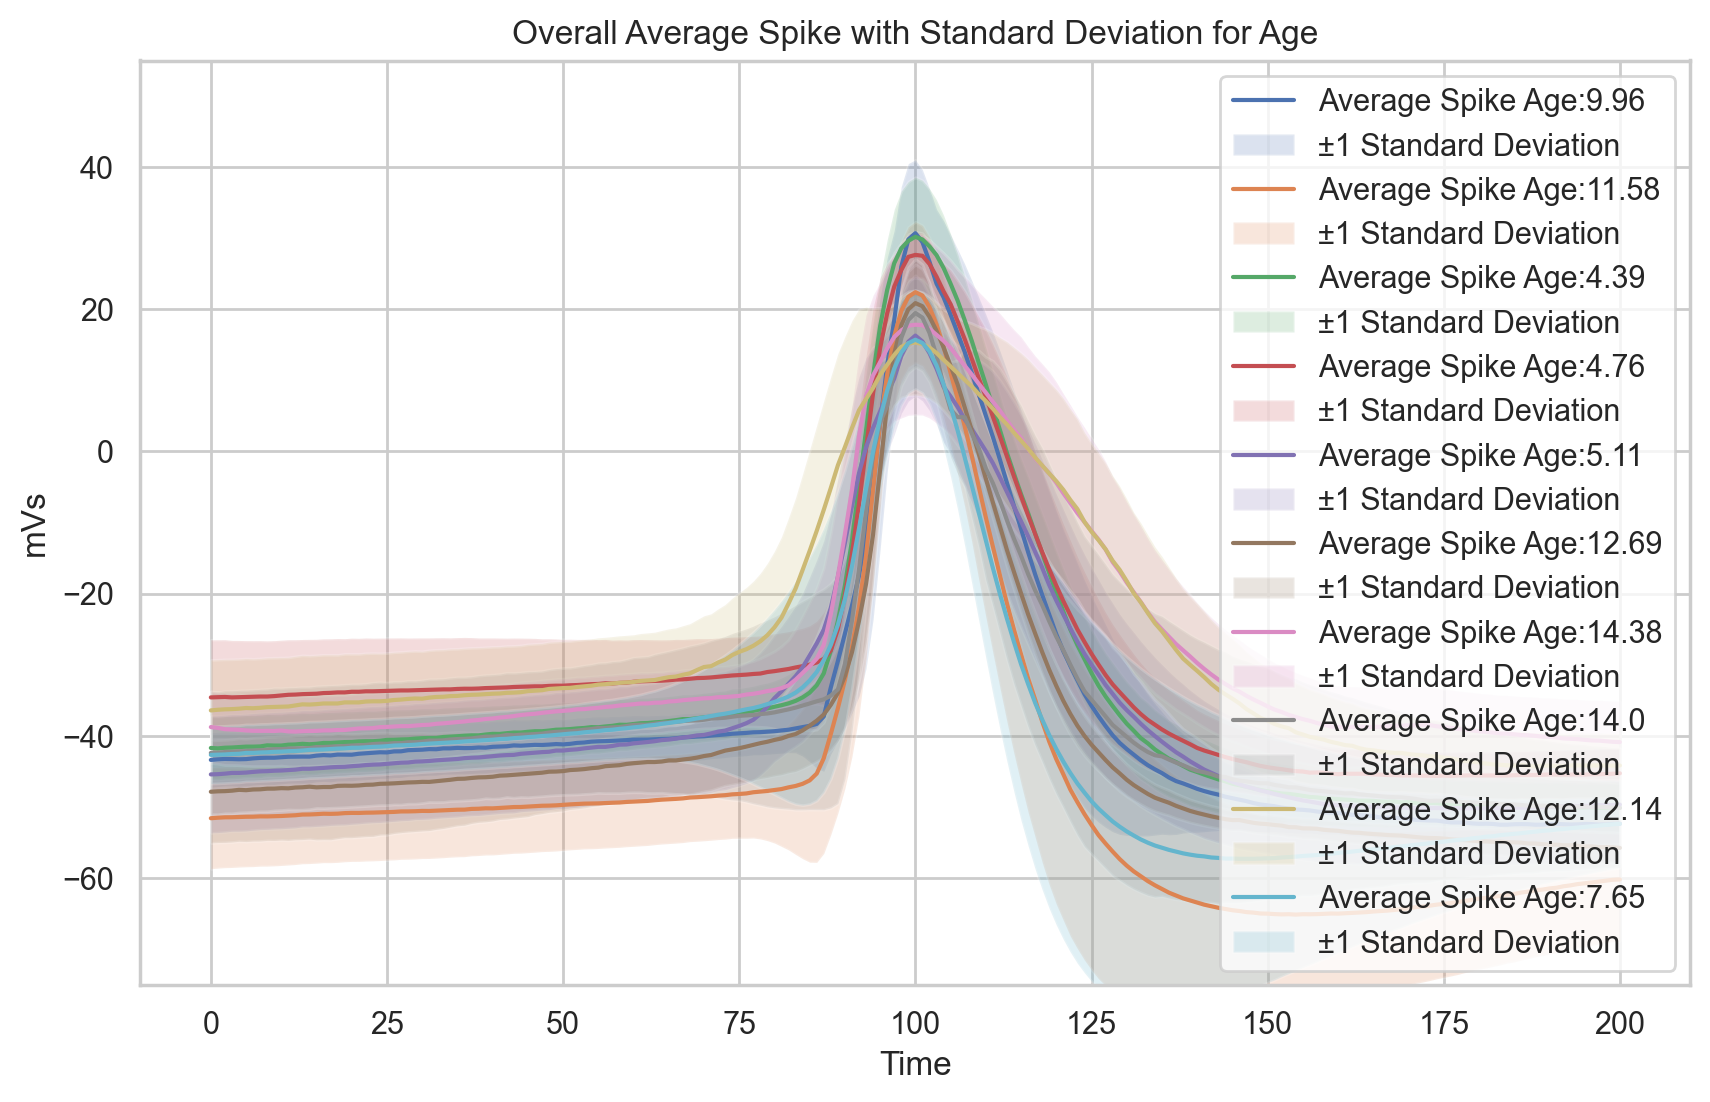

In [80]:
plot_waveform(allMonkey_df_filt, 'Age', True, True)

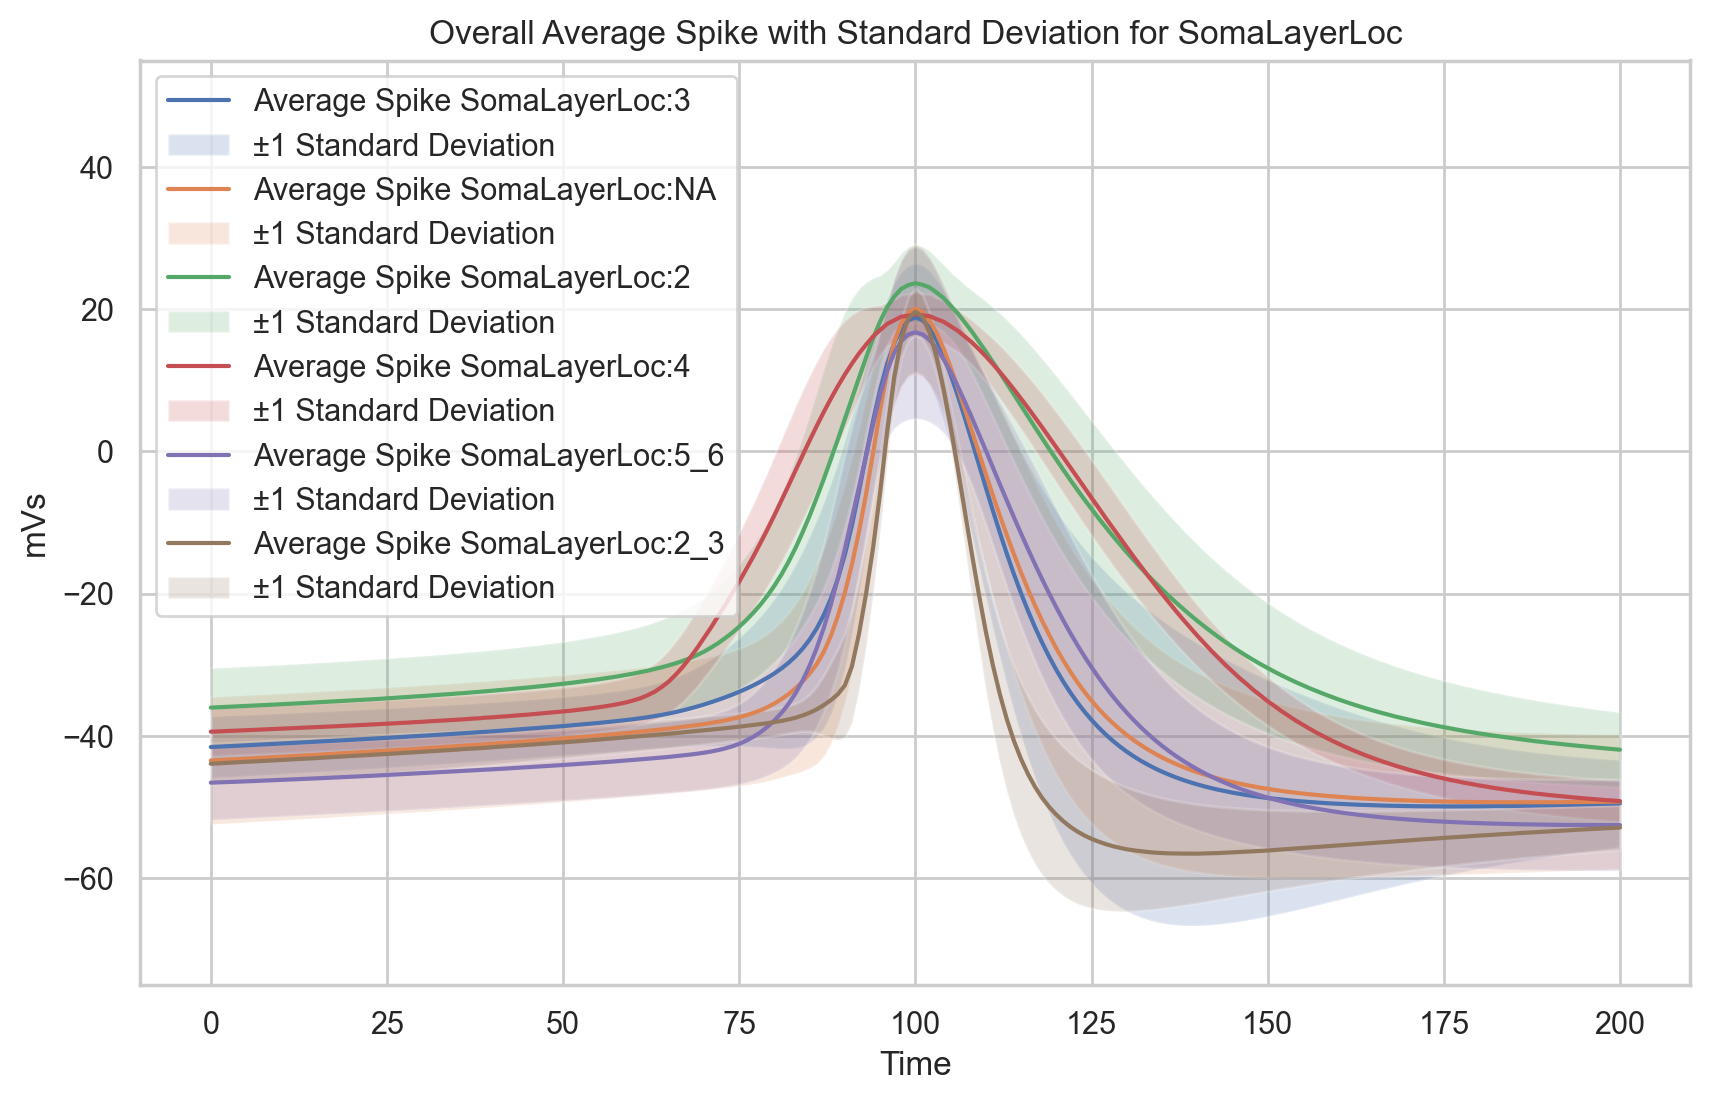

In [83]:
plot_waveform(allMonkey_df_filt, 'SomaLayerLoc', Overlapped=True)

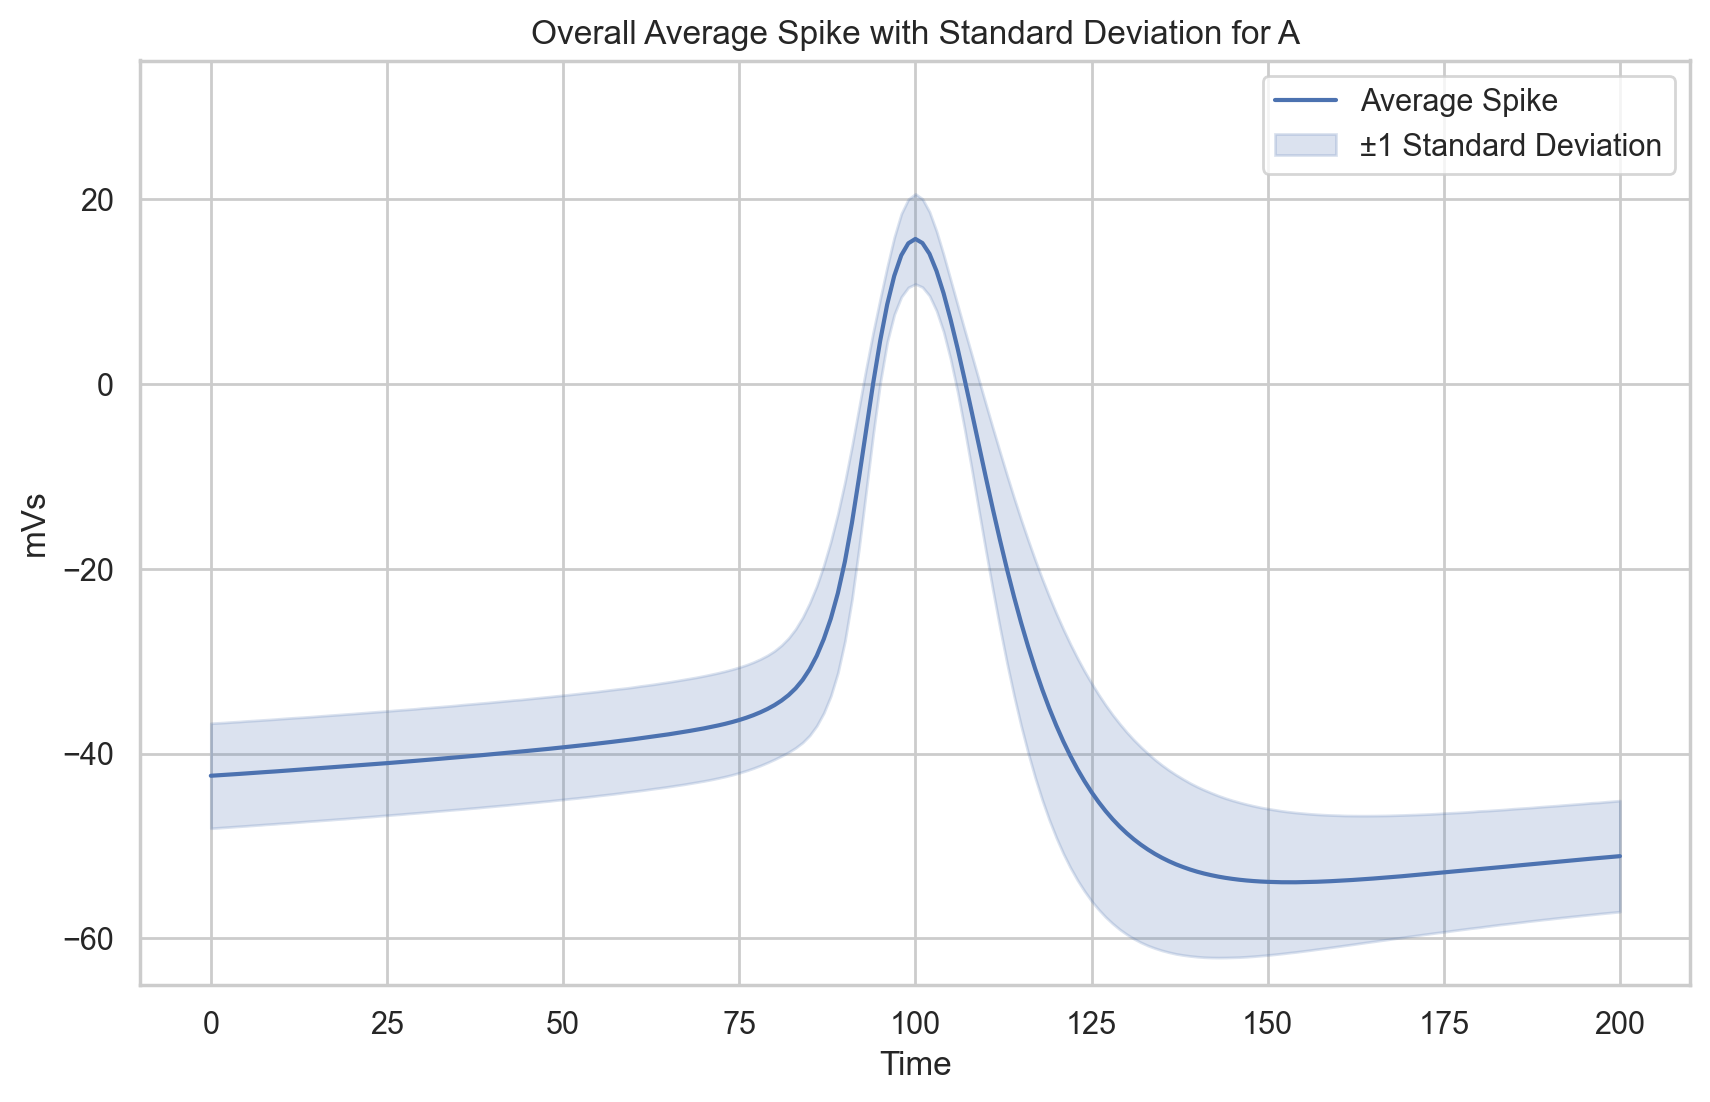

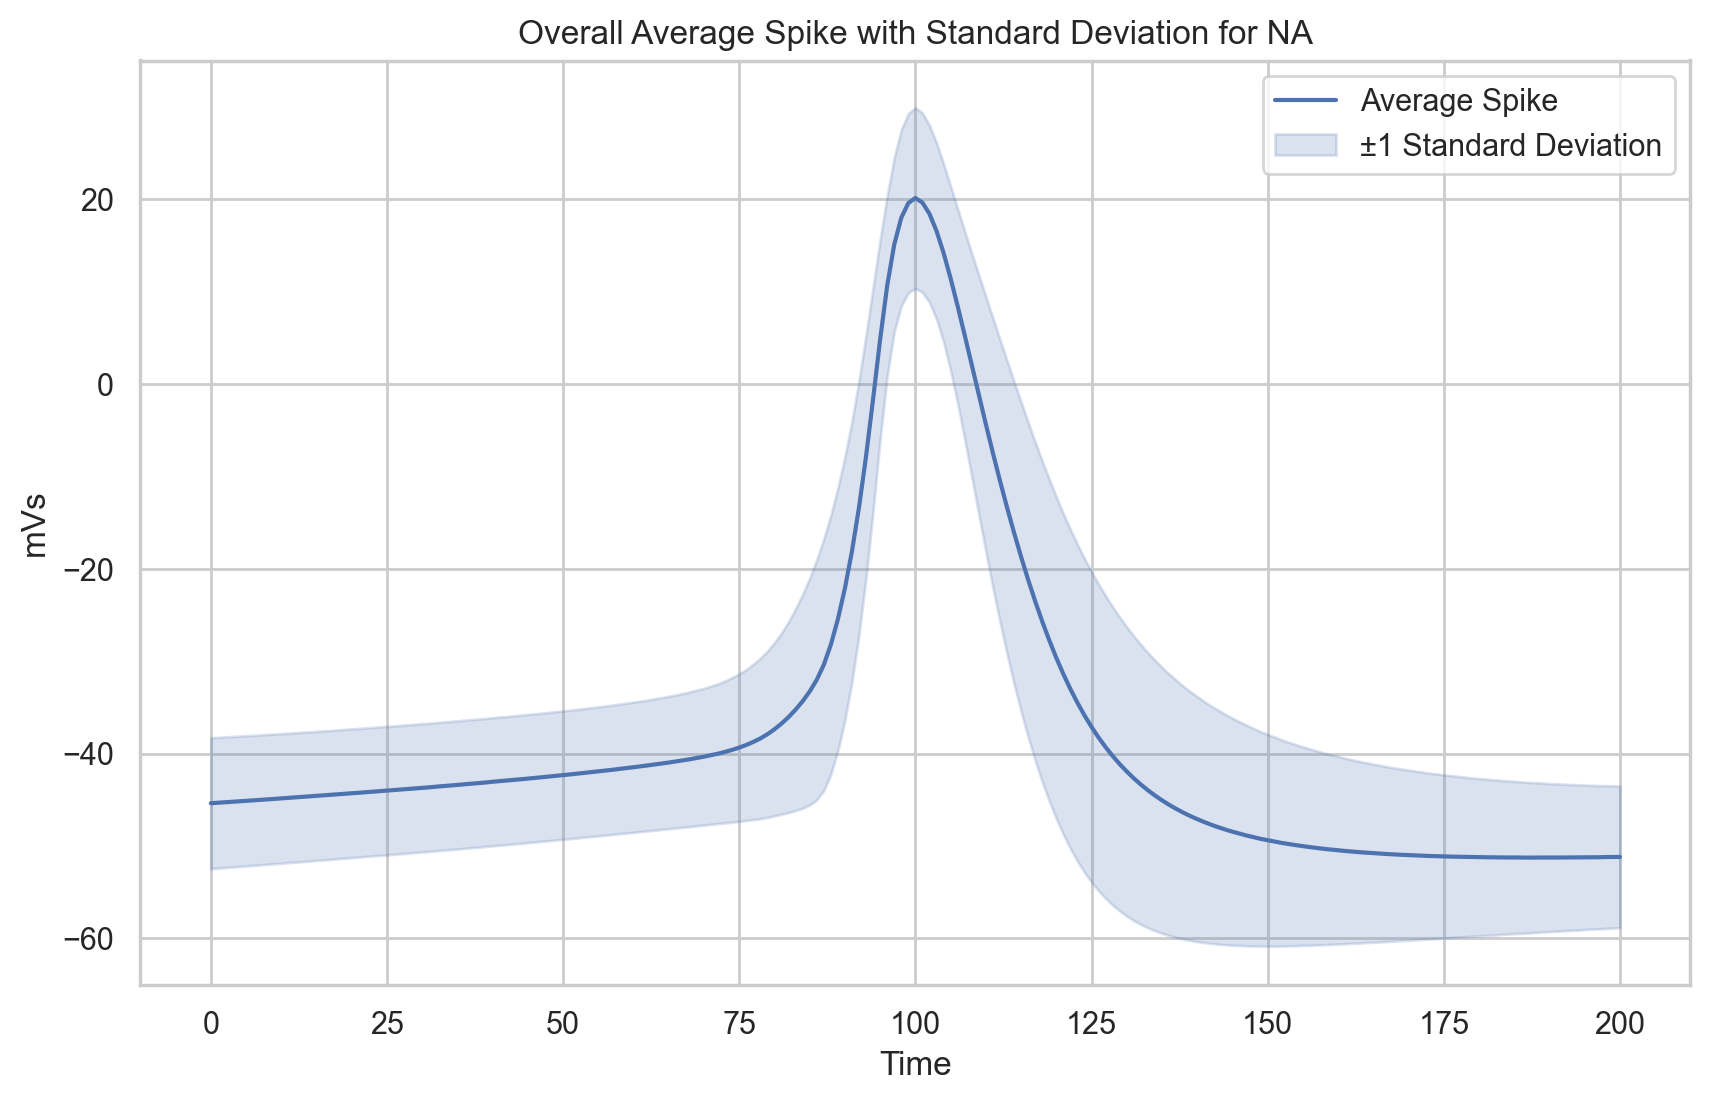

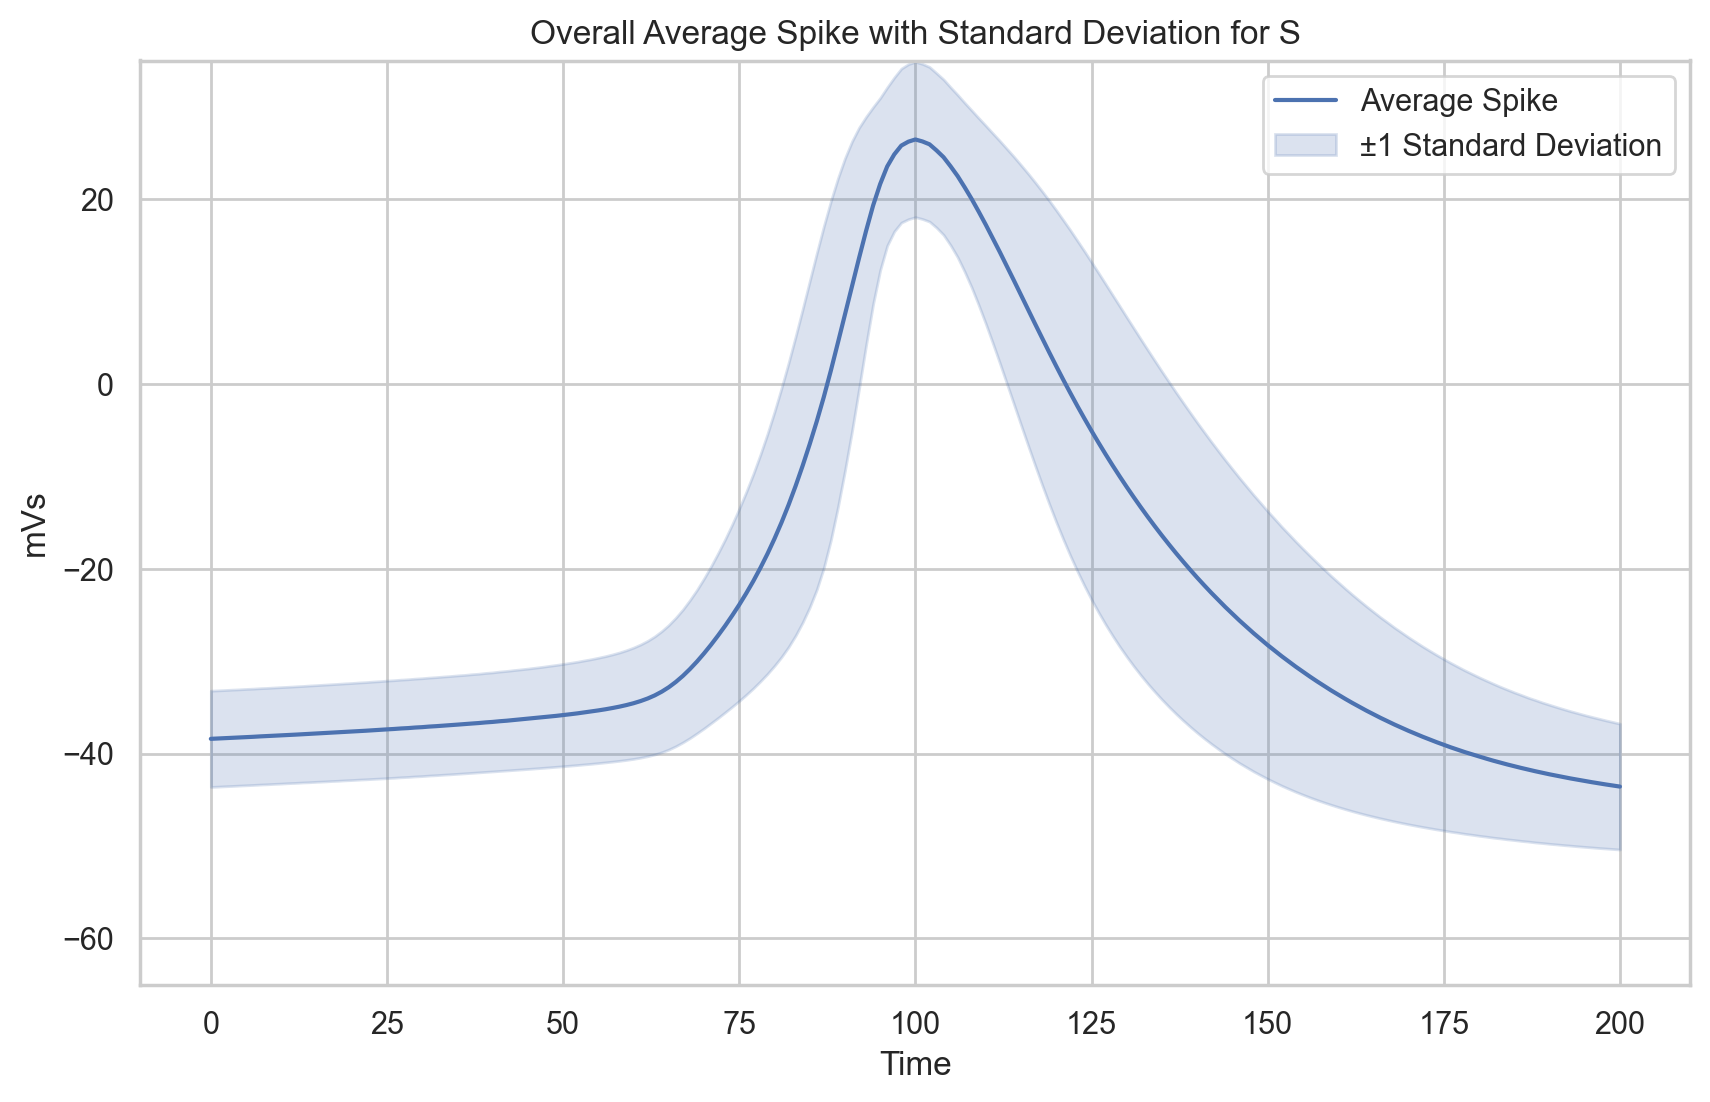

In [40]:
plot_waveform(allMonkey_df_filt, 'dendriticType')

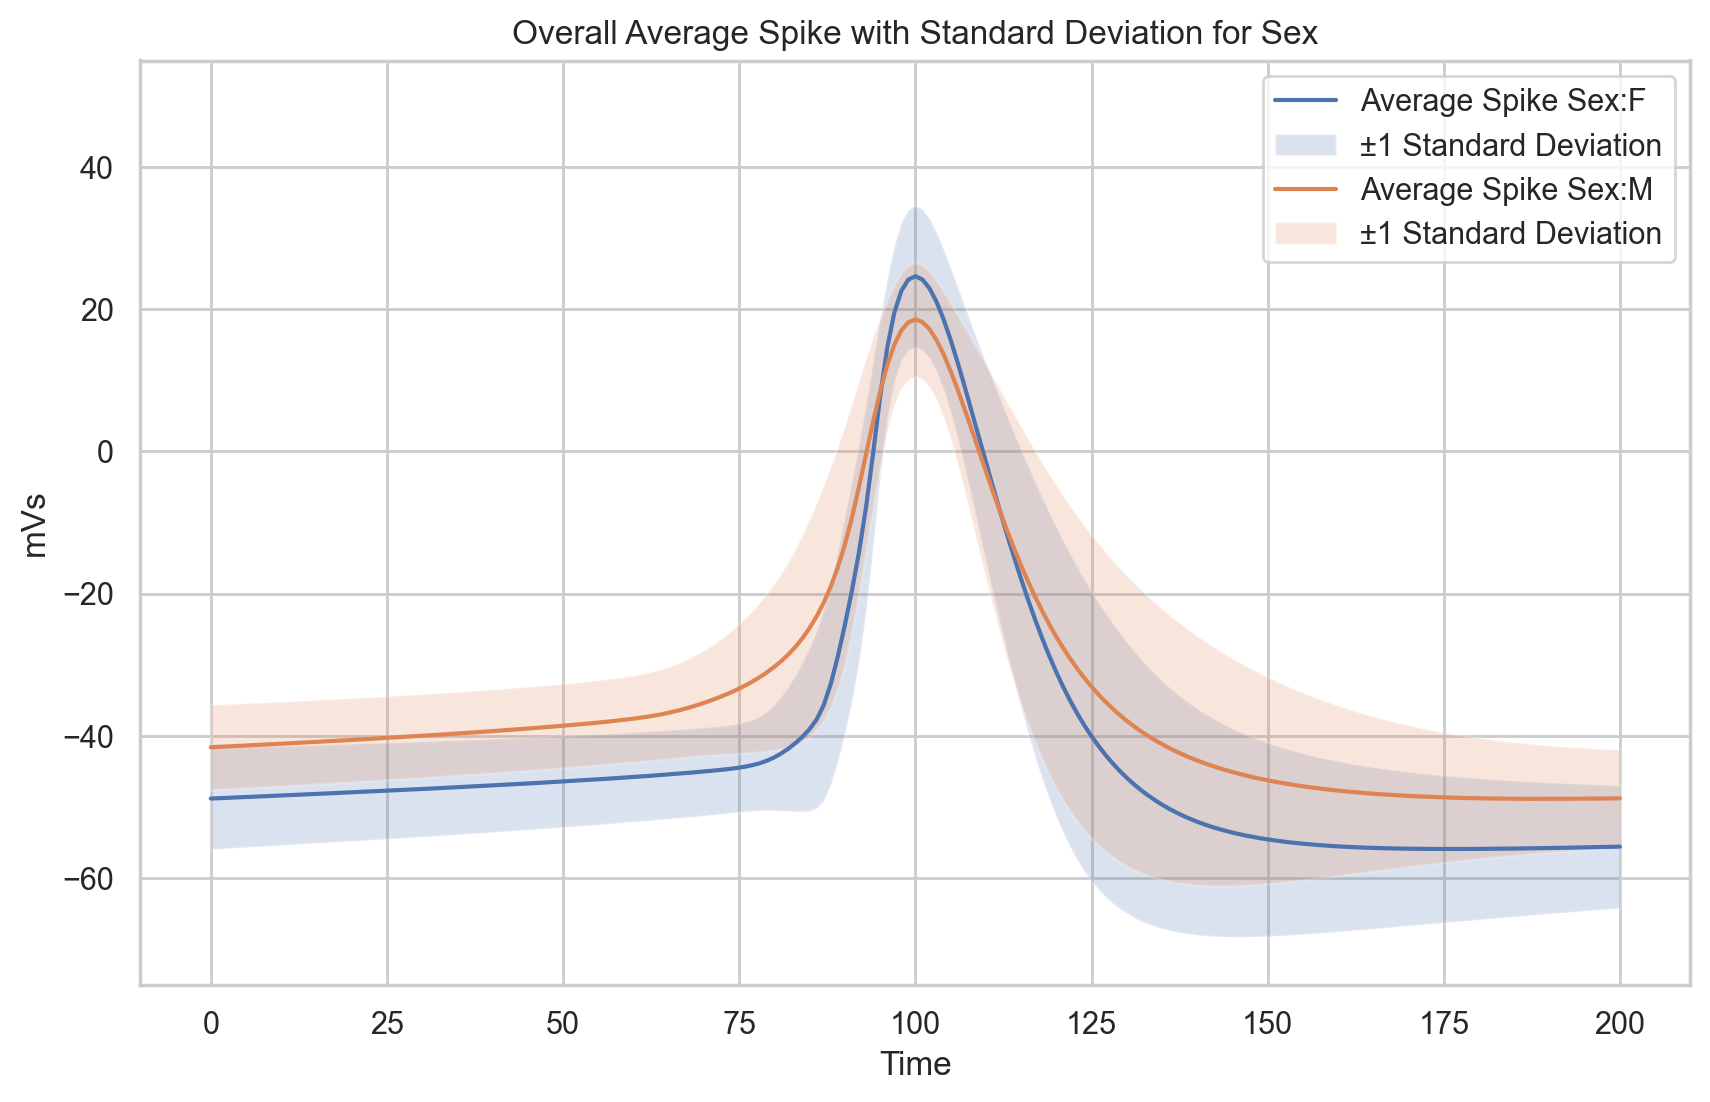

In [84]:
plot_waveform(allMonkey_df_filt, 'Sex', Overlapped=True)

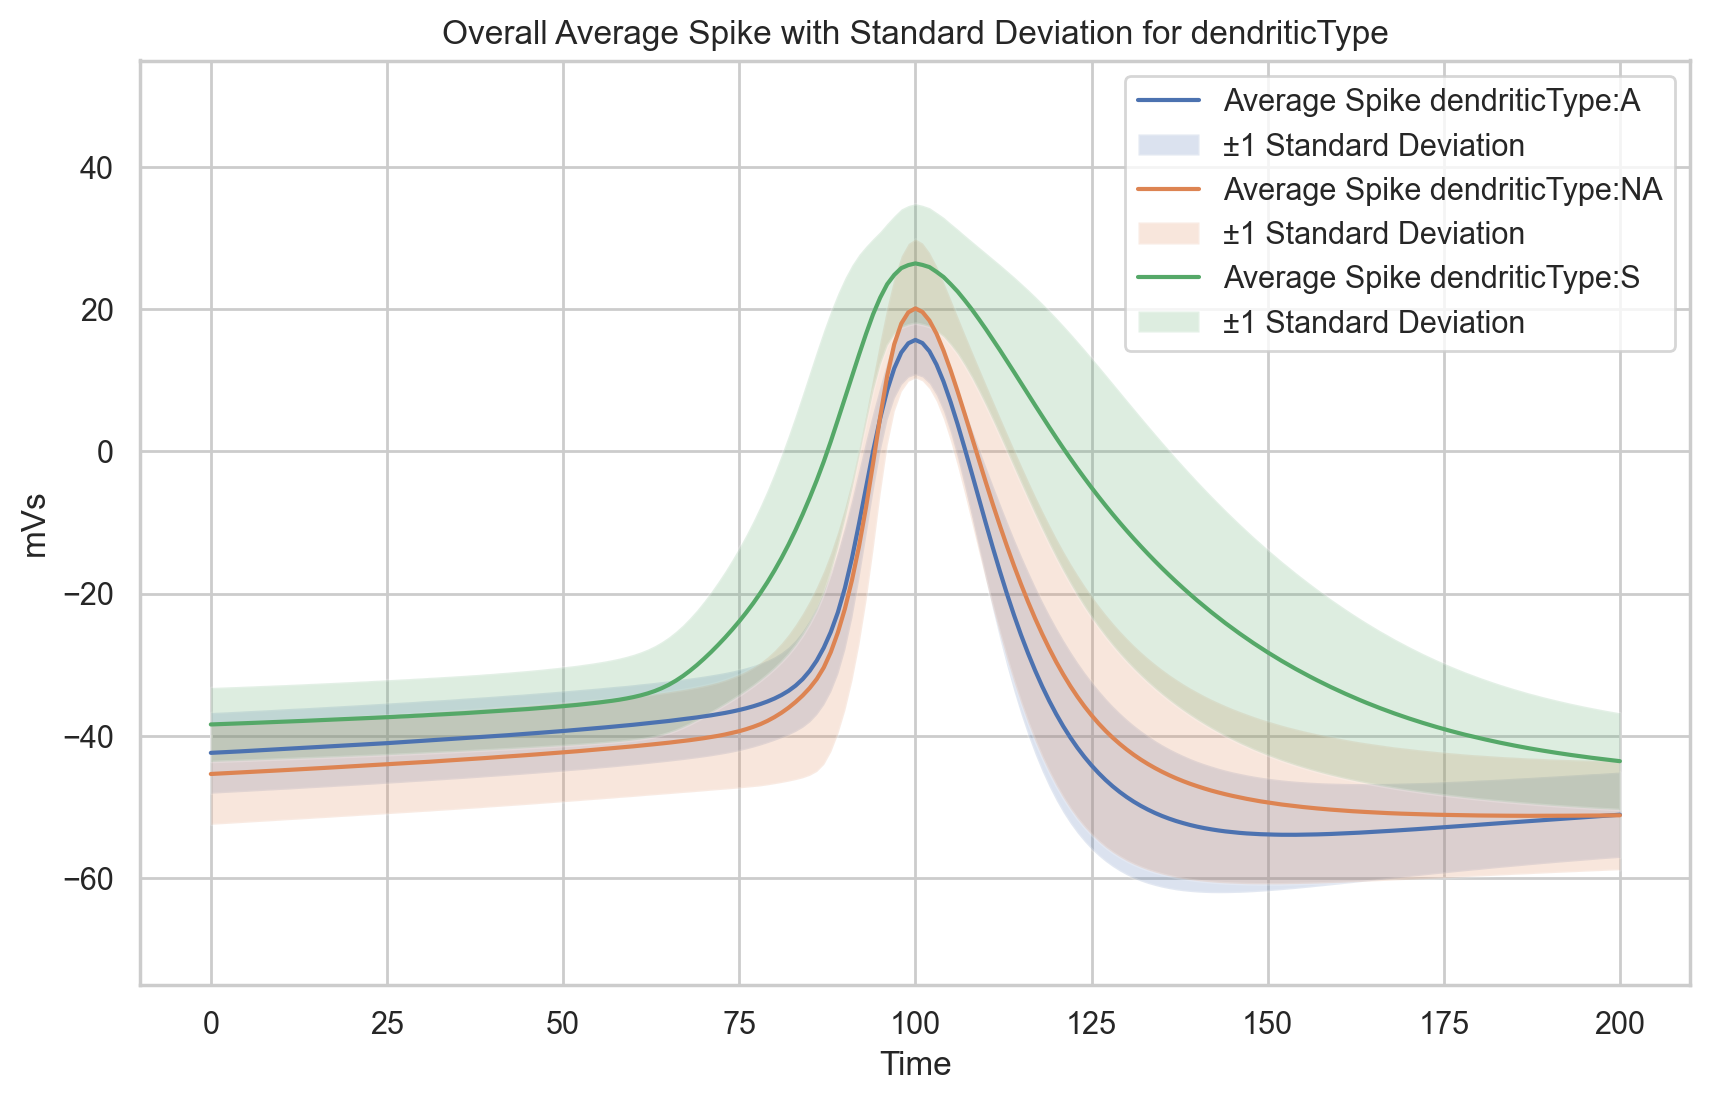

In [91]:
plot_waveform(allMonkey_df_filt, 'dendriticType', False, True)

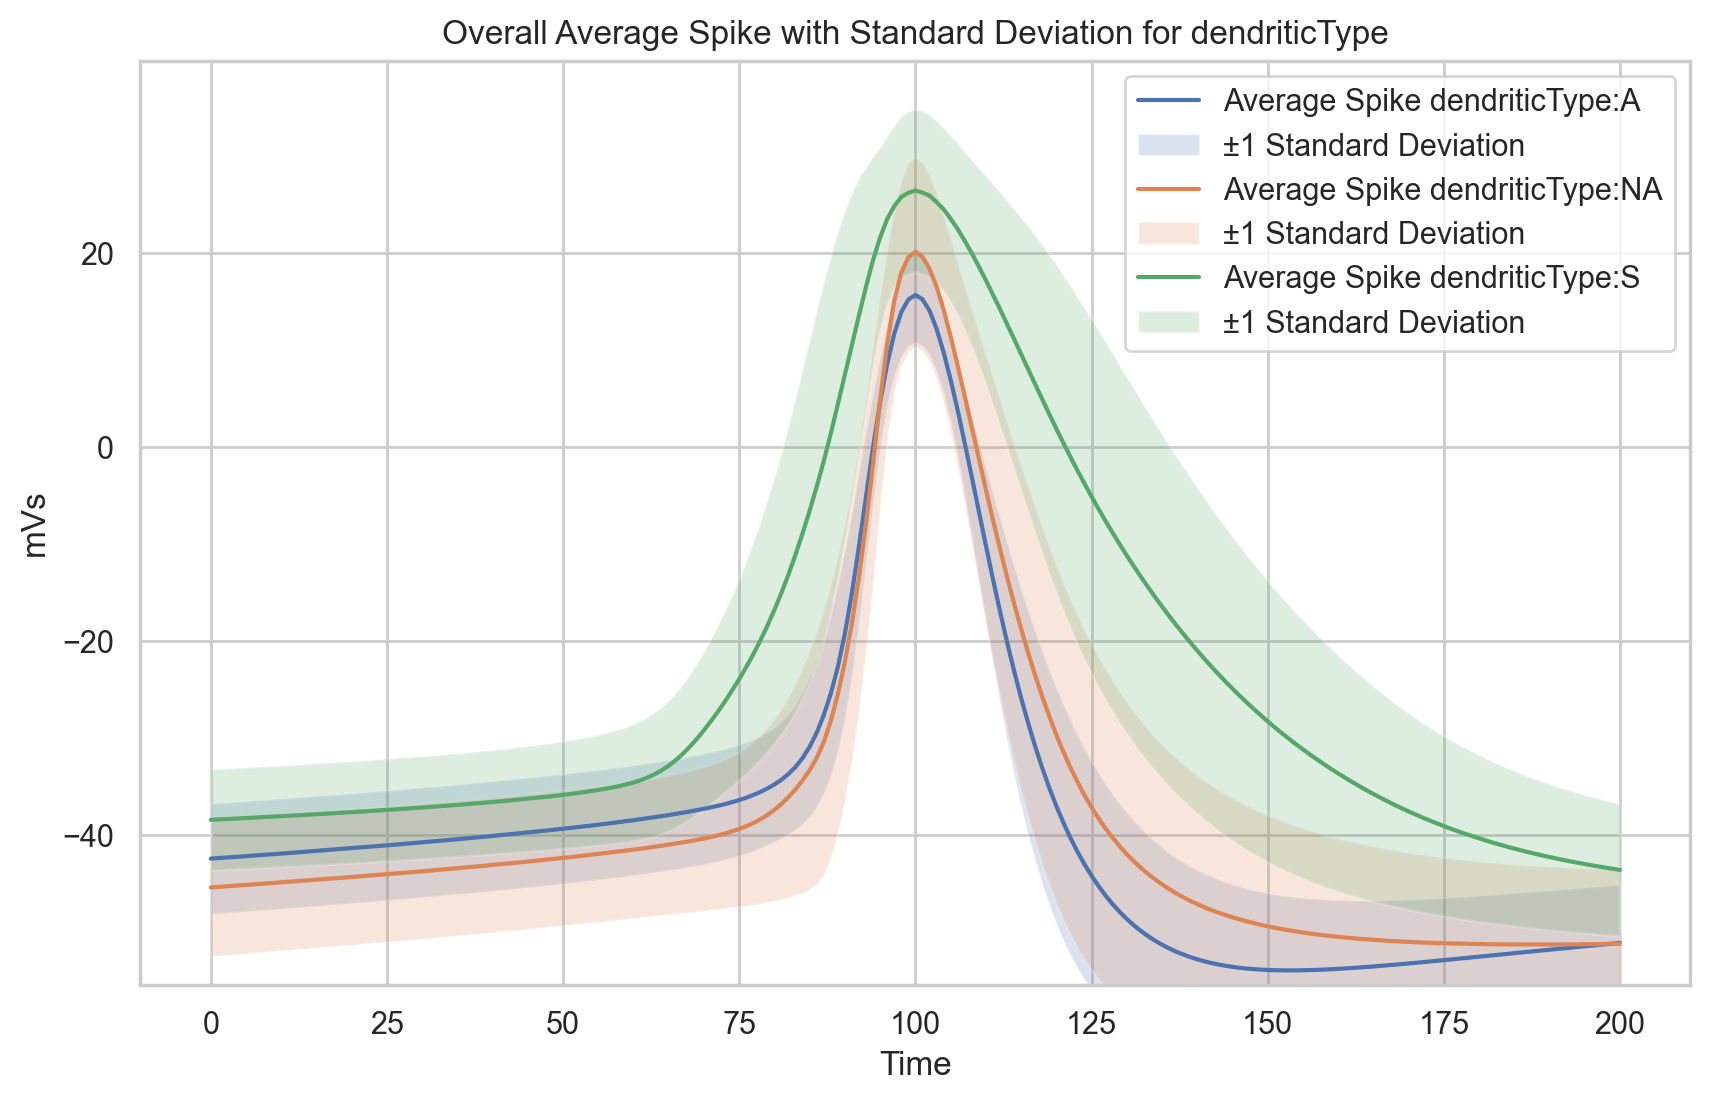

In [93]:
plot_waveform(allMonkey_df_filt, 'dendriticType', False, True)